In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pickle
import scipy
from scipy.interpolate import interp1d
import math
from scipy.interpolate import CubicSpline
from scipy.optimize import curve_fit
import matplotlib.colors as colors
from scipy.signal import argrelextrema
from tqdm import tqdm
import os

In [2]:
justloadingindata=False
verbiose=1 #0 means very little printing/plotting

load in the models to be run using a csv file like the following:

For the gain model for svet07 and ga, you can choose between sec (sector model), pham (pham model with n= the value in the n column), or simp (simple model where the volatiles gained are the impactor mass times the volatile fraction)

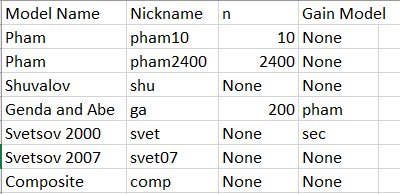

In [3]:
mods=pd.read_csv('models18.csv')
# mods=pd.read_csv('models18.csv')
display(mods)

,Model Name,Nickname,n,Gain Model
0,Pham,pham,250.0,NaN
1,Shuvalov,shu,NaN,NaN
2,Genda and Abe,ga,NaN,sec
3,Svetsov 2000,svet,NaN,sec
4,Svetsov 2007,svet07,NaN,NaN
5,Kegerreis,kerr,NaN,sec
6,Schlichting,hilke,NaN,sec
7,Composite with Svetsov 2007,comps,NaN,NaN
8,Composite without Svetsov 2007,compns,NaN,NaN
9,de Niem,deniem,NaN,NaN


In [4]:
if verbiose==1:
  print('running the following models:')
  for i in range(len(mods['Model Name'])):
    if mods['Model Name'][i]=='Pham' or mods['Model Name'][i]=='Genda and Abe':
      print(mods['Model Name'][i],'(n='+str(mods['n'][i])+')')
    else:
      print(mods['Model Name'][i])

running the following models:
Pham (n=250.0)
Shuvalov
Genda and Abe (n=nan)
Svetsov 2000
Svetsov 2007
Kegerreis
Schlichting
Composite with Svetsov 2007
Composite without Svetsov 2007
de Niem


decide whether or not to print data tables- not recommended for large impactor populations

also decide whether or not to save the output as various file formats

also decide whether to output data as atmospheric mass or surface pressure

In [5]:
printdatatables=False
plotallimpscheck=True #plot all generated impactors
pickleoutput=False
csvoutput=False
csvcompress=False
enhancementfactorcheck=False #multiply all loss models except for shu, pham, and svet07 (which already have their own version) (so svet00 & ga) by an enhancement factor to account for oblique impactors
fixcompcheck=False #removes big spikes and drops in complex model
fixcompcheckprint=False #prints when you get rid of a gain or loss
multiplicativebound=100 #works with fixcompcheck. if gain or loss is >starting atm mass*multiplicativebound, then it gets changed to 0
absolutebound=1e23
multorabscheck='abs' #mult or abs. if mult, uses multiplicative bound, if abs, uses absolutebound
fixphamcheck=False #decide whether to have 0 gains after m crit (True) or not (False)
fixsvet07check=False #decide whether to force svetsov 2007's gains to be 0 or + (True)
fixsvet07check2=False #weirder svet07 check
fixsvetcheck=False #decide whether to force svetov 2000's losses to be 0 for small imps and large atms (True)
fixshucheck=False #decide whether to force xi to never be negative. if xi is negative, it changes it to 0 to avoid nans due to taking the log of xi. this also forces 0<chi_imp<1 instead of just chi_imp<1\
fixseccheck=False #there's an integral in the sector model that breaks if x>1. if x>=1, zeta=0 if this is set to true
outputdataunits='pressure' #'mass' or 'pressure'
dragcheck=False
# imp_type='comet' #'comet' or 'asteroid'
atmchange=False #decide whether the atm will change or not
fixcomplexcheck=False #make it so the sector model can't output complex values (if ==True, fixes sector model)
#pick one of the following to be true. set the rest to false
ifcomplexmake0=False #if there's a complex number, make it =0
ifcomplexmakeverysmall=False #if there's a complex number, make it a tiny bit above 0
ifcomplexmakereal=False #if there's a complex number, just take the real part
ifcomplextakenorm=False #if there's a complex number, take the norm of the number
quickrun=True #don't fix svet as well. Set this to FALSE if you want everything to work
compusingcheck=False #don't change this, it gets changed in the compatm change run function
usecompusingcheck=False #if this is set to true, then if a model is wonky for a certain gain or loss value it just won't be used. if this is set to false, then that value will be set to 0 and averaged in
fixnegativescheck=False
Dlimforlosschoice=2 #for deniem, swaps between Dlim for loss being H(rho_0/rho_imp)^1/3 or the same as the gain Dlim

medianoravg='median' #calc the median w/ IQR or the avg w/ stdev

numruns=1
numimps=1000
if verbiose==1:
    print(numimps)
#quickjump

1000


In [6]:
if fixphamcheck==True:
  ogphamgaineqn=False
else:
  ogphamgaineqn=True

some parameter definitions

In [7]:
planet='Earth'
startingP=1 #bar

In [8]:
if planet=='Earth':
  v_esc=11.2 #km s^-1
  H=8.5 #scale height km
  rho_tar=2.835E12 #avg crust density kg km^-3
  
  bulkdensity=5.513E12 #bulk density of earth kg/km^3
 
  r_planet=6371 # km
  gravity=0.0098 #km/(s^2)
  presentday_rho_atm=1.217E9 # kg km^-3 this value is surface density but idk if that's right mika here
  presentday_atm_m=5.1e+18 #kg  

  e_0 = 54.7e-3 #km^2 s^-2 Interpolating for N2 using P=1 bar
  #this ^ gets overwritten below if atmchange is set to true

  #sector mod
  specificentropy=(6.8/28.02)*1e-3 #km^2/s^2 K

  slope=-3.4648591106161257 #for power law. -3.5, -3.4648591106161257 for earth, -3.3473969290011216 for mars, -3.4533697696073387 for venus

  probcomet=0.18 #from caitlin paper pg10 from olsson-steel 1987. probability of a comet. 1-this value is prob of an asteroid

elif planet=='Mars':
  v_esc=5.03 #km s^-1
  H=11.1 #scale height km
  rho_tar=2.582E12 #avg crust density kg km^-3
  bulkdensity=3.934E12
  r_planet=3389.5 # km
  gravity=0.00373 #km/(s^2)
  presentday_rho_atm=2e7 # kg km^-3 this value is surface density but idk if that's right mika here
  presentday_atm_m=2.5E16 #kg

  e_0 = 283.78e-3 #km^2 s^-2 from https://www.engineersedge.com/thermodynamics/thermodynamic_properties_carbon_dioxide_14778.htm Extrapolating using a sigmoid function in log-log space for CO2
  #this ^ gets overwritten below is atmchange is set to true

  #sector mod
  specificentropy=(201.8/44.01)*1e-3 # km^2/s^2 K Interpolating for CO2 using T=213.15 K

  slope=-3.3473969290011216 #for power law. -3.5, -3.4648591106161257 for earth, -3.3473969290011216 for mars, -3.4533697696073387 for venus

  probcomet=0.06 #from caitlin paper pg10 from olsson-steel 1987. probability of a comet. 1-this value is prob of an asteroid
  
elif planet=='Venus':
  v_esc=10.36 #km s^-1
  H=15.9 #scale height km
  rho_tar=2.8E12 #avg crust density kg km^-3
  bulkdensity=5.243E12
  r_planet=6051.8 # km
  gravity=0.00887 #km/(s^2)
  presentday_rho_atm=6.5e10 # kg km^-3 this value is surface density but idk if that's right mika here
  presentday_atm_m=4.8e20 #kg

  e_0 = 94.95e-3 #km^2 s^-2 from https://www.engineersedge.com/thermodynamics/thermodynamic_properties_carbon_dioxide_14778.htm Extrapolating using a sigmoid function in log-log space for CO2
  #this ^ gets overwritten below is atmchange is set to true  

  #sector mod
  specificentropy=(253.3/44.01)*1e-3	#km^2/s^2 K Interpolating for CO2 using T=738.15 K

  slope=-3.4533697696073387 #for power law. -3.5, -3.4648591106161257 for earth, -3.3473969290011216 for mars, -3.4533697696073387 for venus

  probcomet=0.3 #from caitlin paper pg10 from olsson-steel 1987. probability of a comet. 1-this value is prob of an asteroid

else:
  if verbiose==1:
    print('planet',planet,'not recognized')

In [9]:
#for fixing svetsov 2000. this is a huge hassle to set up, so just email me mikaylarhuffman@gmail.com if you need any planet & starting 
svetfixdict = {
    'Earth': {
        0.006: {
            'cometsvetgoesvertical': 0.6,
            'cometsvetgoeshorizontal': 0.04,
            'cometsvetvertvelo': 2.2,
            'asteroidsvetgoesvertical': 0.3,
            'asteroidsvetgoeshorizontal': 0.022,
            'asteroidsvetvertvelo': 2.2
        },
        0.1: {
            'cometsvetgoesvertical': 0.55,
            'cometsvetgoeshorizontal': 0.04,
            'cometsvetvertvelo': 2.2,
            'asteroidsvetgoesvertical': 0.3,
            'asteroidsvetgoeshorizontal': 0.017,
            'asteroidsvetvertvelo': 2.2
        },
        0.25: {
            'cometsvetgoesvertical': 0.55,
            'cometsvetgoeshorizontal': 0.04,
            'cometsvetvertvelo': 2.2,
            'asteroidsvetgoesvertical': 0.3,
            'asteroidsvetgoeshorizontal': 0.017,
            'asteroidsvetvertvelo': 2.2
        },
        1: {
            'cometsvetgoesvertical': 0.7,
            'cometsvetgoeshorizontal': 0.052,
            'cometsvetvertvelo': 2.2,
            'asteroidsvetgoesvertical': 0.411,
            'asteroidsvetgoeshorizontal': 0.028,
            'asteroidsvetvertvelo': 2.2
        },
        10: {
            'cometsvetgoesvertical': 0.55,
            'cometsvetgoeshorizontal': 0.04,
            'cometsvetvertvelo': 2.2,
            'asteroidsvetgoesvertical': 0.2,
            'asteroidsvetgoeshorizontal': 0.02,
            'asteroidsvetvertvelo': 2.2
        },
        92.5: {
            'cometsvetgoesvertical': 0.55,
            'cometsvetgoeshorizontal': 0.04,
            'cometsvetvertvelo': 2.2,
            'asteroidsvetgoesvertical': 0.3,
            'asteroidsvetgoeshorizontal': 0.025,
            'asteroidsvetvertvelo': 2.2
        }
    },
    'Venus': {
        0.006: {
            'cometsvetgoesvertical': 0.6,
            'cometsvetgoeshorizontal': 0.05,
            'cometsvetvertvelo': 2.2,
            'asteroidsvetgoesvertical': 0.23,
            'asteroidsvetgoeshorizontal': 0.03,
            'asteroidsvetvertvelo': 2.2
        },
        0.1: {
            'cometsvetgoesvertical': 0.6,
            'cometsvetgoeshorizontal': 0.05,
            'cometsvetvertvelo': 2.2,
            'asteroidsvetgoesvertical': 0.23,
            'asteroidsvetgoeshorizontal': 0.03,
            'asteroidsvetvertvelo': 2.2
        },
        0.25: {
            'cometsvetgoesvertical': 0.6,
            'cometsvetgoeshorizontal': 0.07,
            'cometsvetvertvelo': 2.2,
            'asteroidsvetgoesvertical': 0.25,
            'asteroidsvetgoeshorizontal': 0.03,
            'asteroidsvetvertvelo': 2.2
        },
        1: {
            'cometsvetgoesvertical': 0.6,
            'cometsvetgoeshorizontal': 0.07,
            'cometsvetvertvelo': 2.2,
            'asteroidsvetgoesvertical': 0.3,
            'asteroidsvetgoeshorizontal': 0.03,
            'asteroidsvetvertvelo': 2.2
        },
        10: {
            'cometsvetgoesvertical': 0.6,
            'cometsvetgoeshorizontal': 0.07,
            'cometsvetvertvelo': 2.2,
            'asteroidsvetgoesvertical': 0.3,
            'asteroidsvetgoeshorizontal': 0.03,
            'asteroidsvetvertvelo': 2.2
        },
        92.5: {
            'cometsvetgoesvertical': 0.6,
            'cometsvetgoeshorizontal': 0.07,
            'cometsvetvertvelo': 2.2,
            'asteroidsvetgoesvertical': 0.3,
            'asteroidsvetgoeshorizontal': 0.03,
            'asteroidsvetvertvelo': 2.2
        }
    },
    'Mars': {
        0.006: {
            'cometsvetgoesvertical': 1.05,
            'cometsvetgoeshorizontal': 0.13,
            'cometsvetvertvelo': 1.0,
            'asteroidsvetgoesvertical': 0.53,
            'asteroidsvetgoeshorizontal': 0.06,
            'asteroidsvetvertvelo': 1.0
        },
        0.1: {
            'cometsvetgoesvertical': 1.2,
            'cometsvetgoeshorizontal': 0.113,
            'cometsvetvertvelo': 1.0,
            'asteroidsvetgoesvertical': 0.568,
            'asteroidsvetgoeshorizontal': 0.074,
            'asteroidsvetvertvelo': 1.0
        },
        0.25: {
            'cometsvetgoesvertical': 1.2,
            'cometsvetgoeshorizontal': 0.113,
            'cometsvetvertvelo': 1.0,
            'asteroidsvetgoesvertical': 0.568,
            'asteroidsvetgoeshorizontal': 0.074,
            'asteroidsvetvertvelo': 1.0
        },
        1: {
            'cometsvetgoesvertical': 1.2,
            'cometsvetgoeshorizontal': 0.083,
            'asteroidsvetgoesvertical': 0.495,
            'asteroidsvetgoeshorizontal': 0.059,
            'asteroidsvetvertvelo': 1.0
        },
        10: {
            'cometsvetgoesvertical': 0.095,
            'cometsvetgoeshorizontal': 0.076,
            'cometsvetvertvelo': 1.0,
            'asteroidsvetgoesvertical': 0.5,
            'asteroidsvetgoeshorizontal': 0.054,
            'asteroidsvetvertvelo': 1.0
        },
        92.5: {
            'cometsvetgoesvertical': 0.8,
            'cometsvetgoeshorizontal': 0.09,
            'cometsvetvertvelo': 1.0,
            'asteroidsvetgoesvertical': 0.5,
            'asteroidsvetgoeshorizontal': 0.06,
            'asteroidsvetvertvelo': 1.0
        }
    }
}


In [10]:
def get_parameters(planet, startingP):
    return svetfixdict.get(planet, {}).get(startingP, None)

svetfixparams = get_parameters(planet, startingP)

if svetfixparams:
    cometsvetgoesvertical = svetfixparams['cometsvetgoesvertical']
    cometsvetgoeshorizontal = svetfixparams['cometsvetgoeshorizontal']
    cometsvetvertvelo = svetfixparams['cometsvetvertvelo']
    asteroidsvetgoesvertical = svetfixparams['asteroidsvetgoesvertical']
    asteroidsvetgoeshorizontal = svetfixparams['asteroidsvetgoeshorizontal']
    asteroidsvetvertvelo = svetfixparams['asteroidsvetvertvelo']
    if verbiose==1: print("svet fix params loaded:", svetfixparams)
else:
    if verbiose==1: print("No svet fix parameters found for planet:", planet, "startingP:", startingP)

svet fix params loaded: {'cometsvetgoesvertical': 0.7, 'cometsvetgoeshorizontal': 0.052, 'cometsvetvertvelo': 2.2, 'asteroidsvetgoesvertical': 0.411, 'asteroidsvetgoeshorizontal': 0.028, 'asteroidsvetvertvelo': 2.2}


In [11]:
conversionfactor=1/1000 #to go from kg/(km s^2) for pressure units to kg/(m s^2)=Pa
enhancementfactor=11/3+np.pi

planet_radius=r_planet
angle=90 #straight down impactor

def surfacepressure_to_atmmass(radius,surfacepressure,gravity):
  return 4*np.pi*radius**2*surfacepressure/(gravity*conversionfactor)

def atmmass_to_surfacepressure(radius,atmmass,gravity): 
  return atmmass*gravity/(4*np.pi*(radius)**2)*conversionfactor #conversion factor goes from kg/(km s^2) for pressure units to kg/(m s^2)=Pa

mass_atm=surfacepressure_to_atmmass(r_planet,startingP*1e5,gravity) #kg
rho_atm=mass_atm/presentday_atm_m*presentday_rho_atm
if verbiose==1: print('starting pressure =',atmmass_to_surfacepressure(r_planet,mass_atm,gravity)/100000,'bar')

#below are constants for the pham model from julia johnston's spring 2023 work
f_vap=0.55
f_obl=2.17
f_vel=0.2

Z=1.87 #from de Niem 2012 which is from Tonks and Melosh 1992

# svetsov consts
c_d=2
gamma=13/11 #adiabatic coeff

#svet07 consts
presentday_atm_m=mass_atm
current_atm_mass=mass_atm 

current_v_esc=v_esc
svetdelta=current_atm_mass/presentday_atm_m #these values change down below in the atm change version of svet07, so if you alter the algorithm here it also needs to change there

C1=v_esc/current_v_esc 
C2=0.27*svetdelta**-0.21
C3=1.32*svetdelta**0.12
C4=0.27*svetdelta**-0.24
C5=0.45*svetdelta**0.087

G=6.6743*10**-20 #km^3 kg^-1 s^-2 grav const

randomseed=80303
np.random.seed(randomseed)
size_lowerbound=0.3
size_upperbound=1000.

r_imp_array=np.logspace(np.log10(size_lowerbound),np.log10(size_upperbound),numimps)

v_lowerbound=1
v_upperbound=100
v_imp_array=np.linspace(v_lowerbound,v_upperbound,numimps)

cometyimp=0.2
asteroidyimp=0.02 #values from deNiem 2012

rho_comet=1e12 #kg/km^3
rho_asteroid=2.7e12 #kg/km^3


if printdatatables==True and verbiose==1:
  print(r_imp_array)
  print(v_imp_array)

starting pressure = 1.0000000000000002 bar


In [12]:
if atmchange==False and numruns==1:
    rho_imp=rho_asteroid
    v_imp=v_esc+5

In [13]:
def norm(z):
    return np.sqrt((np.real(z))**2+(np.imag(z))**2)

In [14]:
def calculate_percentiles(data):
    # Sort the data
    sorted_data = sorted(data)
    n = len(sorted_data)
    
    # Function to calculate the percentile
    def percentile(p):
        k = (n - 1) * p
        f = int(k)
        c = k - f
        if f + 1 < n:
            return sorted_data[f] + (sorted_data[f + 1] - sorted_data[f]) * c
        else:
            return sorted_data[f]
    
    # Calculate the median (50th percentile)
    median = percentile(0.5)
    
    # Calculate the 25th percentile
    percentile_25 = percentile(0.25)
    
    # Calculate the 75th percentile
    percentile_75 = percentile(0.75)
    
    return median, percentile_25, percentile_75

run above here if loading in data

dealing with the specific internal energy, using data pulled from https://www.engineersedge.com/thermodynamics/thermodynamic_properties_nitrogen_table_14804.htm and https://www.engineersedge.com/thermodynamics/thermodynamic_properties_carbon_dioxide_14778.htm

In [15]:
def sigmoid(x, a, b, c, d, f):
    return a / (b + np.exp(c * x + d)) + f

def unlogthesigmoid(x,a,b,c,d,f):
    return 10**(sigmoid(np.log10(x),a,b,c,d,f))

def sigmoidfit(x,y,forcebpositive='yes'):
    if forcebpositive == 'yes':
        bounds = ([-np.inf, 0, -np.inf, -np.inf, -np.inf], [np.inf, np.inf, np.inf, np.inf, np.inf])
    else:
        bounds = (-np.inf, np.inf)

    popt_sigmoid, _ = curve_fit(sigmoid, x, y, bounds=bounds)
    if verbiose==1:
        print('a / (b + np.exp(c * x + d)) + f:')
        print('a =',popt_sigmoid[0])
        print('b =',popt_sigmoid[1])
        print('c =',popt_sigmoid[2])
        print('d =',popt_sigmoid[3])
        print('f =',popt_sigmoid[4])
    return popt_sigmoid

def parabola(x, a, b, c):
    return a * x**2 + b * x + c

def first_last_parabola_fit(x,y,num_points):
    if len(x) < 2 * num_points:
        raise ValueError("Not enough data points to fit the specified number of points at both ends")
    x_first, y_first = x[:num_points], y[:num_points]
    x_last, y_last = x[-num_points:], y[-num_points:]
    
    popt_first, _ = curve_fit(parabola, x_first, y_first)
    popt_last, _ = curve_fit(parabola, x_last, y_last)
    return popt_first, popt_last

co2specificinternalenergypressures=[682.3,739.5,800.2,864.4,932.5,1004.5,1080.5,1160.7,1245.2,1334.2,1427.8,1526.1,1629.3,1737.5,1850.9,1969.6,2093.8,2223.7,2359.3,2501.0,2648.7,2802.7,2963.2,3130.3,3304.2,3485.1,3673.3,3868.8,4072.0,4283.1,4502.2,4729.7,4965.8,5210.8,5465.1,5729.1,6003.1,6287.7,6583.7,6891.8,7213.7,7377.3] #kPa
co2specificinternalenergypressures=[pressure/100 for pressure in co2specificinternalenergypressures] #turn to bar
co2specificinternalenergy=[281.71,282.21,282.69,283.15,283.57,283.96,284.33,284.66,284.95,285.21,285.43,285.61,285.75,285.85,285.89,285.89,285.84,285.73,285.56,285.32,285.02,284.65,284.20,283.66,283.03,282.30,281.46,280.49,279.38,278.11,276.67,275.02,273.13,270.95,268.43,265.46,261.92,257.59,252.07,244.46,231.32,203.56] #for saturated vapor kJ/kg

if verbiose==1: print('fitting a sigmoid to pressure vs the co2 specific internal energy in log-log space')
sigmoidvariables=sigmoidfit(np.log10(co2specificinternalenergypressures),np.log10(co2specificinternalenergy))
if verbiose==1: print(sigmoidvariables)
a=sigmoidvariables[0]
b=sigmoidvariables[1]
c=sigmoidvariables[2]
d=sigmoidvariables[3]
f=sigmoidvariables[4]

co2specificinternalenergypressures=[pressure*100000 for pressure in co2specificinternalenergypressures] #turn to Pa from bar
co2specificinternalenergy=[energy*10**-3 for energy in co2specificinternalenergy] #turn to km^2/s^2 from kJ/kg

n2specificinternalenergypressures=[12.5,17.4,38.6,76.1,101.3,137.0,229.1,360.8,541.1,779.2,1084.6,1467.6,1939.3,2513.0,3208.0,3397.8] #kPa
n2specificinternalenergypressures=[pressure*1000 for pressure in n2specificinternalenergypressures] #turn to Pa from kPa
n2specificinternalenergy=[45.94,47.17,50.40,53.43,54.76,56.20,58.65,60.70,62.25,63.17,63.29,62.31,59.70,54.21,39.90,18.94] #for saturated vapor kJ/kg
n2specificinternalenergy=[energy*10**-3 for energy in n2specificinternalenergy] #turn to km^2/s^2 from kJ/kg

firstpara,secondpara=first_last_parabola_fit(n2specificinternalenergypressures,n2specificinternalenergy,4)
if verbiose==1: print(firstpara)
a1=firstpara[0]
b1=firstpara[1]
c1=firstpara[2]
if verbiose==1: print(secondpara)
a2=secondpara[0]
b2=secondpara[1]
c2=secondpara[2]

def co2_e0_calc(P_atm,a,b,c,d,f): #P_atm should be in Pa, returns the e0 in km^2/s^2 for that given pressure
    maxe0=np.max(co2specificinternalenergypressures)
    mine0=np.min(co2specificinternalenergypressures)
    if P_atm>maxe0 or P_atm<mine0:
        returnval=10**-3*unlogthesigmoid(P_atm/100000,a,b,c,d,f)
        # print(returnval)
        if returnval<0 and verbiose==1:
            print('negative e0:',returnval,'for P_atm',P_atm,'Pa this is bad and evil. you are outside of the fit range')
        return returnval
    else:
        interped=interp1d(co2specificinternalenergypressures,co2specificinternalenergy)
        return interped(P_atm)
    
def n2_e0_calc(P_atm): #P_atm should be in Pa, returns the e0 in km^2/s^2 for that given pressure
    maxe0=np.max(n2specificinternalenergypressures)
    mine0=np.min(n2specificinternalenergypressures)
    if P_atm>maxe0: #need to use 2nd para fit
        returnval=parabola(P_atm, a2, b2, c2)
        if returnval<0.:
            returnval=0.
        return returnval
    elif P_atm<mine0: #outside the interpolation range, so we use the first para fit
        returnval=parabola(P_atm, a1, b1, c1)
        return returnval
    else:
        interped=interp1d(n2specificinternalenergypressures,n2specificinternalenergy)
        return interped(P_atm)

def e0_calc(P_atm):
    if planet=='Mars' or planet=='Venus':
        return co2_e0_calc(P_atm,a,b,c,d,f)
    elif planet=='Earth':
        return n2_e0_calc(P_atm)
    else:
        if verbiose==1: print('planet',planet,'not recognized')

fitting a sigmoid to pressure vs the co2 specific internal energy in log-log space
a / (b + np.exp(c * x + d)) + f:
a = -1.662872613608551e-11
b = 8.776443264263812e-34
c = -14.318769226894817
d = 4.042577709813896
f = 2.452976061302635
[-1.66287261e-11  8.77644326e-34 -1.43187692e+01  4.04257771e+00
  2.45297606e+00]
[-1.39656596e-12  2.39647261e-07  4.32741695e-02]
[-2.44529244e-14  1.06139435e-07 -5.51499744e-02]


In [16]:
if atmchange==True:
    e_0=e0_calc(atmmass_to_surfacepressure(r_planet,mass_atm,gravity))
    if verbiose==1: print('specific internal E =',e_0,'km^2/s^2')

sfd pdf definitions

In [17]:
def asteroidpdffunc(x): #from https://www.sciencedirect.com/science/article/pii/S0032063319301011 eq 2
  return (0.0016+1.9/(x*0.25*(2*np.pi)**0.5)*np.exp(-(np.log(x/16.17))**2/(2*0.25**2)))/1.978393997987775#3.4984#2.058399999999701
  #(0.0016+1.9/(x*0.25*(2*pi)^0.5)*e^(-(ln(x/16.17))^2/(2*0.25^2)))

def cometpdffunc(x): #from https://colab.research.google.com/drive/1-e_qnZT84osj5t0e1OXJA1h30jywUnmQ?usp=sharing which is data from de Niem
  return ((0.00416)*np.exp(-(x-(15.33))**2/(2*(1.88)**2))+(0.0065)*np.exp(-(x-(25.26))**2/(2*(5.18)**2)))/0.1040019668364704
  #((0.00416)*e^(-(x-(15.33))^2/(2*(1.88)^2))+(0.0065)*e^(-(x-(25.26))^2/(2*(5.18)^2)))

def integrator(function,min,x):
  return scipy.integrate.quad(function,min,x)[0]

def normalizedpowerlaw(x,x_min,b):
  alpha=-b
  return (alpha-1)/x_min*(x/x_min)**-alpha

def integrationpowerlaw(x):
  alpha=-slope
  x_min=size_lowerbound
  return (alpha-1)/x_min*(x/x_min)**-alpha

In [18]:
if atmchange==True:
  sizepdf=normalizedpowerlaw(np.logspace(np.log10(size_lowerbound),np.log10(size_upperbound),2000),size_lowerbound,slope)
  sizecdf=[]
  for r in np.logspace(np.log10(size_lowerbound),np.log10(size_upperbound),2000):
    sizecdf.append(integrator(integrationpowerlaw,size_lowerbound,r))
  # r_imp_array[-1]=size_upperbound #the cdf --> 1 as x --> inf. This is an issue. these commented out lines would just make the last coordinate pair in our cdf array (1000,1), which means that anytime we would generate an impactor bigger than sizeupperbound, it would change it artifically to that sizeupperbound. instead, in version 13 and later, we just throw out those impactors larger than sizeupperbound and move on to the next generated number
  # sizecdf[-1]=1.

  sizeicdf_interp = interp1d(sizecdf, np.logspace(np.log10(size_lowerbound),np.log10(size_upperbound),2000))

In [19]:
if atmchange==True and verbiose==1:
  plt.plot(np.logspace(np.log10(size_lowerbound),np.log10(size_upperbound),2000),sizepdf,label='normalized pdf')
  plt.plot(np.logspace(np.log10(size_lowerbound),np.log10(size_upperbound),2000),sizecdf,label='cdf')
  plt.xlabel('radius (km)')
  plt.xscale('log')
  plt.xticks(ticks=[0.1,1,10,100,1000],labels=[0.1,1,10,100,1000])
  plt.legend()
  plt.ylabel('probability')

In [20]:
if atmchange==True and numruns==1:
  randomnumbers=[]
  randomlychosensizevals=[]
  genimpscounter=0

  while genimpscounter<numimps:
    randomnum=np.random.uniform(0,1,1)[0]
    try:
      if float(sizeicdf_interp(randomnum))<=size_upperbound:
        randomlychosensizevals.append(float(sizeicdf_interp(randomnum)))
        randomnumbers.append(randomnum)
        genimpscounter+=1
    except:
      if verbiose==1: print(randomnum,"is outside the interpolation range, and will convert to an impactor bigger than the sizeupperbound so we'll skip it")

  r_imp_array=randomlychosensizevals
  if verbiose==1: print(len(r_imp_array))

In [21]:
if atmchange==True and numruns==1:
  plt.hist(randomlychosensizevals,bins=20)
  # plt.xlim(size_lowerbound,size_upperbound)
  plt.xlabel('radius (km)')
  plt.ylabel('number')
  # plt.xscale('log')
  plt.yscale('log')

In [22]:
if atmchange==True and numruns==1:
  plt.scatter(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),randomlychosensizevals,s=3)
  plt.xlabel('array index')
  plt.ylabel('radius (km)')

In [23]:
if atmchange==True:
    pdfy=cometpdffunc(v_imp_array)
    cdf=[]
    pbar = tqdm(v_imp_array,total=len(v_imp_array), desc="Generating imps for all runs")
    for v in v_imp_array:
        cdf.append(integrator(cometpdffunc,1,v))
        pbar.update(1)
    pbar.close()
    v_imp_array[-1]=v_upperbound
    cdf[-1]=1.

    icdf_interp = interp1d(cdf, v_imp_array)
    cvicdf_interp=icdf_interp
    if verbiose==1:
        plt.plot(v_imp_array,pdfy,label='normalized pdf')
        plt.plot(v_imp_array,cdf,label='cdf')
        plt.xlabel('velocity (km/s)')
        # plt.ylabel('probability')
        # plt.xscale('log')
        # plt.xticks(ticks=[0.1,1,10,100,1000],labels=[0.1,1,10,100,1000])
        plt.legend()
        plt.title('comets')
        plt.ylabel('probability')

In [24]:
if atmchange==True and numruns==1:
    crandomlychosenvelovals=[]

    for randomnum in randomnumbers:
        crandomlychosenvelovals.append(float(icdf_interp(randomnum)))
        if round(len(crandomlychosenvelovals)/numimps*100,2)%5==0:
            if verbiose==1: print(round(len(crandomlychosenvelovals)/numimps*100,1))#, end='\r')

    seen = set()
    h=0
    for i, e in enumerate(crandomlychosenvelovals):
        if e in seen:
            h+=1
        else:
            seen.add(e)
    if verbiose==1: print(h,'repeats')

    v_imp_array=crandomlychosenvelovals

    plt.hist(crandomlychosenvelovals,bins=20)
    # plt.xlim(size_lowerbound,size_upperbound)
    plt.xlabel('velocity (km/s)')
    plt.ylabel('number')
    # plt.xscale('log')
    # plt.yscale('log')
    plt.title('comets')

In [25]:
if atmchange==True and numruns==1:
    plt.scatter(np.linspace(1,len(crandomlychosenvelovals),len(crandomlychosenvelovals)),crandomlychosenvelovals,s=3)
    plt.xlabel('array index')
    plt.ylabel('velocity (km/s)')
    plt.title('comets')

In [26]:
if atmchange==True:
    v_imp_array_for_cdf=np.linspace(v_lowerbound,v_upperbound,2000)
    pdfy=asteroidpdffunc(v_imp_array_for_cdf)
    cdf=[]
    for v in v_imp_array_for_cdf:
        if integrator(asteroidpdffunc,1,v)>1:
            cdf.append(1.)
        else:
            cdf.append(integrator(asteroidpdffunc,1,v))
    v_imp_array_for_cdf[-1]=v_upperbound
    cdf[-1]=1.

    icdf_interp = interp1d(cdf, v_imp_array_for_cdf)
    avicdf_interp=icdf_interp
    if verbiose==1:
        plt.plot(v_imp_array_for_cdf,pdfy,label='normalized pdf')
        plt.plot(v_imp_array_for_cdf,cdf,label='cdf')
        plt.xlabel('velocity (km/s)')
        # plt.ylabel('probability')
        # plt.xscale('log')
        # plt.xticks(ticks=[0.1,1,10,100,1000],labels=[0.1,1,10,100,1000])
        plt.legend()
        plt.title('asteroids')
        plt.ylabel('probability')
    # plt.xlim(0,50)

In [27]:
if atmchange==True and numruns==1:
    # np.random.seed(randomseed)
    randomnumbers=np.random.uniform(0,1,numimps)
    arandomlychosenvelovals=[]

    for randomnum in randomnumbers:
        arandomlychosenvelovals.append(float(icdf_interp(randomnum)))
        if round(len(arandomlychosenvelovals)/numimps*100,2)%5==0:
            if verbiose==1: print(round(len(arandomlychosenvelovals)/numimps*100,1))#, end='\r')

    seen = set()
    h=0
    for i, e in enumerate(arandomlychosenvelovals):
        if e in seen:
            h+=1
        else:
            seen.add(e)
    if verbiose==1: print(h,'repeats')

    v_imp_array=arandomlychosenvelovals

    plt.hist(arandomlychosenvelovals,bins=20)
    # plt.xlim(size_lowerbound,size_upperbound)
    plt.xlabel('velocity (km/s)')
    plt.ylabel('number')
    # plt.xscale('log')
    # plt.yscale('log')
    plt.title('asteroids')

In [28]:
if atmchange==True and numruns==1:
    plt.scatter(np.linspace(1,len(arandomlychosenvelovals),len(arandomlychosenvelovals)),arandomlychosenvelovals,s=3)
    plt.xlabel('array index')
    plt.ylabel('velocity (km/s)')
    plt.title('asteroids')

In [29]:
if atmchange==True and numruns==1:
    randomnumbers=np.random.uniform(0,1,numimps)
    randomlychosenimptypes=[]

    for randomnum in randomnumbers:
        if randomnum<probcomet:
            imptype='comet'
        else: 
            imptype='asteroid'
        randomlychosenimptypes.append(imptype)
        if round(len(randomlychosenimptypes)/numimps*100,2)%5==0:
            if verbiose==1: print(round(len(randomlychosenimptypes)/numimps*100,1))#, end='\r')
    
    plt.hist(randomlychosenimptypes,bins=2)
    # plt.xlim(size_lowerbound,size_upperbound)
    plt.xlabel('impactor type')
    plt.ylabel('number')
    # plt.xscale('log')
    # plt.yscale('log')

In [30]:
if atmchange==True and numruns==1:
    impactordictionary={}

    for index,r,imptype,vc,va in zip(range(1,numimps+1),randomlychosensizevals,randomlychosenimptypes,crandomlychosenvelovals,arandomlychosenvelovals):
        if imptype=='comet':
            v=vc
            rho=rho_comet
            yimp=cometyimp
        elif imptype=='asteroid':
            v=va
            rho=rho_asteroid
            yimp=asteroidyimp
        impactordictionary[index]=[r,v,rho,yimp,imptype]
    if verbiose==1:
        print('the structure of the dictionary is as follows:')
        print('{index: [radius, velocity, density, volatile mass fraction, impactor type],...}')
        print(impactordictionary[1])

In [31]:
if atmchange==True and numruns!=1: 
  randomseedlist=np.random.uniform(0,numimps,numruns)
  impdict = {}
  allimpsarray=[]

  pbar = tqdm(total=numruns, desc="Generating imps for all runs")

  for numrun in range(1,numruns+1):
    np.random.seed(round(randomseedlist[numrun-1]))
    randomnumbers=[]
    randomlychosensizevals=[]
    crandomlychosenvelovals=[]
    arandomlychosenvelovals=[]
    randomlychosenimptypes=[]
    genimpscounter=0

    while genimpscounter<numimps:
      randomnum=np.random.uniform(0,1,1)[0]
      try:
        if float(sizeicdf_interp(randomnum))<=size_upperbound:
          randomlychosensizevals.append(float(sizeicdf_interp(randomnum)))
          randomnumbers.append(randomnum)
          genimpscounter+=1
      except:
        if verbiose==1: print(randomnum,"is outside the interpolation range, and will convert to an impactor bigger than r =",size_upperbound,"so we'll skip it")
    
    if plotallimpscheck==True:
      allimpsarray.extend(randomlychosensizevals)

    seen = set()
    h=0
    for i, e in enumerate(randomlychosensizevals):
        if e in seen:
            h+=1 
        else:
            seen.add(e)
    # print(h,'repeats for sizes for run number',numrun)

    randomnumbers=np.random.uniform(0,1,numimps)

    for randomnum in randomnumbers:
      crandomlychosenvelovals.append(float(cvicdf_interp(randomnum)))

    seen = set()
    h=0
    for i, e in enumerate(crandomlychosenvelovals):
        if e in seen:
            h+=1
        else:
            seen.add(e)
    # print(h,'repeats for comet velocities for run number',numrun)

    randomnumbers=np.random.uniform(0,1,numimps)

    for randomnum in randomnumbers:
      arandomlychosenvelovals.append(float(avicdf_interp(randomnum)))

    seen = set()
    h=0
    for i, e in enumerate(arandomlychosenvelovals):
        if e in seen:
            h+=1
        else:
            seen.add(e)
    # print(h,'repeats for asteroid velocities for run number',numrun)

    randomnumbers=np.random.uniform(0,1,numimps)

    for randomnum in randomnumbers:
      if randomnum<probcomet:
        imptype='comet'
      else: 
        imptype='asteroid'
      randomlychosenimptypes.append(imptype)


    impactordictionary={}

    for index,r,imptype,vc,va in zip(range(1,numimps+1),randomlychosensizevals,randomlychosenimptypes,crandomlychosenvelovals,arandomlychosenvelovals):
      if imptype=='comet':
        v=vc
        rho=rho_comet
        yimp=cometyimp
      elif imptype=='asteroid':
        v=va
        rho=rho_asteroid
        yimp=asteroidyimp
      impactordictionary[index]=[r,v,rho,yimp,imptype]

    impdict[numrun]=impactordictionary
    pbar.update(1)
    # print('number of imps =',len(randomlychosensizevals),len(randomlychosenimptypes),len(crandomlychosenvelovals),len(arandomlychosenvelovals),len(impactordictionary),len(impdict[numrun]))
  
  pbar.close()
  imp_arrays = pd.DataFrame(impdict)
  if verbiose==1:
    if printdatatables==True: display(imp_arrays)
    display(imp_arrays[1][1])
    print('so the pandas set up is like the following:')
    print('the columns are the runs, and the impactors are the rows')
    print('each cell contains a list for that impactor')
    print('[radius, velocity, density, volatile mass fraction, impactor type]')

In [32]:
total_masses = []
#quickjump
if numruns!=1:
    for run in imp_arrays.columns:
        total_mass = 0 
        i=0
        for impactor in imp_arrays[run]:
            r = impactor[0]
            rho = impactor[2]
            volume = (4/3) * np.pi * (r ** 3) 
            mass = volume * rho             
            total_mass += mass 
            # if i==0:
            #     print('radius=',r,'rho=',rho,'volume=',volume,'mass=',mass)  
            i+=1        
        total_masses.append(total_mass)  

    total_masses = np.array(total_masses)

    average_mass = np.mean(total_masses)
    std_mass = np.std(total_masses)
    median_mass = np.median(total_masses)
    percentiles = np.percentile(total_masses, [25, 75])

    if verbiose==1:
        print(f"Average total impacting mass: {average_mass:.2e} kg")
        print(f"Standard deviation: {std_mass:.2e} kg")
        print(f"Median total mass: {median_mass:.2e} kg")
        print(f"25th percentile: {percentiles[0]:.2e} kg")
        print(f"75th percentile: {percentiles[1]:.2e} kg")


In [33]:
if plotallimpscheck==True and numruns!=1 and atmchange==True and verbiose==1:
    if verbiose==1: print(len(allimpsarray))
    plt.hist(allimpsarray, bins=30)
    plt.xlabel('radius (km)')
    plt.ylabel('number')
    plt.yscale('log')
    plt.title('generated impactors across all runs')
    plt.xlim(0, max(allimpsarray) + 1)

In [34]:
#@title savecsv and savepickle functions


def savecsv(modelnickname,losslist,gainlist,deltalist):
  global numrun
  if numruns==1:
    csvnumrun=str(1)
  else:
    csvnumrun=str(numrun)
  if outputdataunits=='mass':
    if verbiose==1: print('csv output in kg')
    if csvoutput==True or printdatatables==True:
      if atmchange==False:
        data={'Imp Radius (km)':r_imp_array,'Imp Velocity (km/s)':v_imp_array,'Imp Volatile Mass Fraction':yimp_array,'Atm M Loss (kg)':losslist,'Atm M Gain (kg)':gainlist,'Delta Atm M (kg)':deltalist}
        df=pd.DataFrame(data, columns = ['Imp Radius (km)','Imp Velocity (km/s)', 'Imp Volatile Mass Fraction', 'Atm M Loss (kg)', 'Atm M Gain (kg)','Delta Atm M (kg)'])
      else:
        data={'Imp Radius (km)':r_imp_array,'Imp Velocity (km/s)':v_imp_array,'Imp Volatile Mass Fraction':yimp_array,'Atm M Loss (kg)':losslist,'Atm M Gain (kg)':gainlist,'Running Total Atm M (kg)':deltalist}
        df=pd.DataFrame(data, columns = ['Imp Radius (km)','Imp Velocity (km/s)', 'Imp Volatile Mass Fraction', 'Atm M Loss (kg)', 'Atm M Gain (kg)','Running Total Atm M (kg)'])
    if printdatatables==True:
      display(df)
    if csvoutput==True and csvcompress==False:
      df.to_csv(planet+'_'+modelnickname+'_run'+csvnumrun+'.csv', index=False)
    elif csvoutput==True and csvcompress==True:
      df.to_csv(planet+'_'+modelnickname+'_run'+csvnumrun+'.csv', index=False, compression='zip')
  elif outputdataunits=='pressure':
    if verbiose==1: print('csv output in Pa')
    if csvoutput==True or printdatatables==True:
      if atmchange==False:
        data={'Imp Radius (km)':r_imp_array,'Imp Velocity (km/s)':v_imp_array,'Imp Volatile Mass Fraction':yimp_array,'Atm P Loss (Pa)':losslist,'Atm P Gain (Pa)':gainlist,'Delta Atm P (Pa)':deltalist}
        df=pd.DataFrame(data, columns = ['Imp Radius (km)','Imp Velocity (km/s)', 'Imp Volatile Mass Fraction', 'Atm P Loss (Pa)', 'Atm P Gain (Pa)','Delta Atm P (Pa)'])
      else:
        data={'Imp Radius (km)':r_imp_array,'Imp Velocity (km/s)':v_imp_array,'Imp Volatile Mass Fraction':yimp_array,'Atm P Loss (Pa)':losslist,'Atm P Gain (Pa)':gainlist,'Running Total Atm P (Pa)':deltalist}
        df=pd.DataFrame(data, columns = ['Imp Radius (km)','Imp Velocity (km/s)', 'Imp Volatile Mass Fraction', 'Atm P Loss (Pa)', 'Atm P Gain (Pa)','Running Total Atm P (Pa)'])
    if printdatatables==True:
      display(df)
    if csvoutput==True and csvcompress==False:
      df.to_csv(planet+'_P0_'+str(startingP)+'bar_'+modelnickname+'_run'+str(csvnumrun)+'.csv', index=False)
    elif csvoutput==True and csvcompress==True:
      df.to_csv(planet+'_P0_'+str(startingP)+'bar_'+modelnickname+'_run'+str(csvnumrun)+'.csv', index=False, compression='zip')

In [35]:
def savepickle(modelnickname, losslist, gainlist, deltalist):
    global numrun
    if numruns == 1:
        pickle_numrun = "1"
    else:
        pickle_numrun = str(numrun)

    if pickleoutput:
        if outputdataunits == 'mass':
            if verbiose == 1:
                print('Pickle output in kg')

            filename = f"{planet}_{modelnickname}_run{pickle_numrun}.pkl"
            data = {
                'Imp Radius (km)': r_imp_array,
                'Imp Velocity (km/s)': v_imp_array,
                'Imp Volatile Mass Fraction': yimp_array,
                'Atm M Loss (kg)': losslist,
                'Atm M Gain (kg)': gainlist,
                'Delta Atm M (kg)' if not atmchange else 'Running Total Atm M (kg)': deltalist
            }

        elif outputdataunits == 'pressure':
            if verbiose == 1:
                print('Pickle output in Pa')

            filename = f"{planet}_P0_{startingP}bar_{modelnickname}_run{pickle_numrun}.pkl"
            data = {
                'Imp Radius (km)': r_imp_array,
                'Imp Velocity (km/s)': v_imp_array,
                'Imp Volatile Mass Fraction': yimp_array,
                'Atm P Loss (Pa)': losslist,
                'Atm P Gain (Pa)': gainlist,
                'Delta Atm P (Pa)' if not atmchange else 'Running Total Atm P (Pa)': deltalist
            }

        # Convert to DataFrame before saving
        df = pd.DataFrame(data)

        # Save DataFrame as a single pickle file
        with open(filename, 'wb') as outFile:
            pickle.dump(df, outFile)

In [36]:
# def savepickle(modelnickname,losslist,gainlist,deltalist):
#   global numrun
#   if numruns==1:
#     csvnumrun=str(1)
#   else:
#     csvnumrun=str(numrun)
#   if pickleoutput==True:
#     if outputdataunits=='mass':
#       if verbiose==1: print('pickle output in kg')
#       outFile=open(planet+'_'+modelnickname+'_run'+csvnumrun+'_atm_mass_gains.txt','wb')
#       pickle.dump(gainlist, outFile)
#       outFile.close()
#       outFile=open(planet+'_'+modelnickname+'_run'+csvnumrun+'_atm_mass_losses.txt','wb')
#       pickle.dump(losslist, outFile)
#       outFile.close()
#       if atmchange==False: outFile=open(planet+'_'+modelnickname+'_run'+csvnumrun+'_delta_atm_mass.txt','wb')
#       else: outFile=open(planet+'_'+modelnickname+'_run'+csvnumrun+'_running_tot_atm_mass.txt','wb')
#       pickle.dump(deltalist, outFile)
#       outFile.close()
#     elif outputdataunits=='pressure':
#       if verbiose==1: print('pickle output in Pa')
#       outFile=open(planet+'_'+modelnickname+'_run'+csvnumrun+'_atm_pressure_gains.txt','wb')
#       pickle.dump(gainlist, outFile)
#       outFile.close()
#       outFile=open(planet+'_'+modelnickname+'_run'+csvnumrun+'_atm_pressure_losses.txt','wb')
#       pickle.dump(losslist, outFile)
#       outFile.close()
#       if atmchange==False: outFile=open(planet+'_'+modelnickname+'_run'+csvnumrun+'_delta_atm_pressure.txt','wb')
#       else: outFile=open(planet+'_'+modelnickname+'_run'+csvnumrun+'_running_tot_atm_pressure.txt','wb')
#       pickle.dump(deltalist, outFile)
#       outFile.close()

getting the mass of the impactor from the radius and density of the impactor

In [37]:
#@title M_imp function & pressure from atmospheric mass functions & drag equation (drag not currently incorporated or used)

def M_imp(rho_imp,r_imp):
  return 4/3*np.pi*r_imp**3*rho_imp

def atmmass_to_surfacepressure(radius,atmmass,gravity): 
  return atmmass*gravity/(4*np.pi*(radius)**2)*conversionfactor #conversion factor goes from kg/(km s^2) for pressure units to kg/(m s^2)=Pa

def pressurearray(mass_array,radiusoftarget,gravityoftarget):
  Parray=[]
  for m in mass_array:
    Parray.append(atmmass_to_surfacepressure(radiusoftarget,m,gravityoftarget))
  return Parray

def drag(r_imp,v_imp):
  m_imp=M_imp(rho_imp,r_imp)
  D=2*r_imp
  alpha=rho_atm/rho_imp*(H/D+8*H**2/(3*D**2)*(rho_atm/rho_imp)**0.5+8*H**3/D**3*rho_atm/rho_imp) #from svetsov 2000 (see caitlin preprint eqns 19 & 20)
  newv_imp=v_imp*np.exp(-alpha*c_d/2)
  projectedarea=np.pi*r_imp**2 #projected area is a circle
  #terminalvelocity=((2*m_imp*gravity)/(rho_imp*projectedarea*c_d))**0.5 #i don't think the min should be v_term. v_term is typically the max for a free falling obj
  # print(terminalvelocity)
  #if newv_imp<terminalvelocity: #mika here i feel like the lowest velocity it can be is terminal velocity
    #newv_imp=terminalvelocity
  return newv_imp

#testing pressure eqn
# print(r_planet)
# print(mass_atm)
# print(gravity)
# print(atmmass_to_surfacepressure(r_planet,presentday_atm_m,gravity))

run the above cell if loading in data

In [38]:
printifnegative=False

In [39]:
def fixnegatives(gain_or_loss_val):
    if fixnegativescheck==True and gain_or_loss_val<0:
        if compusingcheck==False:
            if printifnegative==True:
                print('val used to be',gain_or_loss_val,'changed to 0')
            return 0.
        elif compusingcheck==True:
            if printifnegative==True:
                print('val used to be',gain_or_loss_val,'changed to nan bc comp using')
            return math.nan
    else:
        return gain_or_loss_val
    
def complistfixnegatives(lst):
    return [0. if isinstance(x, (int, float)) and x < 0 else x for x in lst]

Shuvalov definition

In [40]:
#@title shuvalov functions

#first define shuvalov as per https://colab.research.google.com/drive/1M5W_tYoOlz8Ob_4s5RLXo5EjVSIdd88p?usp=sharing
#if we change that file, we'll need to change this one too

def shu_m_atm_loss(chi_A,m_imp,v_imp,v_esc):
  returnval=chi_A*m_imp*(v_imp**2-v_esc**2)/v_esc**2
  return fixnegatives(returnval)

def shu_chi_a(Xi):
  if fixshucheck==True and Xi>4.506e10:
    return 3.357e-10
  return 10**(-6.375+5.239*np.log10(Xi)-2.121*np.log10(Xi)**2+0.397*np.log10(Xi)**3-0.037*np.log10(Xi)**4+0.0013*np.log10(Xi)**5)

def shu_xi(r_imp,H,rho_imp,rho_atm,v_imp,v_esc,rho_tar):
  D=r_imp*2
  if rho_atm==0:
    rho_atm=0.00000000000000000000001
  xival=(D/H)**3*(rho_imp*(v_imp**2-v_esc**2)*rho_tar)/(rho_atm*v_esc**2*(rho_tar+rho_imp))
  if fixshucheck==True and xival<0:
    xival=0
  return xival

def shu_m_atm_gain(r_imp,rho_imp,Chi_imp):
  vol_imp=4/3*np.pi*r_imp**3
  gainreturnval=vol_imp*rho_imp*(1-Chi_imp)
  if fixshucheck==True:
    if compusingcheck==True and (np.isnan(gainreturnval)==True or gainreturnval<0 or gainreturnval>absolutebound):
      return math.nan
    if np.isnan(gainreturnval)==True or gainreturnval<0 or gainreturnval>absolutebound:
      return 0.
    else:
      return gainreturnval
  return fixnegatives(gainreturnval)

def shu_chi_imp(rho_tar,rho_imp,v_imp,v_esc,Xi):
  # print(rho_tar,rho_imp,v_imp,v_esc,Xi)
  # print((np.log10(Xi)-1))
  comparisonvalue=0.07*(rho_tar/rho_imp)*(v_imp/v_esc)*(np.log10(Xi)-1)
  if 1.<comparisonvalue:
    returnval=1.
  else:
    returnval=comparisonvalue
  # print('which is bigger, 1 or',comparisonvalue,'?')
  # print(returnval)
  if fixshucheck==True and compusingcheck==True:
    returnval=math.nan
  if fixshucheck==True and returnval<0:
    returnval=0
  return returnval

def shuatmchange(r_imp_array,v_imp_array, rho_imp_array, yimp_array,lossprint=False,gainprint=False):
  m_loss,m_gain,m_tot=[],[],[]
  for r_imp, v_imp, rho_imp, yimp in zip(r_imp_array,v_imp_array, rho_imp_array, yimp_array):
    if len(m_loss)==0:
      new_atm_m=mass_atm
    else:
      new_atm_m=m_tot[-1]
    new_rho_atm=new_atm_m/presentday_atm_m*presentday_rho_atm

    Xi=shu_xi(r_imp,H,rho_imp,new_rho_atm,v_imp,v_esc,rho_tar)
    chi_A=shu_chi_a(Xi)
    m_Imp=M_imp(rho_imp,r_imp)
    M_loss=shu_m_atm_loss(chi_A,m_Imp,v_imp,v_esc)
    if lossprint==True:
      print('xi =',Xi)
      print('chi_a =',chi_A)
      print('m_imp =',m_Imp)
      print('atm m loss =',M_loss)
    m_loss.append(M_loss)

    Xi=shu_xi(r_imp,H,rho_imp,rho_atm,v_imp,v_esc,rho_tar)
    Chi_imp=shu_chi_imp(rho_tar,rho_imp,v_imp,v_esc,Xi)
    M_gain=shu_m_atm_gain(r_imp,rho_imp,Chi_imp)
    if gainprint==True:
      print('xi =',Xi)
      print('Chi_imp =',Chi_imp)
      print('atm m gain =',M_gain)
    m_gain.append(M_gain)

    newtotalmass=new_atm_m+M_gain-M_loss
    if newtotalmass<0:
      m_tot.append(0.)
    else:
      m_tot.append(newtotalmass)

  return m_loss,m_gain,m_tot

def shuloss(r_imp_array,v_imp_array, rho_imp_array, yimp_array,lossprint=False): #gives the mass loss from the atm to space in kg
  m_loss=[]
  for r_imp, v_imp, rho_imp, yimp in zip(r_imp_array,v_imp_array, rho_imp_array, yimp_array):
    Xi=shu_xi(r_imp,H,rho_imp,rho_atm,v_imp,v_esc,rho_tar)
    chi_A=shu_chi_a(Xi)
    m_Imp=M_imp(rho_imp,r_imp)
    M_loss=shu_m_atm_loss(chi_A,m_Imp,v_imp,v_esc)
    if lossprint==True:
      print('xi =',Xi)
      print('chi_a =',chi_A)
      print('m_imp =',m_Imp)
      print('atm m loss =',M_loss)
    m_loss.append(M_loss)
  return m_loss

def shugain(r_imp_array,v_imp_array, rho_imp_array, yimp_array,gainprint=False): #gives the mass gain to the atm in kg
  m_gain=[]
  for r_imp, v_imp, rho_imp, yimp in zip(r_imp_array,v_imp_array, rho_imp_array, yimp_array):
    Xi=shu_xi(r_imp,H,rho_imp,rho_atm,v_imp,v_esc,rho_tar)
    Chi_imp=shu_chi_imp(rho_tar,rho_imp,v_imp,v_esc,Xi)
    M_gain=shu_m_atm_gain(r_imp,rho_imp,Chi_imp)
    if gainprint==True:
      print('xi =',Xi)
      print('Chi_imp =',Chi_imp)
      print('atm m gain =',M_gain)
    m_gain.append(M_gain)

  return m_gain

pham definition

In [41]:
#@title pham functions

#defining pham as per Julia Johnston's spring 2023 work with some modifications

#this part is a quick fix, prolly should make it more robust. need it to make the composite model run, will break if trying to run 2 phams with different ns where n!=10 and 2400 or if genda and abe is run with pham as the gain

for i in range(len(mods['Model Name'])):
  if mods['Model Name'][i]=='Pham':
    n=float(mods['n'][i])

def pham_tan_plane_mass(mass_atm,scale_height):
  m_tan=mass_atm*scale_height/(2*planet_radius)
  return m_tan

def pham_crit_mass(n,m_tan):
  m_crit=n*m_tan
  return m_crit

def pham_m_atm_loss(m_imp,m_crit,m_tan):
  if m_imp<m_crit:
    m_loss=0.
  else:
    m_loss=m_tan*f_vel*f_obl
  return fixnegatives(m_loss)

def pham_m_atm_gain(m_imp,m_crit,y_imp,f_vap=f_vap,papereqn=False,g_vap=0.42):
  if m_imp<m_crit:
    m_gain=m_imp*y_imp*f_vap
  else:
    if papereqn==False: #we don't like the eqn given in pham for the mass delivered if the imp mass> critical mass. we think it should be 0 in that case
      m_gain=0.
    else:
      m_gain=(1.-f_vel*f_obl)*m_imp*y_imp*g_vap
  return fixnegatives(m_gain)

def phamloss(r_imp_array,v_imp_array, rho_imp_array, yimp_array,n,mass_atm,scale_height=H,planet_radius=planet_radius,f_vel=f_vel,f_obl=f_obl,lossprint=False):
  m_loss=[]
  for r_imp, v_imp, rho_imp, y_imp in zip(r_imp_array,v_imp_array, rho_imp_array, yimp_array):
    m_imp=M_imp(rho_imp,r_imp)
    m_tan=pham_tan_plane_mass(mass_atm,scale_height)
    m_crit=pham_crit_mass(n,m_tan)
    M_loss=pham_m_atm_loss(m_imp,m_crit,m_tan)
    if lossprint==True:
      print('m_imp =',m_imp)
      print('m_crit =',m_crit)
      print('m_tan =',m_tan)
      print('f_vel=',f_vel)
      print('f_obl=',f_obl)
      print('atm m loss =',M_loss)
    m_loss.append(M_loss)
  return m_loss

def phamgain(r_imp_array,v_imp_array, rho_imp_array, yimp_array,mass_atm,n,scale_height=H,planet_radius=planet_radius,f_vap=f_vap,gainprint=False,papereqn=False):
  m_gain=[]
  for r_imp, v_imp, rho_imp, y_imp in zip(r_imp_array,v_imp_array, rho_imp_array, yimp_array):
    m_imp=M_imp(rho_imp,r_imp)
    m_tan=pham_tan_plane_mass(mass_atm,scale_height)
    m_crit=pham_crit_mass(n,m_tan)
    M_gain=pham_m_atm_gain(m_imp,m_crit,y_imp, papereqn=papereqn)
    if gainprint==True:
      print('m_imp =',m_imp)
      print('m_crit =',m_crit)
      print('m_tan =',m_tan)
      print('y_imp=',y_imp)
      print('f_vap=',f_vap)
      print('atm m gain =',M_gain)
    m_gain.append(M_gain)
  return m_gain

def phamatmchange(r_imp_array,v_imp_array, rho_imp_array, yimp_array,papereqn=False):
  m_loss,m_gain,m_tot=[],[],[]
  for r_imp, v_imp, rho_imp, y_imp in zip(r_imp_array,v_imp_array, rho_imp_array, yimp_array):
    if len(m_loss)==0:
      new_atm_m=mass_atm
    else:
      new_atm_m=m_tot[-1]

    m_imp=M_imp(rho_imp,r_imp)
    m_tan=pham_tan_plane_mass(new_atm_m,H)
    m_crit=pham_crit_mass(n,m_tan)
    M_loss=pham_m_atm_loss(m_imp,m_crit,m_tan)
    m_loss.append(M_loss)

    M_gain=pham_m_atm_gain(m_imp,m_crit,y_imp, papereqn=papereqn)
    m_gain.append(M_gain)

    newtotalmass=new_atm_m+M_gain-M_loss
    if newtotalmass<0:
      m_tot.append(0.)
    else:
      m_tot.append(newtotalmass)

  return m_loss,m_gain,m_tot

Kegerreis definition

In [42]:
#@title Kegerreis functions

def kerr_m_atm_loss(radius_target,r_imp,rho_target,rho_imp,vimp,atmmass,theta=0):
  mimp=rho_imp*4/3*np.pi*r_imp**3
  mtarget=rho_target*4/3*np.pi*radius_target**3
  vesckerr=np.sqrt(2*G*(mtarget+mimp)/(radius_target+r_imp))
  b=np.sin(theta) #impact param = sin(impact angle), we want straight down impactors
  V_target=4/3*np.pi*radius_target**3
  V_imp=4/3*np.pi*r_imp**3
  d=(radius_target+r_imp)*(1-b)
  V_cap_target=np.pi/3*d**2*(3*radius_target-d)
  V_cap_imp=np.pi/3*d**2*(3*r_imp-d) 
  fM = (rho_target * V_cap_target + rho_imp * V_cap_imp) / (rho_target * V_target + rho_imp * V_imp)
  X=0.64*(vimp/vesckerr)**2*(mimp/(mimp+mtarget))**0.651*fM
  # if X>1: #force X<1
  #   if compusingcheck==False: 
  #     X=1
  #   if compusingcheck==True: 
  #     X=math.nan
  loss=atmmass*X#*11/3+np.pi #11/3 + pi is the svet00 enhancement factor
  print(loss)
  return loss

def kerrloss(r_imp_array,v_imp_array,rho_imp_array,atmmass):
  m_loss=[]
  for r_imp,rho_imp, v_imp in zip(r_imp_array,rho_imp_array,v_imp_array):
    M_loss=kerr_m_atm_loss(r_planet,r_imp,bulkdensity,rho_imp,v_imp,atmmass)
    m_loss.append(M_loss)
  if numruns!=1:
    return fixnegatives(m_loss) #force loss values to be >0
  else:
    if fixnegativescheck==True:
      return complistfixnegatives(m_loss)
    else:
      return m_loss

def kerrgain(r_imp_array,v_imp_array, rho_imp_array, yimp_array,mass_atm,scale_height,planet_radius,n,f_vap,papereqn=False):
  if ogphamgaineqn==True:
    papereqn=True
  m_gain=[]
  for r_imp, v_imp, rho_imp, y_imp in zip(r_imp_array,v_imp_array, rho_imp_array, yimp_array):
    m_imp=M_imp(rho_imp,r_imp)
    m_tan=pham_tan_plane_mass(mass_atm,scale_height)
    m_crit=pham_crit_mass(n,m_tan)
    M_gain=pham_m_atm_gain(m_imp,m_crit,papereqn=papereqn)
    m_gain.append(M_gain)
  return fixnegatives(m_gain)

def kerratmchange(r_imp_array,v_imp_array, rho_imp_array, yimp_array,modelforgain,papereqn=ogphamgaineqn,n=None):
  m_loss,m_gain,m_tot=[],[],[]
  for r_imp, v_imp, rho_imp, y_imp in zip(r_imp_array,v_imp_array, rho_imp_array, yimp_array):
    if len(m_loss)==0:
      new_atm_m=mass_atm
    else:
      new_atm_m=m_tot[-1]

    new_rho_atm=new_atm_m/presentday_atm_m*presentday_rho_atm
    M_loss=kerr_m_atm_loss(r_planet,r_imp,bulkdensity,rho_imp,v_imp,new_atm_m)
    m_loss.append(M_loss)

    if modelforgain=='pham':
      m_imp=M_imp(new_rho_atm,r_imp)
      m_tan=pham_tan_plane_mass(new_atm_m,H)
      m_crit=pham_crit_mass(n,m_tan)
      M_gain=pham_m_atm_gain(m_imp,m_crit,papereqn=papereqn)
      m_gain.append(M_gain)
    elif modelforgain=='sec':
      M_gain=sec_m_gain(M_imp(rho_imp,r_imp),y_imp,v_imp,r_imp)
      m_gain.append(M_gain)
    elif modelforgain=='simp':
      M_gain=simp_m_atm_gain(rho_imp,r_imp,y_imp)
      m_gain.append(M_gain)
    else:
      if verbiose==1:
        print('gain model',modelforgain,'not recognized')
        print('contact Mikayla Huffman mikaylarhuffman@gmail.com for help')

    newtotalmass=new_atm_m+M_gain-M_loss
    if newtotalmass<0:
      m_tot.append(0.)
    else:
      m_tot.append(newtotalmass)

  return m_loss,m_gain,m_tot

genda & abe definition

In [43]:
#@title Genda & Abe functions

#using eqn 11 from de Niem 2012 for the loss

def ga_m_atm_loss(Z,v_imp,vesc,r_imp,targetscaleheight,rho_atm):
  impdiam=2*r_imp
  if enhancementfactorcheck==True:
    return fixnegatives(((2**(2/3)*Z*(4*(v_imp/vesc)**(1-2/Z)-4**(2/Z)))/(12*(Z-2))*(np.pi*impdiam**2*targetscaleheight*rho_atm)*(v_imp/vesc)**2/Z)*enhancementfactor)
  else:
    return fixnegatives((2**(2/3)*Z*(4*(v_imp/vesc)**(1-2/Z)-4**(2/Z)))/(12*(Z-2))*(np.pi*impdiam**2*targetscaleheight*rho_atm)*(v_imp/vesc)**2/Z)

def galoss(r_imp_array,v_imp_array, rho_imp_array, yimp_array,Z,vesc,targetscaleheight,rho_atm):
  m_loss=[]
  for r_imp, v_imp, rho_imp, y_imp in zip(r_imp_array,v_imp_array, rho_imp_array, yimp_array):
    M_loss=ga_m_atm_loss(Z,v_imp,vesc,r_imp,targetscaleheight,rho_atm)
    m_loss.append(M_loss)
  return m_loss

def gagain(r_imp_array,v_imp_array, rho_imp_array, yimp_array,mass_atm,scale_height,planet_radius,n,f_vap,papereqn=False):
  if ogphamgaineqn==True:
    papereqn=True
  m_gain=[]
  for r_imp, v_imp, rho_imp, y_imp in zip(r_imp_array,v_imp_array, rho_imp_array, yimp_array):
    m_imp=M_imp(rho_imp,r_imp)
    m_tan=pham_tan_plane_mass(mass_atm,scale_height)
    m_crit=pham_crit_mass(n,m_tan)
    M_gain=pham_m_atm_gain(m_imp,m_crit,papereqn=papereqn)
    m_gain.append(M_gain)
  return fixnegatives(m_gain)

def gaatmchange(r_imp_array,v_imp_array, rho_imp_array, yimp_array,modelforgain,papereqn=ogphamgaineqn,n=None):
  m_loss,m_gain,m_tot=[],[],[]
  for r_imp, v_imp, rho_imp, y_imp in zip(r_imp_array,v_imp_array, rho_imp_array, yimp_array):
    if len(m_loss)==0:
      new_atm_m=mass_atm
    else:
      new_atm_m=m_tot[-1]

    new_rho_atm=new_atm_m/presentday_atm_m*presentday_rho_atm
    M_loss=ga_m_atm_loss(Z,v_imp,v_esc,r_imp,H,new_rho_atm)
    m_loss.append(M_loss)

    if modelforgain=='pham':
      m_imp=M_imp(new_rho_atm,r_imp)
      m_tan=pham_tan_plane_mass(new_atm_m,H)
      m_crit=pham_crit_mass(n,m_tan)
      M_gain=pham_m_atm_gain(m_imp,m_crit,papereqn=papereqn)
      m_gain.append(M_gain)
    elif modelforgain=='sec':
      M_gain=sec_m_gain(M_imp(rho_imp,r_imp),y_imp,v_imp,r_imp)
      m_gain.append(M_gain)
    elif modelforgain=='simp':
      M_gain=simp_m_atm_gain(rho_imp,r_imp,y_imp)
      m_gain.append(M_gain)
    else:
      if verbiose==1:
        print('gain model',modelforgain,'not recognized')
        print('contact Mikayla Huffman mikaylarhuffman@gmail.com for help')

    newtotalmass=new_atm_m+M_gain-M_loss
    if newtotalmass<0:
      m_tot.append(0.)
    else:
      m_tot.append(newtotalmass)

  return m_loss,m_gain,m_tot

svetsov 2000 definition

In [44]:
#@title Svetsov 2000 functions

#using eqns 11 thru 15 from Svetsov 2000

def integralquotient(x): #only works for k=5, which is the value suggested by svestov 2007
  return (63*x**11-385*x**9+990*x**7-1386*x**5+1155*x**3-693*x+256)/256

def svet_m_atm_loss(r_imp, rho_imp, Rho_atm,H,v_esc,v_imp,gamma,c_d):
  m_Imp=M_imp(rho_imp,r_imp)
  m_expandinglayer_over_m_imp=Rho_atm/rho_imp*(H/(2*r_imp)+2*H**2/(3*r_imp**2)*(Rho_atm/rho_imp)**0.5+H**3*Rho_atm/(r_imp**3*rho_imp))
  m_loss=m_Imp*m_expandinglayer_over_m_imp*integralquotient(v_esc/v_imp*((gamma-1)/(4*gamma))**0.5*np.exp(c_d/2*m_expandinglayer_over_m_imp))
  if enhancementfactorcheck==True:
    returnval= m_loss*enhancementfactor
  else:
    returnval= m_loss
  if np.isnan(returnval):
    returnval=1E308
  if fixsvetcheck==True and quickrun==False:
    #if the starting atmosphere is more than the value we get from the equation for our specific impactor radius, we just set the resulting loss to 0
    # dangeratmP=2349446.197403981*r_imp**1.4610371489984268
    new_atm_m=Rho_atm/rho_atm*presentday_atm_m
    # if pressurearray([new_atm_m],r_planet,gravity)[0]>dangeratmP:
    #   returnval=0.
    if Earthatmchangesvetfix(r_imp,v_imp,pressurearray([new_atm_m],r_planet,gravity)[0],rho_imp)==True:
      if compusingcheck==True:
        returnval=math.nan
      else:
        returnval=0.
  return fixnegatives(returnval)

def svetloss(r_imp_array,v_imp_array, rho_imp_array, yimp_array, rho_atm,H,v_esc,gamma,c_d): #not using pham here bc this model is only for small imps so it wouldn't matter
  m_loss=[]
  for r_imp, v_imp, rho_imp, y_imp in zip(r_imp_array,v_imp_array, rho_imp_array, yimp_array):
    M_loss=svet_m_atm_loss(r_imp, rho_imp, rho_atm,H,v_esc,v_imp,gamma,c_d)
    if fixsvetcheck==True and r_imp<0.101 and pressurearray([M_loss],r_planet,gravity)[0]>1.5: #if we're fixing svet and the impactor is small and the pressure loss is >1.5 Pa, turn the loss to 0
      if compusingcheck==True:
        M_loss=math.nan
      else:
        M_loss=0.
    m_loss.append(M_loss)
  return m_loss

def svet_m_atm_gain(rho_imp,r_imp,y_imp): #not using pham here bc this model is only for small imps so it wouldn't matter
  m_imp=M_imp(rho_imp,r_imp)
  return fixnegatives(y_imp*m_imp)

def svetgain(r_imp_array,v_imp_array, rho_imp_array, yimp_array): #not using pham here bc this model is only for small imps so it wouldn't matter
  m_gain=[]
  for r_imp, v_imp, rho_imp, y_imp in zip(r_imp_array,v_imp_array, rho_imp_array, yimp_array):
    M_gain=svet_m_atm_gain(rho_imp,r_imp,y_imp)
    m_gain.append(M_gain)
  return m_gain

def svetatmchange(r_imp_array,v_imp_array, rho_imp_array, yimp_array,modelforgain,papereqn=ogphamgaineqn,n=None):
  m_loss,m_gain,m_tot=[],[],[]
  for r_imp, v_imp, rho_imp, y_imp in zip(r_imp_array,v_imp_array, rho_imp_array, yimp_array):
    if len(m_loss)==0:
      new_atm_m=mass_atm
    else:
      new_atm_m=m_tot[-1]

    new_rho_atm=new_atm_m/presentday_atm_m*presentday_rho_atm
    M_loss=svet_m_atm_loss(r_imp, rho_imp, new_rho_atm, H, v_esc, v_imp, gamma, c_d)
    m_loss.append(M_loss)

    if modelforgain=='pham':
      m_imp=M_imp(new_rho_atm,r_imp)
      m_tan=pham_tan_plane_mass(new_atm_m,H)
      m_crit=pham_crit_mass(n,m_tan)
      M_gain=pham_m_atm_gain(m_imp,m_crit,papereqn=papereqn)
      m_gain.append(M_gain)
    elif modelforgain=='sec':
      M_gain=sec_m_gain(M_imp(rho_imp,r_imp),y_imp,v_imp,r_imp)
      m_gain.append(M_gain)
    elif modelforgain=='simp':
      M_gain=simp_m_atm_gain(rho_imp,r_imp,y_imp)
      m_gain.append(M_gain)
    else:
      if verbiose==1:
        print('gain model',modelforgain,'not recognized')
        print('contact Mikayla Huffman mikaylarhuffman@gmail.com for help')

    newtotalmass=new_atm_m+M_gain-M_loss
    if newtotalmass<0.:
      m_tot.append(0.)
    else:
      m_tot.append(newtotalmass)
  return m_loss,m_gain,m_tot

In [45]:
def smaller_svet_m_atm_loss(r_imp, rho_imp, Rho_atm,H,v_esc,v_imp,gamma,c_d): #same as svet_m_atm_loss but w/o the atmchangesvetfix to avoid inf loop
  m_Imp=M_imp(rho_imp,r_imp)
  m_expandinglayer_over_m_imp=Rho_atm/rho_imp*(H/(2*r_imp)+2*H**2/(3*r_imp**2)*(Rho_atm/rho_imp)**0.5+H**3*Rho_atm/(r_imp**3*rho_imp))
  m_loss=m_Imp*m_expandinglayer_over_m_imp*integralquotient(v_esc/v_imp*((gamma-1)/(4*gamma))**0.5*np.exp(c_d/2*m_expandinglayer_over_m_imp))
  if enhancementfactorcheck==True:
    returnval= m_loss*enhancementfactor
  else:
    returnval= m_loss
  if np.isnan(returnval):
    returnval=1E308
  return fixnegatives(returnval)

def findlocalmin(xarray,yarray): #gives the local min, or the rightmost value is there's no local min
  localminindex=argrelextrema(np.asarray(yarray), np.less)[0]
  if len(localminindex)==0:
    localminindex=[len(yarray)-1]
  xval=np.asarray(xarray)[localminindex][0]
  # yval=np.asarray(yarray)[localminindex][0]
  return xval#,yval)

interpolatedsvetdict={}
interpolatedsvetlist=[]

def Earthatmchangesvetfixsetup(rmin,rmax,rho_imp):
  interpolatedsvetdict={}
  interpolatedsvetlist=[]
  basemin=np.log10(rmin)
  basemax=np.log10(rmax)

  rarray=np.logspace(basemin,basemax,100)
  velocityarray=np.linspace(0,100,1000)
  atmParray=np.linspace(0,600000,1000)

  for r in rarray:
    interpolatedsvetlist.append(r)
    lossarray=[]
    for v_imp in velocityarray:
      masslossvaryingP2=[]
      for P in atmParray:
        new_rho_atm=P/atmmass_to_surfacepressure(r_planet,presentday_atm_m,gravity)*rho_atm
        lossval=smaller_svet_m_atm_loss(r, rho_imp, new_rho_atm,H,v_esc,v_imp,gamma,c_d)
        if lossval>absolutebound:
            lossval=0
        masslossvaryingP2.append(lossval)

      PlossvaryingP2=pressurearray(masslossvaryingP2,r_planet,gravity)
      lossarray.append(PlossvaryingP2)
    z=lossarray

    Ploc=[]
    vloc=[]

    for row in z:
        searchrow=[]
        for index in np.nonzero(row)[0]:
            if 1e-14>row[index]>1e-18:
                searchrow.append(row[index])
        if len(searchrow)!=0:
            minval=np.min(searchrow)
            # print(minval)
            if atmParray[row.index(minval)]>2:
                vloc.append(velocityarray[z.index(row)])
                Ploc.append(atmParray[row.index(minval)])


    cs = CubicSpline(vloc, Ploc)
    interpolatedsvetdict[r]=cs

  return interpolatedsvetdict, interpolatedsvetlist 

if fixsvetcheck==True and quickrun==False and 'svet' in mods.Nickname.values and atmchange==True:
  cometinterpolatedsvetdict,cometinterpolatedsvetlist=Earthatmchangesvetfixsetup(cometsvetgoeshorizontal,cometsvetgoesvertical,rho_comet)
  asteroidinterpolatedsvetdict,asteroidinterpolatedsvetlist=Earthatmchangesvetfixsetup(asteroidsvetgoeshorizontal,asteroidsvetgoesvertical,rho_asteroid)

def closest(lst, K):
    return lst[min(range(len(lst)), key = lambda i: abs(lst[i]-K))]

def Earthatmchangesvetfix(r,v,p,rho_imp): #returns True if the value should be changed to 0, False otherwise. only really works for Earth atm < 600,000 Pa
  if rho_imp==rho_comet:
    if r>=cometsvetgoesvertical:
      if v<=cometsvetvertvelo:
        return True #left of boudnary
      else:
        return False #right of boundary
    elif r<=cometsvetgoeshorizontal:
      return True
    else: #cometsvetgoeshorizontal<r<cometsvetgoesvertical
      closestrindict=closest(cometinterpolatedsvetlist,r)
      boundaryattriplet=cometinterpolatedsvetdict[closestrindict](v) #gives the pressure boundary point at that velocity for that r value
      if boundaryattriplet<0:
        return True #if that pressure is negative, then our triplet is above (to the left of) the boundary
      if p<boundaryattriplet:
        return False
      else:
        return True

  elif rho_imp==rho_asteroid:
    if r>=asteroidsvetgoesvertical:
      if v<=asteroidsvetvertvelo:
        return True #left of boudnary
      else:
        return False #right of boundary
    elif r<=asteroidsvetgoeshorizontal:
      return True
    else: #asteroidsvetgoeshorizontal<r<asteroidsvetgoesvertical
      closestrindict=closest(asteroidinterpolatedsvetlist,r)
      boundaryattriplet=asteroidinterpolatedsvetdict[closestrindict](v) #gives the pressure boundary point at that velocity for that r value
      if boundaryattriplet<0:
        return True #if that pressure is negative, then our triplet is above (to the left of) the boundary
      if p<boundaryattriplet:
        return False
      else:
        return True


  else:
    if verbiose==1: print('comet density not recognized')

svetsov 2007 definition

In [46]:
#@title Svetsov 2007 functions
def integralquotient(parens):
  return (63*parens**11-385*parens**9+990*parens**7-1386*parens**5+1155*parens**3-693*parens+256)/256

def psi_1(r_imp,v_imp,rho_atm,rho_imp,scale_height,current_v_esc,e_0):
  D=2*r_imp
  parens=C2*current_v_esc/v_imp*np.exp(C3*(scale_height*e_0**0.5/(D*v_imp))**C4*(v_imp/current_v_esc)**C5)
  Psi1=2*C1*rho_atm/rho_imp*(scale_height/D+8*scale_height**2/(3*D**2)*(rho_atm/rho_imp)**0.5+(8*scale_height**3*rho_atm)/(D**3*rho_imp))*integralquotient(parens)
  return Psi1

def psi_2(r_imp,v_imp,current_v_esc,rho_imp,scale_height,rho_atm):
  if rho_imp==rho_comet:
    C6=0.13
    C7=1.3
    C8=1.55
  elif rho_imp==rho_asteroid:
    C6=0.05
    C7=2.
    C8=1.4
  else:
    if verbiose==1: print('impactor type not recognized')
  D=2*r_imp
  parens=0.9*current_v_esc/v_imp
  num=(zeta_v(v_imp,current_v_esc, C6, C7, C8)+10**-3*integralquotient(parens))*D**4*rho_imp**0.5
  denom=(2*scale_height)**4*rho_atm**0.5
  if fixcomplexcheck==True:
    if isinstance(num, complex):
      if ifcomplexmake0==True: num=0
      if ifcomplexmakeverysmall==True: num=0.000000000001 
      if ifcomplexmakereal==True: num=np.real(num)
      if ifcomplextakenorm==True: num=norm(num)
    if isinstance(denom, complex):
      if ifcomplexmake0==True: denom=0
      if ifcomplexmakeverysmall==True: denom=0.000000000001 
      if ifcomplexmakereal==True: denom=np.real(denom)
      if ifcomplextakenorm==True: denom=norm(denom)
  try:
    tancomponent=np.arctan2(num,denom)
  except TypeError:
    tancomponent = math.nan
  Psi2=(12*rho_atm*(1.5625*D**2*scale_height+3.75*D*scale_height**2+4.5*H**3))/(np.pi*rho_imp*D**3)*tancomponent
  return Psi2

def svet07_m_atm_loss(r_imp,v_imp,rho_atm,rho_imp,scale_height,current_v_esc,e_0):
  m_imp=M_imp(rho_imp,r_imp)
  returnval=m_imp*(psi_1(r_imp,v_imp,rho_atm,rho_imp,scale_height,current_v_esc,e_0)+psi_2(r_imp,v_imp,current_v_esc,rho_imp,scale_height,rho_atm))*enhancementfactor #last factor is from de Niem, is a correction factor suggested by svet07 to acount for oblique impacts
  #it's the integral of (1+2sin(2 alpha))^2 over impact angle distrib sin(2alpha) d alpha over the interval (0,pi/2)
  if fixsvet07check==True:
      if compusingcheck==True:
        if np.isnan(returnval)==True:
          return math.nan
        if returnval>absolutebound:
          return math.nan
      else:
        if np.isnan(returnval)==True:
          return 0.
        if returnval>absolutebound:
          return 0.
  return fixnegatives(returnval)

def svet07loss(r_imp_array,v_imp_array, rho_imp_array, yimp_array,rho_atm,scale_height,current_v_esc,e_0):
  m_loss=[]
  for r_imp, v_imp, rho_imp, y_imp in zip(r_imp_array,v_imp_array, rho_imp_array, yimp_array):
    M_loss=svet07_m_atm_loss(r_imp,v_imp,rho_atm,rho_imp,scale_height,current_v_esc,e_0)
    m_loss.append(M_loss)
  return m_loss

def zeta_v(v_imp,current_v_esc, C6, C7, C8):
  return C6*(v_imp/current_v_esc-C7)**C8

def zeta(r_imp,current_v_esc,v_imp,scale_height,rho_imp,rho_atm):
  if rho_imp==rho_comet:
    C6=0.13
    C7=1.3
    C8=1.55
  elif rho_imp==rho_asteroid:
    C6=0.05
    C7=2.
    C8=1.4
  else:
    if verbiose==1: print('impactor type not recognized')
  D=r_imp*2
  val1=zeta_v(v_imp,current_v_esc, C6, C7, C8)**4*D**1.2*rho_imp**0.5
  val2=2*scale_height**1.2*rho_atm**0.5
  if fixcomplexcheck==True and isinstance(val1,complex):
    if ifcomplexmake0==True: val1=0
    if ifcomplexmakeverysmall==True: val1=0.000000000001
    if ifcomplexmakereal==True: val1=np.real(zeta_v(v_imp,current_v_esc, C6, C7, C8)**4*D**1.2*rho_imp**0.5)
    if ifcomplextakenorm==True: val1= norm(val1)
  if fixcomplexcheck==True and isinstance(val2,complex):
    if ifcomplexmake0==True: val2= 0
    if ifcomplexmakeverysmall==True: val2= 0.000000000001
    if ifcomplexmakereal==True: val2= np.real(2*scale_height**1.2*rho_atm**0.5)
    if ifcomplextakenorm==True: val2=norm(val2)
  try:
    Zeta=psi_1(0.35*D/2,v_imp,rho_atm,rho_imp,scale_height,current_v_esc,e_0)/svetdelta*(C7*current_v_esc/v_imp)**0.25+zeta_v(v_imp,current_v_esc, C6, C7, C8)*2/np.pi*np.arctan2(val1,val2)
  except TypeError:
    Zeta=math.nan
  if fixcomplexcheck==True and isinstance(Zeta,complex):
    if ifcomplexmake0==True: Zeta= 0
    if ifcomplexmakeverysmall==True: Zeta= 0.000000000001
    if ifcomplexmakereal==True: Zeta= np.real(2*scale_height**1.2*rho_atm**0.5)
    if ifcomplextakenorm==True: Zeta=norm(val2)
  return Zeta

def svet07_m_atm_gain(r_imp,rho_imp,y_imp,current_v_esc,v_imp,scale_height,rho_atm):
  m_imp=M_imp(rho_imp,r_imp)
  #some amount of impactor gets ablated away
  remaining_m_imp=m_imp*(1-zeta(r_imp,current_v_esc,v_imp,scale_height,rho_imp,rho_atm))
  if fixsvet07check==True:
    if compusingcheck==False and (np.isnan(y_imp*remaining_m_imp)==True or y_imp*remaining_m_imp<0 or y_imp*remaining_m_imp>absolutebound):
      return 0.
    if compusingcheck==True and (np.isnan(y_imp*remaining_m_imp)==True or y_imp*remaining_m_imp<0 or y_imp*remaining_m_imp>absolutebound):
      return math.nan
  return fixnegatives(y_imp*remaining_m_imp)

def svet07gain(r_imp_array,v_imp_array, rho_imp_array, yimp_array,current_v_esc,scale_height,rho_atm):
  m_gain=[]
  for r_imp, v_imp, rho_imp, y_imp in zip(r_imp_array,v_imp_array, rho_imp_array, yimp_array):
    M_gain=svet07_m_atm_gain(r_imp,rho_imp,y_imp,current_v_esc,v_imp,scale_height,rho_atm) 
    m_gain.append(M_gain)
  return m_gain

def svet07atmchange(r_imp_array,v_imp_array, rho_imp_array, yimp_array):
  global svetdelta; global C1; global C2; global C3; global C4; global C5;global e_0 #need to have these evolve forward as well, since the atm mass changes svetdelta
  m_loss,m_gain,m_tot=[],[],[]
  for r_imp, v_imp, rho_imp, y_imp in zip(r_imp_array,v_imp_array, rho_imp_array, yimp_array):
    if len(m_loss)==0:
      new_atm_m=mass_atm
    else:
      new_atm_m=m_tot[-1]
    new_rho_atm=new_atm_m/presentday_atm_m*presentday_rho_atm
    e_0=e0_calc(atmmass_to_surfacepressure(r_planet,new_atm_m,gravity)) #changing the specific internal energy with the new atm mass

    svetdelta=new_atm_m/presentday_atm_m #recalcs these consts w/ changing atm mass
    C1=v_esc/current_v_esc 
    if svetdelta<=0 and fixsvetcheck==True:
      C2=0.
      C3=0.
      C4=0.
      C5=0.
    else:
      C2=0.27*svetdelta**-0.21
      C3=1.32*svetdelta**0.12
      C4=0.27*svetdelta**-0.24
      C5=0.45*svetdelta**0.087   


    M_loss=svet07_m_atm_loss(r_imp,v_imp,new_rho_atm,rho_imp,H,current_v_esc,e_0)
    m_loss.append(M_loss)
    # print('M_loss for svet07 =',M_loss)
    M_gain=svet07_m_atm_gain(r_imp,rho_imp,y_imp,current_v_esc,v_imp,H,new_rho_atm)
    m_gain.append(M_gain)
    # print('M_gain for svet07 =',M_gain)
    newtotalmass=new_atm_m+M_gain-M_loss
    if newtotalmass<0:
      m_tot.append(0.)
    else:
      m_tot.append(newtotalmass)

  return m_loss,m_gain,m_tot

hilke model

In [47]:
#@title hilke functions

#first define hilke as per https://colab.research.google.com/drive/19Y2jNLKyy_jOfrYfHBQQn90ZmlrH2njl?usp=sharing
#if we change that file, we'll need to change this one too

def hilke_m_atm_loss(r_imp, rho_imp, rho_atm):
  m_imp=M_imp(rho_imp,r_imp)
  r_cap = (3*np.sqrt(2*np.pi)*rho_atm/(4*rho_imp))**(1/3)*(H*planet_radius)**(1/2) 
  massCap = 2*np.pi*rho_atm*(H**2)*planet_radius #eqn 35 in hilke's 2015 paper
  hilker_min = ((3*rho_atm)/rho_imp)**(1/3)*H #rho_atm is atm density, rho_imp is the imp density
  if r_imp>=r_cap:
    returnval=massCap/1000
  elif r_cap>r_imp>hilker_min:
    returnval=m_imp*((hilker_min/(2*r_imp))*(1-(hilker_min/r_imp)**2)) #eqn 39 in hilke's 2015 paper
  else:
    returnval=0.
  return fixnegatives(returnval)

def hilke_m_atm_gain(m_imp, y_imp, v_imp, r_imp):
  gainreturnval=sec_m_gain(m_imp, y_imp, v_imp, r_imp,gainprint=False)
  return fixnegatives(gainreturnval)

def hilkeatmchange(r_imp_array,v_imp_array, rho_imp_array, yimp_array,lossprint=False,gainprint=False):
  m_loss,m_gain,m_tot=[],[],[]
  for r_imp, v_imp, rho_imp, yimp in zip(r_imp_array,v_imp_array, rho_imp_array, yimp_array):
    if len(m_loss)==0:
      new_atm_m=mass_atm
    else:
      new_atm_m=m_tot[-1]
    new_rho_atm=new_atm_m/presentday_atm_m*presentday_rho_atm

    M_loss=hilke_m_atm_loss(r_imp, rho_imp, new_rho_atm)
    if lossprint==True:
      print('atm m loss =',M_loss)
    m_loss.append(M_loss)

    m_imp=M_imp(rho_imp,r_imp)
    M_gain=hilke_m_atm_gain(m_imp, yimp, v_imp, r_imp)
    if gainprint==True:
      print('atm m gain =',M_gain)
    m_gain.append(M_gain)

    newtotalmass=new_atm_m+M_gain-M_loss
    if newtotalmass<0:
      m_tot.append(0.)
    else:
      m_tot.append(newtotalmass)

  return m_loss,m_gain,m_tot

def hilkeloss(r_imp_array,v_imp_array, rho_imp_array, yimp_array, rho_atm, lossprint=False): #gives the mass loss from the atm to space in kg
  m_loss=[]
  for r_imp, v_imp, rho_imp, yimp in zip(r_imp_array,v_imp_array, rho_imp_array, yimp_array):
    M_loss=hilke_m_atm_loss(r_imp, rho_imp, rho_atm)
    if lossprint==True:
      print('atm m loss =',M_loss)
    m_loss.append(M_loss)
  return m_loss

def hilkegain(r_imp_array,v_imp_array, rho_imp_array, yimp_array,gainprint=False): #gives the mass gain to the atm in kg
  m_gain=[]
  for r_imp, v_imp, rho_imp, yimp in zip(r_imp_array,v_imp_array, rho_imp_array, yimp_array):
    m_imp=M_imp(rho_imp,r_imp)
    M_gain=hilke_m_atm_gain(m_imp, yimp, v_imp, r_imp)
    if gainprint==True:
      print('atm m gain =',M_gain)
    m_gain.append(M_gain)

  return m_gain

de Niem 2012 model

In [48]:
def deniemDlim(rho_imp,rho_atm):
  Dlim=(12*np.pi**2*rho_atm*r_planet*H**2/rho_imp)**(1/3) #rho_0 is atmospheric pressure, R is radius of target planet
  return Dlim

def deniem_m_atm_gain(r_imp,rho_imp,rho_atm,v_imp,y_imp):
  rho_0=rho_atm
  k=1/(1.2-1)
  if r_imp*2>deniemDlim(rho_imp,rho_atm):
    m_part=2*H/(2*r_imp)+16*H**2*rho_0**0.5/(3*(2*r_imp)**2*rho_imp**0.5)+16*H**3*rho_0/((2*r_imp)**3*rho_imp)
    v_i=v_imp*np.exp(-c_d/2*m_part)
    v_inf=v_i*np.sqrt(4*1.2/(1.2-1))
    if v_esc/v_inf>1:
      x=1
    else:
      x=v_esc/v_inf
    C=2/(scipy.special.beta(3/2,k+1))
    zeta=C*((693*x**13-4095*x**11+10010*x**9-12870*x**7+9009*x**5-3003*x**3+256)/9009)
  else:
    zeta=1/0.35*deniemeta(Dlimforlosschoice,rho_atm,rho_imp,v_imp,r_imp)
  m_gain=(1-zeta)*y_imp*4/3*np.pi*r_imp**3*rho_imp
  if m_gain<0:
    if compusingcheck==False:
      m_gain=0
    else:
      m_gain=math.nan
  return m_gain

def deniemgain(r_imp_array,rho_imp_array,v_imp_array,y_imp_array,rho_atm):
  m_gain=[]
  for r_imp,rho_imp,v_imp,y_imp in zip(r_imp_array,rho_imp_array,v_imp_array,y_imp_array):
    M_gain=deniem_m_atm_gain(r_imp,rho_imp,rho_atm,v_imp,y_imp)
    m_gain.append(M_gain)
  return m_gain

def deniemeta(Dlimforlosschoice,rho_atm,rho_imp,v_imp,r_imp):
  if Dlimforlosschoice==1:
    Dlim=(rho_atm/rho_imp)**(1/3)*H
  elif Dlimforlosschoice==2:
    Dlim=deniemDlim(rho_imp,rho_atm)
  else:
    if verbiose==1: print('Dlimforlosschoice of',Dlimforlosschoice,'not recognized. Use 1 or 2.')

  if r_imp*2>Dlim:
    ma=ga_m_atm_loss(Z,v_imp,v_esc,r_imp,H,rho_atm)
  else:
    ma=svet_m_atm_loss(r_imp, rho_imp, rho_atm,H,v_esc,v_imp,gamma,c_d)

  eta=ma/(4/3*np.pi*r_imp**3*rho_imp)
  return eta

def deniem_m_atm_loss(Dlimforlosschoice,rho_atm,rho_imp,v_imp,r_imp):
  m_loss=deniemeta(Dlimforlosschoice,rho_atm,rho_imp,v_imp,r_imp)*4/3*np.pi*r_imp**3*rho_imp
  if m_loss<0:
    if compusing==False:
      m_loss=0
    else:
      m_loss=math.nan
  return m_loss

def deniemloss(r_imp_array,rho_imp_array,v_imp_array,rho_atm):
  m_loss=[]
  for r_imp,rho_imp,v_imp in zip(r_imp_array,rho_imp_array,v_imp_array):
    M_loss=deniem_m_atm_loss(Dlimforlosschoice,rho_atm,rho_imp,v_imp,r_imp)
    m_loss.append(M_loss)
  return m_loss

def deniematmchange(r_imp_array,v_imp_array, rho_imp_array, yimp_array):
  m_loss,m_gain,m_tot=[],[],[]
  for r_imp,v_imp,rho_imp,y_imp in zip(r_imp_array,v_imp_array, rho_imp_array, yimp_array):
    if len(m_loss)==0:
      new_atm_m=mass_atm
    else:
      new_atm_m=m_tot[-1]

    new_rho_atm=new_atm_m/presentday_atm_m*presentday_rho_atm

    M_loss=deniem_m_atm_loss(Dlimforlosschoice,new_rho_atm,rho_imp,v_imp,r_imp)
    m_loss.append(M_loss)

    M_gain=deniem_m_atm_gain(r_imp,rho_imp,new_rho_atm,v_imp,y_imp)
    m_gain.append(M_gain)

    newtotalmass=new_atm_m+M_gain-M_loss
    if newtotalmass<0:
      m_tot.append(0.)
    else:
      m_tot.append(newtotalmass)

  return m_loss,m_gain,m_tot


sector model functions (vickery and melosh 1990)

In [49]:
#@title Sector Model Functions

def integrand(xi, k):
    if xi==0 or xi==1:
      return 0
    return xi**2*(1-xi**2)**k

def sectorzeta(v_imp):
  k=1/(specificentropy-1)
  C=2/scipy.special.beta(3/2,k+1)
  v_inf=v_imp*np.sqrt(4*gamma/(gamma-1))
  x=v_esc/v_inf

  if fixcomplexcheck==True:
    if isinstance(x, complex):
      if ifcomplexmake0==True: zeta=0
      if ifcomplexmakeverysmall==True: zeta = 0.000000000001
      if ifcomplexmakereal==True: zeta=C*scipy.integrate.quad(integrand, np.real(x), 1, args=(k))[0]
      if ifcomplextakenorm==True: zeta=C*scipy.integrate.quad(integrand, norm(x), 1, args=(k))[0]
    elif isinstance(k,complex):
      if ifcomplexmake0==True: zeta=0
      if ifcomplexmakeverysmall==True: zeta = 0.000000000001
      if ifcomplexmakereal==True: zeta=C*scipy.integrate.quad(integrand, x, 1, args=(np.real(k)))[0]
      if ifcomplextakenorm==True: zeta=C*scipy.integrate.quad(integrand, x, 1, args=(norm(k)))[0]
    elif isinstance(integrand(x,k),complex):
      if ifcomplexmake0==True: zeta=0
      if ifcomplexmakeverysmall==True: zeta = 0.000000000001
      if ifcomplexmakereal==True: zeta=C*np.real(scipy.integrate.quad(integrand, x, 1, args=(k))[0])
      if ifcomplextakenorm==True: zeta=C*norm(scipy.integrate.quad(integrand, x, 1, args=(k))[0])
    elif x>=1 and fixseccheck==True:
      zeta=0
      if compusingcheck==True:
        zeta=math.nan
    else:
      zeta=C*scipy.integrate.quad(integrand, x, 1, args=(k))[0]
  else:
    zeta=C*scipy.integrate.quad(integrand, x, 1, args=(k))[0]
  return zeta

def sec_m_gain(m_imp, y_imp, v_imp, r_imp, gainprint=False):
  if dragcheck==True:
    v_imp=drag(r_imp,v_imp)
  returnval=(1-sectorzeta(v_imp))*y_imp*m_imp
  if gainprint==True: 
    print(returnval)
  return fixnegatives(returnval)

def secgain(r_imp_array,v_imp_array, rho_imp_array, yimp_array):
  m_gain=[]
  for r_imp, v_imp, rho_imp, y_imp in zip(r_imp_array,v_imp_array, rho_imp_array, yimp_array):
    M_gain=sec_m_gain(M_imp(rho_imp,r_imp), y_imp, v_imp, r_imp)
    m_gain.append(M_gain)
  return m_gain

simple model gain function

In [50]:
#@title Simple Gain Model (mass of impactor times volatile content fraction)

def simp_m_atm_gain(rho_imp,r_imp,y_imp):
  m_imp=M_imp(rho_imp,r_imp)
  return fixnegatives(y_imp*m_imp)

def simpgain(r_imp_array,v_imp_array, rho_imp_array, yimp_array):
  m_gain=[]
  for r_imp, v_imp, rho_imp, y_imp in zip(r_imp_array,v_imp_array, rho_imp_array, yimp_array):
    M_gain=simp_m_atm_gain(rho_imp,r_imp,y_imp)
    m_gain.append(M_gain)
  return m_gain

composite model

In [51]:
#@title composite model functions
compdict={}
comps_M_loss=[]
comps_M_gain=[]
compns_M_loss=[]
compns_M_gain=[]

if 'svet' in mods.Nickname.values:
  svetindex=int(mods[mods['Nickname'] == 'svet'].index[0])
  svetmodelforgain=str(mods['Gain Model'][svetindex])
if 'ga' in mods.Nickname.values:
  gaindex=int(mods[mods['Nickname'] == 'ga'].index[0])
  gamodelforgain=str(mods['Gain Model'][gaindex])
if 'kerr' in mods.Nickname.values:
  kerrindex=int(mods[mods['Nickname'] == 'kerr'].index[0])
  kerrmodelforgain=str(mods['Gain Model'][kerrindex])

def compsetup():
  global compns_M_loss; global compns_M_gain;global comps_M_loss; global comps_M_gain; global sizeregimes; global compdict; global r_imp_array; global v_imp_array; global rho_imp_array; global yimp_array
  compdict={}
  comps_M_loss=[]
  comps_M_gain=[]
  compns_M_loss=[]
  compns_M_gain=[]


  i=0
  for r_imp, v_imp, rho_imp, y_imp in zip(r_imp_array,v_imp_array, rho_imp_array, yimp_array):
    compdict[i]=[[r_imp, v_imp, rho_imp, y_imp],[]]
    # print('testing imp radius',round(r_imp,3))
    for model in sizeregimes:
      if sizeregimes[model][0]<=r_imp<sizeregimes[model][1]:
        # print(sizeregimes[model][0],'<=',round(r_imp,3),'<',sizeregimes[model][1],'thus assign impactor',model)
        compdict[i][1].append(model)
    i+=1
  # print(compdict)

def comprun(papereqn=False):
  global n; global compns_M_loss; global compns_M_gain;global comps_M_loss; global comps_M_gain; global compns_P_gain; global compns_P_loss; global compns_delta_M; global compns_delta_P; global comps_P_gain; global comps_P_loss; global comps_delta_M; global comps_delta_P; global compdict; global r_imp_array; global v_imp_array; global rho_imp_array; global yimp_array
  if ogphamgaineqn==True:
    papereqn=True
  scale_height=H
  # print(compdict)
  for i in compdict:
    r_imp=compdict[i][0][0]
    v_imp=compdict[i][0][1]
    rho_imp=compdict[i][0][2]
    y_imp=compdict[i][0][3]
    # print('rimp=',r_imp)
    # print(compdict[i])
    gain=[]
    loss=[]
    m_imp=M_imp(rho_imp,r_imp)
    for model in compdict[i][1]:
      if model=='svet':
        if svetmodelforgain=='pham':
          m_imp=M_imp(rho_atm,r_imp)
          m_tan=pham_tan_plane_mass(mass_atm,H)
          m_crit=pham_crit_mass(n,m_tan)
          M_gain=pham_m_atm_gain(m_imp,m_crit,y_imp,papereqn=papereqn)
          gain.append(M_gain)
        elif svetmodelforgain=='sec':
          M_gain=sec_m_gain(M_imp(rho_imp,r_imp),y_imp,v_imp,r_imp)
          gain.append(M_gain)
        elif svetmodelforgain=='simp':
          M_gain=simp_m_atm_gain(rho_imp,r_imp,y_imp)
          gain.append(M_gain)
        else:
          if verbiose==1:
            print('gain model',svetmodelforgain,'not recognized')
            print('contact Mikayla Huffman mikaylarhuffman@gmail.com for help')
        loss.append(svet_m_atm_loss(r_imp, rho_imp, rho_atm,H,v_esc,v_imp,gamma,c_d))
      elif model=='svet07':
        gain.append(svet07_m_atm_gain(r_imp,rho_imp,y_imp,current_v_esc,v_imp,scale_height,rho_atm))
        loss.append(svet07_m_atm_loss(r_imp,v_imp,rho_atm,rho_imp,scale_height,current_v_esc,e_0))
      elif model=='pham10':
        n=10
        m_tan=pham_tan_plane_mass(mass_atm,scale_height)
        m_crit=pham_crit_mass(n,m_tan)
        gain.append(pham_m_atm_gain(m_imp,m_crit,y_imp,papereqn=papereqn))
        loss.append(pham_m_atm_loss(m_imp,m_crit,m_tan))
      elif model=='pham2400':
        n=2400
        m_tan=pham_tan_plane_mass(mass_atm,scale_height)
        m_crit=pham_crit_mass(n,m_tan)
        gain.append(pham_m_atm_gain(m_imp,m_crit,y_imp,papereqn=papereqn))
        loss.append(pham_m_atm_loss(m_imp,m_crit,m_tan))
      elif model=='pham':
        m_tan=pham_tan_plane_mass(mass_atm,scale_height)
        m_crit=pham_crit_mass(n,m_tan)
        gain.append(pham_m_atm_gain(m_imp,m_crit,y_imp,papereqn=papereqn))
        loss.append(pham_m_atm_loss(m_imp,m_crit,m_tan))
      elif model=='shu':
        Xi=shu_xi(r_imp,H,rho_imp,rho_atm,v_imp,v_esc,rho_tar)
        chi_A=shu_chi_a(Xi)
        Chi_imp=shu_chi_imp(rho_tar,rho_imp,v_imp,v_esc,Xi)
        gain.append(shu_m_atm_loss(chi_A,m_imp,v_imp,v_esc))
        loss.append(shu_m_atm_gain(r_imp,rho_imp,Chi_imp))
      elif model=='ga':
        if gamodelforgain=='pham':
          m_imp=M_imp(rho_atm,r_imp)
          m_tan=pham_tan_plane_mass(mass_atm,H)
          m_crit=pham_crit_mass(n,m_tan)
          M_gain=pham_m_atm_gain(m_imp,m_crit,y_imp,papereqn=papereqn)
          gain.append(M_gain)
        elif gamodelforgain=='sec':
          M_gain=sec_m_gain(M_imp(rho_imp,r_imp),y_imp,v_imp,r_imp)
          gain.append(M_gain)
        elif gamodelforgain=='simp':
          M_gain=simp_m_atm_gain(rho_imp,r_imp,y_imp)
          gain.append(M_gain)
        else:
          if verbiose==1:
            print('gain model',gamodelforgain,'not recognized')
            print('contact Mikayla Huffman mikaylarhuffman@gmail.com for help')
        loss.append(ga_m_atm_loss(Z,v_imp,v_esc,r_imp,H,rho_atm))
      elif model=='kerr':
        if kerrmodelforgain=='pham':
          m_imp=M_imp(rho_atm,r_imp)
          m_tan=pham_tan_plane_mass(mass_atm,H)
          m_crit=pham_crit_mass(n,m_tan)
          M_gain=pham_m_atm_gain(m_imp,m_crit,y_imp,papereqn=papereqn)
          gain.append(M_gain)
        elif kerrmodelforgain=='sec':
          M_gain=sec_m_gain(M_imp(rho_imp,r_imp),y_imp,v_imp,r_imp)
          gain.append(M_gain)
        elif kerrmodelforgain=='simp':
          M_gain=simp_m_atm_gain(rho_imp,r_imp,y_imp)
          gain.append(M_gain)
        else:
          if verbiose==1:
            print('gain model',gamodelforgain,'not recognized')
            print('contact Mikayla Huffman mikaylarhuffman@gmail.com for help')
        loss.append(kerr_m_atm_loss(r_planet,r_imp,bulkdensity,rho_imp,v_imp,mass_atm))
      else:
        if verbiose==1:
          print('model nickname',model,'not recognized')
          print('contact Mikayla Huffman mikaylarhuffman@gmail.com for help')
    # print('gain=',gain)
    # print('loss=',loss)
      if fixcompcheck==True:
        for i in range(len(loss)):
            if np.isnan(loss[i])==True:
                loss[i]=0.
                # if verbiose==1: print('NaN loss value for composite model replaced with 0')
        for i in range(len(gain)):
                # print(loss)
            if np.isnan(gain[i])==True:
                gain[i]=0.
                # if verbiose==1: print('NaN gain value for composite model replaced with 0')

    if np.average(loss)>mass_atm: #if we are to lose more atm mass than there is in the atm, we lose all the atmosphere instead of going negative
      if compwithsvet07check==True:
        comps_M_loss.append(mass_atm)
      else:
        compns_M_loss.append(mass_atm)
    else:
      if compwithsvet07check==True:
        comps_M_loss.append(np.average(complistfixnegatives(loss)))
      else:
        compns_M_loss.append(np.average(complistfixnegatives(loss)))
    if compwithsvet07check==True:
      comps_M_gain.append(np.average(complistfixnegatives(gain)))
    else:
      compns_M_gain.append(np.average(complistfixnegatives(gain)))
  if compwithsvet07check==True: comps_delta_M=np.asarray(comps_M_gain)-np.asarray(comps_M_loss)
  else: compns_delta_M=np.asarray(compns_M_gain)-np.asarray(compns_M_loss)
  if outputdataunits=='pressure':
    if compwithsvet07check==True: 
      comps_P_loss=pressurearray(comps_M_loss,r_planet,gravity)
      comps_P_gain=pressurearray(comps_M_gain,r_planet,gravity)
      comps_delta_P=pressurearray(comps_delta_M,r_planet,gravity)
    else:
      compns_P_loss=pressurearray(compns_M_loss,r_planet,gravity)
      compns_P_gain=pressurearray(compns_M_gain,r_planet,gravity)
      compns_delta_P=pressurearray(compns_delta_M,r_planet,gravity)
    if compwithsvet07check==True:
      savecsv('comps',comps_P_loss,comps_P_gain,comps_delta_P)
      savepickle('comps',comps_P_loss,comps_P_gain,comps_delta_P)
    else:
      savecsv('compns',compns_P_loss,compns_P_gain,compns_delta_P)
      savepickle('compns',compns_P_loss,compns_P_gain,compns_delta_P)     
  elif outputdataunits=='mass':
    if compwithsvet07check==True:
      savecsv('comps',comps_M_loss,comps_M_gain,comps_delta_M)
      savepickle('comps',comps_M_loss,comps_M_gain,comps_delta_M)
    else:
      savecsv('compns',compns_M_loss,compns_M_gain,compns_delta_M)
      savepickle('compns',compns_M_loss,compns_M_gain,compns_delta_M)
  else:
    if verbiose==1:
      print('output units',outputdataunits,'not recognized')
      print('contact Mikayla Huffman mikaylarhuffman@gmail.com for help')
  #mika here if change models will need to alter these too

def is_float(string):
  try:
# Return true if float
    float(string)
    return True
  except ValueError:
# Return False if Error
    return False

def fixit(new_atm_m,val,gainorloss=None,model=None):
  if multorabscheck=='mult':
    if val>new_atm_m*multiplicativebound or is_float(val)==False:
      if fixcompcheckprint==True: print('old val was a',gainorloss,'of',val,'for',model,'component model, setting = 0')
      val=0.
  elif multorabscheck=='abs':
    if val>absolutebound or is_float(val)==False:
      if fixcompcheckprint==True: print('old val was a',gainorloss,'of',val,'for',model,'component model, setting = 0')
      val=0.
  else:
    if verbiose==1:
      print('multorabscheck val not recognized')
  return val

def compatmchangerun(papereqn=False):
  global compns_M_loss; global compns_M_gain;global comps_M_loss; global comps_M_gain; global compns_P_gain; global compns_P_loss; global compns_delta_M; global compns_delta_P; global comps_P_gain; global comps_P_loss; global comps_delta_M; global comps_delta_P; global compdict; global r_imp_array; global v_imp_array; global rho_imp_array; global yimp_array
  global compusingcheck; global e_0; global n; global compdict; global r_imp_array; global v_imp_array; global rho_imp_array; global yimp_array
  if verbiose==1: print(list(compdict.items())[0:10])
  if verbiose==1: print('length of compdict',len(compdict))
  if usecompusingcheck==True: 
    compusingcheck=True
  m_tot=[]
  if ogphamgaineqn==True:
    papereqn=True
  scale_height=H

  for i in compdict:
    r_imp=compdict[i][0][0]
    v_imp=compdict[i][0][1]
    rho_imp=compdict[i][0][2]
    y_imp=compdict[i][0][3]
    if len(m_tot)==0:
      new_atm_m=mass_atm
    else:
      new_atm_m=m_tot[-1]
    if new_atm_m==0:
      new_atm_m=0.000000000000000000000001
    new_rho_atm=new_atm_m/presentday_atm_m*presentday_rho_atm
    
    e_0=e0_calc(atmmass_to_surfacepressure(r_planet,new_atm_m,gravity)) #changing the specific internal energy with the new atm mass
    
    gain=[]
    loss=[]
    m_imp=M_imp(rho_imp,r_imp)


#have the current atm mass stored as new_atm_m
    for model in compdict[i][1]:
      if model=='svet':
        if svetmodelforgain=='pham':
          m_imp=M_imp(rho_imp,r_imp)
          m_tan=pham_tan_plane_mass(new_atm_m,H)
          m_crit=pham_crit_mass(n,m_tan)
          M_gain=pham_m_atm_gain(m_imp,m_crit,y_imp,papereqn=papereqn) 
          if fixcompcheck==True:
            M_gain=fixit(new_atm_m,M_gain,gainorloss='gain',model='svet')
          gain.append(M_gain)
        elif svetmodelforgain=='sec':
          M_gain=sec_m_gain(M_imp(rho_imp,r_imp),y_imp,v_imp,r_imp)
          if fixcompcheck==True:
            M_gain=fixit(new_atm_m,M_gain,gainorloss='gain',model='svet')
          gain.append(M_gain)
        elif svetmodelforgain=='simp':
          M_gain=simp_m_atm_gain(rho_imp,r_imp,y_imp)
          if fixcompcheck==True:
            M_gain=fixit(new_atm_m,M_gain,gainorloss='gain',model='svet')
          gain.append(M_gain)
        else:
          if verbiose==1:
            print('gain model',svetmodelforgain,'not recognized')
            print('contact Mikayla Huffman mikaylarhuffman@gmail.com for help')
        M_loss=svet_m_atm_loss(r_imp, rho_imp, new_rho_atm, H, v_esc, v_imp, gamma, c_d)
        if fixcompcheck==True:
          M_loss=fixit(new_atm_m,M_loss,gainorloss='loss',model='svet')
        loss.append(M_loss)
      elif model=='svet07':
        M_gain=svet07_m_atm_gain(r_imp,rho_imp,y_imp,current_v_esc,v_imp,H,new_rho_atm)
        if fixcompcheck==True:
          M_gain=fixit(new_atm_m,M_gain,gainorloss='gain',model='svet07')
        gain.append(M_gain)
        M_loss=svet07_m_atm_loss(r_imp,v_imp,new_rho_atm,rho_imp,H,current_v_esc,e_0)
        if fixcompcheck==True:
          M_loss=fixit(new_atm_m,M_loss,gainorloss='loss',model='svet07')
        loss.append(M_loss)
      elif model=='pham10':
        n=10
        m_tan=pham_tan_plane_mass(new_atm_m,scale_height)
        m_crit=pham_crit_mass(n,m_tan)
        M_gain=pham_m_atm_gain(m_imp,m_crit,y_imp,papereqn=papereqn)
        if fixcompcheck==True:
          M_gain=fixit(new_atm_m,M_gain,gainorloss='gain',model='pham10')
        gain.append(M_gain)
        M_loss=pham_m_atm_loss(m_imp,m_crit,m_tan)
        if fixcompcheck==True:
          M_loss=fixit(new_atm_m,M_loss,gainorloss='loss',model='pham10')
        loss.append(M_loss)
      elif model=='pham2400':
        n=2400
        m_tan=pham_tan_plane_mass(new_atm_m,scale_height)
        m_crit=pham_crit_mass(n,m_tan)
        M_gain=pham_m_atm_gain(m_imp,m_crit,y_imp,papereqn=papereqn)
        if fixcompcheck==True:
          M_gain=fixit(new_atm_m,M_gain,gainorloss='gain',model='pham2400')
        gain.append(M_gain)
        M_loss=pham_m_atm_loss(m_imp,m_crit,m_tan)
        if fixcompcheck==True:
          M_loss=fixit(new_atm_m,M_loss,gainorloss='loss',model='pham2400')
        loss.append(M_loss)
      elif model=='pham':
        m_tan=pham_tan_plane_mass(mass_atm,scale_height)
        m_crit=pham_crit_mass(n,m_tan)
        M_gain=pham_m_atm_gain(m_imp,m_crit,y_imp,papereqn=papereqn)
        if fixcompcheck==True:
          M_gain=fixit(new_atm_m,M_gain,gainorloss='gain',model='pham')
        gain.append(M_gain)
        M_loss=pham_m_atm_loss(m_imp,m_crit,m_tan)
        if fixcompcheck==True:
          M_loss=fixit(new_atm_m,M_loss,gainorloss='loss',model='pham')
        loss.append(M_loss)
      elif model=='shu':
        Xi=shu_xi(r_imp,H,rho_imp,new_rho_atm,v_imp,v_esc,rho_tar)
        chi_A=shu_chi_a(Xi)
        Chi_imp=shu_chi_imp(rho_tar,rho_imp,v_imp,v_esc,Xi)
        M_gain=shu_m_atm_gain(r_imp,rho_imp,Chi_imp)
        if fixcompcheck==True:
          M_gain=fixit(new_atm_m,M_gain,gainorloss='gain',model='shu')
        gain.append(M_gain)
        M_loss=shu_m_atm_loss(chi_A,m_imp,v_imp,v_esc)
        if fixcompcheck==True:
          M_loss=fixit(new_atm_m,M_loss,gainorloss='loss',model='shu M_atm='+str(new_atm_m)+'r_imp='+str(r_imp)+'v_imp='+str(v_imp)+'rho_imp='+str(rho_imp))
        loss.append(M_loss)
      elif model=='ga':
        if gamodelforgain=='pham':
          m_imp=M_imp(rho_imp,r_imp)
          m_tan=pham_tan_plane_mass(new_atm_m,H)
          m_crit=pham_crit_mass(n,m_tan)
          M_gain=pham_m_atm_gain(m_imp,m_crit,y_imp,papereqn=papereqn)
          if fixcompcheck==True:
            M_gain=fixit(new_atm_m,M_gain,gainorloss='gain',model='ga')
          gain.append(M_gain)
        elif gamodelforgain=='sec':
          M_gain=sec_m_gain(M_imp(rho_imp,r_imp),y_imp,v_imp,r_imp)
          if fixcompcheck==True:
            M_gain=fixit(new_atm_m,M_gain,gainorloss='gain',model='ga')
          gain.append(M_gain)
        elif gamodelforgain=='simp':
          M_gain=simp_m_atm_gain(rho_imp,r_imp,y_imp)
          if fixcompcheck==True:
            M_gain=fixit(new_atm_m,M_gain,gainorloss='gain',model='ga')
          gain.append(M_gain)
        else:
          if verbiose==1:
            print('gain model',gamodelforgain,'not recognized')
            print('contact Mikayla Huffman mikaylarhuffman@gmail.com for help')
        M_loss=ga_m_atm_loss(Z,v_imp,v_esc,r_imp,H,new_rho_atm)
        if fixcompcheck==True:
            M_loss=fixit(new_atm_m,M_loss,gainorloss='loss',model='ga')
        loss.append(M_loss)
      elif model=='kerr':
        if kerrmodelforgain=='pham':
          m_imp=M_imp(rho_imp,r_imp)
          m_tan=pham_tan_plane_mass(new_atm_m,H)
          m_crit=pham_crit_mass(n,m_tan)
          M_gain=pham_m_atm_gain(m_imp,m_crit,y_imp,papereqn=papereqn)
          if fixcompcheck==True:
            M_gain=fixit(new_atm_m,M_gain,gainorloss='gain',model='ga')
          gain.append(M_gain)
        elif kerrmodelforgain=='sec':
          M_gain=sec_m_gain(M_imp(rho_imp,r_imp),y_imp,v_imp,r_imp)
          if fixcompcheck==True:
            M_gain=fixit(new_atm_m,M_gain,gainorloss='gain',model='ga')
          gain.append(M_gain)
        elif kerrmodelforgain=='simp':
          M_gain=simp_m_atm_gain(rho_imp,r_imp,y_imp)
          if fixcompcheck==True:
            M_gain=fixit(new_atm_m,M_gain,gainorloss='gain',model='ga')
          gain.append(M_gain)
        else:
          if verbiose==1:
            print('gain model',kerrmodelforgain,'not recognized')
            print('contact Mikayla Huffman mikaylarhuffman@gmail.com for help')
        M_loss=kerr_m_atm_loss(r_planet,r_imp,bulkdensity,rho_imp,v_imp,new_atm_m)
        if fixcompcheck==True:
            M_loss=fixit(new_atm_m,M_loss,gainorloss='loss',model='kerr')
        loss.append(M_loss)
      else:
        if verbiose==1:
          print('model nickname',model,'not recognized')
          print('contact Mikayla Huffman mikaylarhuffman@gmail.com for help')
    loss=complistfixnegatives(loss)
    gain=complistfixnegatives(gain)
    if usecompusingcheck==True: #strip out any nans
      contains_nan = any(math.isnan(x) for x in loss)
      # if contains_nan:
      #   print("The comp loss list contains a NaN value:",loss,'for r_imp =',r_imp,'v_imp =',v_imp,'rho_imp =',rho_imp)
      loss=[x for x in loss if not math.isnan(x)]
      # if contains_nan:
      #   print("Stripped version:",loss)
      contains_nan = any(math.isnan(x) for x in gain)
      # if contains_nan:
      #   print("The comp gain list contains a NaN value:",gain,'for r_imp =',r_imp,'v_imp =',v_imp,'rho_imp =',rho_imp)
      gain=[x for x in gain if not math.isnan(x)]
      # if contains_nan:
      #   print("Stripped version:",gain)
    if np.average(loss)>new_atm_m: #if we are to lose more atm mass than there is in the atm, we lose all the atmosphere instead of going negative
      if compwithsvet07check==True:
        comps_M_loss.append(new_atm_m)
      else:
        compns_M_loss.append(new_atm_m)
      # print('loss dict:')
      # print(loss)
    else:
      # if 0 in loss:
      #   print('there is a zero in the loss list:')
      # print('loss dict:')
      # print(loss)
      if compwithsvet07check==True:
        comps_M_loss.append(np.average(loss))
      else:
        compns_M_loss.append(np.average(loss))
    if compwithsvet07check==True:
      comps_M_gain.append(np.average(gain))
    else:
      compns_M_gain.append(np.average(gain))

    newtotalmass=new_atm_m+np.average(gain)-np.average(loss)
    if newtotalmass<0:
      m_tot.append(0.)
    else:
      m_tot.append(newtotalmass)


  if compwithsvet07check==True:comps_delta_M=m_tot
  else: compns_delta_M=m_tot
  if verbiose==1:
    if compwithsvet07check==True:print(len(comps_M_loss),len(comps_M_gain),len(comps_delta_M))
    else: print(len(compns_M_loss),len(compns_M_gain),len(compns_delta_M))

  if outputdataunits=='pressure':
    if compwithsvet07check==True:
      comps_P_loss=pressurearray(comps_M_loss,r_planet,gravity)
      comps_P_gain=pressurearray(comps_M_gain,r_planet,gravity)
      comps_delta_P=pressurearray(comps_delta_M,r_planet,gravity)
    else:
      compns_P_loss=pressurearray(compns_M_loss,r_planet,gravity)
      compns_P_gain=pressurearray(compns_M_gain,r_planet,gravity)
      compns_delta_P=pressurearray(compns_delta_M,r_planet,gravity)

    if compwithsvet07check==True:
      savecsv('comps',comps_P_loss,comps_P_gain,comps_delta_P)
      savepickle('comps',comps_P_loss,comps_P_gain,comps_delta_P)
    else:
      savecsv('compns',compns_P_loss,compns_P_gain,compns_delta_P)
      savepickle('compns',compns_P_loss,compns_P_gain,compns_delta_P)      
  elif outputdataunits=='mass':
    if compwithsvet07check==True:
      savecsv('comps',comps_M_loss,comps_M_gain,comps_delta_M)
      savepickle('comps',comps_M_loss,comps_M_gain,comps_delta_M)
    else:
      savecsv('compns',compns_M_loss,compns_M_gain,compns_delta_M)
      savepickle('compns',compns_M_loss,compns_M_gain,compns_delta_M)     
  else:
    if verbiose==1:
      print('output units',outputdataunits,'not recognized')
      print('contact Mikayla Huffman mikaylarhuffman@gmail.com for help')
  compusingcheck=False
  #mika here if change models will need to alter these too

In [52]:
#@title individual model running functions
def deniemrun():
  global r_imp_array; global v_imp_array; global rho_imp_array; global yimp_array; global n;global j;global deniem_M_loss; global deniem_M_gain; global hilke_M_loss; global hilke_M_gain; global shu_M_loss;global shu_M_gain;global pham10_M_loss;global pham10_M_gain;global pham2400_M_loss;global pham2400_M_gain;global pham10_corresponding_crit_imp_r;global pham2400_corresponding_crit_imp_r;global pham10_delta_M; global hilke_delta_M;global pham2400_delta_M;global shu_delta_M;global ga_M_loss;global ga_M_gain;global ga_delta_M;global ga_corresponding_crit_imp_r;global svet_M_loss;global svet_M_gain;global svet_delta_M;global svet07_M_loss;global svet07_M_gain;global svet07_delta_M;global shu_P_loss;global shu_P_gain; global deniem_P_gain; global deniem_P_loss; global hilke_P_gain; global pham10_P_loss;global pham10_P_gain;global hilke_P_loss;global pham2400_P_loss;global pham2400_P_gain;global pham10_delta_P;global deniem_delta_P; global deniem_delta_M;global hilke_delta_P;global pham2400_delta_P;global shu_delta_P;global ga_P_loss;global ga_P_gain;global ga_delta_P;global ga_m_crit;global svet_P_loss;global svet_P_gain;global svet_delta_P;global svet07_P_loss;global svet07_P_gain;global svet07_delta_P
  if atmchange==True:
    deniem_M_loss,deniem_M_gain,deniem_delta_M=deniematmchange(r_imp_array,v_imp_array, rho_imp_array, yimp_array)
    if outputdataunits=='pressure':
      deniem_P_loss=pressurearray(deniem_M_loss,r_planet,gravity)
      deniem_P_gain=pressurearray(deniem_M_gain,r_planet,gravity)
      deniem_delta_P=pressurearray(deniem_delta_M,r_planet,gravity)
      savecsv('deniem',deniem_P_loss,deniem_P_gain,deniem_delta_P)
      savepickle('deniem',deniem_P_loss,deniem_P_gain,deniem_delta_P)
    elif outputdataunits=='mass':
      savecsv('deniem',deniem_M_loss,deniem_M_gain,deniem_delta_M)
      savepickle('deniem',deniem_M_loss,deniem_M_gain,deniem_delta_M)
    else:
      if verbiose==1:
        print('output units',outputdataunits,'not recognized')
        print('contact Mikayla Huffman mikaylarhuffman@gmail.com for help')
  else:
    deniem_M_loss=deniemloss(r_imp_array,rho_imp_array,v_imp_array,presentday_rho_atm)
    deniem_M_gain=deniemgain(r_imp_array,rho_imp_array,v_imp_array,yimp_array,presentday_rho_atm)
    deniem_delta_M=np.asarray(deniem_M_gain)-np.asarray(deniem_M_loss)
    if outputdataunits=='pressure':
      deniem_P_loss=pressurearray(deniem_M_loss,r_planet,gravity)
      deniem_P_gain=pressurearray(deniem_M_gain,r_planet,gravity)
      deniem_delta_P=pressurearray(deniem_delta_M,r_planet,gravity)
      savecsv('deniem',deniem_P_loss,deniem_P_gain,deniem_delta_P)
      savepickle('demiem',deniem_P_loss,deniem_P_gain,deniem_delta_P)
    elif outputdataunits=='mass':
      savecsv('deniem',deniem_M_loss,deniem_M_gain,deniem_delta_M)
      savepickle('deniem',deniem_M_loss,deniem_M_gain,deniem_delta_M)
    else:
      if verbiose==1:
        print('output units',outputdataunits,'not recognized')
        print('contact Mikayla Huffman mikaylarhuffman@gmail.com for help')    

def hilkerun():
  global r_imp_array; global v_imp_array; global rho_imp_array; global yimp_array; global n;global j;global hilke_M_loss; global hilke_M_gain; global shu_M_loss;global shu_M_gain;global pham10_M_loss;global pham10_M_gain;global pham2400_M_loss;global pham2400_M_gain;global pham10_corresponding_crit_imp_r;global pham2400_corresponding_crit_imp_r;global pham10_delta_M; global hilke_delta_M;global pham2400_delta_M;global shu_delta_M;global ga_M_loss;global ga_M_gain;global ga_delta_M;global ga_corresponding_crit_imp_r;global svet_M_loss;global svet_M_gain;global svet_delta_M;global svet07_M_loss;global svet07_M_gain;global svet07_delta_M;global shu_P_loss;global shu_P_gain; global hilke_P_gain; global pham10_P_loss;global pham10_P_gain;global hilke_P_loss;global pham2400_P_loss;global pham2400_P_gain;global pham10_delta_P;global hilke_delta_P;global pham2400_delta_P;global shu_delta_P;global ga_P_loss;global ga_P_gain;global ga_delta_P;global ga_m_crit;global svet_P_loss;global svet_P_gain;global svet_delta_P;global svet07_P_loss;global svet07_P_gain;global svet07_delta_P
  if atmchange==True:
    hilke_M_loss,hilke_M_gain,hilke_delta_M=hilkeatmchange(r_imp_array,v_imp_array, rho_imp_array, yimp_array)
    if outputdataunits=='pressure':
      hilke_P_loss=pressurearray(hilke_M_loss,r_planet,gravity)
      hilke_P_gain=pressurearray(hilke_M_gain,r_planet,gravity)
      hilke_delta_P=pressurearray(hilke_delta_M,r_planet,gravity)
      savecsv('hilke',hilke_P_loss,hilke_P_gain,hilke_delta_P)
      savepickle('hilke',hilke_P_loss,hilke_P_gain,hilke_delta_P)
    elif outputdataunits=='mass':
      savecsv('hilke',hilke_M_loss,hilke_M_gain,hilke_delta_M)
      savepickle('hilke',hilke_M_loss,hilke_M_gain,hilke_delta_M)
    else:
      if verbiose==1:
        print('output units',outputdataunits,'not recognized')
        print('contact Mikayla Huffman mikaylarhuffman@gmail.com for help')
  else:
    hilke_M_loss=hilkeloss(r_imp_array,v_imp_array,rho_imp_array,yimp_array,presentday_rho_atm)
    print('hilke_M_loss:',hilke_M_loss)
    hilke_M_gain=hilkegain(r_imp_array,v_imp_array,rho_imp_array,yimp_array)
    print('hilke_M_gain:',hilke_M_gain)
    hilke_delta_M=np.asarray(hilke_M_gain)-np.asarray(hilke_M_loss)
    print('hilke_delta_M:',hilke_delta_M)
    if outputdataunits=='pressure':
      hilke_P_loss=pressurearray(hilke_M_loss,r_planet,gravity)
      print('hilke_P_loss:',hilke_P_loss)
      hilke_P_gain=pressurearray(hilke_M_gain,r_planet,gravity)
      print('hilke_P_gain:',hilke_P_gain)
      hilke_delta_P=pressurearray(hilke_delta_M,r_planet,gravity)
      print('hilke_delta_P:',hilke_delta_P)
      savecsv('hilke',hilke_P_loss,hilke_P_gain,hilke_delta_P)
      savepickle('hilke',hilke_P_loss,hilke_P_gain,hilke_delta_P)
    elif outputdataunits=='mass':
      savecsv('hilke',hilke_M_loss,hilke_M_gain,hilke_delta_M)
      savepickle('hilke',hilke_M_loss,hilke_M_gain,hilke_delta_M)
    else:
      if verbiose==1:
        print('output units',outputdataunits,'not recognized')
        print('contact Mikayla Huffman mikaylarhuffman@gmail.com for help')

def phamrun(): #for generic pham run with n=arbitrary
  global n;global j;global pham_M_loss;global pham_M_gain;global pham_corresponding_crit_imp_r;global pham_delta_M;global pham_P_loss;global pham_P_gain;global pham_delta_P; global r_imp_array; global v_imp_array; global rho_imp_array; global yimp_array

  if atmchange==True:
    if ogphamgaineqn==True:
      pham_M_loss,pham_M_gain,pham_delta_M=phamatmchange(r_imp_array,v_imp_array, rho_imp_array, yimp_array,papereqn=True)
    else:
      pham_M_loss,pham_M_gain,pham_delta_M=phamatmchange(r_imp_array,v_imp_array, rho_imp_array, yimp_array,papereqn=False)
    if outputdataunits=='pressure':
      pham_P_loss=pressurearray(pham_M_loss,r_planet,gravity)
      pham_P_gain=pressurearray(pham_M_gain,r_planet,gravity)
      pham_delta_P=pressurearray(pham_delta_M,r_planet,gravity)
      savecsv('pham'+str(round(n)),pham_P_loss,pham_P_gain,pham_delta_P)
      savepickle('pham'+str(round(n)),pham_P_loss,pham_P_gain,pham_delta_P)
    elif outputdataunits=='mass':
      savecsv('pham'+str(round(n)),pham_M_loss,pham_M_gain,pham_delta_M)
      savepickle('pham'+str(round(n)),pham_M_loss,pham_M_gain,pham_delta_M)
    else:
      if verbiose==1:
        print('output units',outputdataunits,'not recognized')
        print('contact Mikayla Huffman mikaylarhuffman@gmail.com for help')

  else:
    pham_M_loss=phamloss(r_imp_array,v_imp_array, rho_imp_array, yimp_array,n,mass_atm)
    if ogphamgaineqn==True:
      pham_M_gain=phamgain(r_imp_array,v_imp_array, rho_imp_array, yimp_array,mass_atm,n,papereqn=True)
    else:
      pham_M_gain=phamgain(r_imp_array,v_imp_array, rho_imp_array, yimp_array,mass_atm,n)
    pham_delta_M=np.asarray(pham_M_gain)-np.asarray(pham_M_loss)
    pham_m_crit=pham_crit_mass(n,pham_tan_plane_mass(mass_atm,H))
    pham_corresponding_crit_imp_r=(3*pham_m_crit/(4*np.pi*rho_imp))**(1/3)
    if outputdataunits=='pressure':
      pham_P_loss=pressurearray(pham_M_loss,r_planet,gravity)
      pham_P_gain=pressurearray(pham_M_gain,r_planet,gravity)
      pham_delta_P=pressurearray(pham_delta_M,r_planet,gravity)
      savecsv('pham'+str(round(n)),pham_P_loss,pham_P_gain,pham_delta_P)
      print('saving pham pickle')
      savepickle('pham',pham_P_loss,pham_P_gain,pham_delta_P)
    elif outputdataunits=='mass':
      savecsv('pham'+str(round(n)),pham_M_loss,pham_M_gain,pham_delta_M)
      savepickle('pham',pham_M_loss,pham_M_gain,pham_delta_M)
    else:
      if verbiose==1:
        print('output units',outputdataunits,'not recognized')
        print('contact Mikayla Huffman mikaylarhuffman@gmail.com for help')


def pham10run():
  global r_imp_array; global v_imp_array; global rho_imp_array; global yimp_array; global n;global j;global shu_M_loss;global shu_M_gain;global pham10_M_loss;global pham10_M_gain;global pham2400_M_loss;global pham2400_M_gain;global pham10_corresponding_crit_imp_r;global pham2400_corresponding_crit_imp_r;global pham10_delta_M;global pham2400_delta_M;global shu_delta_M;global ga_M_loss;global ga_M_gain;global ga_delta_M;global ga_corresponding_crit_imp_r;global svet_M_loss;global svet_M_gain;global svet_delta_M;global svet07_M_loss;global svet07_M_gain;global svet07_delta_M;global shu_P_loss;global shu_P_gain;global pham10_P_loss;global pham10_P_gain;global pham2400_P_loss;global pham2400_P_gain;global pham10_delta_P;global pham2400_delta_P;global shu_delta_P;global ga_P_loss;global ga_P_gain;global ga_delta_P;global ga_m_crit;global svet_P_loss;global svet_P_gain;global svet_delta_P;global svet07_P_loss;global svet07_P_gain;global svet07_delta_P

  if atmchange==True:
    if ogphamgaineqn==True:
      pham10_M_loss,pham10_M_gain,pham10_delta_M=phamatmchange(r_imp_array,v_imp_array, rho_imp_array, yimp_array,papereqn=True)
    else:
      pham10_M_loss,pham10_M_gain,pham10_delta_M=phamatmchange(r_imp_array,v_imp_array, rho_imp_array, yimp_array,papereqn=False)
    if outputdataunits=='pressure':
      pham10_P_loss=pressurearray(pham10_M_loss,r_planet,gravity)
      pham10_P_gain=pressurearray(pham10_M_gain,r_planet,gravity)
      pham10_delta_P=pressurearray(pham10_delta_M,r_planet,gravity)
      savecsv('pham10',pham10_P_loss,pham10_P_gain,pham10_delta_P)
      savepickle('pham10',pham10_P_loss,pham10_P_gain,pham10_delta_P)
    elif outputdataunits=='mass':
      savecsv('pham10',pham10_M_loss,pham10_M_gain,pham10_delta_M)
      savepickle('pham10',pham10_M_loss,pham10_M_gain,pham10_delta_M)
    else:
      if verbiose==1:
        print('output units',outputdataunits,'not recognized')
        print('contact Mikayla Huffman mikaylarhuffman@gmail.com for help')

  else:
    pham10_M_loss=phamloss(r_imp_array,v_imp_array, rho_imp_array, yimp_array,n,mass_atm)
    if ogphamgaineqn==True:
      pham10_M_gain=phamgain(r_imp_array,mass_atm,n,papereqn=True)
    else:
      pham10_M_gain=phamgain(r_imp_array,v_imp_array, rho_imp_array, yimp_array,mass_atm,n)
    pham10_delta_M=np.asarray(pham10_M_gain)-np.asarray(pham10_M_loss)
    pham10_m_crit=pham_crit_mass(n,pham_tan_plane_mass(mass_atm,H))
    pham10_corresponding_crit_imp_r=(3*pham10_m_crit/(4*np.pi*rho_imp))**(1/3)
    if outputdataunits=='pressure':
      pham10_P_loss=pressurearray(pham10_M_loss,r_planet,gravity)
      pham10_P_gain=pressurearray(pham10_M_gain,r_planet,gravity)
      pham10_delta_P=pressurearray(pham10_delta_M,r_planet,gravity)
      savecsv('pham10',pham10_P_loss,pham10_P_gain,pham10_delta_P)
      savepickle('pham10',pham10_P_loss,pham10_P_gain,pham10_delta_P)
    elif outputdataunits=='mass':
      savecsv('pham10',pham10_M_loss,pham10_M_gain,pham10_delta_M)
      savepickle('pham10',pham10_M_loss,pham10_M_gain,pham10_delta_M)
    else:
      if verbiose==1:
        print('output units',outputdataunits,'not recognized')
        print('contact Mikayla Huffman mikaylarhuffman@gmail.com for help')


def pham2400run():
  global r_imp_array; global v_imp_array; global rho_imp_array; global yimp_array; global n;global j;global shu_M_loss;global shu_M_gain;global pham10_M_loss;global pham10_M_gain;global pham2400_M_loss;global pham2400_M_gain;global pham10_corresponding_crit_imp_r;global pham2400_corresponding_crit_imp_r;global pham10_delta_M;global pham2400_delta_M;global shu_delta_M;global ga_M_loss;global ga_M_gain;global ga_delta_M;global ga_corresponding_crit_imp_r;global svet_M_loss;global svet_M_gain;global svet_delta_M;global svet07_M_loss;global svet07_M_gain;global svet07_delta_M;global shu_P_loss;global shu_P_gain;global pham10_P_loss;global pham10_P_gain;global pham2400_P_loss;global pham2400_P_gain;global pham10_delta_P;global pham2400_delta_P;global shu_delta_P;global ga_P_loss;global ga_P_gain;global ga_delta_P;global ga_m_crit;global svet_P_loss;global svet_P_gain;global svet_delta_P;global svet07_P_loss;global svet07_P_gain;global svet07_delta_P

  if atmchange==True:
    if ogphamgaineqn==True:
      pham2400_M_loss,pham2400_M_gain,pham2400_delta_M=phamatmchange(r_imp_array,v_imp_array, rho_imp_array, yimp_array,papereqn=True)
    else:
      pham2400_M_loss,pham2400_M_gain,pham2400_delta_M=phamatmchange(r_imp_array,v_imp_array, rho_imp_array, yimp_array,papereqn=False)
    if outputdataunits=='pressure':
      pham2400_P_loss=pressurearray(pham2400_M_loss,r_planet,gravity)
      pham2400_P_gain=pressurearray(pham2400_M_gain,r_planet,gravity)
      pham2400_delta_P=pressurearray(pham2400_delta_M,r_planet,gravity)
      savecsv('pham2400',pham2400_P_loss,pham2400_P_gain,pham2400_delta_P)
      savepickle('pham2400',pham2400_P_loss,pham2400_P_gain,pham2400_delta_P)
    elif outputdataunits=='mass':
      savecsv('pham2400',pham2400_M_loss,pham2400_M_gain,pham2400_delta_M)
      savepickle('pham2400',pham2400_M_loss,pham2400_M_gain,pham2400_delta_M)
    else:
      if verbiose==1:
        print('output units',outputdataunits,'not recognized')
        print('contact Mikayla Huffman mikaylarhuffman@gmail.com for help')

  else:
    pham2400_M_loss=phamloss(r_imp_array,v_imp_array, rho_imp_array, yimp_array,n,mass_atm)
    if ogphamgaineqn==True:
      pham2400_M_gain=phamgain(r_imp_array,v_imp_array, rho_imp_array, yimp_array,mass_atm,n,papereqn=True)
    else:
      pham2400_M_gain=phamgain(r_imp_array,v_imp_array, rho_imp_array, yimp_array,mass_atm,n)
    pham2400_delta_M=np.asarray(pham2400_M_gain)-np.asarray(pham2400_M_loss)
    pham2400_m_crit=pham_crit_mass(n,pham_tan_plane_mass(mass_atm,H))
    pham2400_corresponding_crit_imp_r=(3*pham2400_m_crit/(4*np.pi*rho_imp))**(1/3)
    if outputdataunits=='pressure':
      pham2400_P_loss=pressurearray(pham2400_M_loss,r_planet,gravity)
      pham2400_P_gain=pressurearray(pham2400_M_gain,r_planet,gravity)
      pham2400_delta_P=pressurearray(pham2400_delta_M,r_planet,gravity)
      savecsv('pham2400',pham2400_P_loss,pham2400_P_gain,pham2400_delta_P)
      savepickle('pham2400',pham2400_P_loss,pham2400_P_gain,pham2400_delta_P)
    elif outputdataunits=='mass':
      savecsv('pham2400',pham2400_M_loss,pham2400_M_gain,pham2400_delta_M)
      savepickle('pham2400',pham2400_M_loss,pham2400_M_gain,pham2400_delta_M)
    else:
      if verbiose==1:
        print('output units',outputdataunits,'not recognized')
        print('contact Mikayla Huffman mikaylarhuffman@gmail.com for help')

def shurun():
  global r_imp_array; global v_imp_array; global rho_imp_array; global yimp_array; global n;global j;global shu_M_loss;global shu_M_gain;global pham10_M_loss;global pham10_M_gain;global pham2400_M_loss;global pham2400_M_gain;global pham10_corresponding_crit_imp_r;global pham2400_corresponding_crit_imp_r;global pham10_delta_M;global pham2400_delta_M;global shu_delta_M;global ga_M_loss;global ga_M_gain;global ga_delta_M;global ga_corresponding_crit_imp_r;global svet_M_loss;global svet_M_gain;global svet_delta_M;global svet07_M_loss;global svet07_M_gain;global svet07_delta_M;global shu_P_loss;global shu_P_gain;global pham10_P_loss;global pham10_P_gain;global pham2400_P_loss;global pham2400_P_gain;global pham10_delta_P;global pham2400_delta_P;global shu_delta_P;global ga_P_loss;global ga_P_gain;global ga_delta_P;global ga_m_crit;global svet_P_loss;global svet_P_gain;global svet_delta_P;global svet07_P_loss;global svet07_P_gain;global svet07_delta_P
  if atmchange==True:
    shu_M_loss,shu_M_gain,shu_delta_M=shuatmchange(r_imp_array,v_imp_array, rho_imp_array, yimp_array)
    if outputdataunits=='mass':
      savecsv('shu',shu_M_loss,shu_M_gain,shu_delta_M)
      savepickle('shu',shu_M_loss,shu_M_gain,shu_delta_M)
    elif outputdataunits=='pressure':
      shu_P_loss=pressurearray(shu_M_loss,r_planet,gravity)
      shu_P_gain=pressurearray(shu_M_gain,r_planet,gravity)
      shu_delta_P=pressurearray(shu_delta_M,r_planet,gravity)
      savecsv('shu',shu_P_loss,shu_P_gain,shu_delta_P)
      savepickle('shu',shu_P_loss,shu_P_gain,shu_delta_P)
    else:
      if verbiose==1:
        print('output units',outputdataunits,'not recognized')
        print('contact Mikayla Huffman mikaylarhuffman@gmail.com for help')
  else:
    shu_M_loss=shuloss(r_imp_array,v_imp_array, rho_imp_array, yimp_array)
    shu_M_gain=shugain(r_imp_array,v_imp_array, rho_imp_array, yimp_array)
    shu_delta_M=np.asarray(shu_M_gain)-np.asarray(shu_M_loss)
    if outputdataunits=='pressure':
      shu_P_loss=pressurearray(shu_M_loss,r_planet,gravity)
      shu_P_gain=pressurearray(shu_M_gain,r_planet,gravity)
      shu_delta_P=pressurearray(shu_delta_M,r_planet,gravity)
      savecsv('shu',shu_P_loss,shu_P_gain,shu_delta_P)
      savepickle('shu',shu_P_loss,shu_P_gain,shu_delta_P)
    elif outputdataunits=='mass':
      savecsv('shu',shu_M_loss,shu_M_gain,shu_delta_M)
      savepickle('shu',shu_M_loss,shu_M_gain,shu_delta_M)
    else:
      if verbiose==1:
        print('output units',outputdataunits,'not recognized')
        print('contact Mikayla Huffman mikaylarhuffman@gmail.com for help')

def garun():
  global r_imp_array; global v_imp_array; global rho_imp_array; global yimp_array; global n;global j;global shu_M_loss;global shu_M_gain;global pham10_M_loss;global pham10_M_gain;global pham2400_M_loss;global pham2400_M_gain;global pham10_corresponding_crit_imp_r;global pham2400_corresponding_crit_imp_r;global pham10_delta_M;global pham2400_delta_M;global shu_delta_M;global ga_M_loss;global ga_M_gain;global ga_delta_M;global ga_corresponding_crit_imp_r;global svet_M_loss;global svet_M_gain;global svet_delta_M;global svet07_M_loss;global svet07_M_gain;global svet07_delta_M;global shu_P_loss;global shu_P_gain;global pham10_P_loss;global pham10_P_gain;global pham2400_P_loss;global pham2400_P_gain;global pham10_delta_P;global pham2400_delta_P;global shu_delta_P;global ga_P_loss;global ga_P_gain;global ga_delta_P;global ga_m_crit;global svet_P_loss;global svet_P_gain;global svet_delta_P;global svet07_P_loss;global svet07_P_gain;global svet07_delta_P
  modelforgain=str(mods['Gain Model'][j])
  if modelforgain=='pham': ga_n=float(mods['n'][j])
  else: ga_n=0.

  if atmchange==True:
    ga_M_loss,ga_M_gain,ga_delta_M=gaatmchange(r_imp_array,v_imp_array, rho_imp_array, yimp_array,modelforgain,papereqn=ogphamgaineqn,n=ga_n)
    if outputdataunits=='pressure':
      ga_P_loss=pressurearray(ga_M_loss,r_planet,gravity)
      ga_P_gain=pressurearray(ga_M_gain,r_planet,gravity)
      ga_delta_P=pressurearray(ga_delta_M,r_planet,gravity)
      savecsv('ga',ga_P_loss,ga_P_gain,ga_delta_P)
      savepickle('ga',ga_P_loss,ga_P_gain,ga_delta_P)
    elif outputdataunits=='mass':
      savecsv('ga',ga_M_loss,ga_M_gain,ga_delta_M)
      savepickle('ga',ga_M_loss,ga_M_gain,ga_delta_M)
    else:
      if verbiose==1:
        print('output units',outputdataunits,'not recognized')
        print('contact Mikayla Huffman mikaylarhuffman@gmail.com for help')

  else:
    ga_M_loss=galoss(r_imp_array,v_imp_array, rho_imp_array, yimp_array,Z,v_esc,H,rho_atm)
    
    #implementing different gain models
    if modelforgain=='pham':
      if verbiose==1:print('gain model used is',modelforgain)
      ga_M_gain=gagain(r_imp_array,v_imp_array, rho_imp_array, yimp_array,mass_atm,H,r_planet,ga_n,y_imp,f_vap)
      ga_m_crit=pham_crit_mass(ga_n,pham_tan_plane_mass(mass_atm,H))
      ga_corresponding_crit_imp_r=(3*ga_m_crit/(4*np.pi*rho_imp))**(1/3)
    elif modelforgain=='sec':
      if verbiose==1:print('gain model used is',modelforgain)
      ga_M_gain=secgain(r_imp_array,v_imp_array, rho_imp_array, yimp_array)
    elif modelforgain=='simp':
      if verbiose==1:print('gain model used is',modelforgain)
      ga_M_gain=simpgain(r_imp_array,v_imp_array, rho_imp_array, yimp_array)
    else:
      if verbiose==1:print('gain model',modelforgain,'not recognized')
      if verbiose==1:print('contact Mikayla Huffman mikaylarhuffman@gmail.com for help')
    ga_delta_M=np.asarray(ga_M_gain)-np.asarray(ga_M_loss)
    if outputdataunits=='pressure':
      ga_P_loss=pressurearray(ga_M_loss,r_planet,gravity)
      ga_P_gain=pressurearray(ga_M_gain,r_planet,gravity)
      ga_delta_P=pressurearray(ga_delta_M,r_planet,gravity)
      savecsv('ga',ga_P_loss,ga_P_gain,ga_delta_P)
      savepickle('ga',ga_P_loss,ga_P_gain,ga_delta_P)
    elif outputdataunits=='mass':
      savecsv('ga',ga_M_loss,ga_M_gain,ga_delta_M)
      savepickle('ga',ga_M_loss,ga_M_gain,ga_delta_M)
    else:
      if verbiose==1:print('output units',outputdataunits,'not recognized')
      if verbiose==1:print('contact Mikayla Huffman mikaylarhuffman@gmail.com for help')

def kerrrun():
  global r_imp_array; global v_imp_array; global rho_imp_array; global yimp_array; global n;global j;global kerr_M_loss; global kerr_delta_M;global kerr_M_gain;global shu_M_loss;global shu_M_gain;global pham10_M_loss;global pham10_M_gain;global pham2400_M_loss;global pham2400_M_gain;global pham10_corresponding_crit_imp_r;global pham2400_corresponding_crit_imp_r;global pham10_delta_M;global pham2400_delta_M;global shu_delta_M;global ga_M_loss;global ga_M_gain;global ga_delta_M;global ga_corresponding_crit_imp_r;global svet_M_loss;global svet_M_gain;global svet_delta_M;global svet07_M_loss;global svet07_M_gain;global svet07_delta_M;global shu_P_loss;global shu_P_gain;global pham10_P_loss;global pham10_P_gain;global pham2400_P_loss;global pham2400_P_gain;global pham10_delta_P;global pham2400_delta_P;global shu_delta_P;global kerr_P_loss; global kerr_P_gain; global kerr_delta_P;global ga_P_loss;global ga_P_gain;global ga_delta_P;global ga_m_crit;global svet_P_loss;global svet_P_gain;global svet_delta_P;global svet07_P_loss;global svet07_P_gain;global svet07_delta_P
  modelforgain=str(mods['Gain Model'][j])
  if modelforgain=='pham': kerr_n=float(mods['n'][j])
  else: kerr_n=0.

  if atmchange==True:
    kerr_M_loss,kerr_M_gain,kerr_delta_M=kerratmchange(r_imp_array,v_imp_array, rho_imp_array, yimp_array,modelforgain,papereqn=ogphamgaineqn,n=kerr_n)
    if outputdataunits=='pressure':
      kerr_P_loss=pressurearray(kerr_M_loss,r_planet,gravity)
      kerr_P_gain=pressurearray(kerr_M_gain,r_planet,gravity)
      kerr_delta_P=pressurearray(kerr_delta_M,r_planet,gravity)
      savecsv('kerr',kerr_P_loss,kerr_P_gain,kerr_delta_P)
      savepickle('kerr',kerr_P_loss,kerr_P_gain,kerr_delta_P)
    elif outputdataunits=='mass':
      savecsv('kerr',kerr_M_loss,kerr_M_gain,kerr_delta_M)
      savepickle('kerr',kerr_M_loss,kerr_M_gain,kerr_delta_M)
    else:
      if verbiose==1:
        print('output units',outputdataunits,'not recognized')
        print('contact Mikayla Huffman mikaylarhuffman@gmail.com for help')

  else:
    kerr_M_loss=kerrloss(r_imp_array,v_imp_array,rho_imp_array,mass_atm)
    
    #implementing different gain models
    if modelforgain=='pham':
      if verbiose==1:print('gain model used is',modelforgain)
      kerr_M_gain=kerrgain(r_imp_array,v_imp_array, rho_imp_array, yimp_array,mass_atm,H,r_planet,kerr_n,y_imp,f_vap)
      kerr_m_crit=pham_crit_mass(kerr_n,pham_tan_plane_mass(mass_atm,H))
      kerr_corresponding_crit_imp_r=(3*kerr_m_crit/(4*np.pi*rho_imp))**(1/3)
    elif modelforgain=='sec':
      if verbiose==1:print('gain model used is',modelforgain)
      kerr_M_gain=secgain(r_imp_array,v_imp_array, rho_imp_array, yimp_array)
    elif modelforgain=='simp':
      if verbiose==1:print('gain model used is',modelforgain)
      kerr_M_gain=simpgain(r_imp_array,v_imp_array, rho_imp_array, yimp_array)
    else:
      if verbiose==1:print('gain model',modelforgain,'not recognized')
      if verbiose==1:print('contact Mikayla Huffman mikaylarhuffman@gmail.com for help')
    kerr_delta_M=np.asarray(kerr_M_gain)-np.asarray(kerr_M_loss)
    if outputdataunits=='pressure':
      kerr_P_loss=pressurearray(kerr_M_loss,r_planet,gravity)
      kerr_P_gain=pressurearray(kerr_M_gain,r_planet,gravity)
      kerr_delta_P=pressurearray(kerr_delta_M,r_planet,gravity)
      savecsv('kerr',kerr_P_loss,kerr_P_gain,kerr_delta_P)
      savepickle('kerr',kerr_P_loss,kerr_P_gain,kerr_delta_P)
    elif outputdataunits=='mass':
      savecsv('kerr',kerr_M_loss,kerr_M_gain,kerr_delta_M)
      savepickle('kerr',kerr_M_loss,kerr_M_gain,kerr_delta_M)
    else:
      if verbiose==1:print('output units',outputdataunits,'not recognized')
      if verbiose==1:print('contact Mikayla Huffman mikaylarhuffman@gmail.com for help')

def svetrun():
  global r_imp_array; global v_imp_array; global rho_imp_array; global yimp_array; global n;global j;global shu_M_loss;global shu_M_gain;global pham10_M_loss;global pham10_M_gain;global pham2400_M_loss;global pham2400_M_gain;global pham10_corresponding_crit_imp_r;global pham2400_corresponding_crit_imp_r;global pham10_delta_M;global pham2400_delta_M;global shu_delta_M;global ga_M_loss;global ga_M_gain;global ga_delta_M;global ga_corresponding_crit_imp_r;global svet_M_loss;global svet_M_gain;global svet_delta_M;global svet07_M_loss;global svet07_M_gain;global svet07_delta_M;global shu_P_loss;global shu_P_gain;global pham10_P_loss;global pham10_P_gain;global pham2400_P_loss;global pham2400_P_gain;global pham10_delta_P;global pham2400_delta_P;global shu_delta_P;global ga_P_loss;global ga_P_gain;global ga_delta_P;global ga_m_crit;global svet_P_loss;global svet_P_gain;global svet_delta_P;global svet07_P_loss;global svet07_P_gain;global svet07_delta_P; global svet_m_crit; global svet_corresponding_crit_imp_r
  modelforgain=str(mods['Gain Model'][j])
  if modelforgain=='pham': svet_n=float(mods['n'][j])
  else: svet_n=0.

  if atmchange==True:
    svet_M_loss,svet_M_gain,svet_delta_M=svetatmchange(r_imp_array,v_imp_array, rho_imp_array, yimp_array,modelforgain,papereqn=ogphamgaineqn,n=svet_n)
    if outputdataunits=='pressure':
      svet_P_loss=pressurearray(svet_M_loss,r_planet,gravity)
      svet_P_gain=pressurearray(svet_M_gain,r_planet,gravity)
      svet_delta_P=pressurearray(svet_delta_M,r_planet,gravity)
      savecsv('svet',svet_P_loss,svet_P_gain,svet_delta_P)
      savepickle('svet',svet_P_loss,svet_P_gain,svet_delta_P)
    elif outputdataunits=='mass':
      savecsv('svet',svet_M_loss,svet_M_gain,svet_delta_M)
      savepickle('svet',svet_M_loss,svet_M_gain,svet_delta_M)
    else:
      if verbiose==1:
        print('output units',outputdataunits,'not recognized')
        print('contact Mikayla Huffman mikaylarhuffman@gmail.com for help')

  else:
    svet_M_loss=svetloss(r_imp_array,v_imp_array, rho_imp_array, yimp_array, rho_atm,H,v_esc,gamma,c_d)

    #implementing different gain models

    if modelforgain=='pham':
      if verbiose==1:print('gain model used is',modelforgain)

      svet_M_gain=gagain(r_imp_array,v_imp_array, rho_imp_array, yimp_array,mass_atm,H,r_planet,svet_n,f_vap) #this is not a typo. gagain is just the pham model, so it's fine to use it here
      svet_m_crit=pham_crit_mass(svet_n,pham_tan_plane_mass(mass_atm,H))
      svet_corresponding_crit_imp_r=(3*svet_m_crit/(4*np.pi*rho_imp))**(1/3)
    elif modelforgain=='sec':
      if verbiose==1:print('gain model used is',modelforgain)
      svet_M_gain=secgain(r_imp_array,v_imp_array, rho_imp_array, yimp_array)
    elif modelforgain=='simp':
      if verbiose==1:print('gain model used is',modelforgain)
      svet_M_gain=simpgain(r_imp_array,v_imp_array, rho_imp_array, yimp_array)
    else:
      if verbiose==1:print('gain model',modelforgain,'not recognized')
      if verbiose==1:print('contact Mikayla Huffman mikaylarhuffman@gmail.com for help')


    svet_delta_M=np.asarray(svet_M_gain)-np.asarray(svet_M_loss)
    if outputdataunits=='pressure':
      svet_P_loss=pressurearray(svet_M_loss,r_planet,gravity)
      svet_P_gain=pressurearray(svet_M_gain,r_planet,gravity)
      svet_delta_P=pressurearray(svet_delta_M,r_planet,gravity)
      savecsv('svet',svet_P_loss,svet_P_gain,svet_delta_P)
      savepickle('svet',svet_P_loss,svet_P_gain,svet_delta_P)
    elif outputdataunits=='mass':
      savecsv('svet',svet_M_loss,svet_M_gain,svet_delta_M)
      savepickle('svet',svet_M_loss,svet_M_gain,svet_delta_M)
    else:
      if verbiose==1: print('output units',outputdataunits,'not recognized')
      if verbiose==1: print('contact Mikayla Huffman mikaylarhuffman@gmail.com for help')

def svet07run():
  global r_imp_array; global v_imp_array; global rho_imp_array; global yimp_array; global n;global j;global shu_M_loss;global shu_M_gain;global pham10_M_loss;global pham10_M_gain;global pham2400_M_loss;global pham2400_M_gain;global pham10_corresponding_crit_imp_r;global pham2400_corresponding_crit_imp_r;global pham10_delta_M;global pham2400_delta_M;global shu_delta_M;global ga_M_loss;global ga_M_gain;global ga_delta_M;global ga_corresponding_crit_imp_r;global svet_M_loss;global svet_M_gain;global svet_delta_M;global svet07_M_loss;global svet07_M_gain;global svet07_delta_M;global shu_P_loss;global shu_P_gain;global pham10_P_loss;global pham10_P_gain;global pham2400_P_loss;global pham2400_P_gain;global pham10_delta_P;global pham2400_delta_P;global shu_delta_P;global ga_P_loss;global ga_P_gain;global ga_delta_P;global ga_m_crit;global svet_P_loss;global svet_P_gain;global svet_delta_P;global svet07_P_loss;global svet07_P_gain;global svet07_delta_P
  if atmchange==True:
    svet07_M_loss,svet07_M_gain,svet07_delta_M=svet07atmchange(r_imp_array,v_imp_array, rho_imp_array, yimp_array)
    if outputdataunits=='pressure':
      svet07_P_loss=pressurearray(svet07_M_loss,r_planet,gravity)
      svet07_P_gain=pressurearray(svet07_M_gain,r_planet,gravity)
      svet07_delta_P=pressurearray(svet07_delta_M,r_planet,gravity)
      savecsv('svet07',svet07_P_loss,svet07_P_gain,svet07_delta_P)
      savepickle('svet07',svet07_P_loss,svet07_P_gain,svet07_delta_P)
    elif outputdataunits=='mass':
      savecsv('svet07',svet07_M_loss,svet07_M_gain,svet07_delta_M)
      savepickle('svet07',svet07_M_loss,svet07_M_gain,svet07_delta_M)
    else:
      if verbiose==1: print('output units',outputdataunits,'not recognized')
      if verbiose==1: print('contact Mikayla Huffman mikaylarhuffman@gmail.com for help')


  else:
    svet07_M_loss=svet07loss(r_imp_array,v_imp_array, rho_imp_array, yimp_array,rho_atm,H,current_v_esc,e_0)
    svet07_M_gain=svet07gain(r_imp_array,v_imp_array, rho_imp_array, yimp_array,current_v_esc,H,rho_atm)
    svet07_delta_M=np.asarray(svet07_M_gain)-np.asarray(svet07_M_loss)
    if outputdataunits=='pressure':
      svet07_P_loss=pressurearray(svet07_M_loss,r_planet,gravity)
      svet07_P_gain=pressurearray(svet07_M_gain,r_planet,gravity)
      svet07_delta_P=pressurearray(svet07_delta_M,r_planet,gravity)
      savecsv('svet07',svet07_P_loss,svet07_P_gain,svet07_delta_P)
      savepickle('svet07',svet07_P_loss,svet07_P_gain,svet07_delta_P)
    elif outputdataunits=='mass':
      savecsv('svet07',svet07_M_loss,svet07_M_gain,svet07_delta_M)
      savepickle('svet07',svet07_M_loss,svet07_M_gain,svet07_delta_M)
    else:
      if verbiose==1: print('output units',outputdataunits,'not recognized')
      if verbiose==1: print('contact Mikayla Huffman mikaylarhuffman@gmail.com for help')

In [53]:
#@title run models function
def runmodels(): #doing globals like this ain't great coding habits
  global compwithsvet07check; global sizeregimes; global r_imp_array; global v_imp_array; global rho_imp_array; global yimp_array; global n;global j;global deniem_M_loss; global deniem_M_gain; global hilke_M_loss; global hilke_M_gain; global shu_M_loss;global shu_M_gain;global pham10_M_loss;global pham10_M_gain;global pham2400_M_loss;global pham2400_M_gain;global pham10_corresponding_crit_imp_r;global pham2400_corresponding_crit_imp_r;global pham10_delta_M; global hilke_delta_M;global pham2400_delta_M;global shu_delta_M;global kerr_M_loss;global kerr_M_gain; global kerr_delta_M;global ga_M_loss;global ga_M_gain;global ga_delta_M;global ga_corresponding_crit_imp_r;global svet_M_loss;global svet_M_gain;global svet_delta_M;global svet07_M_loss;global svet07_M_gain;global svet07_delta_M;global shu_P_loss;global shu_P_gain; global deniem_P_gain; global deniem_P_loss; global hilke_P_gain; global pham10_P_loss;global pham10_P_gain;global hilke_P_loss;global pham2400_P_loss;global pham2400_P_gain;global pham10_delta_P;global deniem_delta_P; global deniem_delta_M;global hilke_delta_P;global pham2400_delta_P;global shu_delta_P;global kerr_P_loss; global kerr_P_gain; global kerr_delta_P; global kerr_m_crit;global ga_P_loss;global ga_P_gain;global ga_delta_P;global ga_m_crit;global svet_P_loss;global svet_P_gain;global svet_delta_P;global svet07_P_loss;global svet07_P_gain;global svet07_delta_P
  for j in range(len(mods['Model Name'])):
    if mods['Model Name'][j]=='Pham':
      if verbiose==1: print('running',mods['Model Name'][j],'(n='+str(mods['n'][j])+')')
      n=float(mods['n'][j])
      if n==10.:
        pham10run()
      elif n==2400.:
        pham2400run()
      else:
        phamrun()
      if verbiose==1: print('done')

    elif mods['Model Name'][j]=='Shuvalov':
      if verbiose==1: print('running',mods['Model Name'][j])
      shurun()
      if verbiose==1: print('done')

    elif mods['Model Name'][j]=='Genda and Abe':
      if verbiose==1: print('running',mods['Model Name'][j],'(n='+str(mods['n'][j])+')')
      garun()
      if verbiose==1: print('done')

    elif mods['Model Name'][j]=='Kegerreis':
      if verbiose==1: print('running',mods['Model Name'][j],'(n='+str(mods['n'][j])+')')
      kerrrun()
      if verbiose==1: print('done')

    elif  mods['Model Name'][j]=='Svetsov 2000':
      if verbiose==1: print('running',mods['Model Name'][j])
      svetrun()
      if verbiose==1: print('done')

    elif mods['Model Name'][j]=='Svetsov 2007':
      if verbiose==1: print('running',mods['Model Name'][j])
      svet07run()
      if verbiose==1: print('done')

    elif mods['Model Name'][j]=='Composite with Svetsov 2007':
      if verbiose==1: print('running',mods['Model Name'][j])
      sizeregimes={'pham':[0.05,5000.], 'shu': [1.,30.], 'ga': [500.,5000.], 'kerr': [500.,5000.], 'svet': [0.05,0.5], 'svet07': [0.05,5.]}
      if verbiose==1: print(sizeregimes)
      compwithsvet07check=True
      compsetup()
      if atmchange==False:
        comprun()
      else:
        compatmchangerun()
      if verbiose==1: print('done')

    elif mods['Model Name'][j]=='Composite without Svetsov 2007':
      if verbiose==1: print('running',mods['Model Name'][j])
      sizeregimes={'pham':[0.05,5000.], 'shu': [1.,30.], 'ga': [500.,5000.], 'kerr': [500.,5000.], 'svet': [0.05,0.5]}#no svet07
      if verbiose==1: print(sizeregimes)
      compwithsvet07check=False
      compsetup()
      if atmchange==False:
        comprun()
      else:
        compatmchangerun()
      if verbiose==1: print('done')

    elif mods['Model Name'][j]=='Schlichting':
      if verbiose==1: print('running',mods['Model Name'][j])
      hilkerun()
      if verbiose==1: print('done')
    
    elif mods['Model Name'][j]=='de Niem':
      if verbiose==1: print('running',mods['Model Name'][j])
      deniemrun()
      if verbiose==1: print('done')

    else:
      if verbiose==1: print('model',mods['Model Name'][j],'not recognized')
      if verbiose==1: print('contact Mikayla Huffman mikaylarhuffman@gmail.com for help')
    #mika here need to modify (add more elifs) as you add more models

In [54]:
if numruns==1 and atmchange==True:
  if verbiose==1: print('a scary warning about an overflow in the exp might show up when the composite model runs.')
  if verbiose==1: print('you can ignore it. email Mikayla Huffman (mikaylarhuffman@gmail.com) if you want more explanation for why it happens!')
  r_imp_array=[]
  v_imp_array=[]
  rho_imp_array=[]
  yimp_array=[]
  for ind in range(1,numimps+1):
    r_imp_array.append(impactordictionary[ind][0])
    v_imp_array.append(impactordictionary[ind][1])
    rho_imp_array.append(impactordictionary[ind][2])
    yimp_array.append(impactordictionary[ind][3])
  runmodels()
elif numruns==1 and atmchange==False:
  v_imp_array=[]
  rho_imp_array=[]
  yimp_array=[]
  for r in r_imp_array:
    v_imp_array.append(v_esc+5)
    rho_imp_array.append(rho_asteroid)
    yimp_array.append(asteroidyimp)
  runmodels()
else:
  if verbiose==1: print('a scary warning about an overflow in the exp might show up when the composite model runs.')
  if verbiose==1: print('you can ignore it. email Mikayla Huffman (mikaylarhuffman@gmail.com) if you want more explanation for why it happens!')
  pbar = tqdm(total=numruns, desc="Progress for all runs")
  for numrun in range(1,numruns+1): #this is making r_imp_array a list of lists 
    if verbiose==1: print('\n')
    if verbiose==1: print('run number',numrun)
    r_imp_array=[]
    v_imp_array=[]
    rho_imp_array=[]
    yimp_array=[]
    for ind in range(1,numimps+1):
      r_imp_array.append(imp_arrays[numrun][ind][0])
      v_imp_array.append(imp_arrays[numrun][ind][1])
      rho_imp_array.append(imp_arrays[numrun][ind][2])
      yimp_array.append(imp_arrays[numrun][ind][3])
    runmodels()
    pbar.update(1)
  pbar.close()
  #quickjump

running Pham (n=250.0)
csv output in Pa
saving pham pickle
done
running Shuvalov
csv output in Pa
done
running Genda and Abe (n=nan)
gain model used is sec


C:\Users\mihu1229\AppData\Local\Temp\ipykernel_102284\2701722933.py:37: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  zeta=C*scipy.integrate.quad(integrand, x, 1, args=(k))[0]


csv output in Pa
done
running Svetsov 2000
gain model used is sec
csv output in Pa
done
running Svetsov 2007
csv output in Pa
done
running Kegerreis (n=nan)
5870911717.300947
5964761964.29258
6060112523.64076
6156987381.069966
6255410905.801522
6355407856.685911
6457003388.433283
6560223057.943486
6665092830.737456
6771639087.491401
6879888630.6755085
6989868691.298822
7101606935.762056
7215131472.819943
7330470860.6549635
7447654114.064256
7566710711.761431
7687670603.79519
7810564219.086599
7935422473.086969
8062276775.558132
8191159038.477231
8322101684.067964
8455137652.960192
8590300412.480194
8727623965.073418
8867142856.862036
9008892186.339302
9152907613.203081
9299225367.3306
9447882257.896755
9598915682.638363
9752363637.266495
9908264725.029451
10066658166.428638
10227583809.089958
10391082137.792995
10557194284.660728
10725962039.512173
10897427860.380716
11071634884.200575
11248626937.664396
11428448548.254356
11611144955.449831
11796762122.11437
11985346746.064777
1217694

In [55]:
print('hilke_delta_P:',hilke_delta_P)

hilke_delta_P: [np.float64(-5.3329575190637393e-11), np.float64(-5.464461112420094e-11), np.float64(-5.59920740834886e-11), np.float64(-5.73727636755456e-11), np.float64(-5.878749922465676e-11), np.float64(-6.02371202585467e-11), np.float64(-6.172248700656988e-11), np.float64(-6.324448091018522e-11), np.float64(-6.480400514601801e-11), np.float64(-6.640198516182001e-11), np.float64(-6.803936922564574e-11), np.float64(-6.971712898857047e-11), np.float64(-7.143626006128427e-11), np.float64(-7.31977826049041e-11), np.float64(-7.50027419363544e-11), np.float64(-7.685220914867547e-11), np.float64(-7.87472817466284e-11), np.float64(-8.068908429797235e-11), np.float64(-8.267876910080192e-11), np.float64(-8.471751686734037e-11), np.float64(-8.680653742459362e-11), np.float64(-8.894707043228216e-11), np.float64(-9.114038611847562e-11), np.float64(-9.338778603336732e-11), np.float64(-9.569060382163611e-11), np.float64(-9.805020601385333e-11), np.float64(-1.0046799283740487e-10), np.float64(-1.02

run below here if loading in data

In [56]:
n=250
hilkeplotunc=True
startingP=1.0

In [57]:
if numruns != 1:
    datadict = {}

    for nickname in list(mods['Nickname']):
        if nickname=='pham' and pickleoutput==True:
            nickname='pham'+str(n)
        biglist = []

        for numrun in range(1, numruns + 1):
            if pickleoutput:
                # Load from a single pickle file
                if outputdataunits == 'mass':
                    filename = f"{planet}_{nickname}_run{numrun}.pkl"
                elif outputdataunits == 'pressure':
                    filename = f"{planet}_P0_{startingP}bar_{nickname}_run{numrun}.pkl"

                if os.path.exists(filename):
                    with open(filename, 'rb') as inFile:
                        df = pickle.load(inFile)  # Load entire DataFrame
                else:
                    print(f"Warning: Pickle file {filename} not found.")
                    continue  # Skip to the next iteration

            else:
                # Load from a CSV file
                if nickname == 'pham':
                    filename = f"{planet}_P0_{startingP}bar_{nickname}{round(n)}_run{numrun}.csv"
                else:
                    filename = f"{planet}_P0_{startingP}bar_{nickname}_run{numrun}.csv"

                if os.path.exists(filename):
                    df = pd.read_csv(filename)
                else:
                    print(f"Warning: CSV file {filename} not found.")
                    continue  # Skip to the next iteration

            # Rename columns to keep track of runs
            rename_dict = {
                'Imp Radius (km)': f'Imp Radius (km) {numrun}',
                'Atm P Loss (Pa)': f'Atm P Loss (Pa) {numrun}',
                'Atm P Gain (Pa)': f'Atm P Gain (Pa) {numrun}',
                'Running Total Atm P (Pa)': f'Running Total Atm P (Pa) {numrun}'
            }
            df.rename(columns={k: v for k, v in rename_dict.items() if k in df.columns}, inplace=True)

            biglist.append(df)

        # Combine all runs for a given model
        if biglist:
            result = pd.concat(biglist, axis=1, join='inner')
            datadict[nickname] = result

            if printdatatables:
                display(result)
            if verbiose == 1:
                display(result)


In [58]:
excelcheck=False

In [59]:
processeddatadict = {}
if numruns != 1:
    for nickname in list(mods['Nickname']):
        if nickname=='pham':
            nickname='pham'+str(n)
        gainlistfordf = []
        losslistfordf = []
        deltalistfordf = []
        for numrun in range(1, numruns + 1):
            if outputdataunits == 'pressure':
                gainlistfordf.append('Atm P Gain (Pa) ' + str(numrun))
                losslistfordf.append('Atm P Loss (Pa) ' + str(numrun))
                deltalistfordf.append('Running Total Atm P (Pa) ' + str(numrun))
            elif outputdataunits == 'mass':
                gainlistfordf.append('Atm M Gain (kg) ' + str(numrun))
                losslistfordf.append('Atm M Loss (kg) ' + str(numrun))
                deltalistfordf.append('Running Total Atm M (kg) ' + str(numrun))
        gain = datadict[nickname][gainlistfordf].copy()
        loss = datadict[nickname][losslistfordf].copy()
        delta = datadict[nickname][deltalistfordf].copy()

        if excelcheck:
            # Write formulas to Excel
            with pd.ExcelWriter(f'{nickname}_processed.xlsx', engine='openpyxl') as writer:
                gain.to_excel(writer, sheet_name='Gain', index=True)
                loss.to_excel(writer, sheet_name='Loss', index=True)
                delta.to_excel(writer, sheet_name='Delta', index=True)

                workbook = writer.book
                for sheet_name, df in zip(['Gain', 'Loss', 'Delta'], [gain, loss, delta]):
                    sheet = workbook[sheet_name]
                    num_data_columns = numruns + 1  # Include the index column

                    sheet.cell(row=1, column=num_data_columns + 1, value='avg')
                    sheet.cell(row=1, column=num_data_columns + 2, value='avg-std')
                    sheet.cell(row=1, column=num_data_columns + 3, value='avg+std')

                    for row in range(2, sheet.max_row + 1):  # Assuming header is in row 1
                        sheet.cell(row=row, column=num_data_columns + 1, value=f"=MEDIAN(B{row}:{chr(65 + numruns)}{row})")
                        sheet.cell(row=row, column=num_data_columns + 2, value=f"=PERCENTILE(B{row}:{chr(65 + numruns)}{row},0.25)")
                        sheet.cell(row=row, column=num_data_columns + 3, value=f"=PERCENTILE(B{row}:{chr(65 + numruns)}{row},0.75)")

        else:
            if medianoravg == 'avg':
                gain['avg'] = gain.mean(axis=1)
                loss['avg'] = loss.mean(axis=1)
                delta['avg'] = delta.mean(axis=1)

                gain['std'] = gain.std(axis=1)
                loss['std'] = loss.std(axis=1)
                delta['std'] = delta.std(axis=1)

                gain['avg+std'] = gain['avg'] + gain['std']
                loss['avg+std'] = loss['avg'] + loss['std']
                delta['avg+std'] = delta['avg'] + delta['std']

                gain['avg-std'] = gain['avg'] - gain['std']
                loss['avg-std'] = loss['avg'] - loss['std']
                delta['avg-std'] = delta['avg'] - delta['std']

            elif medianoravg == 'median':
                gain[['avg', 'avg-std', 'avg+std']] = gain.apply(lambda row: pd.Series(calculate_percentiles(row)), axis=1)
                loss[['avg', 'avg-std', 'avg+std']] = loss.apply(lambda row: pd.Series(calculate_percentiles(row)), axis=1)
                delta[['avg', 'avg-std', 'avg+std']] = delta.apply(lambda row: pd.Series(calculate_percentiles(row)), axis=1)

        processeddatadict[nickname] = [gain, loss, delta]

        #quickjump

In [60]:
if numruns!=1:
    testarr=[]
    for i in range(numruns):
        # print(i+1)
        testarr.append(list(processeddatadict['compns'][2]['Running Total Atm P (Pa) '+str(i+1)])[-1])
    # print(list(processeddatadict['compns'][2]['Running Total Atm P (Pa) 1'])[-1])
    if verbiose==1: print(testarr)

In [61]:
# if verbiose==1: print(np.median(testarr,axis=0))

In [62]:
if verbiose==1 and numruns!=1: processeddatadict['compns'][2]

In [63]:
if verbiose==1 and numruns!=1: processeddatadict['compns'][2]

 (only if using excelcheck) NOW YOU MUST OPEN ALL THE PROCESSED DATA FILES, SAVE THEM, THEN CLOSE THEM BEFORE RUNNING THE REST, OR ELSE YOU'LL GET NaNs!!

In [64]:
if verbiose==1: print("if using excelcheck NOW YOU MUST OPEN ALL THE PROCESSED DATA FILES, SAVE THEM, THEN CLOSE THEM BEFORE RUNNING THE REST, OR ELSE YOU'LL GET NaNs!!")

if using excelcheck NOW YOU MUST OPEN ALL THE PROCESSED DATA FILES, SAVE THEM, THEN CLOSE THEM BEFORE RUNNING THE REST, OR ELSE YOU'LL GET NaNs!!


In [65]:
if excelcheck:
    # Read the computed values back into Python
    for nickname in list(mods['Nickname']):
        processed_data = pd.read_excel(f'{nickname}_processed.xlsx', sheet_name=None, engine='openpyxl')

        gain = processed_data['Gain']
        loss = processed_data['Loss']
        delta = processed_data['Delta']

        # Update processeddatadict with the calculated values
        processeddatadict[nickname] = [gain, loss, delta]

In [66]:
if verbiose==1 and numruns!=1: print(processeddatadict['compns'])

In [67]:
if verbiose==1 and numruns!=1: print(processeddatadict['shu'])

In [68]:
def sort3(listtosort,list1,list2,list3):
  listtosort, list1, list2, list3 = zip(*sorted(zip(listtosort, list1, list2, list3)))
  return listtosort, list1, list2, list3
kerrr_imp_array,shur_imp_array,phamr_imp_array,svetr_imp_array,svet07r_imp_array,gar_imp_array,compsr_imp_array,compnsr_imp_array,deniemr_imp_array,hilker_imp_array=r_imp_array,r_imp_array,r_imp_array,r_imp_array,r_imp_array,r_imp_array,r_imp_array,r_imp_array,r_imp_array,r_imp_array

deNiem plot

In [69]:
plt.rcdefaults()

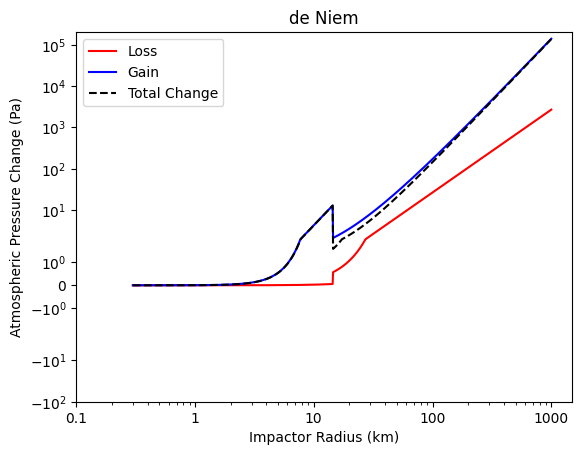

In [70]:
if verbiose==1:  
  #@title deniem plotting
  if numruns==1:
    if 'deniem' in mods.Nickname.values and outputdataunits=='mass' and atmchange==True:
      plt.scatter(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),deniem_M_loss,color='red',label='atm mass lost',s=3)#,marker='o')
      plt.scatter(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),deniem_M_gain,color='blue',label='atm mass gained',s=3)#,marker='o')
      plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),deniem_delta_M,color='black',label='tot atm mass change',linestyle='dashed')
      plt.legend()
      plt.title("de Niem")
      # plt.xscale('log')
      # plt.yscale('log')
      # plt.yscale('symlog')
      plt.xlabel('cumulative number of impacts')
      plt.ylabel('atm mass (kg)')

    if 'deniem' in mods.Nickname.values and outputdataunits=='pressure' and atmchange==True:
      # plt.scatter(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),deniem_P_loss,color='red',label='atm pressure lost',s=3)#,marker='o')
      # plt.scatter(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),deniem_P_gain,color='blue',label='atm pressure gained',s=3)#,marker='o')
      plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),deniem_delta_P,color='black',label='tot atm pressure change',linestyle='dashed')
      plt.axhline(atmmass_to_surfacepressure(r_planet,presentday_atm_m,gravity),color='gray', linestyle='dashed',label=f"{startingP} bar")
      plt.legend()
      plt.title("de Niem")
      # plt.xscale('log')
      # plt.yscale('log')
      # plt.yscale('symlog')
      plt.xlabel('cumulative number of impacts')
      plt.ylabel('atm pressure (Pa)')

    if 'deniem' in mods.Nickname.values and outputdataunits=='mass' and atmchange==False:
      plt.plot(r_imp_array,deniem_M_loss,color='red',label='atm mass lost')#,marker='o')
      plt.plot(r_imp_array,deniem_M_gain,color='blue',label='atm mass gained')#,marker='o')
      plt.plot(r_imp_array,deniem_delta_M,color='black',label='tot atm mass change',linestyle='dashed')
      plt.legend()
      plt.title("de Niem")
      plt.xscale('log')
      # plt.yscale('log')
      # plt.yscale('symlog')
      plt.xlabel('impactor radius (km)')
      plt.ylabel('mass change (kg)')
      plt.xticks(ticks=[0.1,1,10,100,1000],labels=[0.1,1,10,100,1000])

    if 'deniem' in mods.Nickname.values and outputdataunits=='pressure' and atmchange==False:
      r_imp_array,deniem_P_loss,deniem_P_gain,deniem_delta_P=sort3(deniemr_imp_array,deniem_P_loss,deniem_P_gain,deniem_delta_P)
      plt.plot(r_imp_array,deniem_P_loss,color='red',label='Loss')#,marker='o',linestyle='none')
      plt.plot(r_imp_array,deniem_P_gain,color='blue',label='Gain')#,marker='o',linestyle='none')
      plt.plot(r_imp_array,deniem_delta_P,color='black',label='Total Change',linestyle='dashed')
      # plt.axhline(atmmass_to_surfacepressure(r_planet,presentday_atm_m,gravity),color='gray', linestyle='dashed',label=f"{startingP} bar")
      plt.legend()
      plt.title("de Niem")
      plt.xscale('log')
      # plt.yscale('log')
      plt.yscale('symlog')
      plt.xlabel('Impactor Radius (km)')
      plt.ylabel('Atmospheric Pressure Change (Pa)')
      plt.xticks(ticks=[0.1,1,10,100,1000],labels=[0.1,1,10,100,1000])
      plt.ylim(-1e2,2e5)

  else:
    if 'deniem' in mods.Nickname.values and outputdataunits=='pressure':
      # plt.errorbar(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['shu'][1]['avg']),yerr=list(processeddatadict['shu'][1]['std']),color='red',label='atm pressure lost')
      # plt.errorbar(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['shu'][0]['avg']),yerr=list(processeddatadict['shu'][0]['std']),color='blue',label='atm pressure gained')
      plt.plot(np.linspace(1,numimps,numimps),list(processeddatadict['deniem'][2]['avg']),color='black',label='tot atm pressure change')
      plt.plot(np.linspace(1,numimps,numimps),list(processeddatadict['deniem'][2]['avg+std']),color='black',label='1σ', linestyle='dashed')
      plt.plot(np.linspace(1,numimps,numimps),list(processeddatadict['deniem'][2]['avg-std']),color='black', linestyle='dashed')
      plt.axhline(atmmass_to_surfacepressure(r_planet,presentday_atm_m,gravity),color='gray', linestyle='dotted',label=f"{startingP} bar")
      plt.legend()
      plt.title("de Niem")
      # plt.xscale('log')
      # plt.yscale('log')
      # plt.yscale('symlog')
      plt.xlabel('cumulative number of impacts')
      plt.ylabel('atm pressure (Pa)')

      #np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['shu'][2]['avg']

    elif 'deniem' in mods.Nickname.values and outputdataunits=='mass':
      # plt.errorbar(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['shu'][1]['avg']),yerr=list(processeddatadict['shu'][1]['std']),color='red',label='atm mass lost')
      # plt.errorbar(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['shu'][0]['avg']),yerr=list(processeddatadict['shu'][0]['std']),color='blue',label='atm mass gained')
      plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['deniem'][2]['avg']),color='black',label='tot atm mass change')
      plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['deniem'][2]['avg+std']),color='black',label='1σ', linestyle='dashed')
      plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['deniem'][2]['avg-std']),color='black', linestyle='dashed')
      plt.axhline(atmmass_to_surfacepressure(r_planet,presentday_atm_m,gravity),color='gray', linestyle='dotted',label=f"{startingP} bar")
      plt.legend()
      plt.title("de Niem")
      # plt.xscale('log')
      # plt.yscale('log')
      # plt.yscale('symlog')
      plt.xlabel('cumulative number of impacts')
      plt.ylabel('atm mass (kg)')

hilke plot

In [71]:
plt.rcdefaults()

In [72]:
print('hilke_delta_P:',hilke_delta_P)

hilke_delta_P: [np.float64(-5.3329575190637393e-11), np.float64(-5.464461112420094e-11), np.float64(-5.59920740834886e-11), np.float64(-5.73727636755456e-11), np.float64(-5.878749922465676e-11), np.float64(-6.02371202585467e-11), np.float64(-6.172248700656988e-11), np.float64(-6.324448091018522e-11), np.float64(-6.480400514601801e-11), np.float64(-6.640198516182001e-11), np.float64(-6.803936922564574e-11), np.float64(-6.971712898857047e-11), np.float64(-7.143626006128427e-11), np.float64(-7.31977826049041e-11), np.float64(-7.50027419363544e-11), np.float64(-7.685220914867547e-11), np.float64(-7.87472817466284e-11), np.float64(-8.068908429797235e-11), np.float64(-8.267876910080192e-11), np.float64(-8.471751686734037e-11), np.float64(-8.680653742459362e-11), np.float64(-8.894707043228216e-11), np.float64(-9.114038611847562e-11), np.float64(-9.338778603336732e-11), np.float64(-9.569060382163611e-11), np.float64(-9.805020601385333e-11), np.float64(-1.0046799283740487e-10), np.float64(-1.02

hilke_delta_P: (np.float64(-5.3329575190637393e-11), np.float64(-5.464461112420094e-11), np.float64(-5.59920740834886e-11), np.float64(-5.73727636755456e-11), np.float64(-5.878749922465676e-11), np.float64(-6.02371202585467e-11), np.float64(-6.172248700656988e-11), np.float64(-6.324448091018522e-11), np.float64(-6.480400514601801e-11), np.float64(-6.640198516182001e-11), np.float64(-6.803936922564574e-11), np.float64(-6.971712898857047e-11), np.float64(-7.143626006128427e-11), np.float64(-7.31977826049041e-11), np.float64(-7.50027419363544e-11), np.float64(-7.685220914867547e-11), np.float64(-7.87472817466284e-11), np.float64(-8.068908429797235e-11), np.float64(-8.267876910080192e-11), np.float64(-8.471751686734037e-11), np.float64(-8.680653742459362e-11), np.float64(-8.894707043228216e-11), np.float64(-9.114038611847562e-11), np.float64(-9.338778603336732e-11), np.float64(-9.569060382163611e-11), np.float64(-9.805020601385333e-11), np.float64(-1.0046799283740487e-10), np.float64(-1.02

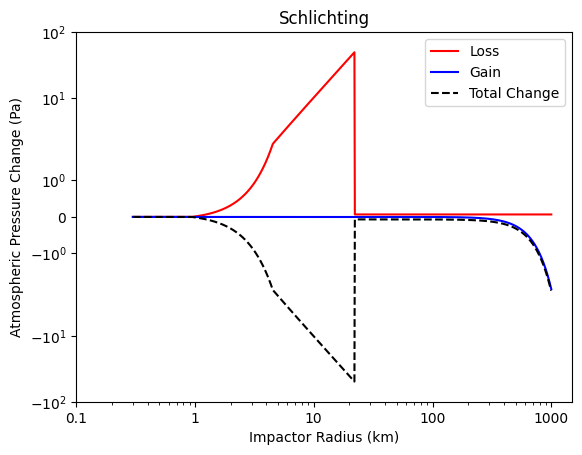

In [73]:
if verbiose==1: 
  #@title hilke plotting
  if numruns==1:
    if 'hilke' in mods.Nickname.values and outputdataunits=='mass' and atmchange==True:
      plt.scatter(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),hilke_M_loss,color='red',label='atm mass lost',s=3)#,marker='o')
      plt.scatter(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),hilke_M_gain,color='blue',label='atm mass gained',s=3)#,marker='o')
      plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),hilke_delta_M,color='black',label='tot atm mass change',linestyle='dashed')
      plt.legend()
      plt.title("Schlichting")
      # plt.xscale('log')
      # plt.yscale('log')
      # plt.yscale('symlog')
      plt.xlabel('cumulative number of impacts')
      plt.ylabel('atm mass (kg)')

    if 'hilke' in mods.Nickname.values and outputdataunits=='pressure' and atmchange==True:
      # plt.scatter(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),hilke_P_loss,color='red',label='atm pressure lost',s=3)#,marker='o')
      # plt.scatter(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),hilke_P_gain,color='blue',label='atm pressure gained',s=3)#,marker='o')
      plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),hilke_delta_P,color='black',label='tot atm pressure change',linestyle='dashed')
      plt.axhline(atmmass_to_surfacepressure(r_planet,presentday_atm_m,gravity),color='gray', linestyle='dashed',label=f"{startingP} bar")
      plt.legend()
      plt.title("Schlichting")
      # plt.xscale('log')
      # plt.yscale('log')
      # plt.yscale('symlog')
      plt.xlabel('cumulative number of impacts')
      plt.ylabel('atm pressure (Pa)')

    if 'hilke' in mods.Nickname.values and outputdataunits=='mass' and atmchange==False:
      plt.plot(r_imp_array,hilke_M_loss,color='red',label='atm mass lost')#,marker='o')
      plt.plot(r_imp_array,hilke_M_gain,color='blue',label='atm mass gained')#,marker='o')
      plt.plot(r_imp_array,hilke_delta_M,color='black',label='tot atm mass change',linestyle='dashed')
      plt.legend()
      plt.title("Schlichting")
      plt.xscale('log')
      # plt.yscale('log')
      # plt.yscale('symlog')
      plt.xlabel('impactor radius (km)')
      plt.ylabel('mass change (kg)')
      plt.xticks(ticks=[0.1,1,10,100,1000],labels=[0.1,1,10,100,1000])

    if 'hilke' in mods.Nickname.values and outputdataunits=='pressure' and atmchange==False:
      r_imp_array,hilke_P_loss,hilke_P_gain,hilke_delta_P=sort3(hilker_imp_array,hilke_P_loss,hilke_P_gain,hilke_delta_P)
      plt.plot(r_imp_array,hilke_P_loss,color='red',label='Loss')#,marker='o',linestyle='none')
      plt.plot(r_imp_array,hilke_P_gain,color='blue',label='Gain')#,marker='o',linestyle='none')
      plt.plot(r_imp_array,hilke_delta_P,color='black',label='Total Change',linestyle='dashed')
      # plt.axhline(atmmass_to_surfacepressure(r_planet,presentday_atm_m,gravity),color='gray', linestyle='dashed',label=f"{startingP} bar")
      plt.legend()
      plt.title("Schlichting")
      plt.xscale('log')
      # plt.yscale('log')
      plt.yscale('symlog')
      plt.xlabel('Impactor Radius (km)')
      plt.ylabel('Atmospheric Pressure Change (Pa)')
      plt.xticks(ticks=[0.1,1,10,100,1000],labels=[0.1,1,10,100,1000])
      plt.ylim(-1e2,1e2)
      print('hilke_delta_P:',hilke_delta_P)

  else:
    if 'hilke' in mods.Nickname.values and outputdataunits=='pressure':
      # plt.errorbar(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['shu'][1]['avg']),yerr=list(processeddatadict['shu'][1]['std']),color='red',label='atm pressure lost')
      # plt.errorbar(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['shu'][0]['avg']),yerr=list(processeddatadict['shu'][0]['std']),color='blue',label='atm pressure gained')
      plt.plot(np.linspace(1,numimps,numimps),list(processeddatadict['hilke'][2]['avg']),color='black',label='tot atm pressure change')
      plt.plot(np.linspace(1,numimps,numimps),list(processeddatadict['hilke'][2]['avg+std']),color='black',label='1σ', linestyle='dashed')
      plt.plot(np.linspace(1,numimps,numimps),list(processeddatadict['hilke'][2]['avg-std']),color='black', linestyle='dashed')
      plt.axhline(atmmass_to_surfacepressure(r_planet,presentday_atm_m,gravity),color='gray', linestyle='dotted',label=f"{startingP} bar")
      plt.legend()
      plt.title("Schlichting")
      # plt.xscale('log')
      # plt.yscale('log')
      # plt.yscale('symlog')
      plt.xlabel('cumulative number of impacts')
      plt.ylabel('atm pressure (Pa)')

      #np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['shu'][2]['avg']

    elif 'hilke' in mods.Nickname.values and outputdataunits=='mass':
      # plt.errorbar(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['shu'][1]['avg']),yerr=list(processeddatadict['shu'][1]['std']),color='red',label='atm mass lost')
      # plt.errorbar(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['shu'][0]['avg']),yerr=list(processeddatadict['shu'][0]['std']),color='blue',label='atm mass gained')
      plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['hilke'][2]['avg']),color='black',label='tot atm mass change')
      plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['hilke'][2]['avg+std']),color='black',label='1σ', linestyle='dashed')
      plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['hilke'][2]['avg-std']),color='black', linestyle='dashed')
      plt.axhline(atmmass_to_surfacepressure(r_planet,presentday_atm_m,gravity),color='gray', linestyle='dotted',label=f"{startingP} bar")
      plt.legend()
      plt.title("Schlichting")
      # plt.xscale('log')
      # plt.yscale('log')
      # plt.yscale('symlog')
      plt.xlabel('cumulative number of impacts')
      plt.ylabel('atm mass (kg)')

shuvalov plot

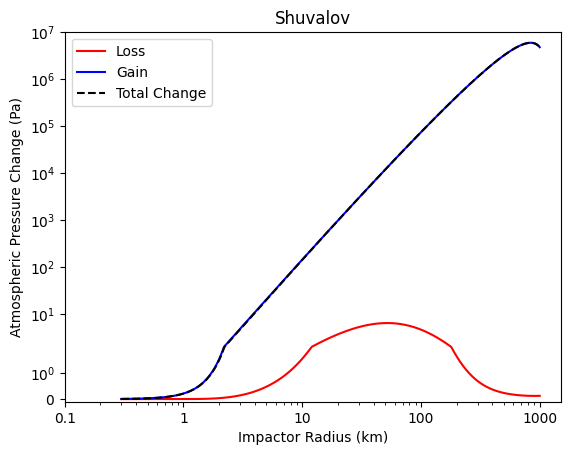

In [74]:
if verbiose==1: 
  #@title shuvalov plotting
  if numruns==1:
    if 'shu' in mods.Nickname.values and outputdataunits=='mass' and atmchange==True:
      plt.scatter(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),shu_M_loss,color='red',label='atm mass lost',s=3)#,marker='o')
      plt.scatter(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),shu_M_gain,color='blue',label='atm mass gained',s=3)#,marker='o')
      plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),shu_delta_M,color='black',label='tot atm mass change',linestyle='dashed')
      plt.legend()
      plt.title("Shuvalov")
      # plt.xscale('log')
      # plt.yscale('log')
      # plt.yscale('symlog')
      plt.xlabel('cumulative number of impacts')
      plt.ylabel('atm mass (kg)')

    if 'shu' in mods.Nickname.values and outputdataunits=='pressure' and atmchange==True:
      # plt.scatter(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),shu_P_loss,color='red',label='atm pressure lost',s=3)#,marker='o')
      # plt.scatter(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),shu_P_gain,color='blue',label='atm pressure gained',s=3)#,marker='o')
      plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),shu_delta_P,color='black',label='tot atm pressure change',linestyle='dashed')
      plt.axhline(atmmass_to_surfacepressure(r_planet,presentday_atm_m,gravity),color='gray', linestyle='dashed',label=f"{startingP} bar")
      plt.legend()
      plt.title("Shuvalov")
      # plt.xscale('log')
      # plt.yscale('log')
      # plt.yscale('symlog')
      plt.xlabel('cumulative number of impacts')
      plt.ylabel('atm pressure (Pa)')

    if 'shu' in mods.Nickname.values and outputdataunits=='mass' and atmchange==False:
      plt.plot(r_imp_array,shu_M_loss,color='red',label='atm mass lost')#,marker='o')
      plt.plot(r_imp_array,shu_M_gain,color='blue',label='atm mass gained')#,marker='o')
      plt.plot(r_imp_array,shu_delta_M,color='black',label='tot atm mass change',linestyle='dashed')
      plt.legend()
      plt.title("Shuvalov")
      plt.xscale('log')
      # plt.yscale('log')
      # plt.yscale('symlog')
      plt.xlabel('impactor radius (km)')
      plt.ylabel('mass change (kg)')
      plt.xticks(ticks=[0.1,1,10,100,1000],labels=[0.1,1,10,100,1000])

    if 'shu' in mods.Nickname.values and outputdataunits=='pressure' and atmchange==False:
      r_imp_array,shu_P_loss,shu_P_gain,shu_delta_P=sort3(shur_imp_array,shu_P_loss,shu_P_gain,shu_delta_P)
      plt.plot(r_imp_array,shu_P_loss,color='red',label='Loss')#,marker='o',linestyle='none')
      plt.plot(r_imp_array,shu_P_gain,color='blue',label='Gain')#,marker='o',linestyle='none')
      plt.plot(r_imp_array,shu_delta_P,color='black',label='Total Change',linestyle='dashed')
      # plt.axhline(atmmass_to_surfacepressure(r_planet,presentday_atm_m,gravity),color='gray', linestyle='dashed',label=f"{startingP} bar")
      plt.legend()
      plt.title("Shuvalov")
      plt.xscale('log')
      # plt.yscale('log')
      plt.yscale('symlog')
      plt.xlabel('Impactor Radius (km)')
      plt.ylabel('Atmospheric Pressure Change (Pa)')
      plt.xticks(ticks=[0.1,1,10,100,1000],labels=[0.1,1,10,100,1000])
      plt.ylim(-0.1,1e7)

  else:
    if 'shu' in mods.Nickname.values and outputdataunits=='pressure':
      # plt.errorbar(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['shu'][1]['avg']),yerr=list(processeddatadict['shu'][1]['std']),color='red',label='atm pressure lost')
      # plt.errorbar(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['shu'][0]['avg']),yerr=list(processeddatadict['shu'][0]['std']),color='blue',label='atm pressure gained')
      plt.plot(np.linspace(1,numimps,numimps),list(processeddatadict['shu'][2]['avg']),color='black',label='tot atm pressure change')
      plt.plot(np.linspace(1,numimps,numimps),list(processeddatadict['shu'][2]['avg+std']),color='black',label='1σ', linestyle='dashed')
      plt.plot(np.linspace(1,numimps,numimps),list(processeddatadict['shu'][2]['avg-std']),color='black', linestyle='dashed')
      plt.axhline(atmmass_to_surfacepressure(r_planet,presentday_atm_m,gravity),color='gray', linestyle='dotted',label=f"{startingP} bar")
      plt.legend()
      plt.title("Shuvalov")
      # plt.xscale('log')
      # plt.yscale('log')
      # plt.yscale('symlog')
      plt.xlabel('cumulative number of impacts')
      plt.ylabel('atm pressure (Pa)')

      #np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['shu'][2]['avg']

    elif 'shu' in mods.Nickname.values and outputdataunits=='mass':
      # plt.errorbar(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['shu'][1]['avg']),yerr=list(processeddatadict['shu'][1]['std']),color='red',label='atm mass lost')
      # plt.errorbar(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['shu'][0]['avg']),yerr=list(processeddatadict['shu'][0]['std']),color='blue',label='atm mass gained')
      plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['shu'][2]['avg']),color='black',label='tot atm mass change')
      plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['shu'][2]['avg+std']),color='black',label='1σ', linestyle='dashed')
      plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['shu'][2]['avg-std']),color='black', linestyle='dashed')
      plt.axhline(atmmass_to_surfacepressure(r_planet,presentday_atm_m,gravity),color='gray', linestyle='dotted',label=f"{startingP} bar")
      plt.legend()
      plt.title("Shuvalov")
      # plt.xscale('log')
      # plt.yscale('log')
      # plt.yscale('symlog')
      plt.xlabel('cumulative number of impacts')
      plt.ylabel('atm mass (kg)')

pham plots

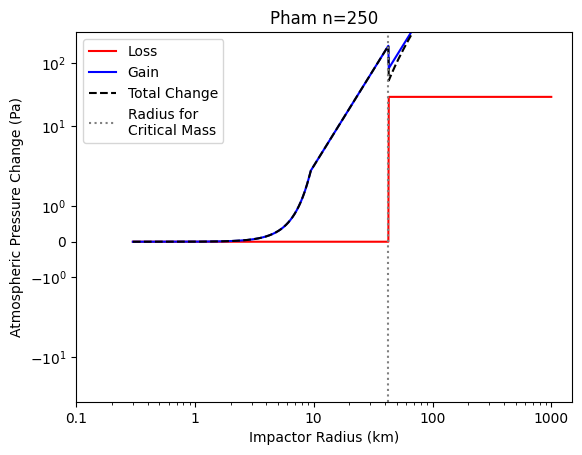

In [75]:
if verbiose==1: 
  #@title generic pham plotting
  if numruns==1:
    if 'pham' in mods.Nickname.values and outputdataunits=='mass' and atmchange==True:
      plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),pham_M_loss,color='red',label='atm mass lost')#,marker='o')
      plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),pham_M_gain,color='blue',label='atm mass gained')#,marker='o')
      plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),pham_delta_M,color='black',label='tot atm mass change',linestyle='dashed')
      # plt.axvline(pham_corresponding_crit_imp_r, color='gray',label='r_imp for m_crit',linestyle='dotted')
      plt.legend()
      plt.title("Pham n="+str(round(n)))
      # plt.xscale('log')
      # plt.yscale('log')
      # plt.yscale('symlog')
      plt.xlabel('cumulative number of impacts')
      plt.ylabel('mass change (kg)')

    if 'pham' in mods.Nickname.values and outputdataunits=='pressure' and atmchange==True:
      # plt.scatter(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),pham_P_gain,color='blue',label='atm pressure gained',s=3)#,marker='o')
      # plt.scatter(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),pham_P_loss,color='red',label='atm pressure lost',s=3)#,marker='o')
      plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),pham_delta_P,color='black',label='tot atm pressure change',linestyle='dashed')
      plt.axhline(atmmass_to_surfacepressure(r_planet,presentday_atm_m,gravity),color='gray', linestyle='dashed',label=f"{startingP} bar")
      plt.legend()
      plt.title("Pham n="+str(round(n)))
      # plt.xscale('log')
      # plt.yscale('log')
      # plt.yscale('symlog')
      plt.xlabel('cumulative number of impacts')
      plt.ylabel('pressure change (Pa)')

    if 'pham' in mods.Nickname.values and outputdataunits=='mass' and atmchange==False:
      plt.plot(r_imp_array,pham_M_loss,color='red',label='atm mass lost')#,marker='o')
      plt.plot(r_imp_array,pham_M_gain,color='blue',label='atm mass gained')#,marker='o')
      plt.plot(r_imp_array,pham_delta_M,color='black',label='tot atm mass change',linestyle='dashed')
      plt.axvline(pham_corresponding_crit_imp_r, color='gray',label='r_imp for m_crit',linestyle='dotted')
      plt.legend()
      plt.title("Pham n="+str(round(n)))
      plt.xscale('log')
      # plt.yscale('log')
      # plt.yscale('symlog')
      plt.xlabel('impactor radius (km)')
      plt.ylabel('mass change (kg)')
      plt.xticks(ticks=[0.1,1,10,100,1000],labels=[0.1,1,10,100,1000])

    if 'pham' in mods.Nickname.values and outputdataunits=='pressure' and atmchange==False:
      r_imp_array,pham_P_loss,pham_P_gain,pham_delta_P=sort3(phamr_imp_array,pham_P_loss,pham_P_gain,pham_delta_P)
      plt.plot(r_imp_array,pham_P_loss,color='red',label='Loss')#,marker='o')
      plt.plot(r_imp_array,pham_P_gain,color='blue',label='Gain')#,marker='o')
      plt.plot(r_imp_array,pham_delta_P,color='black',label='Total Change',linestyle='dashed')
      plt.axvline(pham_corresponding_crit_imp_r, color='gray',label='Radius for\nCritical Mass',linestyle='dotted')
      # plt.axhline(atmmass_to_surfacepressure(r_planet,presentday_atm_m,gravity),color='gray', linestyle='dashed',label=f"{startingP} bar")
      plt.legend()
      plt.title("Pham n="+str(round(n)))
      plt.xscale('log')
      # plt.xlim(0.09,0.2)
      # plt.ylim(-1,1.5e7)
      # plt.yscale('log')
      plt.yscale('symlog')
      plt.ylim(-0.5e2, 3e2)
      plt.xlabel('Impactor Radius (km)')
      plt.ylabel('Atmospheric Pressure Change (Pa)')
      plt.xticks(ticks=[0.1,1,10,100,1000],labels=[0.1,1,10,100,1000])

  else:
    if 'pham' in mods.Nickname.values and outputdataunits=='pressure':
      # plt.errorbar(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['pham'][1]['avg']),yerr=list(processeddatadict['pham'][1]['std']),color='red',label='atm pressure lost')
      # plt.errorbar(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['pham'][0]['avg']),yerr=list(processeddatadict['pham'][0]['std']),color='blue',label='atm pressure gained')
      plt.plot(np.linspace(1,numimps,numimps),list(processeddatadict['pham250'][2]['avg']),color='black',label='tot atm pressure change')
      plt.plot(np.linspace(1,numimps,numimps),list(processeddatadict['pham250'][2]['avg+std']),color='black',label='1σ', linestyle='dashed')
      plt.plot(np.linspace(1,numimps,numimps),list(processeddatadict['pham250'][2]['avg-std']),color='black', linestyle='dashed')
      plt.axhline(atmmass_to_surfacepressure(r_planet,presentday_atm_m,gravity),color='gray', linestyle='dotted',label=f"{startingP} bar")
      plt.legend()
      plt.title("Pham n="+str(round(n)))
      # plt.xscale('log')
      # plt.yscale('log')
      # plt.yscale('symlog')
      plt.xlabel('cumulative number of impacts')
      plt.ylabel('atm pressure (Pa)')

    elif 'pham' in mods.Nickname.values and outputdataunits=='mass':
      # plt.errorbar(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['pham'][1]['avg']),yerr=list(processeddatadict['pham'][1]['std']),color='red',label='atm mass lost')
      # plt.errorbar(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['pham'][0]['avg']),yerr=list(processeddatadict['pham'][0]['std']),color='blue',label='atm mass gained')
      plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['pham'][2]['avg']),color='black',label='tot atm mass change')
      plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['pham'][2]['avg+std']),color='black',label='1σ', linestyle='dashed')
      plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['pham'][2]['avg-std']),color='black', linestyle='dashed')
      plt.axhline(atmmass_to_surfacepressure(r_planet,presentday_atm_m,gravity),color='gray', linestyle='dotted',label=f"{startingP} bar")
      plt.legend()
      plt.title("Pham n="+str(round(n)))
      # plt.xscale('log')
      # plt.yscale('log')
      # plt.yscale('symlog')
      plt.xlabel('cumulative number of impacts')
      plt.ylabel('atm mass (kg)')

Genda and Abe plot

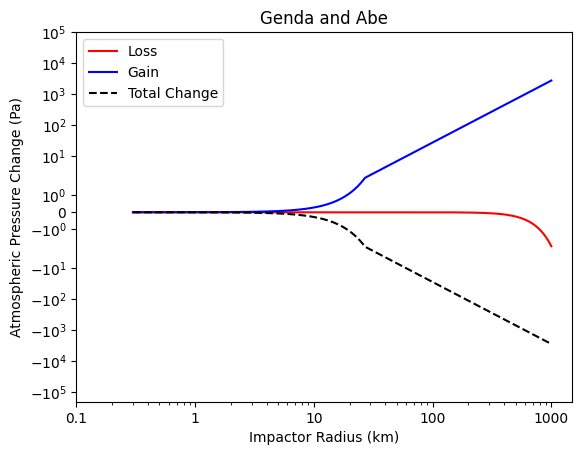

In [76]:
if verbiose==1: 
  #@title genda and abe plotting
  if numruns==1:
    if 'ga' in mods.Nickname.values and outputdataunits=='mass' and atmchange==False:
      plt.plot(r_imp_array,ga_M_loss,color='red',label='atm mass lost')#,marker='o')
      plt.plot(r_imp_array,ga_M_gain,color='blue',label='atm mass gained')#,marker='o')
      plt.plot(r_imp_array,ga_delta_M,color='black',label='tot atm mass change',linestyle='dashed')
      if str(mods.loc[mods['Model Name'] == 'Genda and Abe'].values.tolist()[0][3])=='pham':
        plt.axvline(ga_corresponding_crit_imp_r, color='gray',label='r_imp for m_crit',linestyle='dotted')
      plt.legend()
      plt.title("Genda and Abe")
      plt.xscale('log')
      # plt.yscale('log')
      # plt.yscale('symlog')
      plt.xlabel('impactor radius (km)')
      plt.ylabel('mass change (kg)')
      # plt.ylim(-3.2e6,5e6)
      plt.xticks(ticks=[0.1,1,10,100,1000],labels=[0.1,1,10,100,1000])

    if 'ga' in mods.Nickname.values and outputdataunits=='mass' and atmchange==True:
      plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),ga_M_loss,color='red',label='atm mass lost')#,marker='o')
      plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),ga_M_gain,color='blue',label='atm mass gained')#,marker='o')
      plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),ga_delta_M,color='black',label='tot atm mass change',linestyle='dashed')
      # plt.axvline(ga_corresponding_crit_imp_r, color='gray',label='r_imp for m_crit',linestyle='dotted')
      plt.legend()
      plt.title("Genda and Abe")
      # plt.xscale('log')
      # plt.yscale('log')
      # plt.yscale('symlog')
      plt.xlabel('cumulative number of impacts')
      plt.ylabel('mass change (kg)')

    if 'ga' in mods.Nickname.values and outputdataunits=='pressure' and atmchange==True:
      # plt.scatter(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),ga_P_gain,color='blue',label='atm pressure gained',s=3)#,marker='o')
      # plt.scatter(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),ga_P_loss,color='red',label='atm pressure lost',s=3)#,marker='o')
      plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),ga_delta_P,color='black',label='tot atm pressure change',linestyle='dashed')
      plt.axhline(atmmass_to_surfacepressure(r_planet,presentday_atm_m,gravity),color='gray', linestyle='dashed',label=f"{startingP} bar")
      plt.legend()
      plt.title("Genda and Abe")
      # plt.xscale('log')
      # plt.yscale('log')
      # plt.yscale('symlog')
      plt.xlabel('cumulative number of impacts')
      plt.ylabel('pressure change (Pa)')

    if 'ga' in mods.Nickname.values and outputdataunits=='pressure' and atmchange==False:
      r_imp_array,ga_P_gain,ga_P_loss,ga_delta_P=sort3(gar_imp_array,ga_P_gain,ga_P_loss,ga_delta_P)
      plt.plot(r_imp_array,ga_P_gain,color='red',label='Loss')#,marker='o')
      plt.plot(r_imp_array,ga_P_loss,color='blue',label='Gain')#,marker='o')
      # plt.scatter(r_imp_array[-1],atmmass_to_surfacepressure(r_planet,M_imp(rho_imp,r_imp_array[-1])*y_imp,9.8))
      plt.plot(r_imp_array,ga_delta_P,color='black',label='Total Change',linestyle='dashed')
      # plt.axvline(ga_corresponding_crit_imp_r, color='gray',label='r_imp for m_crit',linestyle='dotted')
      # plt.axhline(atmmass_to_surfacepressure(r_planet,presentday_atm_m,gravity),color='gray', linestyle='dashed',label=f"{startingP} bar")
      # plt.axhline(-atmmass_to_surfacepressure(r_planet,presentday_atm_m,gravity),color='gray', linestyle='dashed')
      plt.legend()
      plt.title("Genda and Abe")
      plt.xscale('log')
      # plt.yscale('log')
      plt.yscale('symlog')
      plt.xlabel('Impactor Radius (km)')
      plt.ylabel('Atmospheric Pressure Change (Pa)')
      plt.ylim(-2e5,1e5)
      # plt.ylim(-6e-5,0)
      # print(atmmass_to_surfacepressure(r_planet,M_imp(rho_imp,r_imp_array[-1])*y_imp,9.8))
      plt.xticks(ticks=[0.1,1,10,100,1000],labels=[0.1,1,10,100,1000])

  else:
    if 'ga' in mods.Nickname.values and outputdataunits=='pressure':
      # plt.errorbar(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['ga'][1]['avg']),yerr=list(processeddatadict['ga'][1]['std']),color='red',label='atm pressure lost')
      # plt.errorbar(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['ga'][0]['avg']),yerr=list(processeddatadict['ga'][0]['std']),color='blue',label='atm pressure gained')
      plt.plot(np.linspace(1,numimps,numimps),list(processeddatadict['ga'][2]['avg']),color='black',label='tot atm pressure change')
      plt.plot(np.linspace(1,numimps,numimps),list(processeddatadict['ga'][2]['avg+std']),color='black',label='1σ', linestyle='dashed')
      plt.plot(np.linspace(1,numimps,numimps),list(processeddatadict['ga'][2]['avg-std']),color='black', linestyle='dashed')
      plt.axhline(atmmass_to_surfacepressure(r_planet,presentday_atm_m,gravity),color='gray', linestyle='dotted',label=f"{startingP} bar")
      plt.legend()
      plt.title("Genda & Abe")
      # plt.xscale('log')
      # plt.yscale('log')
      # plt.yscale('symlog')
      plt.xlabel('cumulative number of impacts')
      plt.ylabel('atm pressure (Pa)')

    elif 'ga' in mods.Nickname.values and outputdataunits=='mass':
      # plt.errorbar(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['ga'][1]['avg']),yerr=list(processeddatadict['ga'][1]['std']),color='red',label='atm mass lost')
      # plt.errorbar(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['ga'][0]['avg']),yerr=list(processeddatadict['ga'][0]['std']),color='blue',label='atm mass gained')
      plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['ga'][2]['avg']),color='black',label='tot atm mass change')
      plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['ga'][2]['avg+std']),color='black',label='1σ', linestyle='dashed')
      plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['ga'][2]['avg-std']),color='black', linestyle='dashed')
      plt.axhline(atmmass_to_surfacepressure(r_planet,presentday_atm_m,gravity),color='gray', linestyle='dotted',label=f"{startingP} bar")
      plt.legend()
      plt.title("Genda & Abe")
      # plt.xscale('log')
      # plt.yscale('log')
      # plt.yscale('symlog')
      plt.xlabel('cumulative number of impacts')
      plt.ylabel('atm mass (kg)')

kerr plot

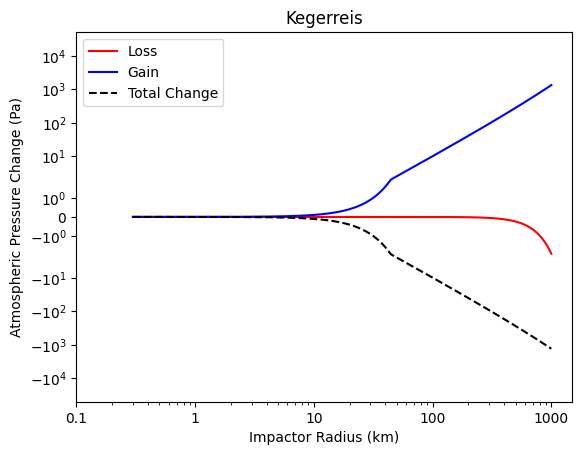

In [77]:
if verbiose==1: 
  #@title kerr plotting
  if numruns==1:
    if 'kerr' in mods.Nickname.values and outputdataunits=='mass' and atmchange==False:
      plt.plot(r_imp_array,kerr_M_loss,color='red',label='atm mass lost')#,marker='o')
      plt.plot(r_imp_array,kerr_M_gain,color='blue',label='atm mass gained')#,marker='o')
      plt.plot(r_imp_array,kerr_delta_M,color='black',label='tot atm mass change',linestyle='dashed')
      # if str(mods.loc[mods['Model Name'] == 'Kegerreis'].values.tolist()[0][3])=='pham':
      #   plt.axvline(kerr_corresponding_crit_imp_r, color='gray',label='r_imp for m_crit',linestyle='dotted')
      plt.legend()
      plt.title("Kegerreis")
      plt.xscale('log')
      # plt.yscale('log')
      # plt.yscale('symlog')
      plt.xlabel('impactor radius (km)')
      plt.ylabel('mass change (kg)')
      # plt.ylim(-3.2e6,5e6)
      plt.xticks(ticks=[0.1,1,10,100,1000],labels=[0.1,1,10,100,1000])

    if 'kerr' in mods.Nickname.values and outputdataunits=='mass' and atmchange==True:
      plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),kerr_M_loss,color='red',label='atm mass lost')#,marker='o')
      plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),kerr_M_gain,color='blue',label='atm mass gained')#,marker='o')
      plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),kerr_delta_M,color='black',label='tot atm mass change',linestyle='dashed')
      plt.legend()
      plt.title("Kegerreis")
      # plt.xscale('log')
      # plt.yscale('log')
      # plt.yscale('symlog')
      plt.xlabel('cumulative number of impacts')
      plt.ylabel('mass change (kg)')

    if 'kerr' in mods.Nickname.values and outputdataunits=='pressure' and atmchange==True:
      plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),kerr_delta_P,color='black',label='tot atm pressure change',linestyle='dashed')
      plt.axhline(atmmass_to_surfacepressure(r_planet,presentday_atm_m,gravity),color='gray', linestyle='dashed',label=f"{startingP} bar")
      plt.legend()
      plt.title("Kegerreis")
      # plt.xscale('log')
      # plt.yscale('log')
      # plt.yscale('symlog')
      plt.xlabel('cumulative number of impacts')
      plt.ylabel('pressure change (Pa)')

    if 'kerr' in mods.Nickname.values and outputdataunits=='pressure' and atmchange==False:
      r_imp_array,kerr_P_gain,kerr_P_loss,kerr_delta_P=sort3(kerrr_imp_array,kerr_P_gain,kerr_P_loss,kerr_delta_P)
      plt.plot(r_imp_array,kerr_P_gain,color='red',label='Loss')#,marker='o')
      plt.plot(r_imp_array,kerr_P_loss,color='blue',label='Gain')#,marker='o')
      # plt.scatter(r_imp_array[-1],atmmass_to_surfacepressure(r_planet,M_imp(rho_imp,r_imp_array[-1])*y_imp,9.8))
      plt.plot(r_imp_array,kerr_delta_P,color='black',label='Total Change',linestyle='dashed')
      # plt.axvline(kerr_corresponding_crit_imp_r, color='gray',label='r_imp for m_crit',linestyle='dotted')
      # plt.axhline(atmmass_to_surfacepressure(r_planet,presentday_atm_m,gravity),color='gray', linestyle='dashed',label=f"{startingP} bar")
      # plt.axhline(-atmmass_to_surfacepressure(r_planet,presentday_atm_m,gravity),color='gray', linestyle='dashed')
      plt.legend()
      plt.title("Kegerreis")
      plt.xscale('log')
      # plt.yscale('log')
      plt.yscale('symlog')
      plt.xlabel('Impactor Radius (km)')
      plt.ylabel('Atmospheric Pressure Change (Pa)')
      plt.ylim(-5e4,5e4)
      # plt.ylim(-6e-5,0)
      # print(atmmass_to_surfacepressure(r_planet,M_imp(rho_imp,r_imp_array[-1])*y_imp,9.8))
      plt.xticks(ticks=[0.1,1,10,100,1000],labels=[0.1,1,10,100,1000])

  else:
    if 'kerr' in mods.Nickname.values and outputdataunits=='pressure':
      # plt.errorbar(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['ga'][1]['avg']),yerr=list(processeddatadict['ga'][1]['std']),color='red',label='atm pressure lost')
      # plt.errorbar(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['ga'][0]['avg']),yerr=list(processeddatadict['ga'][0]['std']),color='blue',label='atm pressure gained')
      plt.plot(np.linspace(1,numimps,numimps),list(processeddatadict['kerr'][2]['avg']),color='black',label='tot atm pressure change')
      plt.plot(np.linspace(1,numimps,numimps),list(processeddatadict['kerr'][2]['avg+std']),color='black',label='1σ', linestyle='dashed')
      plt.plot(np.linspace(1,numimps,numimps),list(processeddatadict['kerr'][2]['avg-std']),color='black', linestyle='dashed')
      plt.axhline(atmmass_to_surfacepressure(r_planet,presentday_atm_m,gravity),color='gray', linestyle='dotted',label=f"{startingP} bar")
      plt.legend()
      plt.title("Kegerreis")
      # plt.xscale('log')
      # plt.yscale('log')
      # plt.yscale('symlog')
      plt.xlabel('cumulative number of impacts')
      plt.ylabel('atm pressure (Pa)')

    elif 'kerr' in mods.Nickname.values and outputdataunits=='mass':
      # plt.errorbar(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['ga'][1]['avg']),yerr=list(processeddatadict['ga'][1]['std']),color='red',label='atm mass lost')
      # plt.errorbar(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['ga'][0]['avg']),yerr=list(processeddatadict['ga'][0]['std']),color='blue',label='atm mass gained')
      plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['kerr'][2]['avg']),color='black',label='tot atm mass change')
      plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['kerr'][2]['avg+std']),color='black',label='1σ', linestyle='dashed')
      plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['kerr'][2]['avg-std']),color='black', linestyle='dashed')
      plt.axhline(atmmass_to_surfacepressure(r_planet,presentday_atm_m,gravity),color='gray', linestyle='dotted',label=f"{startingP} bar")
      plt.legend()
      plt.title("Kegerreis")
      # plt.xscale('log')
      # plt.yscale('log')
      # plt.yscale('symlog')
      plt.xlabel('cumulative number of impacts')
      plt.ylabel('atm mass (kg)')

svetsov 2000 plot

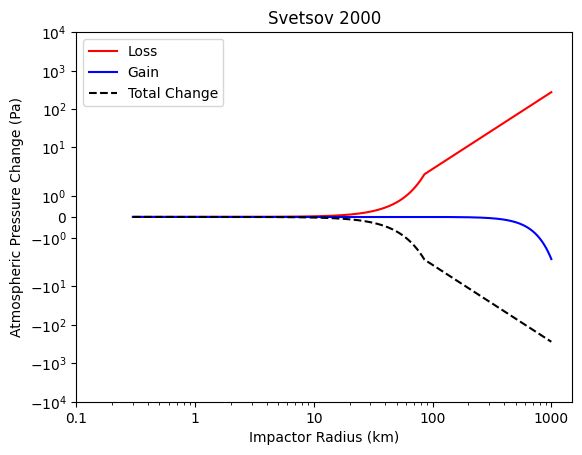

In [78]:
if verbiose==1: 
  #@title svet 2000 plotting
  if numruns==1:
    if 'svet' in mods.Nickname.values and outputdataunits=='mass' and atmchange==False:
      plt.plot(r_imp_array,svet_M_loss,color='red',label='atm mass lost')#,marker='o')
      plt.plot(r_imp_array,svet_M_gain,color='blue',label='atm mass gained')#,marker='o')
      plt.plot(r_imp_array,svet_delta_M,color='black',label='tot atm mass change',linestyle='dashed')
      if str(mods.loc[mods['Model Name'] == 'Svetsov 2000'].values.tolist()[0][3])=='pham':
        plt.axvline(svet_corresponding_crit_imp_r, color='gray',label='r_imp for m_crit',linestyle='dotted')
      plt.legend()
      plt.title("Svetsov 2000")
      plt.xscale('log')
      # plt.yscale('log')
      # plt.yscale('symlog')
      plt.xlabel('impactor radius (km)')
      plt.ylabel('mass change (kg)')
      # plt.ylim(-3.2e6,5e6)
      plt.xticks(ticks=[0.1,1,10,100,1000],labels=[0.1,1,10,100,1000])

    if 'svet' in mods.Nickname.values and outputdataunits=='mass' and atmchange==True:
      # plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),svet_M_loss,color='red',label='atm mass lost')#,marker='o')
      # plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),svet_M_gain,color='blue',label='atm mass gained')#,marker='o')
      plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),svet_delta_M,color='black',label='tot atm mass change',linestyle='dashed')
      plt.legend()
      plt.title("Svetsov 2000")
      # plt.xscale('log')
      # plt.yscale('log')
      # plt.yscale('symlog')
      plt.xlabel('cumulative number of impacts')
      plt.ylabel('mass change (kg)')
      plt.xlim(0.15,0.5)
      plt.ylim(-0.3e11,3.5e11)


    if 'svet' in mods.Nickname.values and outputdataunits=='pressure' and atmchange==True:
      # plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),svet_P_loss,color='red',label='atm pressure lost')#,marker='o')
      # plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),svet_P_gain,color='blue',label='atm pressure gained')#,marker='o')
      plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),svet_delta_P,color='black',label='tot atm pressure change',linestyle='dashed')
      plt.axhline(atmmass_to_surfacepressure(r_planet,presentday_atm_m,gravity),color='gray', linestyle='dashed',label=f"{startingP} bar")
      # plt.axhline(-atmmass_to_surfacepressure(r_planet,presentday_atm_m,gravity),color='gray', linestyle='dashed')
      plt.legend()
      plt.title("Svetsov 2000")
      # plt.xscale('log')
      # plt.yscale('log')
      # plt.yscale('symlog')
      plt.xlabel('cumulative number of impacts')
      plt.ylabel('pressure change (Pa)')
      # plt.xlim(0.15,1.25)
      # plt.ylim(-5e-6,5e-6)
      # plt.xticks(ticks=[0.1,1,10,100,1000],labels=[0.1,1,10,100,1000])

    if 'svet' in mods.Nickname.values and outputdataunits=='pressure' and atmchange==False:
      r_imp_array,svet_P_loss,svet_P_loss,svet_delta_P=sort3(svetr_imp_array,svet_P_loss,svet_P_loss,svet_delta_P)
      plt.plot(r_imp_array,svet_P_loss,color='red',label='Loss')#,marker='o')
      plt.plot(r_imp_array,svet_P_gain,color='blue',label='Gain')#,marker='o')
      plt.plot(r_imp_array,svet_delta_P,color='black',label='Total Change',linestyle='dashed')
      # plt.axhline(atmmass_to_surfacepressure(r_planet,presentday_atm_m,gravity),color='gray', linestyle='dashed',label=f"{startingP} bar")
      # plt.axhline(-atmmass_to_surfacepressure(r_planet,presentday_atm_m,gravity),color='gray', linestyle='dashed')
      plt.legend()
      plt.title("Svetsov 2000")
      plt.xscale('log')
      # plt.xlim(0.09,0.2)
      # plt.ylim(-13,13)
      # plt.yscale('log')
      plt.yscale('symlog')
      plt.ylim(-1e4,1e4)
      plt.xlabel('Impactor Radius (km)')
      plt.ylabel('Atmospheric Pressure Change (Pa)')
      plt.xticks(ticks=[0.1,1,10,100,1000],labels=[0.1,1,10,100,1000])

  else:
    if 'svet' in mods.Nickname.values and outputdataunits=='pressure':
      # plt.errorbar(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['svet'][1]['avg']),yerr=list(processeddatadict['svet'][1]['std']),color='red',label='atm pressure lost')
      # plt.errorbar(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['svet'][0]['avg']),yerr=list(processeddatadict['svet'][0]['std']),color='blue',label='atm pressure gained')
      plt.plot(np.linspace(1,numimps,numimps),list(processeddatadict['svet'][2]['avg']),color='black',label='tot atm pressure change')
      plt.plot(np.linspace(1,numimps,numimps),list(processeddatadict['svet'][2]['avg+std']),color='black',label='1σ', linestyle='dashed')
      plt.plot(np.linspace(1,numimps,numimps),list(processeddatadict['svet'][2]['avg-std']),color='black', linestyle='dashed')
      plt.axhline(atmmass_to_surfacepressure(r_planet,presentday_atm_m,gravity),color='gray', linestyle='dotted',label=f"{startingP} bar")
      plt.legend()
      plt.title("Svetsov 2000")
      # plt.xscale('log')
      # plt.yscale('log')
      # plt.yscale('symlog')
      plt.xlabel('cumulative number of impacts')
      plt.ylabel('atm pressure (Pa)')

    elif 'svet' in mods.Nickname.values and outputdataunits=='mass':
      # plt.errorbar(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['svet'][1]['avg']),yerr=list(processeddatadict['svet'][1]['std']),color='red',label='atm mass lost')
      # plt.errorbar(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['svet'][0]['avg']),yerr=list(processeddatadict['svet'][0]['std']),color='blue',label='atm mass gained')
      plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['svet'][2]['avg']),color='black',label='tot atm mass change')
      plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['svet'][2]['avg+std']),color='black',label='1σ', linestyle='dashed')
      plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['svet'][2]['avg-std']),color='black', linestyle='dashed')
      plt.axhline(atmmass_to_surfacepressure(r_planet,presentday_atm_m,gravity),color='gray', linestyle='dotted',label=f"{startingP} bar")
      plt.legend()
      plt.title("Svetsov 2000")
      # plt.xscale('log')
      # plt.yscale('log')
      # plt.yscale('symlog')
      plt.xlabel('cumulative number of impacts')
      plt.ylabel('atm mass (kg)')

svetsov 2007 plots

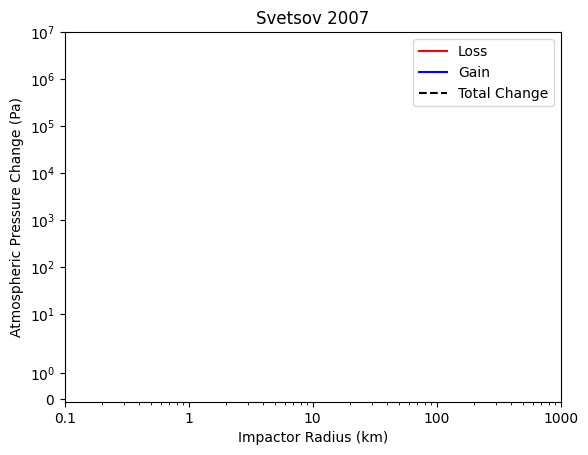

In [79]:
if verbiose==1: 
  #@title svet 2007 plotting
  if numruns==1:
    if 'svet07' in mods.Nickname.values and outputdataunits=='mass' and atmchange==False:
      plt.plot(r_imp_array,svet07_M_loss,color='red',label='atm mass lost')#,marker='o')
      plt.plot(r_imp_array,svet07_M_gain,color='blue',label='atm mass gained')#,marker='o')
      plt.plot(r_imp_array,svet07_delta_M,color='black',label='tot atm mass change',linestyle='dashed')
      plt.legend()
      plt.title("Svetsov 2007")
      plt.xscale('log')
      # plt.yscale('log')
      # plt.yscale('symlog')
      plt.xlabel('impactor radius (km)')
      plt.ylabel('mass change (kg)')
      # plt.ylim(-3.2e6,5e6)
      plt.xticks(ticks=[0.1,1,10,100,1000],labels=[0.1,1,10,100,1000])

    if 'svet07' in mods.Nickname.values and outputdataunits=='mass' and atmchange==True:
      # plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),svet07_M_loss,color='red',label='atm mass lost')#,marker='o')
      # plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),svet07_M_gain,color='blue',label='atm mass gained')#,marker='o')
      plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),svet07_delta_M,color='black',label='tot atm mass change',linestyle='dashed')
      plt.legend()
      plt.title("Svetsov 2007")
      # plt.xscale('log')
      # plt.yscale('log')
      # plt.yscale('symlog')
      plt.xlabel('cumulative number of impacts')
      plt.ylabel('mass change (kg)')
      # plt.xlim(0.1,0.5)
      # plt.ylim(-1.3e10,3.4e11)
      # plt.xticks(ticks=[0.1,1,10,100,1000],labels=[0.1,1,10,100,1000])

    if 'svet07' in mods.Nickname.values and outputdataunits=='pressure' and atmchange==True:
      # plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),svet07_P_loss,color='red',label='atm pressure lost')#,marker='o')
      # plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),svet07_P_gain,color='blue',label='atm pressure gained')#,marker='o')
      plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),svet07_delta_P,color='black',label='tot atm pressure change',linestyle='dashed')
      plt.axhline(atmmass_to_surfacepressure(r_planet,presentday_atm_m,gravity),color='gray', linestyle='dashed',label=f"{startingP} bar")
      # plt.axhline(-atmmass_to_surfacepressure(r_planet,presentday_atm_m,gravity),color='gray', linestyle='dashed')
      plt.legend()
      plt.title("Svetsov 2007")
      # plt.xscale('log')
      # plt.yscale('log')
      # plt.yscale('symlog')
      plt.xlabel('cumulative number of impacts')
      plt.ylabel('pressure change (Pa)')
      # plt.xlim(0.15,1.25)
      # plt.ylim(0,8e-5)
      # plt.xticks(ticks=[0.1,1,10,100,1000],labels=[0.1,1,10,100,1000])

    if 'svet07' in mods.Nickname.values and outputdataunits=='pressure' and atmchange==False:
      r_imp_array,svet07_P_loss,svet07_P_loss,svet07_delta_P=sort3(svet07r_imp_array,svet07_P_loss,svet07_P_loss,svet07_delta_P)
      plt.plot(r_imp_array,svet07_P_loss,color='red',label='Loss')#,marker='o')
      plt.plot(r_imp_array,svet07_P_gain,color='blue',label='Gain')#,marker='o')
      plt.plot(r_imp_array,svet07_delta_P,color='black',label='Total Change',linestyle='dashed')
      # plt.axhline(atmmass_to_surfacepressure(r_planet,presentday_atm_m,gravity),color='gray', linestyle='dashed',label=f"{startingP} bar")
      # plt.axhline(-atmmass_to_surfacepressure(r_planet,presentday_atm_m,gravity),color='gray', linestyle='dashed')
      plt.legend()
      plt.title("Svetsov 2007")
      plt.xscale('log')
      # plt.xlim(0.1,0.2)
      # plt.ylim(-1e-5,0.4e-3)
      # plt.yscale('log')
      plt.yscale('symlog')
      plt.ylim(-0.1,1e7)
      plt.xlabel('Impactor Radius (km)')
      plt.ylabel('Atmospheric Pressure Change (Pa)')
      plt.xticks(ticks=[0.1,1,10,100,1000],labels=[0.1,1,10,100,1000])

  else:
    if 'svet07' in mods.Nickname.values and outputdataunits=='pressure':
      # plt.errorbar(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['svet07'][1]['avg']),yerr=list(processeddatadict['svet07'][1]['std']),color='red',label='atm pressure lost')
      # plt.errorbar(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['svet07'][0]['avg']),yerr=list(processeddatadict['svet07'][0]['std']),color='blue',label='atm pressure gained')
      plt.plot(np.linspace(1,numimps,numimps),list(processeddatadict['svet07'][2]['avg']),color='black',label='tot atm pressure change')
      plt.plot(np.linspace(1,numimps,numimps),list(processeddatadict['svet07'][2]['avg+std']),color='black',label='1σ', linestyle='dashed')
      plt.plot(np.linspace(1,numimps,numimps),list(processeddatadict['svet07'][2]['avg-std']),color='black', linestyle='dashed')
      plt.axhline(atmmass_to_surfacepressure(r_planet,presentday_atm_m,gravity),color='gray', linestyle='dotted',label=f"{startingP} bar")
      plt.legend()
      plt.title("Svetsov 2007")
      # plt.xscale('log')
      # plt.yscale('log')
      # plt.yscale('symlog')
      plt.xlabel('cumulative number of impacts')
      plt.ylabel('atm pressure (Pa)')

    elif 'svet07' in mods.Nickname.values and outputdataunits=='mass':
      # plt.errorbar(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['svet07'][1]['avg']),yerr=list(processeddatadict['svet07'][1]['std']),color='red',label='atm mass lost')
      # plt.errorbar(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['svet07'][0]['avg']),yerr=list(processeddatadict['svet07'][0]['std']),color='blue',label='atm mass gained')
      plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['svet07'][2]['avg']),color='black',label='tot atm mass change')
      plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['svet07'][2]['avg+std']),color='black',label='1σ', linestyle='dashed')
      plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['svet07'][2]['avg-std']),color='black', linestyle='dashed')
      plt.axhline(atmmass_to_surfacepressure(r_planet,presentday_atm_m,gravity),color='gray', linestyle='dotted',label=f"{startingP} bar")
      plt.legend()
      plt.title("Svetsov 2007")
      # plt.xscale('log')
      # plt.yscale('log')
      # plt.yscale('symlog')
      plt.xlabel('cumulative number of impacts')
      plt.ylabel('atm mass (kg)')

In [80]:
if verbiose==1: 
  if 'svet07' in mods.Nickname.values and justloadingindata==False:
    for p in svet07_P_gain:
      if p<0:
        print("there's negative values in the svet07 gains for the most recent run")
        break

composite

In [81]:
pham10color='darkgreen'
pham2400color='darkgreen'
phamcolor='darkgreen'
shucolor='limegreen'
kerrcolor='darkturquoise'
gacolor='cornflowerblue'
svetcolor='blue'
svet07color='darkviolet'
compnscolor='black'
compcolor='gray'
hilkecolor='firebrick'
deniemcolor='pink'
compscolor='black'

Pham (n=250.0) darkgreen
Shuvalov limegreen
Genda and Abe cornflowerblue
Kegerreis darkturquoise
Svetsov 2000 blue
Svetsov 2007 darkviolet


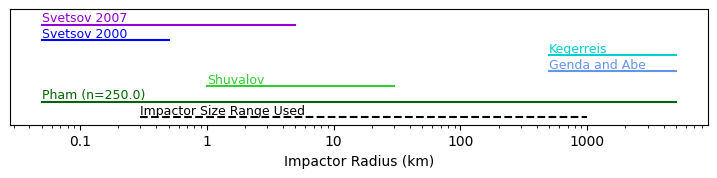

In [82]:
if 'comps' in mods.Nickname.values:
  sizeregimes={'pham':[0.05,5000.], 'shu': [1.,30.], 'ga': [500.,5000.], 'kerr': [500.,5000.], 'svet': [0.05,0.5], 'svet07': [0.05,5.]}
  fig, ax = plt.subplots(figsize=(9,1.5))
  colors=[phamcolor,shucolor,gacolor,kerrcolor,svetcolor,svet07color,'orchid','gray','peru','red','orange','goldenrod']
  i=0
  for model in sizeregimes:
    i+=1
    plt.plot(sizeregimes[model],[i,i],color=colors[i-1])#,label=model,linewidth=5)
    index=mods.index[mods['Nickname']==model].tolist()[0]
    longmodelname=mods.iloc[index]['Model Name']
    if longmodelname=='Pham':# or longmodelname=='Genda and Abe':
      text=str(longmodelname)+' (n='+str(mods.iloc[index]['n'])+')'
    else:
      text=str(longmodelname)
    ax.text(sizeregimes[model][0], i+0.2, text, size=9,color=colors[i-1])
    print(text, colors[i-1])
  # plt.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
  plt.xscale('log')
  plt.xlabel('Impactor Radius (km)')
  plt.tick_params(left=False, labelleft=False)
  plt.ylim(-0.5,i+1)
  plt.plot([size_lowerbound,size_upperbound],[0,0],color='black',linestyle='dashed')
  plt.xticks(ticks=[0.1,1,10,100,1000],labels=[0.1,1,10,100,1000])
  ax.text(size_lowerbound, 0.2, 'Impactor Size Range Used', size=9,color='black')

Pham (n=250.0) darkgreen
Shuvalov limegreen
Genda and Abe cornflowerblue
Kegerreis darkturquoise
Svetsov 2000 blue
Svetsov 2007 darkviolet
Pham (n=250.0) forestgreen
Shuvalov limegreen
Genda and Abe cornflowerblue
Kegerreis darkturquoise
Svetsov 2000 blue


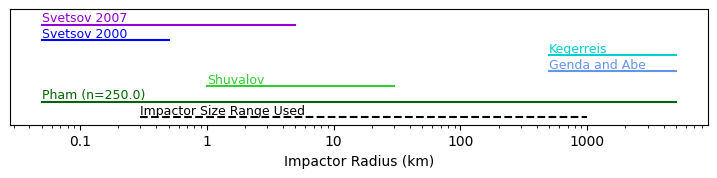

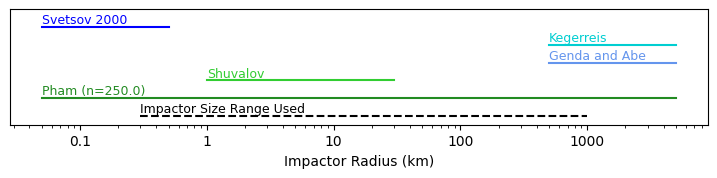

In [83]:
#@title composite plotting

if 'comps' in mods.Nickname.values:
  sizeregimes={'pham':[0.05,5000.], 'shu': [1.,30.], 'ga': [500.,5000.], 'kerr': [500.,5000.], 'svet': [0.05,0.5], 'svet07': [0.05,5.]}
  fig, ax = plt.subplots(figsize=(9,1.5))
  colors=[phamcolor,shucolor,gacolor,kerrcolor,svetcolor,svet07color,'orchid','gray','peru','red','orange','goldenrod']
  i=0
  for model in sizeregimes:
    i+=1
    plt.plot(sizeregimes[model],[i,i],color=colors[i-1])#,label=model,linewidth=5)
    index=mods.index[mods['Nickname']==model].tolist()[0]
    longmodelname=mods.iloc[index]['Model Name']
    if longmodelname=='Pham':# or longmodelname=='Genda and Abe':
      text=str(longmodelname)+' (n='+str(mods.iloc[index]['n'])+')'
    else:
      text=str(longmodelname)
    ax.text(sizeregimes[model][0], i+0.2, text, size=9,color=colors[i-1])
    print(text, colors[i-1])
  # plt.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
  plt.xscale('log')
  plt.xlabel('Impactor Radius (km)')
  plt.tick_params(left=False, labelleft=False)
  plt.ylim(-0.5,i+1)
  plt.plot([size_lowerbound,size_upperbound],[0,0],color='black',linestyle='dashed')
  plt.xticks(ticks=[0.1,1,10,100,1000],labels=[0.1,1,10,100,1000])
  ax.text(size_lowerbound, 0.2, 'Impactor Size Range Used', size=9,color='black')


if 'compns' in mods.Nickname.values:
  sizeregimes={'pham':[0.05,5000.], 'shu': [1.,30.], 'ga': [500.,5000.], 'kerr': [500.,5000.], 'svet': [0.05,0.5]}#no svet07
  fig, ax = plt.subplots(figsize=(9,1.5))
  colors=['forestgreen',shucolor,gacolor, kerrcolor,svetcolor,svet07color,'orchid','gray','peru','red','orange','goldenrod']
  i=0
  for model in sizeregimes:
    i+=1
    plt.plot(sizeregimes[model],[i,i],color=colors[i-1])#,label=model,linewidth=5)
    index=mods.index[mods['Nickname']==model].tolist()[0]
    longmodelname=mods.iloc[index]['Model Name']
    if longmodelname=='Pham':# or longmodelname=='Genda and Abe':
      text=str(longmodelname)+' (n='+str(mods.iloc[index]['n'])+')'
    else:
      text=str(longmodelname)
    ax.text(sizeregimes[model][0], i+0.2, text, size=9,color=colors[i-1])
    print(text, colors[i-1])
  # plt.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
  plt.xscale('log')
  plt.xlabel('Impactor Radius (km)')
  plt.tick_params(left=False, labelleft=False)
  plt.ylim(-0.5,i+1)
  plt.plot([size_lowerbound,size_upperbound],[0,0],color='black',linestyle='dashed')
  plt.xticks(ticks=[0.1,1,10,100,1000],labels=[0.1,1,10,100,1000])
  ax.text(size_lowerbound, 0.2, 'Impactor Size Range Used', size=9,color='black')

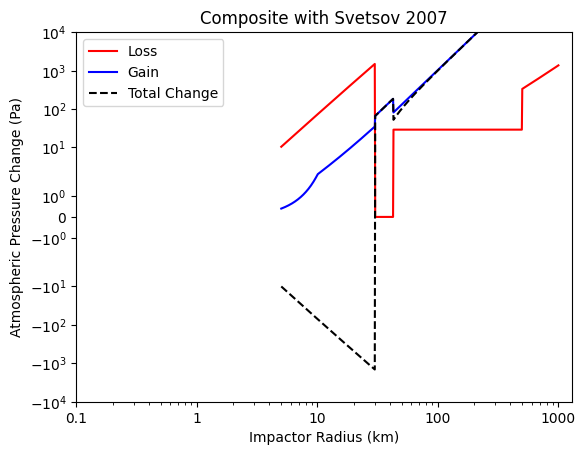

In [84]:
if verbiose==1: 
  #@title composite plotting cont
  if numruns==1:
    if 'comps' in mods.Nickname.values and outputdataunits=='mass' and atmchange==False:
      plt.plot(r_imp_array,comps_M_loss,color='red',label='atm mass lost')#,marker='o')
      plt.plot(r_imp_array,comps_M_gain,color='blue',label='atm mass gained')#,marker='o')
      plt.plot(r_imp_array,comps_delta_M,color='black',label='tot atm mass change',linestyle='dashed')
      plt.legend()
      plt.title("Composite with Svetsov 2007")
      plt.xscale('log')
      # plt.yscale('log')
      # plt.yscale('symlog')
      plt.xlabel('impactor radius (km)')
      plt.ylabel('mass change (kg)')
      # plt.ylim(-1e18,1e18)
      plt.xticks(ticks=[0.1,1,10,100,1000],labels=[0.1,1,10,100,1000])

    if 'comps' in mods.Nickname.values and outputdataunits=='mass' and atmchange==True:
      # plt.scatter(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),comps_M_loss,color='red',label='atm mass lost')#,marker='o')
      # plt.scatter(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),comps_M_gain,color='blue',label='atm mass gained')#,marker='o')
      plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),comps_delta_M,color='black',label='tot atm mass change',linestyle='dashed')
      plt.legend()
      plt.title("Composite with Svetsov 2007")
      # plt.xscale('log')
      # plt.yscale('log')
      # plt.yscale('symlog')
      plt.xlabel('cumulative number of impacts')
      plt.ylabel('atmospheric mass (kg)')
      # plt.ylim(-1e18,1e18)
      # plt.xticks(ticks=[0.1,1,10,100,1000],labels=[0.1,1,10,100,1000])

    if 'comps' in mods.Nickname.values and outputdataunits=='pressure' and atmchange==True:
      # plt.scatter(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),comps_P_loss,color='red',label='atm pressure lost')
      # plt.scatter(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),comps_P_gain,color='blue',label='atm pressure gained')
      plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),comps_delta_P,color='black',label='tot atm pressure change',linestyle='dashed')
      plt.axhline(atmmass_to_surfacepressure(r_planet,presentday_atm_m,gravity),color='gray', linestyle='dashed',label=f"{startingP} bar")
      plt.axhline(110000,color='gray', linestyle='dotted',label='110 kPa')
      # plt.axhline(-atmmass_to_surfacepressure(r_planet,presentday_atm_m,gravity),color='gray', linestyle='dashed')
      plt.legend()
      plt.title("Composite with Svetsov 2007")
      # plt.xscale('log')
      # plt.yscale('log')
      # plt.yscale('symlog')
      plt.xlabel('cumulative number of impacts')
      plt.ylabel('atmospheric pressure (Pa)')
      # plt.ylim(-0.1,2e7)
      # plt.xticks(ticks=[0.1,1,10,100,1000],labels=[0.1,1,10,100,1000])

    if 'comps' in mods.Nickname.values and outputdataunits=='pressure' and atmchange==False:
      r_imp_array,comps_P_loss,comps_P_gain,comps_delta_P=sort3(compsr_imp_array,comps_P_loss,comps_P_gain,comps_delta_P)
      plt.plot(r_imp_array,comps_P_loss,color='red',label='Loss')#,marker='o')
      plt.plot(r_imp_array,comps_P_gain,color='blue',label='Gain')#,marker='o')
      plt.plot(r_imp_array,comps_delta_P,color='black',label='Total Change',linestyle='dashed')
      # plt.axvline(ga_corresponding_crit_imp_r, color='gray',label='r_imp for m_crit',linestyle='dotted')
      # plt.axhline(atmmass_to_surfacepressure(r_planet,presentday_atm_m,gravity),color='gray', linestyle='dashed',label=f"{startingP} bar")
      # plt.axhline(-atmmass_to_surfacepressure(r_planet,presentday_atm_m,gravity),color='gray', linestyle='dashed')
      plt.legend()
      plt.title("Composite with Svetsov 2007")
      plt.xscale('log')
      # plt.xlim(0.09,0.2)
      plt.ylim(-1e4,1e4)
      # plt.yscale('log')
      plt.yscale('symlog')
      plt.xlabel('Impactor Radius (km)')
      plt.ylabel('Atmospheric Pressure Change (Pa)')
      plt.xticks(ticks=[0.1,1,10,100,1000],labels=[0.1,1,10,100,1000])

  else:
    if 'comps' in mods.Nickname.values and outputdataunits=='pressure':
      # plt.errorbar(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['comps'][1]['avg']),yerr=list(processeddatadict['comps'][1]['std']),color='red',label='atm pressure lost')
      # plt.errorbar(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['comps'][0]['avg']),yerr=list(processeddatadict['comps'][0]['std']),color='blue',label='atm pressure gained')
      # plt.figure(figsize=(17.39,7.67))
      # plt.rcParams.update({'font.size': 22})
      plt.plot(np.linspace(1,numimps,numimps),list(processeddatadict['comps'][2]['avg']),color='black',label='Atmospheric Pressure')
      plt.plot(np.linspace(1,numimps,numimps),list(processeddatadict['comps'][2]['avg+std']),color='black',label='1σ', linestyle='dashed')
      plt.plot(np.linspace(1,numimps,numimps),list(processeddatadict['comps'][2]['avg-std']),color='black', linestyle='dashed')
      plt.axhline(atmmass_to_surfacepressure(r_planet,presentday_atm_m,gravity),color='gray', linestyle='dotted',label=f"{startingP} bar")
      plt.legend()
      plt.title("Composite with Svetsov 2007")
      # plt.xscale('log')
      # plt.yscale('log')
      # plt.yscale('symlog')
      plt.xlabel('Cumulative Number of Impacts')
      plt.ylabel('Atmospheric Pressure (Pa)')
      plt.ylim(-10,140000)
      

    elif 'comps' in mods.Nickname.values and outputdataunits=='mass':
      # plt.errorbar(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['comps'][1]['avg']),yerr=list(processeddatadict['comps'][1]['std']),color='red',label='atm mass lost')
      # plt.errorbar(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['comps'][0]['avg']),yerr=list(processeddatadict['comps'][0]['std']),color='blue',label='atm mass gained')
      plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['comps'][2]['avg']),color='black',label='tot atm mass change')
      plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['comps'][2]['avg+std']),color='black',label='1σ', linestyle='dashed')
      plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['comps'][2]['avg-std']),color='black', linestyle='dashed')
      plt.axhline(atmmass_to_surfacepressure(r_planet,presentday_atm_m,gravity),color='gray', linestyle='dotted',label=f"{startingP} bar")
      plt.legend()
      plt.title("Composite with Svetsov 2007")
      # plt.xscale('log')
      # plt.yscale('log')
      # plt.yscale('symlog')
      plt.xlabel('cumulative number of impacts')
      plt.ylabel('atm mass (kg)')

  

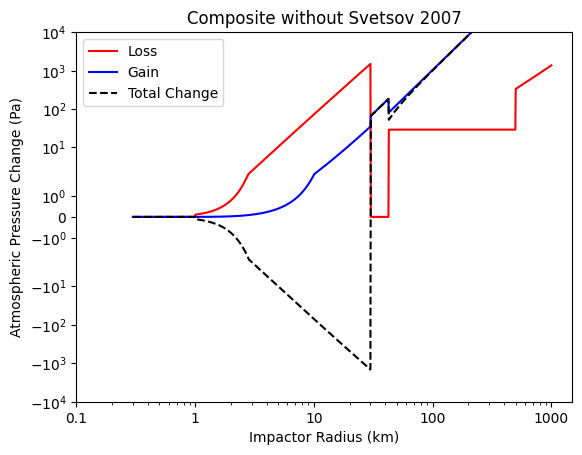

In [85]:
#@title composite plotting cont
if numruns==1:
  if 'compns' in mods.Nickname.values and outputdataunits=='mass' and atmchange==False:
    plt.plot(r_imp_array,compns_M_loss,color='red',label='atm mass lost')#,marker='o')
    plt.plot(r_imp_array,compns_M_gain,color='blue',label='atm mass gained')#,marker='o')
    plt.plot(r_imp_array,compns_delta_M,color='black',label='tot atm mass change',linestyle='dashed')
    plt.legend()
    plt.title("Composite without Svetsov 2007")
    plt.xscale('log')
    # plt.yscale('log')
    # plt.yscale('symlog')
    plt.xlabel('impactor radius (km)')
    plt.ylabel('mass change (kg)')
    # plt.ylim(-1e18,1e18)
    plt.xticks(ticks=[0.1,1,10,100,1000],labels=[0.1,1,10,100,1000])

  if 'compns' in mods.Nickname.values and outputdataunits=='mass' and atmchange==True:
    # plt.scatter(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),compns_M_loss,color='red',label='atm mass lost')#,marker='o')
    # plt.scatter(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),compns_M_gain,color='blue',label='atm mass gained')#,marker='o')
    plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),compns_delta_M,color='black',label='tot atm mass change',linestyle='dashed')
    plt.legend()
    plt.title("Composite without Svetsov 2007")
    # plt.xscale('log')
    # plt.yscale('log')
    # plt.yscale('symlog')
    plt.xlabel('cumulative number of impacts')
    plt.ylabel('atmospheric mass (kg)')
    # plt.ylim(-1e18,1e18)
    # plt.xticks(ticks=[0.1,1,10,100,1000],labels=[0.1,1,10,100,1000])

  if 'compns' in mods.Nickname.values and outputdataunits=='pressure' and atmchange==True:
    # plt.scatter(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),compns_P_loss,color='red',label='atm pressure lost')
    # plt.scatter(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),compns_P_gain,color='blue',label='atm pressure gained')
    plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),compns_delta_P,color='black',label='tot atm pressure change',linestyle='dashed')
    plt.axhline(atmmass_to_surfacepressure(r_planet,presentday_atm_m,gravity),color='gray', linestyle='dashed',label=f"{startingP} bar")
    plt.axhline(110000,color='gray', linestyle='dotted',label='110 kPa')
    # plt.axhline(-atmmass_to_surfacepressure(r_planet,presentday_atm_m,gravity),color='gray', linestyle='dashed')
    plt.legend()
    plt.title("Composite without Svetsov 2007")
    # plt.xscale('log')
    # plt.yscale('log')
    # plt.yscale('symlog')
    plt.xlabel('cumulative number of impacts')
    plt.ylabel('atmospheric pressure (Pa)')
    # plt.ylim(-0.1,2e7)
    # plt.xticks(ticks=[0.1,1,10,100,1000],labels=[0.1,1,10,100,1000])

  if 'compns' in mods.Nickname.values and outputdataunits=='pressure' and atmchange==False:
    r_imp_array,compns_P_loss,compns_P_gain,compns_delta_P=sort3(compnsr_imp_array,compns_P_loss,compns_P_gain,compns_delta_P)
    plt.plot(r_imp_array,compns_P_loss,color='red',label='Loss')#,marker='o')
    plt.plot(r_imp_array,compns_P_gain,color='blue',label='Gain')#,marker='o')
    plt.plot(r_imp_array,compns_delta_P,color='black',label='Total Change',linestyle='dashed')
    # plt.axvline(ga_corresponding_crit_imp_r, color='gray',label='r_imp for m_crit',linestyle='dotted')
    # plt.axhline(atmmass_to_surfacepressure(r_planet,presentday_atm_m,gravity),color='gray', linestyle='dashed',label=f"{startingP} bar")
    # plt.axhline(-atmmass_to_surfacepressure(r_planet,presentday_atm_m,gravity),color='gray', linestyle='dashed')
    plt.legend()
    plt.title("Composite without Svetsov 2007")
    plt.xscale('log')
    # plt.xlim(0.09,0.2)
    plt.ylim(-1e4,1e4)
    # plt.yscale('log')
    plt.yscale('symlog')
    plt.xlabel('Impactor Radius (km)')
    plt.ylabel('Atmospheric Pressure Change (Pa)')
    plt.xticks(ticks=[0.1,1,10,100,1000],labels=[0.1,1,10,100,1000])

else:
  if 'compns' in mods.Nickname.values and outputdataunits=='pressure':
    # plt.errorbar(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['compns'][1]['avg']),yerr=list(processeddatadict['compns'][1]['std']),color='red',label='atm pressure lost')
    # plt.errorbar(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['compns'][0]['avg']),yerr=list(processeddatadict['compns'][0]['std']),color='blue',label='atm pressure gained')
    # plt.figure(figsize=(17.39,7.67))
    # plt.rcParams.update({'font.size': 22})
    plt.plot(np.linspace(1,numimps,numimps),list(processeddatadict['compns'][2]['avg']),color='black',label='Atmospheric Pressure')
    plt.plot(np.linspace(1,numimps,numimps),list(processeddatadict['compns'][2]['avg+std']),color='black',label='1σ', linestyle='dashed')
    plt.plot(np.linspace(1,numimps,numimps),list(processeddatadict['compns'][2]['avg-std']),color='black', linestyle='dashed')
    plt.axhline(atmmass_to_surfacepressure(r_planet,presentday_atm_m,gravity),color='gray', linestyle='dotted',label=f"{startingP} bar")
    plt.legend()
    plt.title("Composite without Svetsov 2007")
    # plt.xscale('log')
    # plt.yscale('log')
    # plt.yscale('symlog')
    plt.xlabel('Cumulative Number of Impacts')
    plt.ylabel('Atmospheric Pressure (Pa)')
    plt.ylim(-10,140000)
    

  elif 'compns' in mods.Nickname.values and outputdataunits=='mass':
    # plt.errorbar(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['compns'][1]['avg']),yerr=list(processeddatadict['compns'][1]['std']),color='red',label='atm mass lost')
    # plt.errorbar(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['compns'][0]['avg']),yerr=list(processeddatadict['compns'][0]['std']),color='blue',label='atm mass gained')
    plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['compns'][2]['avg']),color='black',label='tot atm mass change')
    plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['compns'][2]['avg+std']),color='black',label='1σ', linestyle='dashed')
    plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['compns'][2]['avg-std']),color='black', linestyle='dashed')
    plt.axhline(atmmass_to_surfacepressure(r_planet,presentday_atm_m,gravity),color='gray', linestyle='dotted',label=f"{startingP} bar")
    plt.legend()
    plt.title("Composite without Svetsov 2007")
    # plt.xscale('log')
    # plt.yscale('log')
    # plt.yscale('symlog')
    plt.xlabel('cumulative number of impacts')
    plt.ylabel('atm mass (kg)')

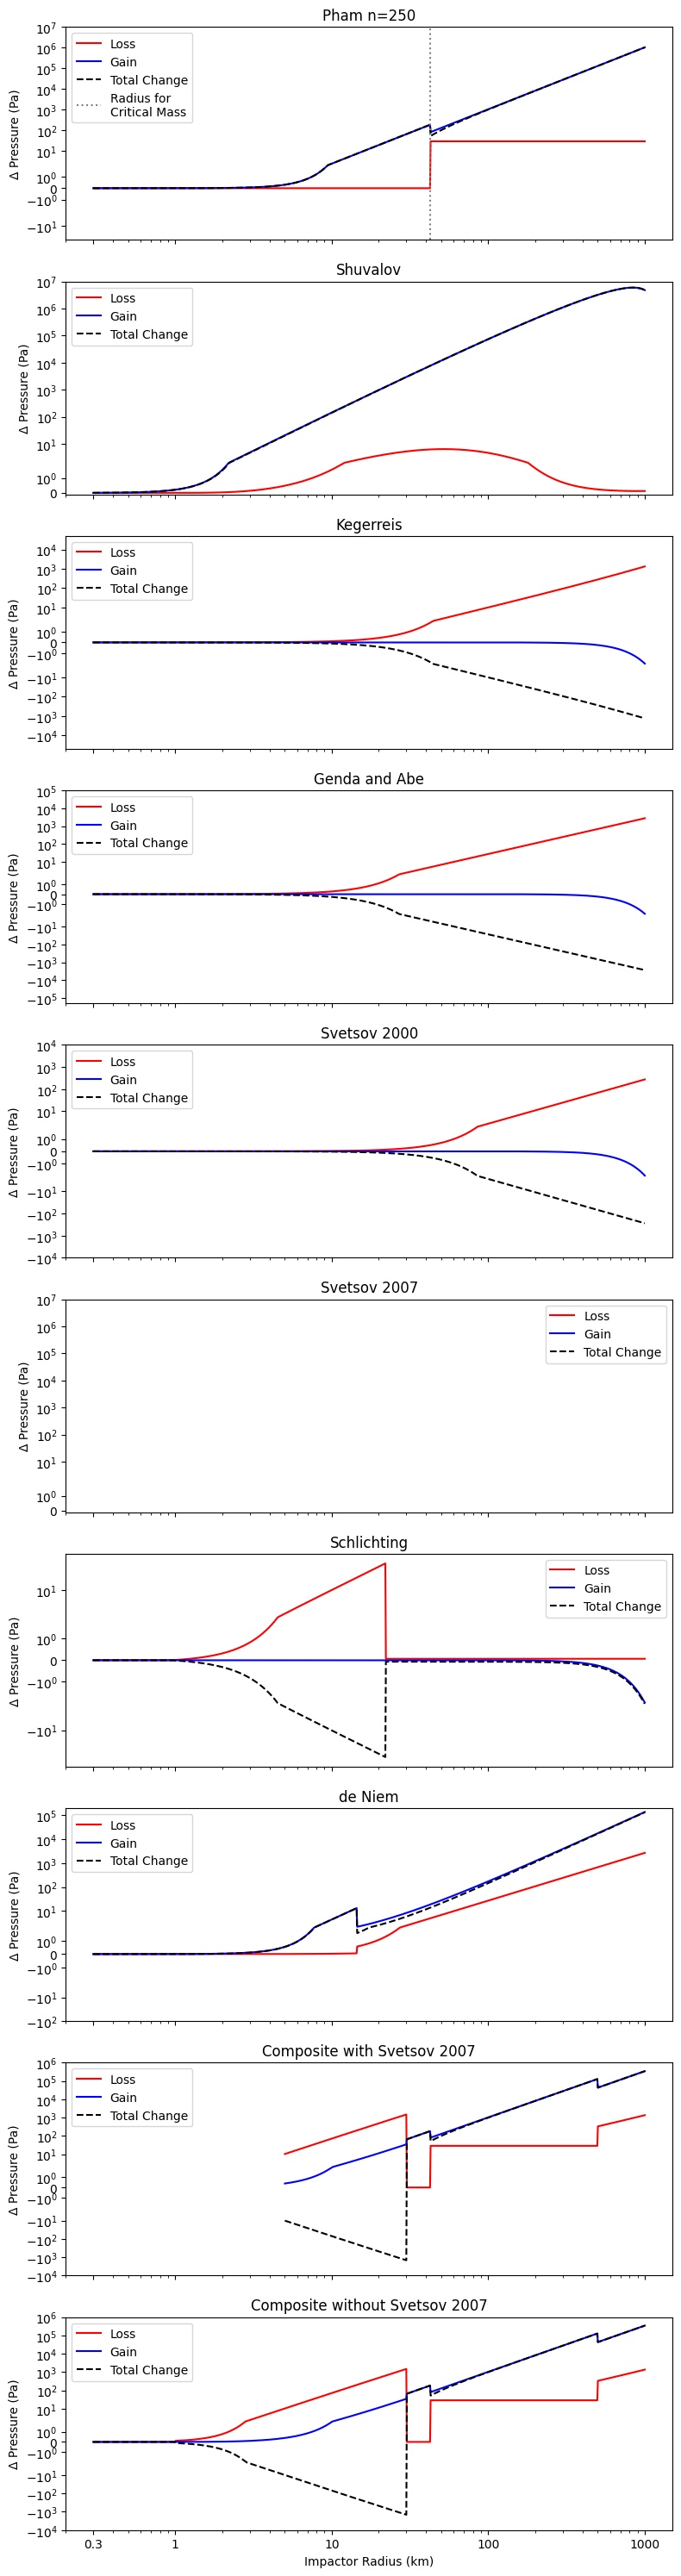

In [86]:
import matplotlib.pyplot as plt
plt.rcdefaults()

# Final ordered models
models = [
    ("Pham n=" + str(round(n)), pham_P_loss, pham_P_gain, pham_delta_P),
    ("Shuvalov", shu_P_loss, shu_P_gain, shu_delta_P),
    ("Kegerreis", kerr_P_loss, kerr_P_gain, kerr_delta_P),
    ("Genda and Abe", ga_P_loss, ga_P_gain, ga_delta_P),
    ("Svetsov 2000", svet_P_loss, svet_P_gain, svet_delta_P),
    ("Svetsov 2007", svet07_P_loss, svet07_P_gain, svet07_delta_P),
    ("Schlichting", hilke_P_loss, hilke_P_gain, hilke_delta_P),
    ("de Niem", deniem_P_loss, deniem_P_gain, deniem_delta_P),
    ("Composite with Svetsov 2007", comps_P_loss, comps_P_gain, comps_delta_P),
    ("Composite without Svetsov 2007", compns_P_loss, compns_P_gain, compns_delta_P),
]

# Matching y-limits — feel free to tweak for better visibility
ylims = [
    (-0.5e2, 1e7),      # Pham
    (-0.1, 1e7),        # Shuvalov
    (-5e4, 5e4),        # Kegerreis
    (-2e5, 1e5),        # Genda and Abe
    (-1e4, 1e4),        # Svetsov 2000
    (-0.1, 1e7),        # Svetsov 2007
    None,               # Hilke
    (-1e2, 2e5),        # de Niem
    (-1e4, 1e6),        # Composite with Svetsov 2007
    (-1e4, 1e6),        # Composite without Svetsov 2007
]

fig, axes = plt.subplots(len(models), 1, figsize=(8, 3 * len(models)), sharex=True)

for ax, (title, loss, gain, delta), ylim in zip(axes, models, ylims):
    if loss is not None and gain is not None:
        ax.plot(r_imp_array, loss, color='red', label='Loss')
        ax.plot(r_imp_array, gain, color='blue', label='Gain')
    if delta is not None:
        ax.plot(r_imp_array, delta, color='black', linestyle='dashed', label='Total Change')

    if "Pham" in title:
        ax.axvline(pham_corresponding_crit_imp_r, color='gray', linestyle='dotted', label='Radius for\nCritical Mass')

    ax.set_xscale('log')
    ax.set_yscale('symlog')
    ax.set_title(title)
    ax.set_ylabel('Δ Pressure (Pa)')
    ax.legend()
    if ylim:
        ax.set_ylim(ylim)

axes[-1].set_xlabel('Impactor Radius (km)')
axes[-1].set_xticks([0.3, 1, 10, 100, 1000])
axes[-1].set_xticklabels([0.3, 1, 10, 100, 1000])

plt.tight_layout()
plt.show()


In [87]:
if pickleoutput==True:
    f = open("output.txt", "a")

    if numruns!=1:
        if medianoravg=='avg':
            print('comps final atm =',list(processeddatadict['comps'][2]['avg'])[-1],'+/-',list(processeddatadict['comps'][2]['std'])[-1])
            print('compns final atm =',list(processeddatadict['compns'][2]['avg'])[-1],'+/-',list(processeddatadict['compns'][2]['std'])[-1])
            print('svet final atm =',list(processeddatadict['svet'][2]['avg'])[-1],'+/-',list(processeddatadict['svet'][2]['std'])[-1])
            if 'svet07' in mods.Nickname.values:
                print('svet07 final atm =',list(processeddatadict['svet07'][2]['avg'])[-1],'+/-',list(processeddatadict['svet07'][2]['std'])[-1])  
            print('shu final atm =',list(processeddatadict['shu'][2]['avg'])[-1],'+/-',list(processeddatadict['shu'][2]['std'])[-1])
            print('pham final atm =',list(processeddatadict['pham'+str(n)][2]['avg'])[-1],'+/-',list(processeddatadict['pham'+str(n)][2]['std'])[-1])
            print('ga final atm =',list(processeddatadict['ga'][2]['avg'])[-1],'+/-',list(processeddatadict['ga'][2]['std'])[-1]) 
            print('kerr final atm =',list(processeddatadict['kerr'][2]['avg'])[-1],'+/-',list(processeddatadict['kerr'][2]['std'])[-1])    
            print('hilke final atm =',list(processeddatadict['hilke'][2]['avg'])[-1],'+/-',list(processeddatadict['hilke'][2]['std'])[-1])   
            print('deniem final atm =',list(processeddatadict['deniem'][2]['avg'])[-1],'+/-',list(processeddatadict['deniem'][2]['std'])[-1])


            f.write('comps final atm ='+str(list(processeddatadict['comps'][2]['avg'])[-1])+'+/-'+str(list(processeddatadict['comps'][2]['std'])[-1])+ '\n'+
            'compns final atm ='+str(list(processeddatadict['compns'][2]['avg'])[-1])+'+/-'+str(list(processeddatadict['compns'][2]['std'])[-1])+ '\n'+
            'svet final atm ='+str(list(processeddatadict['svet'][2]['avg'])[-1])+'+/-'+str(list(processeddatadict['svet'][2]['std'])[-1])+ '\n'+
            'svet07 final atm ='+str(list(processeddatadict['svet07'][2]['avg'])[-1])+'+/-'+str(list(processeddatadict['svet07'][2]['std'])[-1])+ '\n'  +
            'shu final atm ='+str(list(processeddatadict['shu'][2]['avg'])[-1])+'+/-'+str(list(processeddatadict['shu'][2]['std'])[-1])+ '\n'+
            'pham final atm ='+str(list(processeddatadict['pham'+str(n)][2]['avg'])[-1])+'+/-'+str(list(processeddatadict['pham'+str(n)][2]['std'])[-1])+ '\n'+
            'ga final atm ='+str(list(processeddatadict['ga'][2]['avg'])[-1])+'+/-'+str(list(processeddatadict['ga'][2]['std'])[-1])    + '\n'+
            'kerr final atm ='+str(list(processeddatadict['kerr'][2]['avg'])[-1])+'+/-'+str(list(processeddatadict['kerr'][2]['std'])[-1])    + '\n'+
            'hilke final atm ='+str(list(processeddatadict['hilke'][2]['avg'])[-1])+'+/-'+str(list(processeddatadict['hilke'][2]['std'])[-1]) + '\n'+  
            'deniem final atm ='+str(list(processeddatadict['deniem'][2]['avg'])[-1])+'+/-'+str(list(processeddatadict['deniem'][2]['std'])[-1]))    

        elif medianoravg=='median':
            print('comps final atm =',list(processeddatadict['comps'][2]['avg'])[-1],'+',list(processeddatadict['comps'][2]['avg+std'])[-1]-list(processeddatadict['comps'][2]['avg'])[-1],
                '-',list(processeddatadict['comps'][2]['avg'])[-1]-list(processeddatadict['comps'][2]['avg-std'])[-1])
            print('compns final atm =',list(processeddatadict['compns'][2]['avg'])[-1],'+',list(processeddatadict['compns'][2]['avg+std'])[-1]-list(processeddatadict['compns'][2]['avg'])[-1],
                '-',list(processeddatadict['compns'][2]['avg'])[-1]-list(processeddatadict['compns'][2]['avg-std'])[-1])
            print('svet final atm =',list(processeddatadict['svet'][2]['avg'])[-1],'+',list(processeddatadict['svet'][2]['avg+std'])[-1]-list(processeddatadict['svet'][2]['avg'])[-1],
                '-',list(processeddatadict['svet'][2]['avg'])[-1]-list(processeddatadict['svet'][2]['avg-std'])[-1])
            if 'svet07' in mods.Nickname.values: print('svet07final atm =',list(processeddatadict['svet07'][2]['avg'])[-1],'+',list(processeddatadict['svet07'][2]['avg+std'])[-1]-list(processeddatadict['svet07'][2]['avg'])[-1],
                '-',list(processeddatadict['svet07'][2]['avg'])[-1]-list(processeddatadict['svet07'][2]['avg-std'])[-1]) 
            print('shu final atm =',list(processeddatadict['shu'][2]['avg'])[-1],'+',list(processeddatadict['shu'][2]['avg+std'])[-1]-list(processeddatadict['shu'][2]['avg'])[-1],
                '-',list(processeddatadict['shu'][2]['avg'])[-1]-list(processeddatadict['shu'][2]['avg-std'])[-1])
            print('pham final atm =',list(processeddatadict['pham'+str(n)][2]['avg'])[-1],'+',list(processeddatadict['pham'+str(n)][2]['avg+std'])[-1]-list(processeddatadict['pham'+str(n)][2]['avg'])[-1],
                '-',list(processeddatadict['pham'+str(n)][2]['avg'])[-1]-list(processeddatadict['pham'+str(n)][2]['avg-std'])[-1])
            print('ga final atm =',list(processeddatadict['ga'][2]['avg'])[-1],'+',list(processeddatadict['ga'][2]['avg+std'])[-1]-list(processeddatadict['ga'][2]['avg'])[-1],
                '-',list(processeddatadict['ga'][2]['avg'])[-1]-list(processeddatadict['ga'][2]['avg-std'])[-1]) 
            print('kerr final atm =',list(processeddatadict['kerr'][2]['avg'])[-1],'+',list(processeddatadict['kerr'][2]['avg+std'])[-1]-list(processeddatadict['kerr'][2]['avg'])[-1],
                '-',list(processeddatadict['kerr'][2]['avg'])[-1]-list(processeddatadict['kerr'][2]['avg-std'])[-1]) 
            print('hilke final atm =',list(processeddatadict['hilke'][2]['avg'])[-1],'+',list(processeddatadict['hilke'][2]['avg+std'])[-1]-list(processeddatadict['hilke'][2]['avg'])[-1],
                '-',list(processeddatadict['hilke'][2]['avg'])[-1]-list(processeddatadict['hilke'][2]['avg-std'])[-1]) 
            print('deniem final atm =',list(processeddatadict['deniem'][2]['avg'])[-1],'+',list(processeddatadict['deniem'][2]['avg+std'])[-1]-list(processeddatadict['deniem'][2]['avg'])[-1],
                '-',list(processeddatadict['deniem'][2]['avg'])[-1]-list(processeddatadict['deniem'][2]['avg-std'])[-1]) 
            
            f.write('comps final atm ='+str(list(processeddatadict['comps'][2]['avg'])[-1])+'+'+str(list(processeddatadict['comps'][2]['avg+std'])[-1]-list(processeddatadict['comps'][2]['avg'])[-1])+
                '-'+str(list(processeddatadict['comps'][2]['avg'])[-1]-list(processeddatadict['comps'][2]['avg-std'])[-1]))
            f.write('\ncompns final atm ='+str(list(processeddatadict['compns'][2]['avg'])[-1])+'+'+str(list(processeddatadict['compns'][2]['avg+std'])[-1]-list(processeddatadict['compns'][2]['avg'])[-1])+
                '-'+str(list(processeddatadict['compns'][2]['avg'])[-1]-list(processeddatadict['compns'][2]['avg-std'])[-1]))
            f.write('\nsvet final atm ='+str(list(processeddatadict['svet'][2]['avg'])[-1])+'+'+str(list(processeddatadict['svet'][2]['avg+std'])[-1]-list(processeddatadict['svet'][2]['avg'])[-1])+
                '-'+str(list(processeddatadict['svet'][2]['avg'])[-1]-list(processeddatadict['svet'][2]['avg-std'])[-1]))
            f.write('\nsvet07 final atm ='+str(list(processeddatadict['svet07'][2]['avg'])[-1])+'+'+str(list(processeddatadict['svet07'][2]['avg+std'])[-1]-list(processeddatadict['svet07'][2]['avg'])[-1])+
                '-'+str(list(processeddatadict['svet07'][2]['avg'])[-1]-list(processeddatadict['svet07'][2]['avg-std'])[-1]))
            f.write('\nshu final atm ='+str(list(processeddatadict['shu'][2]['avg'])[-1])+'+'+str(list(processeddatadict['shu'][2]['avg+std'])[-1]-list(processeddatadict['shu'][2]['avg'])[-1])+
                '-'+str(list(processeddatadict['shu'][2]['avg'])[-1]-list(processeddatadict['shu'][2]['avg-std'])[-1]))
            f.write('\npham final atm ='+str(list(processeddatadict['pham'+str(n)][2]['avg'])[-1])+'+'+str(list(processeddatadict['pham'+str(n)][2]['avg+std'])[-1]-list(processeddatadict['pham'+str(n)][2]['avg'])[-1])+
                '-'+str(list(processeddatadict['pham'+str(n)][2]['avg'])[-1]-list(processeddatadict['pham'+str(n)][2]['avg-std'])[-1]))
            f.write('\nga final atm ='+str(list(processeddatadict['ga'][2]['avg'])[-1])+'+'+str(list(processeddatadict['ga'][2]['avg+std'])[-1]-list(processeddatadict['ga'][2]['avg'])[-1])+
                '-'+str(list(processeddatadict['ga'][2]['avg'])[-1]-list(processeddatadict['ga'][2]['avg-std'])[-1]))
            f.write('\nkerr final atm ='+str(list(processeddatadict['kerr'][2]['avg'])[-1])+'+'+str(list(processeddatadict['kerr'][2]['avg+std'])[-1]-list(processeddatadict['kerr'][2]['avg'])[-1])+
                '-'+str(list(processeddatadict['kerr'][2]['avg'])[-1]-list(processeddatadict['kerr'][2]['avg-std'])[-1]))
            f.write('\nhilke final atm ='+str(list(processeddatadict['hilke'][2]['avg'])[-1])+'+'+str(list(processeddatadict['hilke'][2]['avg+std'])[-1]-list(processeddatadict['hilke'][2]['avg'])[-1])+
                '-'+str(list(processeddatadict['hilke'][2]['avg'])[-1]-list(processeddatadict['hilke'][2]['avg-std'])[-1]))
            f.write('\ndeniem final atm ='+str(list(processeddatadict['deniem'][2]['avg'])[-1])+'+'+str(list(processeddatadict['deniem'][2]['avg+std'])[-1]-list(processeddatadict['deniem'][2]['avg'])[-1])+
                '-'+str(list(processeddatadict['deniem'][2]['avg'])[-1]-list(processeddatadict['deniem'][2]['avg-std'])[-1]))
            
            

    f.close()

In [88]:
if csvoutput==True and numruns!=1:
      f = open("output.txt", "a")

      if medianoravg=='avg':
            print('comps final atm =',list(processeddatadict['comps'][2]['avg'])[-1],'+/-',list(processeddatadict['comps'][2]['std'])[-1])
            print('compns final atm =',list(processeddatadict['compns'][2]['avg'])[-1],'+/-',list(processeddatadict['compns'][2]['std'])[-1])
            print('svet final atm =',list(processeddatadict['svet'][2]['avg'])[-1],'+/-',list(processeddatadict['svet'][2]['std'])[-1])
            if 'svet07' in mods.Nickname.values:
                  print('svet07 final atm =',list(processeddatadict['svet07'][2]['avg'])[-1],'+/-',list(processeddatadict['svet07'][2]['std'])[-1])  
            print('shu final atm =',list(processeddatadict['shu'][2]['avg'])[-1],'+/-',list(processeddatadict['shu'][2]['std'])[-1])
            print('pham final atm =',list(processeddatadict['pham'][2]['avg'])[-1],'+/-',list(processeddatadict['pham'][2]['std'])[-1])
            print('ga final atm =',list(processeddatadict['ga'][2]['avg'])[-1],'+/-',list(processeddatadict['ga'][2]['std'])[-1])    
            print('kerr final atm =',list(processeddatadict['kerr'][2]['avg'])[-1],'+/-',list(processeddatadict['kerr'][2]['std'])[-1])    
            print('hilke final atm =',list(processeddatadict['hilke'][2]['avg'])[-1],'+/-',list(processeddatadict['hilke'][2]['std'])[-1])   
            print('deniem final atm =',list(processeddatadict['deniem'][2]['avg'])[-1],'+/-',list(processeddatadict['deniem'][2]['std'])[-1])


            f.write('comps final atm ='+str(list(processeddatadict['comps'][2]['avg'])[-1])+'+/-'+str(list(processeddatadict['comps'][2]['std'])[-1])+ '\n'+
            'compns final atm ='+str(list(processeddatadict['compns'][2]['avg'])[-1])+'+/-'+str(list(processeddatadict['compns'][2]['std'])[-1])+ '\n'+
            'svet final atm ='+str(list(processeddatadict['svet'][2]['avg'])[-1])+'+/-'+str(list(processeddatadict['svet'][2]['std'])[-1])+ '\n'+
            'svet07 final atm ='+str(list(processeddatadict['svet07'][2]['avg'])[-1])+'+/-'+str(list(processeddatadict['svet07'][2]['std'])[-1])+ '\n'  +
            'shu final atm ='+str(list(processeddatadict['shu'][2]['avg'])[-1])+'+/-'+str(list(processeddatadict['shu'][2]['std'])[-1])+ '\n'+
            'pham final atm ='+str(list(processeddatadict['pham'][2]['avg'])[-1])+'+/-'+str(list(processeddatadict['pham'][2]['std'])[-1])+ '\n'+
            'ga final atm ='+str(list(processeddatadict['ga'][2]['avg'])[-1])+'+/-'+str(list(processeddatadict['ga'][2]['std'])[-1])    + '\n'+
            'kerr final atm ='+str(list(processeddatadict['kerr'][2]['avg'])[-1])+'+/-'+str(list(processeddatadict['kerr'][2]['std'])[-1])    + '\n'+
            'hilke final atm ='+str(list(processeddatadict['hilke'][2]['avg'])[-1])+'+/-'+str(list(processeddatadict['hilke'][2]['std'])[-1]) + '\n'+  
            'deniem final atm ='+str(list(processeddatadict['deniem'][2]['avg'])[-1])+'+/-'+str(list(processeddatadict['deniem'][2]['std'])[-1]))    

      elif medianoravg=='median':
            print('comps final atm =',list(processeddatadict['comps'][2]['avg'])[-1],'+',list(processeddatadict['comps'][2]['avg+std'])[-1]-list(processeddatadict['comps'][2]['avg'])[-1],
                  '-',list(processeddatadict['comps'][2]['avg'])[-1]-list(processeddatadict['comps'][2]['avg-std'])[-1])
            print('compns final atm =',list(processeddatadict['compns'][2]['avg'])[-1],'+',list(processeddatadict['compns'][2]['avg+std'])[-1]-list(processeddatadict['compns'][2]['avg'])[-1],
                  '-',list(processeddatadict['compns'][2]['avg'])[-1]-list(processeddatadict['compns'][2]['avg-std'])[-1])
            print('svet final atm =',list(processeddatadict['svet'][2]['avg'])[-1],'+',list(processeddatadict['svet'][2]['avg+std'])[-1]-list(processeddatadict['svet'][2]['avg'])[-1],
                  '-',list(processeddatadict['svet'][2]['avg'])[-1]-list(processeddatadict['svet'][2]['avg-std'])[-1])
            if 'svet07' in mods.Nickname.values: print('svet07final atm =',list(processeddatadict['svet07'][2]['avg'])[-1],'+',list(processeddatadict['svet07'][2]['avg+std'])[-1]-list(processeddatadict['svet07'][2]['avg'])[-1],
                  '-',list(processeddatadict['svet07'][2]['avg'])[-1]-list(processeddatadict['svet07'][2]['avg-std'])[-1]) 
            print('shu final atm =',list(processeddatadict['shu'][2]['avg'])[-1],'+',list(processeddatadict['shu'][2]['avg+std'])[-1]-list(processeddatadict['shu'][2]['avg'])[-1],
                  '-',list(processeddatadict['shu'][2]['avg'])[-1]-list(processeddatadict['shu'][2]['avg-std'])[-1])
            print('pham final atm =',list(processeddatadict['pham'][2]['avg'])[-1],'+',list(processeddatadict['pham'][2]['avg+std'])[-1]-list(processeddatadict['pham'][2]['avg'])[-1],
                  '-',list(processeddatadict['pham'][2]['avg'])[-1]-list(processeddatadict['pham'][2]['avg-std'])[-1])
            print('ga final atm =',list(processeddatadict['ga'][2]['avg'])[-1],'+',list(processeddatadict['ga'][2]['avg+std'])[-1]-list(processeddatadict['ga'][2]['avg'])[-1],
                  '-',list(processeddatadict['ga'][2]['avg'])[-1]-list(processeddatadict['ga'][2]['avg-std'])[-1]) 
            print('kerr final atm =',list(processeddatadict['kerr'][2]['avg'])[-1],'+',list(processeddatadict['kerr'][2]['avg+std'])[-1]-list(processeddatadict['kerr'][2]['avg'])[-1],
                  '-',list(processeddatadict['kerr'][2]['avg'])[-1]-list(processeddatadict['kerr'][2]['avg-std'])[-1]) 
            print('hilke final atm =',list(processeddatadict['hilke'][2]['avg'])[-1],'+',list(processeddatadict['hilke'][2]['avg+std'])[-1]-list(processeddatadict['hilke'][2]['avg'])[-1],
                  '-',list(processeddatadict['hilke'][2]['avg'])[-1]-list(processeddatadict['hilke'][2]['avg-std'])[-1]) 
            print('deniem final atm =',list(processeddatadict['deniem'][2]['avg'])[-1],'+',list(processeddatadict['deniem'][2]['avg+std'])[-1]-list(processeddatadict['deniem'][2]['avg'])[-1],
                  '-',list(processeddatadict['deniem'][2]['avg'])[-1]-list(processeddatadict['deniem'][2]['avg-std'])[-1]) 
            
            f.write('comps final atm ='+str(list(processeddatadict['comps'][2]['avg'])[-1])+'+'+str(list(processeddatadict['comps'][2]['avg+std'])[-1]-list(processeddatadict['comps'][2]['avg'])[-1])+
                  '-'+str(list(processeddatadict['comps'][2]['avg'])[-1]-list(processeddatadict['comps'][2]['avg-std'])[-1]))
            f.write('\ncompns final atm ='+str(list(processeddatadict['compns'][2]['avg'])[-1])+'+'+str(list(processeddatadict['compns'][2]['avg+std'])[-1]-list(processeddatadict['compns'][2]['avg'])[-1])+
                  '-'+str(list(processeddatadict['compns'][2]['avg'])[-1]-list(processeddatadict['compns'][2]['avg-std'])[-1]))
            f.write('\nsvet final atm ='+str(list(processeddatadict['svet'][2]['avg'])[-1])+'+'+str(list(processeddatadict['svet'][2]['avg+std'])[-1]-list(processeddatadict['svet'][2]['avg'])[-1])+
                  '-'+str(list(processeddatadict['svet'][2]['avg'])[-1]-list(processeddatadict['svet'][2]['avg-std'])[-1]))
            f.write('\nsvet07 final atm ='+str(list(processeddatadict['svet07'][2]['avg'])[-1])+'+'+str(list(processeddatadict['svet07'][2]['avg+std'])[-1]-list(processeddatadict['svet07'][2]['avg'])[-1])+
                  '-'+str(list(processeddatadict['svet07'][2]['avg'])[-1]-list(processeddatadict['svet07'][2]['avg-std'])[-1]))
            f.write('\nshu final atm ='+str(list(processeddatadict['shu'][2]['avg'])[-1])+'+'+str(list(processeddatadict['shu'][2]['avg+std'])[-1]-list(processeddatadict['shu'][2]['avg'])[-1])+
                  '-'+str(list(processeddatadict['shu'][2]['avg'])[-1]-list(processeddatadict['shu'][2]['avg-std'])[-1]))
            f.write('\npham final atm ='+str(list(processeddatadict['pham'][2]['avg'])[-1])+'+'+str(list(processeddatadict['pham'][2]['avg+std'])[-1]-list(processeddatadict['pham'][2]['avg'])[-1])+
                  '-'+str(list(processeddatadict['pham'][2]['avg'])[-1]-list(processeddatadict['pham'][2]['avg-std'])[-1]))
            f.write('\nga final atm ='+str(list(processeddatadict['ga'][2]['avg'])[-1])+'+'+str(list(processeddatadict['ga'][2]['avg+std'])[-1]-list(processeddatadict['ga'][2]['avg'])[-1])+
                  '-'+str(list(processeddatadict['ga'][2]['avg'])[-1]-list(processeddatadict['ga'][2]['avg-std'])[-1]))
            f.write('\nkerr final atm ='+str(list(processeddatadict['kerr'][2]['avg'])[-1])+'+'+str(list(processeddatadict['kerr'][2]['avg+std'])[-1]-list(processeddatadict['kerr'][2]['avg'])[-1])+
                  '-'+str(list(processeddatadict['kerr'][2]['avg'])[-1]-list(processeddatadict['kerr'][2]['avg-std'])[-1]))
            f.write('\nhilke final atm ='+str(list(processeddatadict['hilke'][2]['avg'])[-1])+'+'+str(list(processeddatadict['hilke'][2]['avg+std'])[-1]-list(processeddatadict['hilke'][2]['avg'])[-1])+
                  '-'+str(list(processeddatadict['hilke'][2]['avg'])[-1]-list(processeddatadict['hilke'][2]['avg-std'])[-1]))
            f.write('\ndeniem final atm ='+str(list(processeddatadict['deniem'][2]['avg'])[-1])+'+'+str(list(processeddatadict['deniem'][2]['avg+std'])[-1]-list(processeddatadict['deniem'][2]['avg'])[-1])+
                  '-'+str(list(processeddatadict['deniem'][2]['avg'])[-1]-list(processeddatadict['deniem'][2]['avg-std'])[-1]))
            
            

      f.close()

In [89]:
fitcheck=False

In [90]:
if fitcheck==True and numruns!=1:
    xdatatofit=[]
    avgdatatofit=[]
    stddatatofit=[]
    for x,avg,std in zip(np.linspace(1,numimps,numimps),list(processeddatadict['compns'][2]['avg']),list(processeddatadict['compns'][2]['std'])):
        if x.imag==0 and avg.imag==0 and std.imag==0:
            xdatatofit.append(x)
            avgdatatofit.append(avg)
            stddatatofit.append(std)

In [91]:
if fitcheck==True and numruns!=1:
    data={'Imp Radius (km)':xdatatofit,'Avg Running Total Atm P (Pa)':avgdatatofit,'stdev':stddatatofit}
    df=pd.DataFrame(data, columns = ['Imp Radius (km)','Avg Running Total Atm P (Pa)','stdev'])
    df.to_csv(planet+'_compavg.csv', index=False)

In [92]:
if verbiose==1: 
    if fitcheck==True and numruns!=1:
        from scipy.odr import ODR, Model, Data, RealData
        
        vertconst=atmmass_to_surfacepressure(r_planet,presentday_atm_m,gravity)
        def f(B, x):
            if isinstance(x, complex):
                if ifcomplexmake0==True: x=0
                if ifcomplexmakeverysmall==True: x=0.000000000001 
                if ifcomplexmakereal==True: x=np.real(x)
                if ifcomplextakenorm==True: x=norm(x)
            return B[0]*np.emath.logn(B[1], x)+vertconst#return B[0]*x**B[1]+vertconst

        def func(p, x):
            if isinstance(x, complex):
                if ifcomplexmake0==True: x=0
                if ifcomplexmakeverysmall==True: x=0.000000000001 
                if ifcomplexmakereal==True: x=np.real(x)
                if ifcomplextakenorm==True: x=norm(x)
            a, b = p
            return a**np.emath.logn(b, x)+vertconst#return a*x**b+vertconst

        linear = Model(f)
        mydata = RealData(xdatatofit, avgdatatofit, sy=stddatatofit)
        myodr = ODR(mydata, linear, beta0=[0.0026, 1.51])
        myoutput = myodr.run()
        myoutput.pprint()
        print(myoutput.beta)
        

        popt=myoutput.beta
        perr=myoutput.sd_beta
        nstd=1
        popt_up=popt+nstd*perr
        popt_dw=popt-nstd*perr

        xfit=np.linspace(1,numimps,numimps)
        yfit=f(myoutput.beta,xfit)

        fit_up=func(popt_up,xfit)
        fit_dw= func(popt_dw, xfit)

        roundnum=6
        bestfitstr='y=('+str(round(myoutput.beta[0],roundnum))+'$\pm$'+str(round(myoutput.sd_beta[0],roundnum))+')x+('+str(round(myoutput.beta[1],roundnum))+'$\pm$'+str(round(myoutput.sd_beta[1],roundnum))+')+'+str(round(vertconst))

        plt.plot(np.linspace(1,numimps,numimps),list(processeddatadict['compns'][2]['avg']),color='black',label='tot atm pressure change')
        plt.plot(np.linspace(1,numimps,numimps),list(processeddatadict['compns'][2]['avg+std']),color='black',label='data 1σ', linestyle='dashed')
        plt.plot(np.linspace(1,numimps,numimps),list(processeddatadict['compns'][2]['avg-std']),color='black', linestyle='dashed')
        plt.plot(xfit,yfit,'-',color='blue', linestyle='dashed', label=bestfitstr)
        # plt.plot(xfit,fit_up,'--',color='blue', label='fit 1σ')
        # plt.plot(xfit,fit_dw,'--',color='blue')
        plt.axhline(atmmass_to_surfacepressure(r_planet,presentday_atm_m,gravity),color='gray', linestyle='dotted',label=f"{startingP} bar")
        plt.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
        plt.title("Composite")
        plt.xlabel('cumulative number of impacts')
        plt.ylabel('atm pressure (Pa)')

        print('curve of best fit eqn:')
        print(bestfitstr)

<>:44: SyntaxWarning: invalid escape sequence '\p'
<>:44: SyntaxWarning: invalid escape sequence '\p'
<>:44: SyntaxWarning: invalid escape sequence '\p'
<>:44: SyntaxWarning: invalid escape sequence '\p'
C:\Users\mihu1229\AppData\Local\Temp\ipykernel_102284\1234533664.py:44: SyntaxWarning: invalid escape sequence '\p'
  bestfitstr='y=('+str(round(myoutput.beta[0],roundnum))+'$\pm$'+str(round(myoutput.sd_beta[0],roundnum))+')x+('+str(round(myoutput.beta[1],roundnum))+'$\pm$'+str(round(myoutput.sd_beta[1],roundnum))+')+'+str(round(vertconst))
C:\Users\mihu1229\AppData\Local\Temp\ipykernel_102284\1234533664.py:44: SyntaxWarning: invalid escape sequence '\p'
  bestfitstr='y=('+str(round(myoutput.beta[0],roundnum))+'$\pm$'+str(round(myoutput.sd_beta[0],roundnum))+')x+('+str(round(myoutput.beta[1],roundnum))+'$\pm$'+str(round(myoutput.sd_beta[1],roundnum))+')+'+str(round(vertconst))


plot of the various mass changes

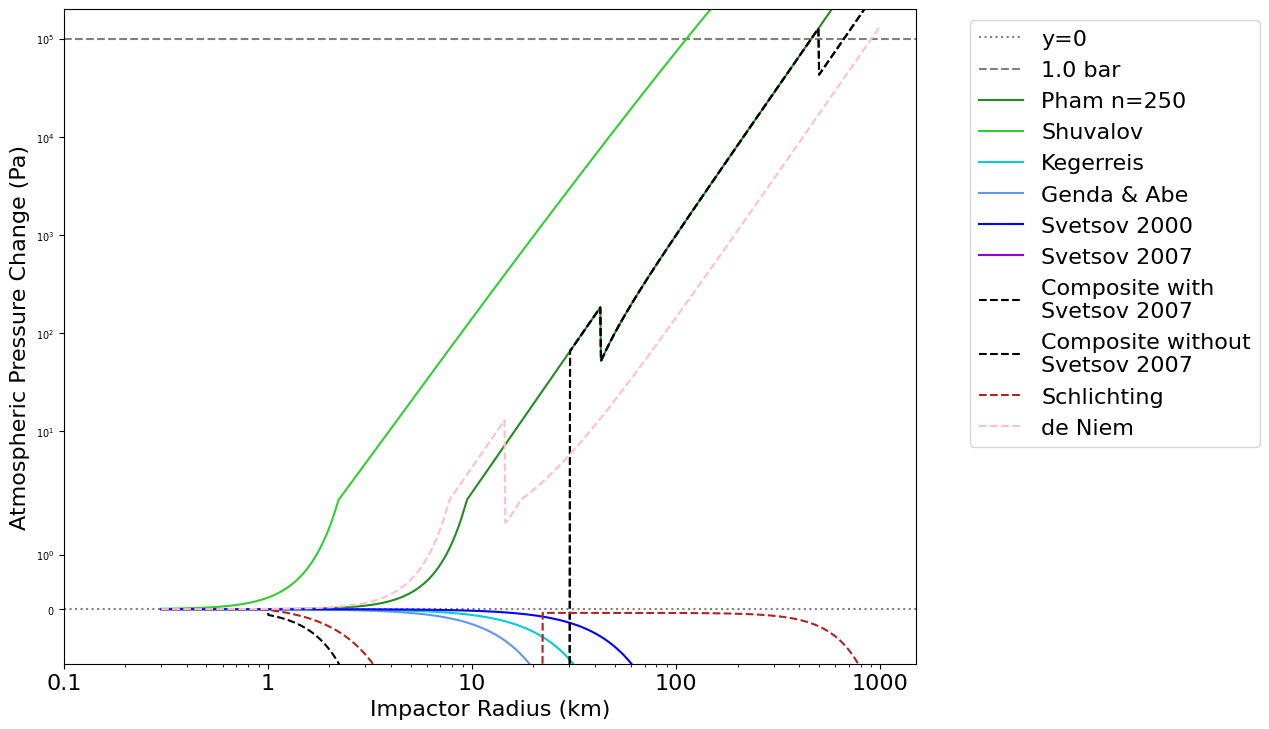

In [93]:
if verbiose==1: 
  #@title plotting
  plt.rcParams["figure.figsize"] = (11,8.5)
  plt.rcParams.update({'font.size': 16})
  if numruns==1:
    if outputdataunits=='mass' and atmchange==True:
      # plt.rcParams["figure.figsize"] = (7,7)
      plt.rcParams['ytick.labelsize']=7
      plt.axhline(0,color='gray',linestyle='dotted',label='y=0')
      plt.axhline(5.1e18,color='gray', linestyle='dashed',label=f"{startingP} bar")
      plt.axhline(-5.1e18,color='gray', linestyle='dashed')
      if 'pham10' in mods.Nickname.values: plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),pham10_delta_M,color=phamcolor,label='Pham n=10')
      if 'pham2400' in mods.Nickname.values: plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),pham2400_delta_M,color=shucolor,label='Pham n=2400')
      if 'pham' in mods.Nickname.values: plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),pham_delta_M,color=shucolor,label='Pham n='+str(round(n)))
      if 'shu' in mods.Nickname.values: plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),shu_delta_M,color=gacolor,label='Shuvalov')
      if 'kerr' in mods.Nickname.values: plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),kerr_delta_M,color=kerrcolor,label='Kegerreis')
      if 'ga' in mods.Nickname.values: plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),ga_delta_M,color=svetcolor,label='Genda & Abe')
      if 'svet' in mods.Nickname.values: plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),svet_delta_M,color=svet07color,label='Svetsov 2000')
      if 'svet07' in mods.Nickname.values: plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),svet07_delta_M,color='orchid',label='Svetsov 2007')
      if 'comps' in mods.Nickname.values: plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),comps_delta_M,color=compscolor,label='Composite with\nSvetsov 2007',linestyle='dashed')
      if 'compns' in mods.Nickname.values: plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),compns_delta_M,color='black',label='Composite without\nSvetsov 2007',linestyle='dashed')
      if 'hilke' in mods.Nickname.values: plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),hilke_delta_M,color=hilkecolor,label='Schlichting',linestyle='dashed')
      if 'deniem' in mods.Nickname.values: plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),deniem_delta_M,color=deniemcolor,label='de Niem',linestyle='dashed')

      plt.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
      # plt.xscale('log')
      plt.yscale('symlog')
      plt.xlabel('cumulative number of impacts')
      plt.ylabel('mass change (kg)')
      plt.ylim(-1e18,1e22)

    if outputdataunits=='pressure' and atmchange==True:
      # plt.rcParams["figure.figsize"] = (7,7)
      plt.rcParams['ytick.labelsize']=7
      plt.axhline(0,color='gray',linestyle='dotted',label='y=0')
      plt.axhline(atmmass_to_surfacepressure(r_planet,presentday_atm_m,gravity),color='gray', linestyle='dashed',label=f"{startingP} bar")
      # plt.axhline(-atmmass_to_surfacepressure(r_planet,presentday_atm_m,gravity),color='gray', linestyle='dashed')
      if 'pham10' in mods.Nickname.values: plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),pham10_delta_P,color='forestgreen',label='Pham n=10')
      if 'pham2400' in mods.Nickname.values: plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),pham2400_delta_P,color=shucolor,label='Pham n=2400')
      if 'pham' in mods.Nickname.values: plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),pham_delta_P,color=shucolor,label='Pham n='+str(round(n)))
      if 'shu' in mods.Nickname.values: plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),shu_delta_P,color=gacolor,label='Shuvalov')
      if 'kerr' in mods.Nickname.values: plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),kerr_delta_P,color=kerrcolor,label='Kegerreis')
      if 'ga' in mods.Nickname.values: plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),ga_delta_P,color=svetcolor,label='Genda & Abe')
      if 'svet' in mods.Nickname.values: plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),svet_delta_P,color=svet07color,label='Svetsov 2000')
      if 'svet07' in mods.Nickname.values: plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),svet07_delta_P,color='orchid',label='Svetsov 2007')
      if 'comps' in mods.Nickname.values: plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),comps_delta_P,color=compscolor,label='Composite with\nSvetsov 2007',linestyle='dashed')
      if 'compns' in mods.Nickname.values: plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),compns_delta_P,color='black',label='Composite without\nSvetsov 2007',linestyle='dashed')
      if 'hilke' in mods.Nickname.values: plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),hilke_delta_P,color=hilkecolor,label='Schlichting',linestyle='dashed')
      if 'deniem' in mods.Nickname.values: plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),deniem_delta_P,color=deniemcolor,label='de Niem',linestyle='dashed')

      plt.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
      # plt.xscale('log')
      plt.yscale('symlog')
      plt.xlabel('cumulative number of impacts')
      plt.ylabel('atmospheric pressure (Pa)')
      # plt.ylim(-0.8e3,0.5e6)
      # plt.xlim(4.5e-3,5.7e-3)
      # plt.ylim(-0.6e-4,1e-4)

    if outputdataunits=='mass' and atmchange==False:
      # plt.rcParams["figure.figsize"] = (7,7)
      plt.rcParams['ytick.labelsize']=7
      plt.axhline(0,color='gray',linestyle='dotted',label='y=0')
      plt.axhline(5.1e18,color='gray', linestyle='dashed',label=f"{startingP} bar")
      plt.axhline(-5.1e18,color='gray', linestyle='dashed')
      if 'pham10' in mods.Nickname.values: plt.plot(r_imp_array,pham10_delta_M,color=phamcolor,label='Pham n=10')
      if 'pham2400' in mods.Nickname.values: plt.plot(r_imp_array,pham2400_delta_M,color=shucolor,label='Pham n=2400')
      if 'pham' in mods.Nickname.values: plt.plot(r_imp_array,pham_delta_M,color=shucolor,label='Pham n='+str(round(n)))
      if 'shu' in mods.Nickname.values: plt.plot(r_imp_array,shu_delta_M,color=gacolor,label='Shuvalov')
      if 'kerr' in mods.Nickname.values: plt.plot(r_imp_array,kerr_delta_M,color=kerrcolor,label='Kegerreis')
      if 'ga' in mods.Nickname.values: plt.plot(r_imp_array,ga_delta_M,color=svetcolor,label='Genda & Abe')
      if 'svet' in mods.Nickname.values: plt.plot(r_imp_array,svet_delta_M,color=svet07color,label='Svetsov 2000')
      if 'svet07' in mods.Nickname.values: plt.plot(r_imp_array,svet07_delta_M,color='orchid',label='Svetsov 2007')
      if 'comps' in mods.Nickname.values: plt.plot(r_imp_array,comps_delta_M,color=compscolor,label='Composite with\nSvetsov 2007',linestyle='dashed')
      if 'compns' in mods.Nickname.values: plt.plot(r_imp_array,compns_delta_M,color='black',label='Composite without\nSvetsov 2007',linestyle='dashed')
      if 'hilke' in mods.Nickname.values: plt.plot(r_imp_array,hilke_delta_M,color=hilkecolor,label='Schlichting',linestyle='dashed')
      if 'deniem' in mods.Nickname.values: plt.plot(r_imp_array,deniem_delta_M,color=deniemcolor,label='de Niem',linestyle='dashed')

      plt.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
      plt.xscale('log')
      plt.yscale('symlog')
      plt.xlabel('impactor radius (km)')
      plt.ylabel('mass change (kg)')
      plt.ylim(-1e18,1e22)
      plt.xticks(ticks=[0.1,1,10,100,1000],labels=[0.1,1,10,100,1000])

    if outputdataunits=='pressure' and atmchange==False:
      # plt.rcParams["figure.figsize"] = (7,7)
      plt.rcParams['ytick.labelsize']=7
      plt.axhline(0,color='gray',linestyle='dotted',label='y=0')
      plt.axhline(atmmass_to_surfacepressure(r_planet,presentday_atm_m,gravity),color='gray', linestyle='dashed',label=f"{startingP} bar")
      plt.axhline(-atmmass_to_surfacepressure(r_planet,presentday_atm_m,gravity),color='gray', linestyle='dashed')
      if 'pham10' in mods.Nickname.values: plt.plot(r_imp_array,pham10_delta_P,color='red',label='Pham n=10')
      if 'pham2400' in mods.Nickname.values: plt.plot(r_imp_array,pham2400_delta_P,color='orange',label='Pham n=2400')
      if 'pham' in mods.Nickname.values: plt.plot(r_imp_array,pham_delta_P,color='forestgreen',label='Pham n='+str(round(n)))
      if 'shu' in mods.Nickname.values: plt.plot(r_imp_array,shu_delta_P,color=shucolor,label='Shuvalov')
      if 'kerr' in mods.Nickname.values: plt.plot(r_imp_array,kerr_delta_P,color=kerrcolor,label='Kegerreis')
      if 'ga' in mods.Nickname.values: plt.plot(r_imp_array,ga_delta_P,color=gacolor,label='Genda & Abe')
      if 'svet' in mods.Nickname.values: plt.plot(r_imp_array,svet_delta_P,color=svetcolor,label='Svetsov 2000')
      if 'svet07' in mods.Nickname.values: plt.plot(r_imp_array,svet07_delta_P,color=svet07color,label='Svetsov 2007')
      if 'comps' in mods.Nickname.values: plt.plot(r_imp_array,comps_delta_P,color=compscolor,label='Composite with\nSvetsov 2007',linestyle='dashed')
      if 'compns' in mods.Nickname.values: plt.plot(r_imp_array,compns_delta_P,color='black',label='Composite without\nSvetsov 2007',linestyle='dashed')
      if 'hilke' in mods.Nickname.values: plt.plot(r_imp_array,hilke_delta_P,color=hilkecolor,label='Schlichting',linestyle='dashed')
      if 'deniem' in mods.Nickname.values: plt.plot(r_imp_array,deniem_delta_P,color=deniemcolor,label='de Niem',linestyle='dashed')


      plt.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
      plt.xscale('log')
      plt.yscale('symlog')
      plt.xlabel('Impactor Radius (km)')
      plt.ylabel('Atmospheric Pressure Change (Pa)')
      # plt.ylim(-0.5e4,0.2e9)
      plt.ylim(-1,2e5)
      plt.xticks(ticks=[0.1,1,10,100,1000],labels=[0.1,1,10,100,1000])


    '''Pham (n=250) forestgreen
    Shuvalov darkturquoise
    Genda and Abe cornflowerblue
    Svetsov 2000 blue
    Svetsov 2007 darkviolet'''

  else:
    randomlychosensizevals=list(range(numimps))
    if outputdataunits=='pressure':
      # plt.figure(figsize=(17.39,10.41))
      # plt.rcParams.update({'font.size': 10})
      plotunc=True
      compplotunc=True

      if medianoravg=='avg':
        unclabel='1σ'
      elif medianoravg=='median':
        unclabel='IQR'


      if 'pham10' in mods.Nickname.values:  
        plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['pham10'][2]['avg']),color=pham10color,label='Pham n=10')
        if plotunc==True: plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['pham10'][2]['avg+std']),color=pham10color, linestyle='dashed'); plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['pham10'][2]['avg-std']),color=pham10color, linestyle='dashed')
      if 'pham2400' in mods.Nickname.values:  
        plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['pham2400'][2]['avg']),color=pham2400color,label='Pham n=2400')
        if plotunc==True: plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['pham2400'][2]['avg+std']),color=pham2400color, linestyle='dashed'); plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['pham2400'][2]['avg-std']),color=pham2400color, linestyle='dashed')
      if 'pham' in mods.Nickname.values:  
        plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['pham250'][2]['avg']),color=phamcolor,label='Pham n='+str(round(n)))
        if plotunc==True: plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['pham250'][2]['avg+std']),color=phamcolor, linestyle='dashed'); plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['pham250'][2]['avg-std']),color=phamcolor, linestyle='dashed')
      if 'shu' in mods.Nickname.values:  
        plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['shu'][2]['avg']),color=shucolor,label='Shuvalov')
        if plotunc==True: plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['shu'][2]['avg+std']),color=shucolor, linestyle='dashed'); plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['shu'][2]['avg-std']),color=shucolor, linestyle='dashed')
      if 'kerr' in mods.Nickname.values:  
        plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['kerr'][2]['avg']),color=kerrcolor,label='Kegerreis')
        if plotunc==True: plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['kerr'][2]['avg+std']),color=kerrcolor, linestyle='dashed'); plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['kerr'][2]['avg-std']),color=kerrcolor, linestyle='dashed')
      if 'ga' in mods.Nickname.values:  
        plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['ga'][2]['avg']),color=gacolor,label='Genda & Abe')
        if plotunc==True: plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['ga'][2]['avg+std']),color=gacolor, linestyle='dashed'); plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['ga'][2]['avg-std']),color=gacolor, linestyle='dashed')
      if 'svet' in mods.Nickname.values: 
        plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['svet'][2]['avg']),color=svetcolor,label='Svetsov 2000')
        if plotunc==True: plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['svet'][2]['avg+std']),color=svetcolor, linestyle='dashed'); plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['svet'][2]['avg-std']),color=svetcolor, linestyle='dashed')
      if 'svet07' in mods.Nickname.values: 
        plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['svet07'][2]['avg']),color=svet07color,label='Svetsov 2007')
        if plotunc==True: plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['svet07'][2]['avg+std']),color=svet07color, linestyle='dashed'); plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['svet07'][2]['avg-std']),color=svet07color, linestyle='dashed')
      if 'hilke' in mods.Nickname.values: 
        plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['hilke'][2]['avg']),color=hilkecolor,label='Schlichting')
        if hilkeplotunc==True: plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['hilke'][2]['avg+std']),color=hilkecolor, linestyle='dashed'); plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['hilke'][2]['avg-std']),color=hilkecolor, linestyle='dashed')
      if 'deniem' in mods.Nickname.values: 
        plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['deniem'][2]['avg']),color=deniemcolor,label='de Niem')
        if plotunc==True: plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['deniem'][2]['avg+std']),color=deniemcolor, linestyle='dashed'); plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['deniem'][2]['avg-std']),color=deniemcolor, linestyle='dashed')
      if 'comps' in mods.Nickname.values: 
        plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['comps'][2]['avg']),color=compcolor,label='Composite with\nSvetsov 2007')
        if compplotunc==True: plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['comps'][2]['avg+std']),color=compscolor, linestyle='dashed', label=unclabel); plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['comps'][2]['avg-std']),color=compscolor, linestyle='dashed')
      if 'compns' in mods.Nickname.values: 
        plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['compns'][2]['avg']),color=compcolor,label='Composite without\nSvetsov 2007')
        if compplotunc==True: plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['compns'][2]['avg+std']),color=compcolor, linestyle='dashed', label=unclabel); plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['compns'][2]['avg-std']),color=compcolor, linestyle='dashed')


      plt.axhline(atmmass_to_surfacepressure(r_planet,presentday_atm_m,gravity),color='gray', linestyle='dotted',label=f"{startingP} bar")
      plt.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
      # plt.legend(loc='upper left')
      # plt.xscale('log')
      # plt.yscale('log')
      plt.yscale('symlog')
      plt.xlabel('Cumulative Number of Impacts')
      plt.ylabel('Atmospheric Pressure (Pa)')
      # plt.ylim(-0.1,4e7)
      plt.ylim(10.,1e7)

    elif outputdataunits=='mass':
      print('the colors here are all messed up')
      plotunc=False
      compplotunc=True
      if 'pham10' in mods.Nickname.values:  
        plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['pham10'][2]['avg']),color=phamcolor,label='Pham n=10')
        if plotunc==True: plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['pham10'][2]['avg+std']),color=phamcolor, linestyle='dashed'); plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['pham10'][2]['avg-std']),color=phamcolor, linestyle='dashed')
      if 'pham2400' in mods.Nickname.values:  
        plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['pham2400'][2]['avg']),color=shucolor,label='Pham n=2400')
        if plotunc==True: plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['pham2400'][2]['avg+std']),color=shucolor, linestyle='dashed'); plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['pham2400'][2]['avg-std']),color=shucolor, linestyle='dashed')
      if 'pham' in mods.Nickname.values:  
        plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['pham250'][2]['avg']),color=shucolor,label='Pham n='+str(round(n)))
        if plotunc==True: plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['pham250'][2]['avg+std']),color=phamcolor, linestyle='dashed'); plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['pham250'][2]['avg-std']),color=shucolor, linestyle='dashed')
      if 'shu' in mods.Nickname.values:  
        plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['shu'][2]['avg']),color=gacolor,label='Shuvalov')
        if plotunc==True: plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['shu'][2]['avg+std']),color=gacolor, linestyle='dashed'); plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['shu'][2]['avg-std']),color=gacolor, linestyle='dashed')
      if 'kerr' in mods.Nickname.values:  
        plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['kerr'][2]['avg']),color=kerrcolor,label='Kegerreis')
        if plotunc==True: plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['kerr'][2]['avg+std']),color=kerrcolor, linestyle='dashed'); plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['kerr'][2]['avg-std']),color=kerrcolor, linestyle='dashed')
      if 'ga' in mods.Nickname.values:  
        plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['ga'][2]['avg']),color=gacolor,label='Genda & Abe')
        if plotunc==True: plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['ga'][2]['avg+std']),color=gacolor, linestyle='dashed'); plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['ga'][2]['avg-std']),color='blue', linestyle='dashed')
      if 'svet' in mods.Nickname.values: 
        plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['svet'][2]['avg']),color=svetcolor,label='Svetsov 2000')
        if plotunc==True: plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['svet'][2]['avg+std']),color=svetcolor, linestyle='dashed'); plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['svet'][2]['avg-std']),color=svet07color, linestyle='dashed')
      if 'svet07' in mods.Nickname.values: 
        plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['svet07'][2]['avg']),color='orchid',label='Svetsov 2007')
        if plotunc==True: plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['svet07'][2]['avg+std']),color='orchid', linestyle='dashed'); plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['svet07'][2]['avg-std']),color='orchid', linestyle='dashed')
      if 'comps' in mods.Nickname.values: 
        plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['comps'][2]['avg']),color=compscolor,label='Composite with\nSvetsov 2007')
        if compplotunc==True: plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['comps'][2]['avg+std']),color='black', linestyle='dashed', label='1σ'); plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['comps'][2]['avg-std']),color=compscolor, linestyle='dashed')
      if 'compns' in mods.Nickname.values: 
        plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['compns'][2]['avg']),color='black',label='Composite without\nSvetsov 2007')
        if compplotunc==True: plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['compns'][2]['avg+std']),color='black', linestyle='dashed', label='1σ'); plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['compns'][2]['avg-std']),color='black', linestyle='dashed')
      if 'hilke' in mods.Nickname.values: 
        plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['hilke'][2]['avg']),color=hilkecolor,label='Schlichting')
        if hilkeplotunc==True: plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['hilke'][2]['avg+std']),color=hilkecolor, linestyle='dashed'); plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['hilke'][2]['avg-std']),color=hilkecolor, linestyle='dashed')
      if 'deniem' in mods.Nickname.values: 
        plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['deniem'][2]['avg']),color=deniemcolor,label='de Niem')
        if plotunc==True: plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['deniem'][2]['avg+std']),color=deniemcolor, linestyle='dashed'); plt.plot(np.linspace(1,len(randomlychosensizevals),len(randomlychosensizevals)),list(processeddatadict['deniem'][2]['avg-std']),color=deniemcolor, linestyle='dashed')


      plt.axhline(atmmass_to_surfacepressure(r_planet,presentday_atm_m,gravity),color='gray', linestyle='dotted',label=f"{startingP} bar")
      plt.legend(bbox_to_anchor=(1.05, 1.0), loc='upper left')
      # plt.xscale('log')
      # plt.yscale('log')
      # plt.yscale('symlog')
      plt.xlabel('cumulative number of impacts')
      plt.ylabel('atm mass (kg)')

In [94]:
import matplotlib.patches as mpatches

plotunc=True
compplotunc=True
hilkeplotunc=True

if medianoravg=='avg':
    unclabel='1σ'
elif medianoravg=='median':
    unclabel='IQR'

x_vals = np.linspace(1, len(randomlychosensizevals), len(randomlychosensizevals))

plots = []

if 'svet07' in mods.Nickname.values:
    plot_svet07, = plt.plot(x_vals, list(processeddatadict['svet07'][2]['avg']), color=svet07color, label='Svetsov 2007',zorder=1)
    plots.append(plot_svet07)
    if plotunc:
        plt.fill_between(x_vals, list(processeddatadict['svet07'][2]['avg+std']), list(processeddatadict['svet07'][2]['avg-std']), color=svet07color, alpha=0.3,zorder=1)

if 'pham10' in mods.Nickname.values:
    plot_pham10, = plt.plot(x_vals, list(processeddatadict['pham10'][2]['avg']), color=pham10color, label='Pham n=10',zorder=2)
    plots.append(plot_pham10)
    if plotunc:
        plt.fill_between(x_vals, list(processeddatadict['pham10'][2]['avg+std']), list(processeddatadict['pham10'][2]['avg-std']), color=pham10color, alpha=0.3,zorder=2)

if 'pham2400' in mods.Nickname.values:
    plot_pham2400, = plt.plot(x_vals, list(processeddatadict['pham2400'][2]['avg']), color=pham2400color, label='Pham n=2400',zorder=2)
    plots.append(plot_pham2400)
    if plotunc:
        plt.fill_between(x_vals, list(processeddatadict['pham2400'][2]['avg+std']), list(processeddatadict['pham2400'][2]['avg-std']), color=pham2400color, alpha=0.3,zorder=2)

if 'pham' in mods.Nickname.values and csvoutput==True:
    plot_pham, = plt.plot(x_vals, list(processeddatadict['pham'][2]['avg']), color=phamcolor, label='Pham n='+str(round(n)),zorder=2)
    plots.append(plot_pham)
    if plotunc:
        plt.fill_between(x_vals, list(processeddatadict['pham'][2]['avg+std']), list(processeddatadict['pham'][2]['avg-std']), color=phamcolor, alpha=0.3,zorder=2)

if 'pham' in mods.Nickname.values  and pickleoutput==True:
    plot_pham, = plt.plot(x_vals, list(processeddatadict['pham'+str(n)][2]['avg']), color=phamcolor, label='Pham n='+str(round(n)),zorder=2)
    plots.append(plot_pham)
    if plotunc:
        plt.fill_between(x_vals, list(processeddatadict['pham'+str(n)][2]['avg+std']), list(processeddatadict['pham'+str(n)][2]['avg-std']), color=phamcolor, alpha=0.3,zorder=2)

if 'shu' in mods.Nickname.values:
    plot_shu, = plt.plot(x_vals, list(processeddatadict['shu'][2]['avg']), color=shucolor, label='Shuvalov',zorder=2)
    plots.append(plot_shu)
    if plotunc:
        plt.fill_between(x_vals, list(processeddatadict['shu'][2]['avg+std']), list(processeddatadict['shu'][2]['avg-std']), color=shucolor, alpha=0.3,zorder=2)

if 'kerr' in mods.Nickname.values:
    plot_kerr, = plt.plot(x_vals, list(processeddatadict['kerr'][2]['avg']), color=kerrcolor, label='Kegerreis',zorder=2)
    plots.append(plot_kerr)
    if plotunc:
        plt.fill_between(x_vals, list(processeddatadict['kerr'][2]['avg+std']), list(processeddatadict['kerr'][2]['avg-std']), color=kerrcolor, alpha=0.3,zorder=2)

if 'ga' in mods.Nickname.values:
    plot_ga, = plt.plot(x_vals, list(processeddatadict['ga'][2]['avg']), color=gacolor, label='Genda & Abe',zorder=2)
    plots.append(plot_ga)
    if plotunc:
        plt.fill_between(x_vals, list(processeddatadict['ga'][2]['avg+std']), list(processeddatadict['ga'][2]['avg-std']), color=gacolor, alpha=0.3,zorder=2)

if 'svet' in mods.Nickname.values:
    plot_svet, = plt.plot(x_vals, list(processeddatadict['svet'][2]['avg']), color=svetcolor, label='Svetsov 2000',zorder=2)
    plots.append(plot_svet)
    if plotunc:
        plt.fill_between(x_vals, list(processeddatadict['svet'][2]['avg+std']), list(processeddatadict['svet'][2]['avg-std']), color=svetcolor, alpha=0.3,zorder=2)

if 'comps' in mods.Nickname.values:
    plot_comps, = plt.plot(x_vals, list(processeddatadict['comps'][2]['avg']), color=compscolor, label='Composite with\nSvetsov 2007',zorder=2)
    plots.append(plot_comps)
    if compplotunc:
        plt.fill_between(x_vals, list(processeddatadict['comps'][2]['avg+std']), list(processeddatadict['comps'][2]['avg-std']), color=compscolor, alpha=0.3,zorder=2)

if 'compns' in mods.Nickname.values:
    plot_compns, = plt.plot(x_vals, list(processeddatadict['compns'][2]['avg']), color=compcolor, label='Composite without\nSvetsov 2007',zorder=2)
    plots.append(plot_compns)
    if compplotunc:
        plt.fill_between(x_vals, list(processeddatadict['compns'][2]['avg+std']), list(processeddatadict['compns'][2]['avg-std']), color=compcolor, alpha=0.3,zorder=2)

if 'hilke' in mods.Nickname.values:
    plot_hilke, = plt.plot(x_vals, list(processeddatadict['hilke'][2]['avg']), color=hilkecolor, label='Schlichting',zorder=2)
    plots.append(plot_hilke)
    if hilkeplotunc:
        plt.fill_between(x_vals, list(processeddatadict['hilke'][2]['avg+std']), list(processeddatadict['hilke'][2]['avg-std']), color=hilkecolor, alpha=0.3,zorder=2)

if 'deniem' in mods.Nickname.values:
    plot_deniem, = plt.plot(x_vals, list(processeddatadict['deniem'][2]['avg']), color=deniemcolor, label='de Niem',zorder=2)
    plots.append(plot_deniem)
    if plotunc:
        plt.fill_between(x_vals, list(processeddatadict['deniem'][2]['avg+std']), list(processeddatadict['deniem'][2]['avg-std']), color=deniemcolor, alpha=0.3,zorder=2)

atm_line = plt.axhline(atmmass_to_surfacepressure(r_planet, presentday_atm_m, gravity), color='gray', linestyle='dotted', label='1 Mars\nAtmosphere',zorder=2)

# Create a shaded area patch for IQR/1σ
unc_patch = mpatches.Patch(color=compcolor, alpha=0.3, label=unclabel)

startingPlabel='$P_0=$'+str(startingP)+' bar'

# Reordering the legend manually
handles, labels = plt.gca().get_legend_handles_labels()
ordered_labels = ['Pham n='+str(round(n)), 'Shuvalov', 'Kegerreis', 'Genda & Abe', 'Svetsov 2000', 'Svetsov 2007', 'Schlichting', 'de Niem', 'Composite with\nSvetsov 2007', 'Composite without\nSvetsov 2007', unclabel, startingPlabel]
ordered_handles = [plot_pham, plot_shu, plot_kerr, plot_ga, plot_svet, plot_svet07, plot_hilke, plot_deniem, plot_comps, plot_compns, unc_patch, atm_line]

# ordered_labels = ['Pham n='+str(round(n)), 'Shuvalov', 'Genda & Abe', 'Svetsov 2000', 'Schlichting', 'Composite', unclabel, '1 bar']
# ordered_handles = [plot_pham, plot_shu, plot_ga, plot_svet, plot_hilke, plot_comp, unc_patch, atm_line]

plt.legend(ordered_handles, ordered_labels, bbox_to_anchor=(1.05, 1.0), loc='upper left')
# plt.legend(loc='upper left')
# plt.xscale('log')
# plt.yscale('log')
plt.yscale('symlog')
plt.xlabel('Cumulative Number of Impacts')
plt.ylabel('Atmospheric Pressure (Pa)')
# plt.ylim(-0.1, 2e6)

# plt.ylim(1e5,1e5+.02)
# ticks = [0.95e5,0.975e5,1e5,1.025e5]
# tick_labels = ['$9.50 × 10^4$','$9.75 × 10^4$','$1.00 × 10^5$','$1.025 × 10^4$',]
# plt.yticks(ticks, tick_labels)
# plt.xlim(0,10000)
# plt.title('50,000 impactors truncated to 10,000')
#quickjump
# plt.xlim(0,50)


# if medianoravg=='avg':
#     maxlist=[list(processeddatadict['comps'][2]['avg'])[-1]+list(processeddatadict['comps'][2]['std'])[-1],
#              list(processeddatadict['compns'][2]['avg'])[-1]+list(processeddatadict['compns'][2]['std'])[-1],
#              list(processeddatadict['svet'][2]['avg'])[-1]+list(processeddatadict['svet'][2]['std'])[-1],
#              list(processeddatadict['svet07'][2]['avg'])[-1]+list(processeddatadict['svet07'][2]['std'])[-1],
#              list(processeddatadict['shu'][2]['avg'])[-1]+list(processeddatadict['shu'][2]['std'])[-1],
#              list(processeddatadict['pham'][2]['avg'])[-1]+list(processeddatadict['pham'][2]['std'])[-1],
#              list(processeddatadict['ga'][2]['avg'])[-1]+list(processeddatadict['ga'][2]['std'])[-1],
#              list(processeddatadict['hilke'][2]['avg'])[-1]+list(processeddatadict['hilke'][2]['std'])[-1],
#              list(processeddatadict['deniem'][2]['avg'])[-1]+list(processeddatadict['deniem'][2]['std'])[-1],
#              atmmass_to_surfacepressure(r_planet, presentday_atm_m, gravity)]
#     minlist=[list(processeddatadict['comps'][2]['avg'])[-1]-list(processeddatadict['comps'][2]['std'])[-1],
#              list(processeddatadict['compns'][2]['avg'])[-1]-list(processeddatadict['compns'][2]['std'])[-1],
#              list(processeddatadict['svet'][2]['avg'])[-1]-list(processeddatadict['svet'][2]['std'])[-1],
#              list(processeddatadict['svet07'][2]['avg'])[-1]-list(processeddatadict['svet07'][2]['std'])[-1],
#              list(processeddatadict['shu'][2]['avg'])[-1]-list(processeddatadict['shu'][2]['std'])[-1],
#              list(processeddatadict['pham'][2]['avg'])[-1]-list(processeddatadict['pham'][2]['std'])[-1],
#              list(processeddatadict['ga'][2]['avg'])[-1]-list(processeddatadict['ga'][2]['std'])[-1],
#              list(processeddatadict['hilke'][2]['avg'])[-1]-list(processeddatadict['hilke'][2]['std'])[-1],
#              list(processeddatadict['deniem'][2]['avg'])[-1]-list(processeddatadict['deniem'][2]['std'])[-1],
#              0.]
#     plt.ylim(min(minlist)*0.9,max(maxlist)*1.1)

# elif medianoravg=='median':
#     maxlist=[list(processeddatadict['comps'][2]['avg+std'])[-1],
#              list(processeddatadict['compns'][2]['avg+std'])[-1],
#              list(processeddatadict['svet'][2]['avg+std'])[-1],
#              list(processeddatadict['svet07'][2]['avg+std'])[-1],
#              list(processeddatadict['shu'][2]['avg+std'])[-1],
#              list(processeddatadict['pham'][2]['avg+std'])[-1],
#              list(processeddatadict['ga'][2]['avg+std'])[-1],
#              list(processeddatadict['hilke'][2]['avg+std'])[-1],
#              list(processeddatadict['deniem'][2]['avg+std'])[-1],
#              atmmass_to_surfacepressure(r_planet, presentday_atm_m, gravity)]
#     minlist=[list(processeddatadict['comps'][2]['avg-std'])[-1],
#              list(processeddatadict['compns'][2]['avg-std'])[-1],
#              list(processeddatadict['svet'][2]['avg-std'])[-1],
#              list(processeddatadict['svet07'][2]['avg-std'])[-1],
#              list(processeddatadict['shu'][2]['avg-std'])[-1],
#              list(processeddatadict['pham'][2]['avg-std'])[-1],
#              list(processeddatadict['ga'][2]['avg-std'])[-1],
#              list(processeddatadict['hilke'][2]['avg-std'])[-1],
#              list(processeddatadict['deniem'][2]['avg-std'])[-1],
#              0.]
#     plt.ylim(min(minlist)*0.9,max(maxlist)*1.1)
plt.ylim(0)
plt.savefig(os.path.abspath(os.getcwd())+'/bigfig.png')

NameError: name 'randomlychosensizevals' is not defined

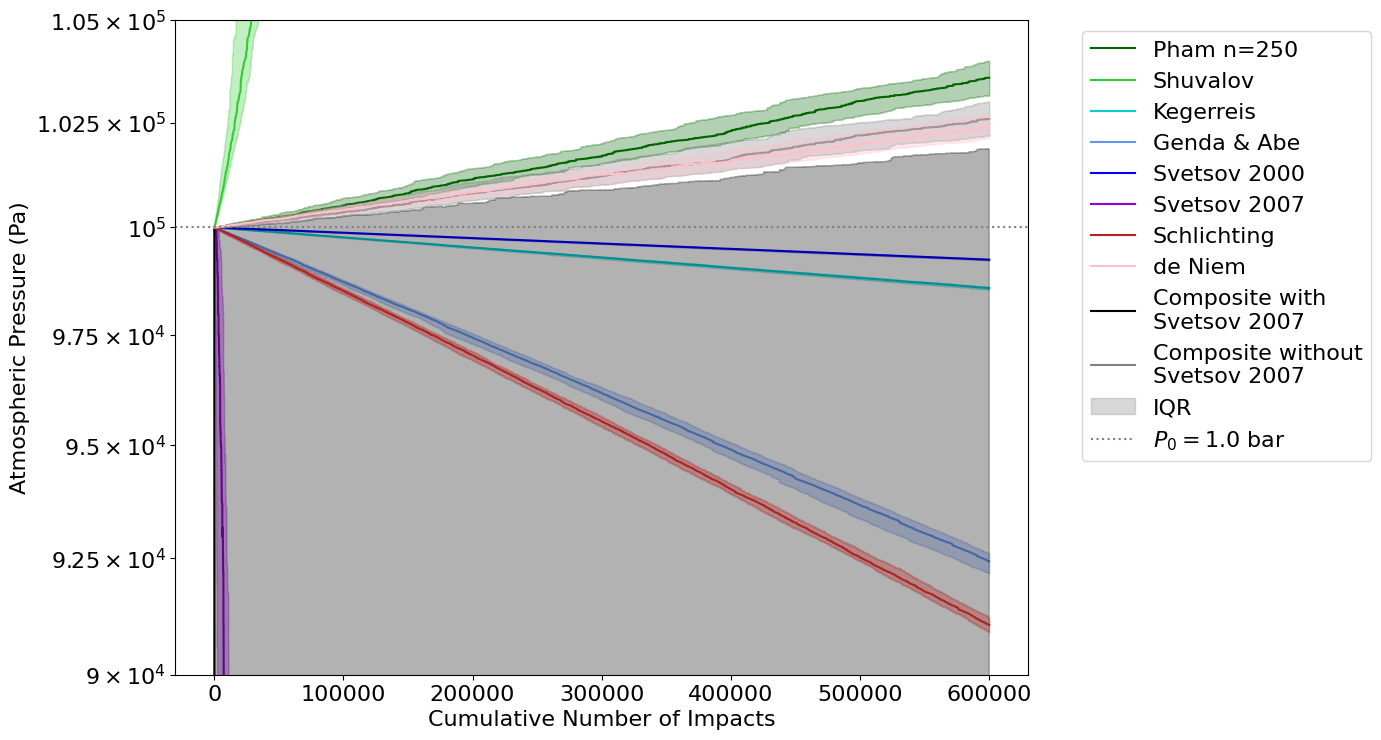

In [ ]:
import matplotlib.patches as mpatches

plotunc=True
compplotunc=True
hilkeplotunc=True

if medianoravg=='avg':
    unclabel='1σ'
elif medianoravg=='median':
    unclabel='IQR'

x_vals = np.linspace(1, len(randomlychosensizevals), len(randomlychosensizevals))

plots = []

if 'svet07' in mods.Nickname.values:
    plot_svet07, = plt.plot(x_vals, list(processeddatadict['svet07'][2]['avg']), color=svet07color, label='Svetsov 2007',zorder=1)
    plots.append(plot_svet07)
    if plotunc:
        plt.fill_between(x_vals, list(processeddatadict['svet07'][2]['avg+std']), list(processeddatadict['svet07'][2]['avg-std']), color=svet07color, alpha=0.3,zorder=1)

if 'pham10' in mods.Nickname.values:
    plot_pham10, = plt.plot(x_vals, list(processeddatadict['pham10'][2]['avg']), color=pham10color, label='Pham n=10',zorder=2)
    plots.append(plot_pham10)
    if plotunc:
        plt.fill_between(x_vals, list(processeddatadict['pham10'][2]['avg+std']), list(processeddatadict['pham10'][2]['avg-std']), color=pham10color, alpha=0.3,zorder=2)

if 'pham2400' in mods.Nickname.values:
    plot_pham2400, = plt.plot(x_vals, list(processeddatadict['pham2400'][2]['avg']), color=pham2400color, label='Pham n=2400',zorder=2)
    plots.append(plot_pham2400)
    if plotunc:
        plt.fill_between(x_vals, list(processeddatadict['pham2400'][2]['avg+std']), list(processeddatadict['pham2400'][2]['avg-std']), color=pham2400color, alpha=0.3,zorder=2)

if 'pham' in mods.Nickname.values and csvoutput==True:
    plot_pham, = plt.plot(x_vals, list(processeddatadict['pham'][2]['avg']), color=phamcolor, label='Pham n='+str(round(n)),zorder=2)
    plots.append(plot_pham)
    if plotunc:
        plt.fill_between(x_vals, list(processeddatadict['pham'][2]['avg+std']), list(processeddatadict['pham'][2]['avg-std']), color=phamcolor, alpha=0.3,zorder=2)

if 'pham' in mods.Nickname.values  and pickleoutput==True:
    plot_pham, = plt.plot(x_vals, list(processeddatadict['pham'+str(n)][2]['avg']), color=phamcolor, label='Pham n='+str(round(n)),zorder=2)
    plots.append(plot_pham)
    if plotunc:
        plt.fill_between(x_vals, list(processeddatadict['pham'+str(n)][2]['avg+std']), list(processeddatadict['pham'+str(n)][2]['avg-std']), color=phamcolor, alpha=0.3,zorder=2)

if 'shu' in mods.Nickname.values:
    plot_shu, = plt.plot(x_vals, list(processeddatadict['shu'][2]['avg']), color=shucolor, label='Shuvalov',zorder=2)
    plots.append(plot_shu)
    if plotunc:
        plt.fill_between(x_vals, list(processeddatadict['shu'][2]['avg+std']), list(processeddatadict['shu'][2]['avg-std']), color=shucolor, alpha=0.3,zorder=2)

if 'kerr' in mods.Nickname.values:
    plot_kerr, = plt.plot(x_vals, list(processeddatadict['kerr'][2]['avg']), color=kerrcolor, label='Kegerreis',zorder=2)
    plots.append(plot_kerr)
    if plotunc:
        plt.fill_between(x_vals, list(processeddatadict['kerr'][2]['avg+std']), list(processeddatadict['kerr'][2]['avg-std']), color=kerrcolor, alpha=0.3,zorder=2)

if 'ga' in mods.Nickname.values:
    plot_ga, = plt.plot(x_vals, list(processeddatadict['ga'][2]['avg']), color=gacolor, label='Genda & Abe',zorder=2)
    plots.append(plot_ga)
    if plotunc:
        plt.fill_between(x_vals, list(processeddatadict['ga'][2]['avg+std']), list(processeddatadict['ga'][2]['avg-std']), color=gacolor, alpha=0.3,zorder=2)

if 'svet' in mods.Nickname.values:
    plot_svet, = plt.plot(x_vals, list(processeddatadict['svet'][2]['avg']), color=svetcolor, label='Svetsov 2000',zorder=2)
    plots.append(plot_svet)
    if plotunc:
        plt.fill_between(x_vals, list(processeddatadict['svet'][2]['avg+std']), list(processeddatadict['svet'][2]['avg-std']), color=svetcolor, alpha=0.3,zorder=2)

if 'comps' in mods.Nickname.values:
    plot_comps, = plt.plot(x_vals, list(processeddatadict['comps'][2]['avg']), color=compscolor, label='Composite with\nSvetsov 2007',zorder=2)
    plots.append(plot_comps)
    if compplotunc:
        plt.fill_between(x_vals, list(processeddatadict['comps'][2]['avg+std']), list(processeddatadict['comps'][2]['avg-std']), color=compscolor, alpha=0.3,zorder=2)

if 'compns' in mods.Nickname.values:
    plot_compns, = plt.plot(x_vals, list(processeddatadict['compns'][2]['avg']), color=compcolor, label='Composite without\nSvetsov 2007',zorder=2)
    plots.append(plot_compns)
    if compplotunc:
        plt.fill_between(x_vals, list(processeddatadict['compns'][2]['avg+std']), list(processeddatadict['compns'][2]['avg-std']), color=compcolor, alpha=0.3,zorder=2)

if 'hilke' in mods.Nickname.values:
    plot_hilke, = plt.plot(x_vals, list(processeddatadict['hilke'][2]['avg']), color=hilkecolor, label='Schlichting',zorder=2)
    plots.append(plot_hilke)
    if hilkeplotunc:
        plt.fill_between(x_vals, list(processeddatadict['hilke'][2]['avg+std']), list(processeddatadict['hilke'][2]['avg-std']), color=hilkecolor, alpha=0.3,zorder=2)

if 'deniem' in mods.Nickname.values:
    plot_deniem, = plt.plot(x_vals, list(processeddatadict['deniem'][2]['avg']), color=deniemcolor, label='de Niem',zorder=2)
    plots.append(plot_deniem)
    if plotunc:
        plt.fill_between(x_vals, list(processeddatadict['deniem'][2]['avg+std']), list(processeddatadict['deniem'][2]['avg-std']), color=deniemcolor, alpha=0.3,zorder=2)

atm_line = plt.axhline(atmmass_to_surfacepressure(r_planet, presentday_atm_m, gravity), color='gray', linestyle='dotted', label='1 Mars\nAtmosphere',zorder=2)

# Create a shaded area patch for IQR/1σ
unc_patch = mpatches.Patch(color=compcolor, alpha=0.3, label=unclabel)

startingPlabel='$P_0=$'+str(startingP)+' bar'

# Reordering the legend manually
handles, labels = plt.gca().get_legend_handles_labels()
ordered_labels = ['Pham n='+str(round(n)), 'Shuvalov', 'Kegerreis', 'Genda & Abe', 'Svetsov 2000', 'Svetsov 2007', 'Schlichting', 'de Niem', 'Composite with\nSvetsov 2007', 'Composite without\nSvetsov 2007', unclabel, startingPlabel]
ordered_handles = [plot_pham, plot_shu, plot_kerr, plot_ga, plot_svet, plot_svet07, plot_hilke, plot_deniem, plot_comps, plot_compns, unc_patch, atm_line]

# ordered_labels = ['Pham n='+str(round(n)), 'Shuvalov', 'Genda & Abe', 'Svetsov 2000', 'Schlichting', 'Composite', unclabel, '1 bar']
# ordered_handles = [plot_pham, plot_shu, plot_ga, plot_svet, plot_hilke, plot_comp, unc_patch, atm_line]

plt.legend(ordered_handles, ordered_labels, bbox_to_anchor=(1.05, 1.0), loc='upper left')
# plt.legend(loc='upper left')
# plt.xscale('log')
# plt.yscale('log')
plt.yscale('symlog')
plt.xlabel('Cumulative Number of Impacts')
plt.ylabel('Atmospheric Pressure (Pa)')


plt.ylim(0.9e5,1.05e5)
ticks = [0.9e5,0.925e5,0.95e5,0.975e5,1e5,1.025e5,1.05e5]
# tick_labels = ['$9.50 × 10^4$','$9.75 × 10^4$','$1.00 × 10^5$','$1.025 × 10^4$',]
plt.yticks(ticks)#, tick_labels)

plt.savefig(os.path.abspath(os.getcwd())+'/medfig.png')

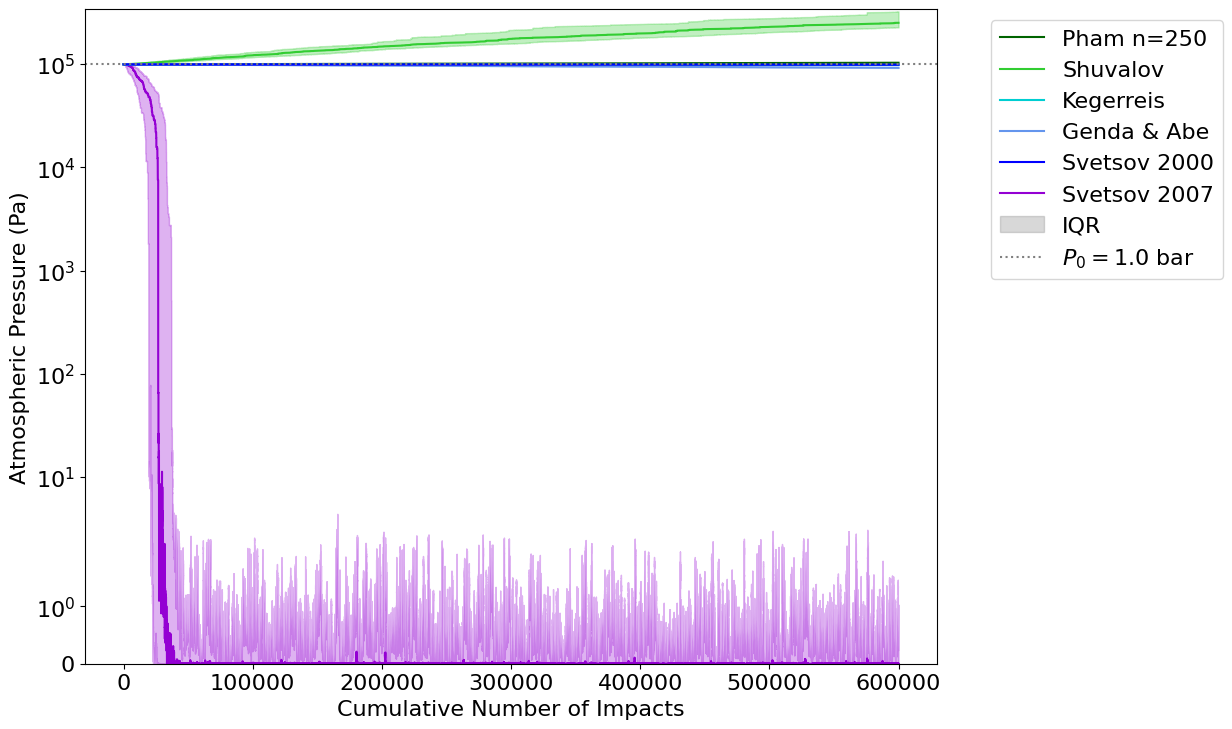

In [ ]:
import matplotlib.patches as mpatches

plotunc=True
compplotunc=True
hilkeplotunc=True

if medianoravg=='avg':
    unclabel='1σ'
elif medianoravg=='median':
    unclabel='IQR'

x_vals = np.linspace(1, len(randomlychosensizevals), len(randomlychosensizevals))

plots = []

if 'svet07' in mods.Nickname.values:
    plot_svet07, = plt.plot(x_vals, list(processeddatadict['svet07'][2]['avg']), color=svet07color, label='Svetsov 2007',zorder=1)
    plots.append(plot_svet07)
    if plotunc:
        plt.fill_between(x_vals, list(processeddatadict['svet07'][2]['avg+std']), list(processeddatadict['svet07'][2]['avg-std']), color=svet07color, alpha=0.3,zorder=1)

if 'pham10' in mods.Nickname.values:
    plot_pham10, = plt.plot(x_vals, list(processeddatadict['pham10'][2]['avg']), color=pham10color, label='Pham n=10',zorder=2)
    plots.append(plot_pham10)
    if plotunc:
        plt.fill_between(x_vals, list(processeddatadict['pham10'][2]['avg+std']), list(processeddatadict['pham10'][2]['avg-std']), color=pham10color, alpha=0.3,zorder=2)

if 'pham2400' in mods.Nickname.values:
    plot_pham2400, = plt.plot(x_vals, list(processeddatadict['pham2400'][2]['avg']), color=pham2400color, label='Pham n=2400',zorder=2)
    plots.append(plot_pham2400)
    if plotunc:
        plt.fill_between(x_vals, list(processeddatadict['pham2400'][2]['avg+std']), list(processeddatadict['pham2400'][2]['avg-std']), color=pham2400color, alpha=0.3,zorder=2)

if 'pham' in mods.Nickname.values and csvoutput==True:
    plot_pham, = plt.plot(x_vals, list(processeddatadict['pham'][2]['avg']), color=phamcolor, label='Pham n='+str(round(n)),zorder=2)
    plots.append(plot_pham)
    if plotunc:
        plt.fill_between(x_vals, list(processeddatadict['pham'][2]['avg+std']), list(processeddatadict['pham'][2]['avg-std']), color=phamcolor, alpha=0.3,zorder=2)

if 'pham' in mods.Nickname.values  and pickleoutput==True:
    plot_pham, = plt.plot(x_vals, list(processeddatadict['pham'+str(n)][2]['avg']), color=phamcolor, label='Pham n='+str(round(n)),zorder=2)
    plots.append(plot_pham)
    if plotunc:
        plt.fill_between(x_vals, list(processeddatadict['pham'+str(n)][2]['avg+std']), list(processeddatadict['pham'+str(n)][2]['avg-std']), color=phamcolor, alpha=0.3,zorder=2)

if 'shu' in mods.Nickname.values:
    plot_shu, = plt.plot(x_vals, list(processeddatadict['shu'][2]['avg']), color=shucolor, label='Shuvalov',zorder=2)
    plots.append(plot_shu)
    if plotunc:
        plt.fill_between(x_vals, list(processeddatadict['shu'][2]['avg+std']), list(processeddatadict['shu'][2]['avg-std']), color=shucolor, alpha=0.3,zorder=2)

if 'kerr' in mods.Nickname.values:
    plot_kerr, = plt.plot(x_vals, list(processeddatadict['kerr'][2]['avg']), color=kerrcolor, label='Kegerreis',zorder=2)
    plots.append(plot_kerr)
    if plotunc:
        plt.fill_between(x_vals, list(processeddatadict['kerr'][2]['avg+std']), list(processeddatadict['kerr'][2]['avg-std']), color=kerrcolor, alpha=0.3,zorder=2)

if 'ga' in mods.Nickname.values:
    plot_ga, = plt.plot(x_vals, list(processeddatadict['ga'][2]['avg']), color=gacolor, label='Genda & Abe',zorder=2)
    plots.append(plot_ga)
    if plotunc:
        plt.fill_between(x_vals, list(processeddatadict['ga'][2]['avg+std']), list(processeddatadict['ga'][2]['avg-std']), color=gacolor, alpha=0.3,zorder=2)

if 'svet' in mods.Nickname.values:
    plot_svet, = plt.plot(x_vals, list(processeddatadict['svet'][2]['avg']), color=svetcolor, label='Svetsov 2000',zorder=2)
    plots.append(plot_svet)
    if plotunc:
        plt.fill_between(x_vals, list(processeddatadict['svet'][2]['avg+std']), list(processeddatadict['svet'][2]['avg-std']), color=svetcolor, alpha=0.3,zorder=2)

# if 'comps' in mods.Nickname.values:
#     plot_comps, = plt.plot(x_vals, list(processeddatadict['comps'][2]['avg']), color=compscolor, label='Composite with\nSvetsov 2007',zorder=2)
#     plots.append(plot_comps)
#     if compplotunc:
#         plt.fill_between(x_vals, list(processeddatadict['comps'][2]['avg+std']), list(processeddatadict['comps'][2]['avg-std']), color=compscolor, alpha=0.3,zorder=2)

# if 'compns' in mods.Nickname.values:
#     plot_compns, = plt.plot(x_vals, list(processeddatadict['compns'][2]['avg']), color=compcolor, label='Composite without\nSvetsov 2007',zorder=2)
#     plots.append(plot_compns)
#     if compplotunc:
#         plt.fill_between(x_vals, list(processeddatadict['compns'][2]['avg+std']), list(processeddatadict['compns'][2]['avg-std']), color=compcolor, alpha=0.3,zorder=2)

# if 'hilke' in mods.Nickname.values:
#     plot_hilke, = plt.plot(x_vals, list(processeddatadict['hilke'][2]['avg']), color=hilkecolor, label='Schlichting',zorder=2)
#     plots.append(plot_hilke)
#     if hilkeplotunc:
#         plt.fill_between(x_vals, list(processeddatadict['hilke'][2]['avg+std']), list(processeddatadict['hilke'][2]['avg-std']), color=hilkecolor, alpha=0.3,zorder=2)

# if 'deniem' in mods.Nickname.values:
#     plot_deniem, = plt.plot(x_vals, list(processeddatadict['deniem'][2]['avg']), color=deniemcolor, label='de Niem',zorder=2)
#     plots.append(plot_deniem)
#     if plotunc:
#         plt.fill_between(x_vals, list(processeddatadict['deniem'][2]['avg+std']), list(processeddatadict['deniem'][2]['avg-std']), color=deniemcolor, alpha=0.3,zorder=2)

atm_line = plt.axhline(atmmass_to_surfacepressure(r_planet, presentday_atm_m, gravity), color='gray', linestyle='dotted', label='1 Mars\nAtmosphere',zorder=2)

# Create a shaded area patch for IQR/1σ
unc_patch = mpatches.Patch(color=compcolor, alpha=0.3, label=unclabel)

startingPlabel='$P_0=$'+str(startingP)+' bar'

# Reordering the legend manually
# handles, labels = plt.gca().get_legend_handles_labels()
# ordered_labels = ['Pham n='+str(round(n)), 'Shuvalov', 'Kegerreis', 'Genda & Abe', 'Svetsov 2000', 'Svetsov 2007', 'Schlichting', 'de Niem', 'Composite with\nSvetsov 2007', 'Composite without\nSvetsov 2007', unclabel, startingPlabel]
# ordered_handles = [plot_pham, plot_shu, plot_kerr, plot_ga, plot_svet, plot_svet07, plot_hilke, plot_deniem, plot_comps, plot_compns, unc_patch, atm_line]

handles, labels = plt.gca().get_legend_handles_labels()
ordered_labels = ['Pham n='+str(round(n)), 'Shuvalov', 'Kegerreis', 'Genda & Abe', 'Svetsov 2000', 'Svetsov 2007', unclabel, startingPlabel]
ordered_handles = [plot_pham, plot_shu, plot_kerr, plot_ga, plot_svet, plot_svet07, unc_patch, atm_line]

# ordered_labels = ['Pham n='+str(round(n)), 'Shuvalov', 'Genda & Abe', 'Svetsov 2000', 'Schlichting', 'Composite', unclabel, '1 bar']
# ordered_handles = [plot_pham, plot_shu, plot_ga, plot_svet, plot_hilke, plot_comp, unc_patch, atm_line]

plt.legend(ordered_handles, ordered_labels, bbox_to_anchor=(1.05, 1.0), loc='upper left')
# plt.legend(loc='upper left')
# plt.xscale('log')
# plt.yscale('log')
plt.yscale('symlog')
plt.xlabel('Cumulative Number of Impacts')
plt.ylabel('Atmospheric Pressure (Pa)')

plt.ylim(0)
plt.savefig(os.path.abspath(os.getcwd())+'/nocompsbigfig.png')

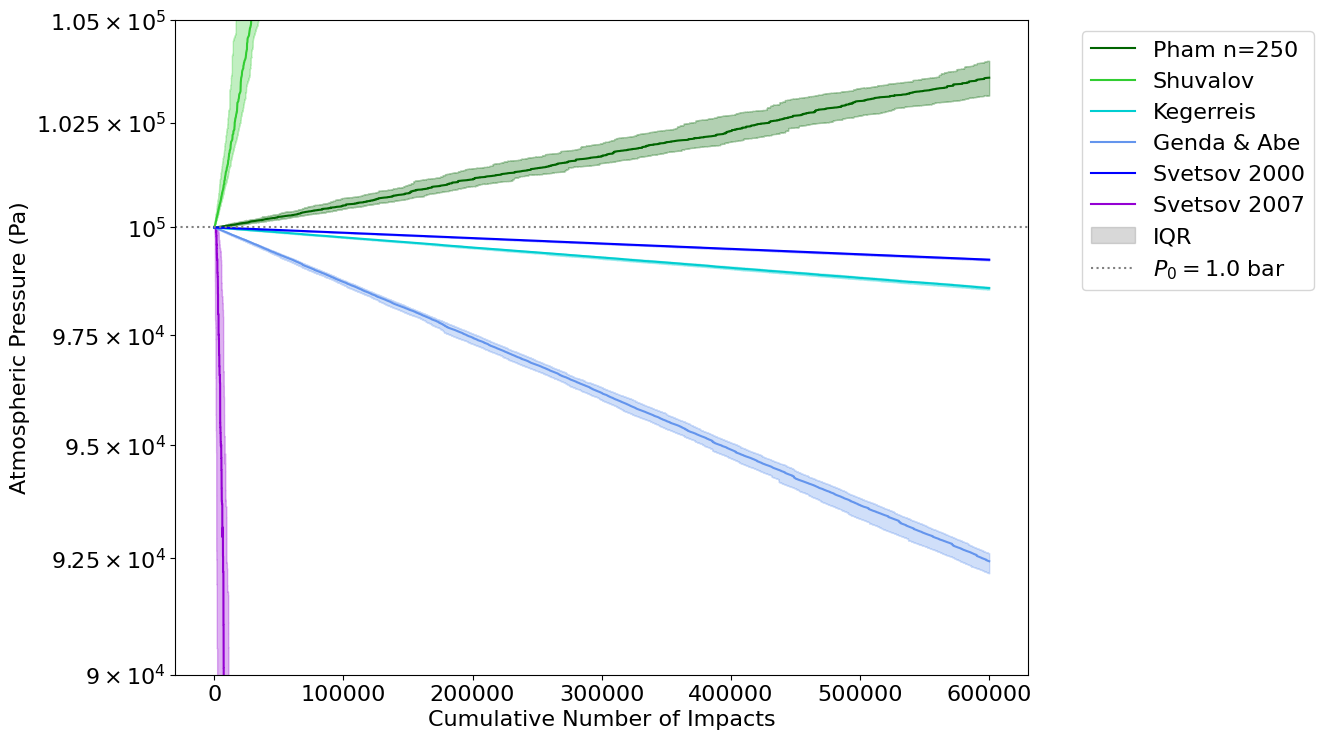

In [ ]:
import matplotlib.patches as mpatches

plotunc=True
compplotunc=True
hilkeplotunc=True

if medianoravg=='avg':
    unclabel='1σ'
elif medianoravg=='median':
    unclabel='IQR'

x_vals = np.linspace(1, len(randomlychosensizevals), len(randomlychosensizevals))

plots = []

if 'svet07' in mods.Nickname.values:
    plot_svet07, = plt.plot(x_vals, list(processeddatadict['svet07'][2]['avg']), color=svet07color, label='Svetsov 2007',zorder=1)
    plots.append(plot_svet07)
    if plotunc:
        plt.fill_between(x_vals, list(processeddatadict['svet07'][2]['avg+std']), list(processeddatadict['svet07'][2]['avg-std']), color=svet07color, alpha=0.3,zorder=1)

if 'pham10' in mods.Nickname.values:
    plot_pham10, = plt.plot(x_vals, list(processeddatadict['pham10'][2]['avg']), color=pham10color, label='Pham n=10',zorder=2)
    plots.append(plot_pham10)
    if plotunc:
        plt.fill_between(x_vals, list(processeddatadict['pham10'][2]['avg+std']), list(processeddatadict['pham10'][2]['avg-std']), color=pham10color, alpha=0.3,zorder=2)

if 'pham2400' in mods.Nickname.values:
    plot_pham2400, = plt.plot(x_vals, list(processeddatadict['pham2400'][2]['avg']), color=pham2400color, label='Pham n=2400',zorder=2)
    plots.append(plot_pham2400)
    if plotunc:
        plt.fill_between(x_vals, list(processeddatadict['pham2400'][2]['avg+std']), list(processeddatadict['pham2400'][2]['avg-std']), color=pham2400color, alpha=0.3,zorder=2)

if 'pham' in mods.Nickname.values and csvoutput==True:
    plot_pham, = plt.plot(x_vals, list(processeddatadict['pham'][2]['avg']), color=phamcolor, label='Pham n='+str(round(n)),zorder=2)
    plots.append(plot_pham)
    if plotunc:
        plt.fill_between(x_vals, list(processeddatadict['pham'][2]['avg+std']), list(processeddatadict['pham'][2]['avg-std']), color=phamcolor, alpha=0.3,zorder=2)

if 'pham' in mods.Nickname.values  and pickleoutput==True:
    plot_pham, = plt.plot(x_vals, list(processeddatadict['pham'+str(n)][2]['avg']), color=phamcolor, label='Pham n='+str(round(n)),zorder=2)
    plots.append(plot_pham)
    if plotunc:
        plt.fill_between(x_vals, list(processeddatadict['pham'+str(n)][2]['avg+std']), list(processeddatadict['pham'+str(n)][2]['avg-std']), color=phamcolor, alpha=0.3,zorder=2)

if 'shu' in mods.Nickname.values:
    plot_shu, = plt.plot(x_vals, list(processeddatadict['shu'][2]['avg']), color=shucolor, label='Shuvalov',zorder=2)
    plots.append(plot_shu)
    if plotunc:
        plt.fill_between(x_vals, list(processeddatadict['shu'][2]['avg+std']), list(processeddatadict['shu'][2]['avg-std']), color=shucolor, alpha=0.3,zorder=2)

if 'kerr' in mods.Nickname.values:
    plot_kerr, = plt.plot(x_vals, list(processeddatadict['kerr'][2]['avg']), color=kerrcolor, label='Kegerreis',zorder=2)
    plots.append(plot_kerr)
    if plotunc:
        plt.fill_between(x_vals, list(processeddatadict['kerr'][2]['avg+std']), list(processeddatadict['kerr'][2]['avg-std']), color=kerrcolor, alpha=0.3,zorder=2)

if 'ga' in mods.Nickname.values:
    plot_ga, = plt.plot(x_vals, list(processeddatadict['ga'][2]['avg']), color=gacolor, label='Genda & Abe',zorder=2)
    plots.append(plot_ga)
    if plotunc:
        plt.fill_between(x_vals, list(processeddatadict['ga'][2]['avg+std']), list(processeddatadict['ga'][2]['avg-std']), color=gacolor, alpha=0.3,zorder=2)

if 'svet' in mods.Nickname.values:
    plot_svet, = plt.plot(x_vals, list(processeddatadict['svet'][2]['avg']), color=svetcolor, label='Svetsov 2000',zorder=2)
    plots.append(plot_svet)
    if plotunc:
        plt.fill_between(x_vals, list(processeddatadict['svet'][2]['avg+std']), list(processeddatadict['svet'][2]['avg-std']), color=svetcolor, alpha=0.3,zorder=2)

# if 'comps' in mods.Nickname.values:
#     plot_comps, = plt.plot(x_vals, list(processeddatadict['comps'][2]['avg']), color=compscolor, label='Composite with\nSvetsov 2007',zorder=2)
#     plots.append(plot_comps)
#     if compplotunc:
#         plt.fill_between(x_vals, list(processeddatadict['comps'][2]['avg+std']), list(processeddatadict['comps'][2]['avg-std']), color=compscolor, alpha=0.3,zorder=2)

# if 'compns' in mods.Nickname.values:
#     plot_compns, = plt.plot(x_vals, list(processeddatadict['compns'][2]['avg']), color=compcolor, label='Composite without\nSvetsov 2007',zorder=2)
#     plots.append(plot_compns)
#     if compplotunc:
#         plt.fill_between(x_vals, list(processeddatadict['compns'][2]['avg+std']), list(processeddatadict['compns'][2]['avg-std']), color=compcolor, alpha=0.3,zorder=2)

# if 'hilke' in mods.Nickname.values:
#     plot_hilke, = plt.plot(x_vals, list(processeddatadict['hilke'][2]['avg']), color=hilkecolor, label='Schlichting',zorder=2)
#     plots.append(plot_hilke)
#     if hilkeplotunc:
#         plt.fill_between(x_vals, list(processeddatadict['hilke'][2]['avg+std']), list(processeddatadict['hilke'][2]['avg-std']), color=hilkecolor, alpha=0.3,zorder=2)

# if 'deniem' in mods.Nickname.values:
#     plot_deniem, = plt.plot(x_vals, list(processeddatadict['deniem'][2]['avg']), color=deniemcolor, label='de Niem',zorder=2)
#     plots.append(plot_deniem)
#     if plotunc:
#         plt.fill_between(x_vals, list(processeddatadict['deniem'][2]['avg+std']), list(processeddatadict['deniem'][2]['avg-std']), color=deniemcolor, alpha=0.3,zorder=2)

atm_line = plt.axhline(atmmass_to_surfacepressure(r_planet, presentday_atm_m, gravity), color='gray', linestyle='dotted', label='1 Mars\nAtmosphere',zorder=2)

# Create a shaded area patch for IQR/1σ
unc_patch = mpatches.Patch(color=compcolor, alpha=0.3, label=unclabel)

startingPlabel='$P_0=$'+str(startingP)+' bar'

# Reordering the legend manually
# handles, labels = plt.gca().get_legend_handles_labels()
# ordered_labels = ['Pham n='+str(round(n)), 'Shuvalov', 'Kegerreis', 'Genda & Abe', 'Svetsov 2000', 'Svetsov 2007', 'Schlichting', 'de Niem', 'Composite with\nSvetsov 2007', 'Composite without\nSvetsov 2007', unclabel, startingPlabel]
# ordered_handles = [plot_pham, plot_shu, plot_kerr, plot_ga, plot_svet, plot_svet07, plot_hilke, plot_deniem, plot_comps, plot_compns, unc_patch, atm_line]

handles, labels = plt.gca().get_legend_handles_labels()
ordered_labels = ['Pham n='+str(round(n)), 'Shuvalov', 'Kegerreis', 'Genda & Abe', 'Svetsov 2000', 'Svetsov 2007', unclabel, startingPlabel]
ordered_handles = [plot_pham, plot_shu, plot_kerr, plot_ga, plot_svet, plot_svet07, unc_patch, atm_line]

# ordered_labels = ['Pham n='+str(round(n)), 'Shuvalov', 'Genda & Abe', 'Svetsov 2000', 'Schlichting', 'Composite', unclabel, '1 bar']
# ordered_handles = [plot_pham, plot_shu, plot_ga, plot_svet, plot_hilke, plot_comp, unc_patch, atm_line]

plt.legend(ordered_handles, ordered_labels, bbox_to_anchor=(1.05, 1.0), loc='upper left')
# plt.legend(loc='upper left')
# plt.xscale('log')
# plt.yscale('log')
plt.yscale('symlog')
plt.xlabel('Cumulative Number of Impacts')
plt.ylabel('Atmospheric Pressure (Pa)')

plt.ylim(0.9e5,1.05e5)
ticks = [0.9e5,0.925e5,0.95e5,0.975e5,1e5,1.025e5,1.05e5]
# tick_labels = ['$9.50 × 10^4$','$9.75 × 10^4$','$1.00 × 10^5$','$1.025 × 10^4$',]
plt.yticks(ticks)#, tick_labels)

# plt.ylim(0)
plt.savefig(os.path.abspath(os.getcwd())+'/nocompsmedfig.png')

In [ ]:
# import matplotlib.patches as mpatches

# plotunc=True
# compplotunc=True
# hilkeplotunc=True

# if medianoravg=='avg':
#     unclabel='1σ'
# elif medianoravg=='median':
#     unclabel='IQR'

# x_vals = np.linspace(1, len(randomlychosensizevals), len(randomlychosensizevals))

# plots = []

# if 'svet07' in mods.Nickname.values:
#     plot_svet07, = plt.plot(x_vals, list(processeddatadict['svet07'][2]['avg']), color=svet07color, label='Svetsov 2007',zorder=1)
#     plots.append(plot_svet07)
#     if plotunc:
#         plt.fill_between(x_vals, list(processeddatadict['svet07'][2]['avg+std']), list(processeddatadict['svet07'][2]['avg-std']), color=svet07color, alpha=0.3,zorder=1)

# if 'pham10' in mods.Nickname.values:
#     plot_pham10, = plt.plot(x_vals, list(processeddatadict['pham10'][2]['avg']), color=pham10color, label='Pham n=10',zorder=2)
#     plots.append(plot_pham10)
#     if plotunc:
#         plt.fill_between(x_vals, list(processeddatadict['pham10'][2]['avg+std']), list(processeddatadict['pham10'][2]['avg-std']), color=pham10color, alpha=0.3,zorder=2)

# if 'pham2400' in mods.Nickname.values:
#     plot_pham2400, = plt.plot(x_vals, list(processeddatadict['pham2400'][2]['avg']), color=pham2400color, label='Pham n=2400',zorder=2)
#     plots.append(plot_pham2400)
#     if plotunc:
#         plt.fill_between(x_vals, list(processeddatadict['pham2400'][2]['avg+std']), list(processeddatadict['pham2400'][2]['avg-std']), color=pham2400color, alpha=0.3,zorder=2)

# if 'pham' in mods.Nickname.values and csvoutput==True:
#     plot_pham, = plt.plot(x_vals, list(processeddatadict['pham'][2]['avg']), color=phamcolor, label='Pham n='+str(round(n)),zorder=2)
#     plots.append(plot_pham)
#     if plotunc:
#         plt.fill_between(x_vals, list(processeddatadict['pham'][2]['avg+std']), list(processeddatadict['pham'][2]['avg-std']), color=phamcolor, alpha=0.3,zorder=2)

# if 'pham' in mods.Nickname.values  and pickleoutput==True:
#     plot_pham, = plt.plot(x_vals, list(processeddatadict['pham'+str(n)][2]['avg']), color=phamcolor, label='Pham n='+str(round(n)),zorder=2)
#     plots.append(plot_pham)
#     if plotunc:
#         plt.fill_between(x_vals, list(processeddatadict['pham'+str(n)][2]['avg+std']), list(processeddatadict['pham'+str(n)][2]['avg-std']), color=phamcolor, alpha=0.3,zorder=2)

# if 'shu' in mods.Nickname.values:
#     plot_shu, = plt.plot(x_vals, list(processeddatadict['shu'][2]['avg']), color=shucolor, label='Shuvalov',zorder=2)
#     plots.append(plot_shu)
#     if plotunc:
#         plt.fill_between(x_vals, list(processeddatadict['shu'][2]['avg+std']), list(processeddatadict['shu'][2]['avg-std']), color=shucolor, alpha=0.3,zorder=2)

# if 'kerr' in mods.Nickname.values:
#     plot_kerr, = plt.plot(x_vals, list(processeddatadict['kerr'][2]['avg']), color=kerrcolor, label='Kegerreis',zorder=2)
#     plots.append(plot_kerr)
#     if plotunc:
#         plt.fill_between(x_vals, list(processeddatadict['kerr'][2]['avg+std']), list(processeddatadict['kerr'][2]['avg-std']), color=kerrcolor, alpha=0.3,zorder=2)

# if 'ga' in mods.Nickname.values:
#     plot_ga, = plt.plot(x_vals, list(processeddatadict['ga'][2]['avg']), color=gacolor, label='Genda & Abe',zorder=2)
#     plots.append(plot_ga)
#     if plotunc:
#         plt.fill_between(x_vals, list(processeddatadict['ga'][2]['avg+std']), list(processeddatadict['ga'][2]['avg-std']), color=gacolor, alpha=0.3,zorder=2)

# if 'svet' in mods.Nickname.values:
#     plot_svet, = plt.plot(x_vals, list(processeddatadict['svet'][2]['avg']), color=svetcolor, label='Svetsov 2000',zorder=2)
#     plots.append(plot_svet)
#     if plotunc:
#         plt.fill_between(x_vals, list(processeddatadict['svet'][2]['avg+std']), list(processeddatadict['svet'][2]['avg-std']), color=svetcolor, alpha=0.3,zorder=2)

# if 'comps' in mods.Nickname.values:
#     plot_comps, = plt.plot(x_vals, list(processeddatadict['comps'][2]['avg']), color=compscolor, label='Composite with\nSvetsov 2007',zorder=2)
#     plots.append(plot_comps)
#     if compplotunc:
#         plt.fill_between(x_vals, list(processeddatadict['comps'][2]['avg+std']), list(processeddatadict['comps'][2]['avg-std']), color=compscolor, alpha=0.3,zorder=2)

# if 'compns' in mods.Nickname.values:
#     plot_compns, = plt.plot(x_vals, list(processeddatadict['compns'][2]['avg']), color=compcolor, label='Composite without\nSvetsov 2007',zorder=2)
#     plots.append(plot_compns)
#     if compplotunc:
#         plt.fill_between(x_vals, list(processeddatadict['compns'][2]['avg+std']), list(processeddatadict['compns'][2]['avg-std']), color=compcolor, alpha=0.3,zorder=2)

# if 'hilke' in mods.Nickname.values:
#     plot_hilke, = plt.plot(x_vals, list(processeddatadict['hilke'][2]['avg']), color=hilkecolor, label='Schlichting',zorder=2)
#     plots.append(plot_hilke)
#     if hilkeplotunc:
#         plt.fill_between(x_vals, list(processeddatadict['hilke'][2]['avg+std']), list(processeddatadict['hilke'][2]['avg-std']), color=hilkecolor, alpha=0.3,zorder=2)

# if 'deniem' in mods.Nickname.values:
#     plot_deniem, = plt.plot(x_vals, list(processeddatadict['deniem'][2]['avg']), color=deniemcolor, label='de Niem',zorder=2)
#     plots.append(plot_deniem)
#     if plotunc:
#         plt.fill_between(x_vals, list(processeddatadict['deniem'][2]['avg+std']), list(processeddatadict['deniem'][2]['avg-std']), color=deniemcolor, alpha=0.3,zorder=2)

# atm_line = plt.axhline(atmmass_to_surfacepressure(r_planet, presentday_atm_m, gravity), color='gray', linestyle='dotted', label='1 Mars\nAtmosphere',zorder=2)

# # Create a shaded area patch for IQR/1σ
# unc_patch = mpatches.Patch(color=compcolor, alpha=0.3, label=unclabel)

# startingPlabel='$P_0=$'+str(startingP)+' bar'

# # Reordering the legend manually
# handles, labels = plt.gca().get_legend_handles_labels()
# ordered_labels = ['Pham n='+str(round(n)), 'Shuvalov', 'Kegerreis', 'Genda & Abe', 'Svetsov 2000', 'Svetsov 2007', 'Schlichting', 'de Niem', 'Composite with\nSvetsov 2007', 'Composite without\nSvetsov 2007', unclabel, startingPlabel]
# ordered_handles = [plot_pham, plot_shu, plot_kerr, plot_ga, plot_svet, plot_svet07, plot_hilke, plot_deniem, plot_comps, plot_compns, unc_patch, atm_line]

# # ordered_labels = ['Pham n='+str(round(n)), 'Shuvalov', 'Genda & Abe', 'Svetsov 2000', 'Schlichting', 'Composite', unclabel, '1 bar']
# # ordered_handles = [plot_pham, plot_shu, plot_ga, plot_svet, plot_hilke, plot_comp, unc_patch, atm_line]

# plt.legend(ordered_handles, ordered_labels, bbox_to_anchor=(1.05, 1.0), loc='upper left')
# # plt.legend(loc='upper left')
# # plt.xscale('log')
# # plt.yscale('log')
# plt.yscale('symlog')
# plt.xlabel('Cumulative Number of Impacts')
# plt.ylabel('Atmospheric Pressure (Pa)')
# # plt.ylim(-0.1, 2e6)

# # plt.ylim(1e5,1e5+.02)
# # ticks = [0.95e5,0.975e5,1e5,1.025e5]
# # tick_labels = ['$9.50 × 10^4$','$9.75 × 10^4$','$1.00 × 10^5$','$1.025 × 10^4$',]
# # plt.yticks(ticks, tick_labels)
# # plt.xlim(0,10000)
# # plt.title('50,000 impactors truncated to 10,000')
# #quickjump
# # plt.xlim(0,50)


# # if medianoravg=='avg':
# #     maxlist=[list(processeddatadict['comps'][2]['avg'])[-1]+list(processeddatadict['comps'][2]['std'])[-1],
# #              list(processeddatadict['compns'][2]['avg'])[-1]+list(processeddatadict['compns'][2]['std'])[-1],
# #              list(processeddatadict['svet'][2]['avg'])[-1]+list(processeddatadict['svet'][2]['std'])[-1],
# #              list(processeddatadict['svet07'][2]['avg'])[-1]+list(processeddatadict['svet07'][2]['std'])[-1],
# #              list(processeddatadict['shu'][2]['avg'])[-1]+list(processeddatadict['shu'][2]['std'])[-1],
# #              list(processeddatadict['pham'][2]['avg'])[-1]+list(processeddatadict['pham'][2]['std'])[-1],
# #              list(processeddatadict['ga'][2]['avg'])[-1]+list(processeddatadict['ga'][2]['std'])[-1],
# #              list(processeddatadict['hilke'][2]['avg'])[-1]+list(processeddatadict['hilke'][2]['std'])[-1],
# #              list(processeddatadict['deniem'][2]['avg'])[-1]+list(processeddatadict['deniem'][2]['std'])[-1],
# #              atmmass_to_surfacepressure(r_planet, presentday_atm_m, gravity)]
# #     minlist=[list(processeddatadict['comps'][2]['avg'])[-1]-list(processeddatadict['comps'][2]['std'])[-1],
# #              list(processeddatadict['compns'][2]['avg'])[-1]-list(processeddatadict['compns'][2]['std'])[-1],
# #              list(processeddatadict['svet'][2]['avg'])[-1]-list(processeddatadict['svet'][2]['std'])[-1],
# #              list(processeddatadict['svet07'][2]['avg'])[-1]-list(processeddatadict['svet07'][2]['std'])[-1],
# #              list(processeddatadict['shu'][2]['avg'])[-1]-list(processeddatadict['shu'][2]['std'])[-1],
# #              list(processeddatadict['pham'][2]['avg'])[-1]-list(processeddatadict['pham'][2]['std'])[-1],
# #              list(processeddatadict['ga'][2]['avg'])[-1]-list(processeddatadict['ga'][2]['std'])[-1],
# #              list(processeddatadict['hilke'][2]['avg'])[-1]-list(processeddatadict['hilke'][2]['std'])[-1],
# #              list(processeddatadict['deniem'][2]['avg'])[-1]-list(processeddatadict['deniem'][2]['std'])[-1],
# #              0.]
# #     plt.ylim(min(minlist)*0.9,max(maxlist)*1.1)

# # elif medianoravg=='median':
# #     maxlist=[list(processeddatadict['comps'][2]['avg+std'])[-1],
# #              list(processeddatadict['compns'][2]['avg+std'])[-1],
# #              list(processeddatadict['svet'][2]['avg+std'])[-1],
# #              list(processeddatadict['svet07'][2]['avg+std'])[-1],
# #              list(processeddatadict['shu'][2]['avg+std'])[-1],
# #              list(processeddatadict['pham'][2]['avg+std'])[-1],
# #              list(processeddatadict['ga'][2]['avg+std'])[-1],
# #              list(processeddatadict['hilke'][2]['avg+std'])[-1],
# #              list(processeddatadict['deniem'][2]['avg+std'])[-1],
# #              atmmass_to_surfacepressure(r_planet, presentday_atm_m, gravity)]
# #     minlist=[list(processeddatadict['comps'][2]['avg-std'])[-1],
# #              list(processeddatadict['compns'][2]['avg-std'])[-1],
# #              list(processeddatadict['svet'][2]['avg-std'])[-1],
# #              list(processeddatadict['svet07'][2]['avg-std'])[-1],
# #              list(processeddatadict['shu'][2]['avg-std'])[-1],
# #              list(processeddatadict['pham'][2]['avg-std'])[-1],
# #              list(processeddatadict['ga'][2]['avg-std'])[-1],
# #              list(processeddatadict['hilke'][2]['avg-std'])[-1],
# #              list(processeddatadict['deniem'][2]['avg-std'])[-1],
# #              0.]
# #     plt.ylim(min(minlist)*0.9,max(maxlist)*1.1)

# plt.ylim(0.98e5,1.01e5)

# plt.savefig(os.path.abspath(os.getcwd())+'/zoomedinfig.png')

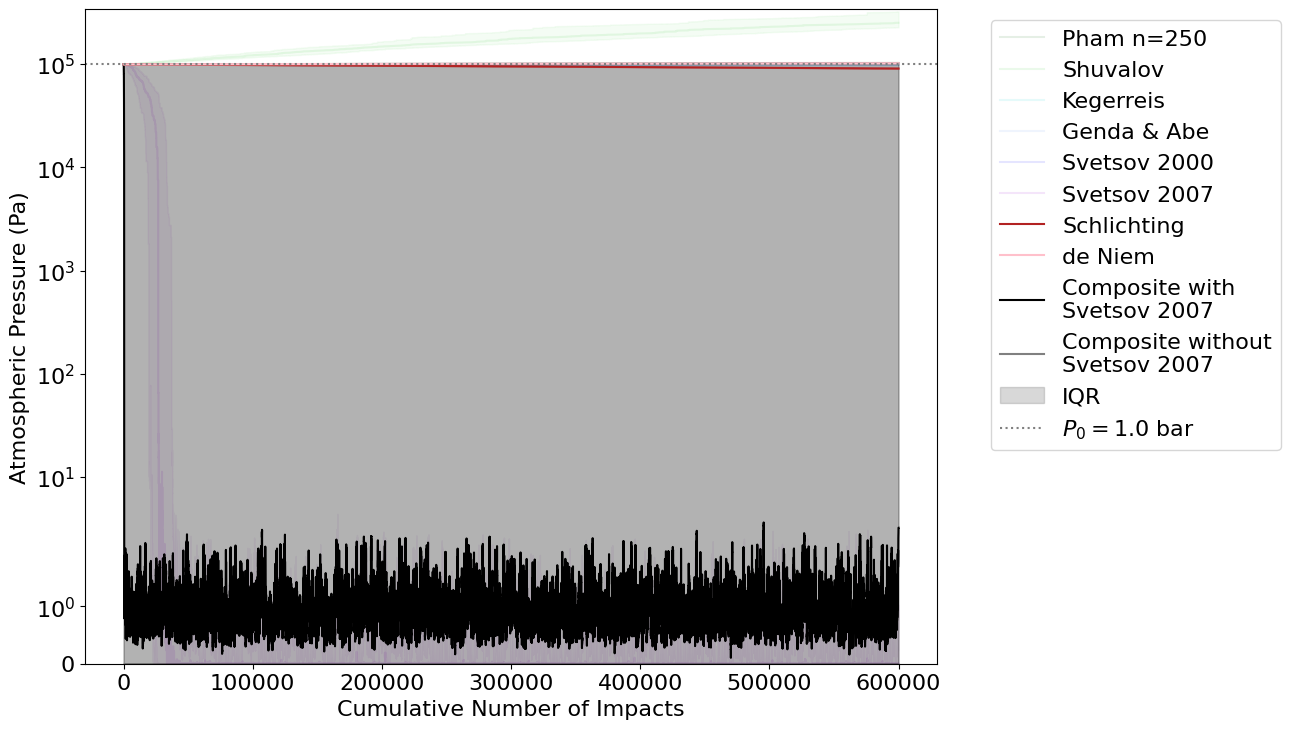

In [ ]:
import matplotlib.patches as mpatches

plotunc=True
compplotunc=True
hilkeplotunc=True

if medianoravg=='avg':
    unclabel='1σ'
elif medianoravg=='median':
    unclabel='IQR'

x_vals = np.linspace(1, len(randomlychosensizevals), len(randomlychosensizevals))

plots = []

if 'svet07' in mods.Nickname.values:
    plot_svet07, = plt.plot(x_vals, list(processeddatadict['svet07'][2]['avg']), color=svet07color, label='Svetsov 2007',zorder=1, alpha=0.1)
    plots.append(plot_svet07)
    if plotunc:
        plt.fill_between(x_vals, list(processeddatadict['svet07'][2]['avg+std']), list(processeddatadict['svet07'][2]['avg-std']), color=svet07color, alpha=0.05,zorder=1)

if 'pham10' in mods.Nickname.values:
    plot_pham10, = plt.plot(x_vals, list(processeddatadict['pham10'][2]['avg']), color=pham10color, label='Pham n=10',zorder=2, alpha=0.1)
    plots.append(plot_pham10)
    if plotunc:
        plt.fill_between(x_vals, list(processeddatadict['pham10'][2]['avg+std']), list(processeddatadict['pham10'][2]['avg-std']), color=pham10color, alpha=0.05,zorder=2)

if 'pham2400' in mods.Nickname.values:
    plot_pham2400, = plt.plot(x_vals, list(processeddatadict['pham2400'][2]['avg']), color=pham2400color, label='Pham n=2400',zorder=2, alpha=0.1)
    plots.append(plot_pham2400)
    if plotunc:
        plt.fill_between(x_vals, list(processeddatadict['pham2400'][2]['avg+std']), list(processeddatadict['pham2400'][2]['avg-std']), color=pham2400color, alpha=0.05,zorder=2)

if 'pham' in mods.Nickname.values and csvoutput==True:
    plot_pham, = plt.plot(x_vals, list(processeddatadict['pham'][2]['avg']), color=phamcolor, label='Pham n='+str(round(n)),zorder=2, alpha=0.1)
    plots.append(plot_pham)
    if plotunc:
        plt.fill_between(x_vals, list(processeddatadict['pham'][2]['avg+std']), list(processeddatadict['pham'][2]['avg-std']), color=phamcolor, alpha=0.05,zorder=2)

if 'pham' in mods.Nickname.values  and pickleoutput==True:
    plot_pham, = plt.plot(x_vals, list(processeddatadict['pham'+str(n)][2]['avg']), color=phamcolor, label='Pham n='+str(round(n)),zorder=2, alpha=0.1)
    plots.append(plot_pham)
    if plotunc:
        plt.fill_between(x_vals, list(processeddatadict['pham'+str(n)][2]['avg+std']), list(processeddatadict['pham'+str(n)][2]['avg-std']), color=phamcolor, alpha=0.05,zorder=2)

if 'shu' in mods.Nickname.values:
    plot_shu, = plt.plot(x_vals, list(processeddatadict['shu'][2]['avg']), color=shucolor, label='Shuvalov',zorder=2, alpha=0.1)
    plots.append(plot_shu)
    if plotunc:
        plt.fill_between(x_vals, list(processeddatadict['shu'][2]['avg+std']), list(processeddatadict['shu'][2]['avg-std']), color=shucolor, alpha=0.05,zorder=2)

if 'kerr' in mods.Nickname.values:
    plot_kerr, = plt.plot(x_vals, list(processeddatadict['kerr'][2]['avg']), color=kerrcolor, label='Kegerreis',zorder=2, alpha=0.1)
    plots.append(plot_kerr)
    if plotunc:
        plt.fill_between(x_vals, list(processeddatadict['kerr'][2]['avg+std']), list(processeddatadict['kerr'][2]['avg-std']), color=kerrcolor, alpha=0.05,zorder=2)

if 'ga' in mods.Nickname.values:
    plot_ga, = plt.plot(x_vals, list(processeddatadict['ga'][2]['avg']), color=gacolor, label='Genda & Abe',zorder=2, alpha=0.1)
    plots.append(plot_ga)
    if plotunc:
        plt.fill_between(x_vals, list(processeddatadict['ga'][2]['avg+std']), list(processeddatadict['ga'][2]['avg-std']), color=gacolor, alpha=0.05,zorder=2)

if 'svet' in mods.Nickname.values:
    plot_svet, = plt.plot(x_vals, list(processeddatadict['svet'][2]['avg']), color=svetcolor, label='Svetsov 2000',zorder=2, alpha=0.1)
    plots.append(plot_svet)
    if plotunc:
        plt.fill_between(x_vals, list(processeddatadict['svet'][2]['avg+std']), list(processeddatadict['svet'][2]['avg-std']), color=svetcolor, alpha=0.05,zorder=2)

if 'comps' in mods.Nickname.values:
    plot_comps, = plt.plot(x_vals, list(processeddatadict['comps'][2]['avg']), color=compscolor, label='Composite with\nSvetsov 2007',zorder=2)
    plots.append(plot_comps)
    if compplotunc:
        plt.fill_between(x_vals, list(processeddatadict['comps'][2]['avg+std']), list(processeddatadict['comps'][2]['avg-std']), color=compscolor, alpha=0.3,zorder=2)

if 'compns' in mods.Nickname.values:
    plot_compns, = plt.plot(x_vals, list(processeddatadict['compns'][2]['avg']), color=compcolor, label='Composite without\nSvetsov 2007',zorder=2)
    plots.append(plot_compns)
    if compplotunc:
        plt.fill_between(x_vals, list(processeddatadict['compns'][2]['avg+std']), list(processeddatadict['compns'][2]['avg-std']), color=compcolor, alpha=0.3,zorder=2)

if 'hilke' in mods.Nickname.values:
    plot_hilke, = plt.plot(x_vals, list(processeddatadict['hilke'][2]['avg']), color=hilkecolor, label='Schlichting',zorder=2)
    plots.append(plot_hilke)
    if hilkeplotunc:
        plt.fill_between(x_vals, list(processeddatadict['hilke'][2]['avg+std']), list(processeddatadict['hilke'][2]['avg-std']), color=hilkecolor, alpha=0.3,zorder=2)

if 'deniem' in mods.Nickname.values:
    plot_deniem, = plt.plot(x_vals, list(processeddatadict['deniem'][2]['avg']), color=deniemcolor, label='de Niem',zorder=2)
    plots.append(plot_deniem)
    if plotunc:
        plt.fill_between(x_vals, list(processeddatadict['deniem'][2]['avg+std']), list(processeddatadict['deniem'][2]['avg-std']), color=deniemcolor, alpha=0.3,zorder=2)

atm_line = plt.axhline(atmmass_to_surfacepressure(r_planet, presentday_atm_m, gravity), color='gray', linestyle='dotted', label='1 Mars\nAtmosphere',zorder=2)

# Create a shaded area patch for IQR/1σ
unc_patch = mpatches.Patch(color=compcolor, alpha=0.3, label=unclabel)

startingPlabel='$P_0=$'+str(startingP)+' bar'

# Reordering the legend manually
handles, labels = plt.gca().get_legend_handles_labels()
ordered_labels = ['Pham n='+str(round(n)), 'Shuvalov', 'Kegerreis', 'Genda & Abe', 'Svetsov 2000', 'Svetsov 2007', 'Schlichting', 'de Niem', 'Composite with\nSvetsov 2007', 'Composite without\nSvetsov 2007', unclabel, startingPlabel]
ordered_handles = [plot_pham, plot_shu, plot_kerr, plot_ga, plot_svet, plot_svet07, plot_hilke, plot_deniem, plot_comps, plot_compns, unc_patch, atm_line]

# ordered_labels = ['Pham n='+str(round(n)), 'Shuvalov', 'Genda & Abe', 'Svetsov 2000', 'Schlichting', 'Composite', unclabel, '1 bar']
# ordered_handles = [plot_pham, plot_shu, plot_ga, plot_svet, plot_hilke, plot_comp, unc_patch, atm_line]

plt.legend(ordered_handles, ordered_labels, bbox_to_anchor=(1.05, 1.0), loc='upper left')
# plt.legend(loc='upper left')
# plt.xscale('log')
# plt.yscale('log')
plt.yscale('symlog')
plt.xlabel('Cumulative Number of Impacts')
plt.ylabel('Atmospheric Pressure (Pa)')
# plt.ylim(-0.1, 2e6)

# plt.ylim(1e5,1e5+.02)
# ticks = [0.95e5,0.975e5,1e5,1.025e5]


plt.ylim(0)
plt.savefig(os.path.abspath(os.getcwd())+'/compsbigfig.png')

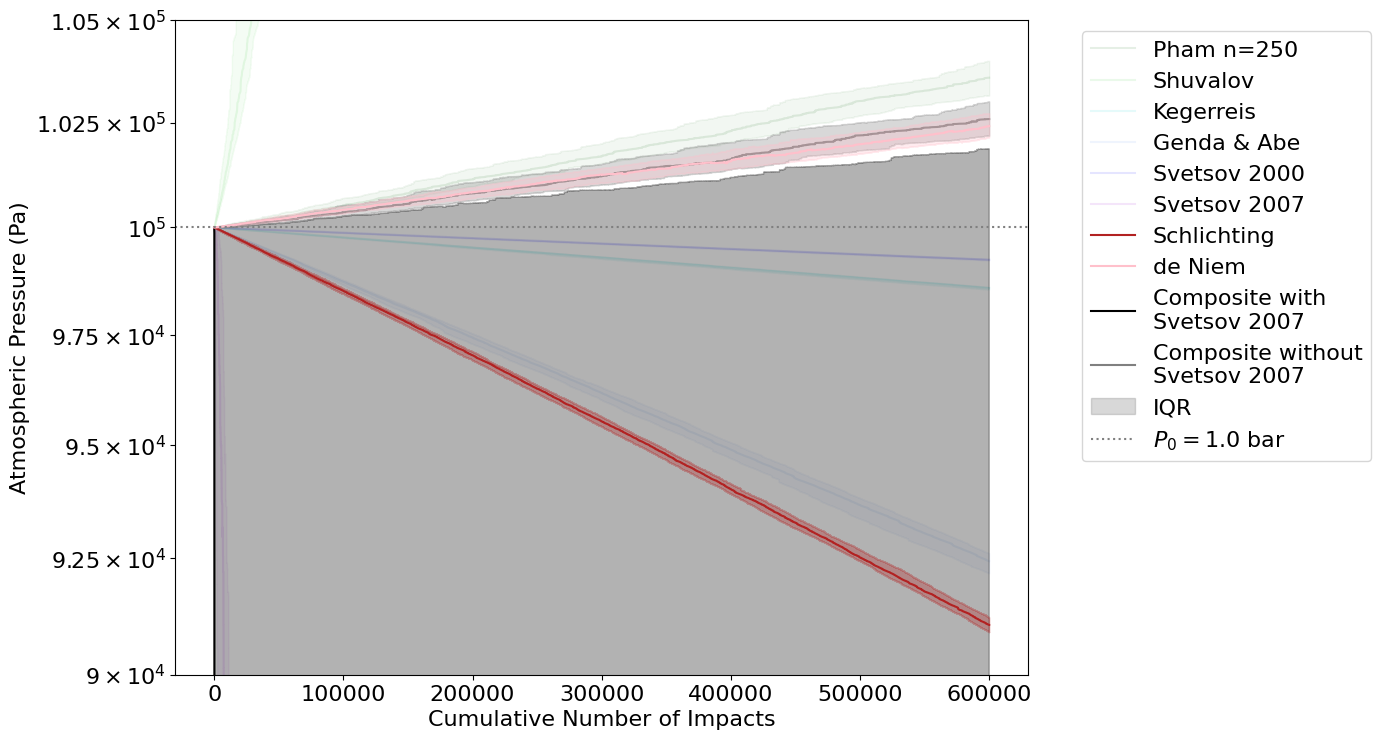

In [ ]:
import matplotlib.patches as mpatches

plotunc=True
compplotunc=True
hilkeplotunc=True

if medianoravg=='avg':
    unclabel='1σ'
elif medianoravg=='median':
    unclabel='IQR'

x_vals = np.linspace(1, len(randomlychosensizevals), len(randomlychosensizevals))

plots = []

if 'svet07' in mods.Nickname.values:
    plot_svet07, = plt.plot(x_vals, list(processeddatadict['svet07'][2]['avg']), color=svet07color, label='Svetsov 2007',zorder=1, alpha=0.1)
    plots.append(plot_svet07)
    if plotunc:
        plt.fill_between(x_vals, list(processeddatadict['svet07'][2]['avg+std']), list(processeddatadict['svet07'][2]['avg-std']), color=svet07color, alpha=0.05,zorder=1)

if 'pham10' in mods.Nickname.values:
    plot_pham10, = plt.plot(x_vals, list(processeddatadict['pham10'][2]['avg']), color=pham10color, label='Pham n=10',zorder=2, alpha=0.1)
    plots.append(plot_pham10)
    if plotunc:
        plt.fill_between(x_vals, list(processeddatadict['pham10'][2]['avg+std']), list(processeddatadict['pham10'][2]['avg-std']), color=pham10color, alpha=0.05,zorder=2)

if 'pham2400' in mods.Nickname.values:
    plot_pham2400, = plt.plot(x_vals, list(processeddatadict['pham2400'][2]['avg']), color=pham2400color, label='Pham n=2400',zorder=2, alpha=0.1)
    plots.append(plot_pham2400)
    if plotunc:
        plt.fill_between(x_vals, list(processeddatadict['pham2400'][2]['avg+std']), list(processeddatadict['pham2400'][2]['avg-std']), color=pham2400color, alpha=0.05,zorder=2)

if 'pham' in mods.Nickname.values and csvoutput==True:
    plot_pham, = plt.plot(x_vals, list(processeddatadict['pham'][2]['avg']), color=phamcolor, label='Pham n='+str(round(n)),zorder=2, alpha=0.1)
    plots.append(plot_pham)
    if plotunc:
        plt.fill_between(x_vals, list(processeddatadict['pham'][2]['avg+std']), list(processeddatadict['pham'][2]['avg-std']), color=phamcolor, alpha=0.05,zorder=2)

if 'pham' in mods.Nickname.values  and pickleoutput==True:
    plot_pham, = plt.plot(x_vals, list(processeddatadict['pham'+str(n)][2]['avg']), color=phamcolor, label='Pham n='+str(round(n)),zorder=2, alpha=0.1)
    plots.append(plot_pham)
    if plotunc:
        plt.fill_between(x_vals, list(processeddatadict['pham'+str(n)][2]['avg+std']), list(processeddatadict['pham'+str(n)][2]['avg-std']), color=phamcolor, alpha=0.05,zorder=2)

if 'shu' in mods.Nickname.values:
    plot_shu, = plt.plot(x_vals, list(processeddatadict['shu'][2]['avg']), color=shucolor, label='Shuvalov',zorder=2, alpha=0.1)
    plots.append(plot_shu)
    if plotunc:
        plt.fill_between(x_vals, list(processeddatadict['shu'][2]['avg+std']), list(processeddatadict['shu'][2]['avg-std']), color=shucolor, alpha=0.05,zorder=2)

if 'kerr' in mods.Nickname.values:
    plot_kerr, = plt.plot(x_vals, list(processeddatadict['kerr'][2]['avg']), color=kerrcolor, label='Kegerreis',zorder=2, alpha=0.1)
    plots.append(plot_kerr)
    if plotunc:
        plt.fill_between(x_vals, list(processeddatadict['kerr'][2]['avg+std']), list(processeddatadict['kerr'][2]['avg-std']), color=kerrcolor, alpha=0.05,zorder=2)

if 'ga' in mods.Nickname.values:
    plot_ga, = plt.plot(x_vals, list(processeddatadict['ga'][2]['avg']), color=gacolor, label='Genda & Abe',zorder=2, alpha=0.1)
    plots.append(plot_ga)
    if plotunc:
        plt.fill_between(x_vals, list(processeddatadict['ga'][2]['avg+std']), list(processeddatadict['ga'][2]['avg-std']), color=gacolor, alpha=0.05,zorder=2)

if 'svet' in mods.Nickname.values:
    plot_svet, = plt.plot(x_vals, list(processeddatadict['svet'][2]['avg']), color=svetcolor, label='Svetsov 2000',zorder=2, alpha=0.1)
    plots.append(plot_svet)
    if plotunc:
        plt.fill_between(x_vals, list(processeddatadict['svet'][2]['avg+std']), list(processeddatadict['svet'][2]['avg-std']), color=svetcolor, alpha=0.05,zorder=2)

if 'comps' in mods.Nickname.values:
    plot_comps, = plt.plot(x_vals, list(processeddatadict['comps'][2]['avg']), color=compscolor, label='Composite with\nSvetsov 2007',zorder=2)
    plots.append(plot_comps)
    if compplotunc:
        plt.fill_between(x_vals, list(processeddatadict['comps'][2]['avg+std']), list(processeddatadict['comps'][2]['avg-std']), color=compscolor, alpha=0.3,zorder=2)

if 'compns' in mods.Nickname.values:
    plot_compns, = plt.plot(x_vals, list(processeddatadict['compns'][2]['avg']), color=compcolor, label='Composite without\nSvetsov 2007',zorder=2)
    plots.append(plot_compns)
    if compplotunc:
        plt.fill_between(x_vals, list(processeddatadict['compns'][2]['avg+std']), list(processeddatadict['compns'][2]['avg-std']), color=compcolor, alpha=0.3,zorder=2)

if 'hilke' in mods.Nickname.values:
    plot_hilke, = plt.plot(x_vals, list(processeddatadict['hilke'][2]['avg']), color=hilkecolor, label='Schlichting',zorder=2)
    plots.append(plot_hilke)
    if hilkeplotunc:
        plt.fill_between(x_vals, list(processeddatadict['hilke'][2]['avg+std']), list(processeddatadict['hilke'][2]['avg-std']), color=hilkecolor, alpha=0.3,zorder=2)

if 'deniem' in mods.Nickname.values:
    plot_deniem, = plt.plot(x_vals, list(processeddatadict['deniem'][2]['avg']), color=deniemcolor, label='de Niem',zorder=2)
    plots.append(plot_deniem)
    if plotunc:
        plt.fill_between(x_vals, list(processeddatadict['deniem'][2]['avg+std']), list(processeddatadict['deniem'][2]['avg-std']), color=deniemcolor, alpha=0.3,zorder=2)

atm_line = plt.axhline(atmmass_to_surfacepressure(r_planet, presentday_atm_m, gravity), color='gray', linestyle='dotted', label='1 Mars\nAtmosphere',zorder=2)

# Create a shaded area patch for IQR/1σ
unc_patch = mpatches.Patch(color=compcolor, alpha=0.3, label=unclabel)

startingPlabel='$P_0=$'+str(startingP)+' bar'

# Reordering the legend manually
handles, labels = plt.gca().get_legend_handles_labels()
ordered_labels = ['Pham n='+str(round(n)), 'Shuvalov', 'Kegerreis', 'Genda & Abe', 'Svetsov 2000', 'Svetsov 2007', 'Schlichting', 'de Niem', 'Composite with\nSvetsov 2007', 'Composite without\nSvetsov 2007', unclabel, startingPlabel]
ordered_handles = [plot_pham, plot_shu, plot_kerr, plot_ga, plot_svet, plot_svet07, plot_hilke, plot_deniem, plot_comps, plot_compns, unc_patch, atm_line]

# ordered_labels = ['Pham n='+str(round(n)), 'Shuvalov', 'Genda & Abe', 'Svetsov 2000', 'Schlichting', 'Composite', unclabel, '1 bar']
# ordered_handles = [plot_pham, plot_shu, plot_ga, plot_svet, plot_hilke, plot_comp, unc_patch, atm_line]

plt.legend(ordered_handles, ordered_labels, bbox_to_anchor=(1.05, 1.0), loc='upper left')
# plt.legend(loc='upper left')
# plt.xscale('log')
# plt.yscale('log')
plt.yscale('symlog')
plt.xlabel('Cumulative Number of Impacts')
plt.ylabel('Atmospheric Pressure (Pa)')


plt.ylim(0.9e5,1.05e5)
ticks = [0.9e5,0.925e5,0.95e5,0.975e5,1e5,1.025e5,1.05e5]
# tick_labels = ['$9.50 × 10^4$','$9.75 × 10^4$','$1.00 × 10^5$','$1.025 × 10^4$',]
plt.yticks(ticks)#, tick_labels)

plt.savefig(os.path.abspath(os.getcwd())+'/compsmedfig.png')

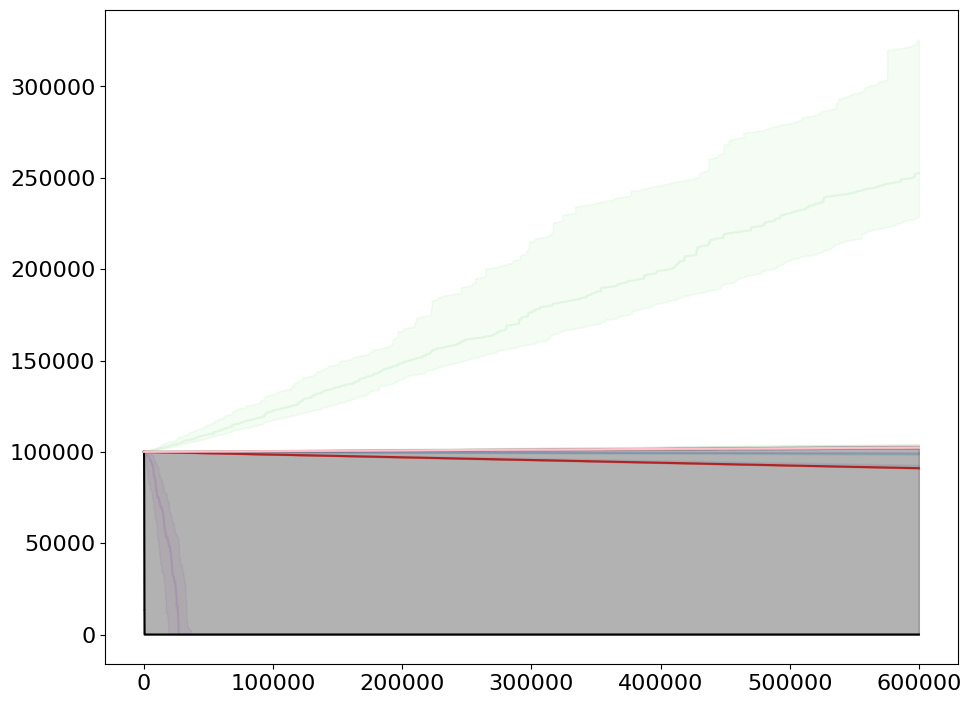

In [ ]:
if 'svet07' in mods.Nickname.values:
    plot_svet07, = plt.plot(x_vals, list(processeddatadict['svet07'][2]['avg']), color=svet07color, label='Svetsov 2007',zorder=1, alpha=0.1)
    plots.append(plot_svet07)
    if plotunc:
        plt.fill_between(x_vals, list(processeddatadict['svet07'][2]['avg+std']), list(processeddatadict['svet07'][2]['avg-std']), color=svet07color, alpha=0.05,zorder=1)

if 'pham10' in mods.Nickname.values:
    plot_pham10, = plt.plot(x_vals, list(processeddatadict['pham10'][2]['avg']), color=pham10color, label='Pham n=10',zorder=2, alpha=0.1)
    plots.append(plot_pham10)
    if plotunc:
        plt.fill_between(x_vals, list(processeddatadict['pham10'][2]['avg+std']), list(processeddatadict['pham10'][2]['avg-std']), color=pham10color, alpha=0.05,zorder=2)

if 'pham2400' in mods.Nickname.values:
    plot_pham2400, = plt.plot(x_vals, list(processeddatadict['pham2400'][2]['avg']), color=pham2400color, label='Pham n=2400',zorder=2, alpha=0.1)
    plots.append(plot_pham2400)
    if plotunc:
        plt.fill_between(x_vals, list(processeddatadict['pham2400'][2]['avg+std']), list(processeddatadict['pham2400'][2]['avg-std']), color=pham2400color, alpha=0.05,zorder=2)

if 'pham' in mods.Nickname.values and csvoutput==True:
    plot_pham, = plt.plot(x_vals, list(processeddatadict['pham'][2]['avg']), color=phamcolor, label='Pham n='+str(round(n)),zorder=2, alpha=0.1)
    plots.append(plot_pham)
    if plotunc:
        plt.fill_between(x_vals, list(processeddatadict['pham'][2]['avg+std']), list(processeddatadict['pham'][2]['avg-std']), color=phamcolor, alpha=0.05,zorder=2)

if 'pham' in mods.Nickname.values  and pickleoutput==True:
    plot_pham, = plt.plot(x_vals, list(processeddatadict['pham'+str(n)][2]['avg']), color=phamcolor, label='Pham n='+str(round(n)),zorder=2, alpha=0.1)
    plots.append(plot_pham)
    if plotunc:
        plt.fill_between(x_vals, list(processeddatadict['pham'+str(n)][2]['avg+std']), list(processeddatadict['pham'+str(n)][2]['avg-std']), color=phamcolor, alpha=0.05,zorder=2)

if 'shu' in mods.Nickname.values:
    plot_shu, = plt.plot(x_vals, list(processeddatadict['shu'][2]['avg']), color=shucolor, label='Shuvalov',zorder=2, alpha=0.1)
    plots.append(plot_shu)
    if plotunc:
        plt.fill_between(x_vals, list(processeddatadict['shu'][2]['avg+std']), list(processeddatadict['shu'][2]['avg-std']), color=shucolor, alpha=0.05,zorder=2)

if 'kerr' in mods.Nickname.values:
    plot_kerr, = plt.plot(x_vals, list(processeddatadict['kerr'][2]['avg']), color=kerrcolor, label='Kegerreis',zorder=2, alpha=0.1)
    plots.append(plot_kerr)
    if plotunc:
        plt.fill_between(x_vals, list(processeddatadict['kerr'][2]['avg+std']), list(processeddatadict['kerr'][2]['avg-std']), color=kerrcolor, alpha=0.05,zorder=2)

if 'ga' in mods.Nickname.values:
    plot_ga, = plt.plot(x_vals, list(processeddatadict['ga'][2]['avg']), color=gacolor, label='Genda & Abe',zorder=2, alpha=0.1)
    plots.append(plot_ga)
    if plotunc:
        plt.fill_between(x_vals, list(processeddatadict['ga'][2]['avg+std']), list(processeddatadict['ga'][2]['avg-std']), color=gacolor, alpha=0.05,zorder=2)

if 'svet' in mods.Nickname.values:
    plot_svet, = plt.plot(x_vals, list(processeddatadict['svet'][2]['avg']), color=svetcolor, label='Svetsov 2000',zorder=2, alpha=0.1)
    plots.append(plot_svet)
    if plotunc:
        plt.fill_between(x_vals, list(processeddatadict['svet'][2]['avg+std']), list(processeddatadict['svet'][2]['avg-std']), color=svetcolor, alpha=0.05,zorder=2)

if 'comps' in mods.Nickname.values:
    plot_comps, = plt.plot(x_vals, list(processeddatadict['comps'][2]['avg']), color=compscolor, label='Composite with\nSvetsov 2007',zorder=2)
    plots.append(plot_comps)
    if compplotunc:
        plt.fill_between(x_vals, list(processeddatadict['comps'][2]['avg+std']), list(processeddatadict['comps'][2]['avg-std']), color=compscolor, alpha=0.3,zorder=2)

if 'compns' in mods.Nickname.values:
    plot_compns, = plt.plot(x_vals, list(processeddatadict['compns'][2]['avg']), color=compcolor, label='Composite without\nSvetsov 2007',zorder=2)
    plots.append(plot_compns)
    if compplotunc:
        plt.fill_between(x_vals, list(processeddatadict['compns'][2]['avg+std']), list(processeddatadict['compns'][2]['avg-std']), color=compcolor, alpha=0.3,zorder=2)

if 'hilke' in mods.Nickname.values:
    plot_hilke, = plt.plot(x_vals, list(processeddatadict['hilke'][2]['avg']), color=hilkecolor, label='Schlichting',zorder=2)
    plots.append(plot_hilke)
    if hilkeplotunc:
        plt.fill_between(x_vals, list(processeddatadict['hilke'][2]['avg+std']), list(processeddatadict['hilke'][2]['avg-std']), color=hilkecolor, alpha=0.3,zorder=2)

if 'deniem' in mods.Nickname.values:
    plot_deniem, = plt.plot(x_vals, list(processeddatadict['deniem'][2]['avg']), color=deniemcolor, label='de Niem',zorder=2)
    plots.append(plot_deniem)
    if plotunc:
        plt.fill_between(x_vals, list(processeddatadict['deniem'][2]['avg+std']), list(processeddatadict['deniem'][2]['avg-std']), color=deniemcolor, alpha=0.3,zorder=2)